In [1]:
# =====================================================================================
#  EDIT ME  --  project details & display settings
#  Change the values below, then re-run THIS cell and the next one (title page).
#  Nothing else in the notebook needs to be touched: the title page updates itself.
# =====================================================================================

# ---- Title (edit freely) -------------------------------------------------------------
PROJECT_TITLE    = "Beyond Accuracy"
PROJECT_SUBTITLE = ("A Robustness-First Benchmark of Classical, Transformer and Hybrid "
                    "Models for Phishing-Email Detection")

# ---- Student & programme details (edit these) ------------------------------------------
STUDENT_NAME    = "[Your Full Name]"
STUDENT_ID      = "[Your Student ID]"
PROGRAMME       = "MSc [Programme Name]"
MODULE          = "[Module Code - Module Title]"
SUPERVISOR      = "[Supervisor Name]"
INSTITUTION     = "[Institution Name]"
SUBMISSION_DATE = "[DD Month YYYY]"

# ---- Display settings ------------------------------------------------------------------
BASE_FONT_PX = 17          # size of notebook text (markdown, tables). Jupyter's default is ~14.
CODE_FONT_PX = 14          # size of code and printed output.
PLOT_FONT_PT = 12          # base font size of every chart (titles/labels scale from this).
ACCENT_COLOR = "#1D3557"   # colour of the title-page banner and part banners.


In [2]:
# Title page + notebook typography (presentation only). Reads the values from the previous cell.
from IPython.display import HTML, display
import html as _html

def _e(x):
    return _html.escape(str(x))

_css = f"""
<style>
  /* Notebook typography -- controlled by BASE_FONT_PX / CODE_FONT_PX above */
  .jp-RenderedHTMLCommon, .jp-RenderedMarkdown, .text_cell_render, .rendered_html {{
      font-size: {BASE_FONT_PX}px !important; line-height: 1.6 !important; }}
  .jp-RenderedHTMLCommon table, .rendered_html table, .text_cell_render table {{
      font-size: {max(BASE_FONT_PX - 2, 10)}px !important; }}
  .jp-RenderedHTMLCommon th, .rendered_html th {{ background: rgba(29,53,87,.10); }}
  .jp-RenderedHTMLCommon h2, .rendered_html h2, .text_cell_render h2 {{
      border-bottom: 3px solid {ACCENT_COLOR}; padding-bottom: .2em; margin-top: 1.6em; }}
  .jp-RenderedHTMLCommon h3, .rendered_html h3, .text_cell_render h3 {{ color: {ACCENT_COLOR}; }}
  .jp-RenderedHTMLCommon blockquote, .rendered_html blockquote {{
      border-left: 5px solid {ACCENT_COLOR}; background: rgba(29,53,87,.05);
      padding: .5em 1em; border-radius: 0 6px 6px 0; }}
  .CodeMirror, .cm-editor, .jp-InputArea-editor, .CodeMirror pre {{ font-size: {CODE_FONT_PX}px !important; }}
  .jp-OutputArea-output pre, .output_area pre, .output_text pre {{ font-size: {max(CODE_FONT_PX - 1, 10)}px !important; }}
</style>
"""

_rows = [("Author", STUDENT_NAME), ("Student ID", STUDENT_ID), ("Programme", PROGRAMME),
         ("Module", MODULE), ("Supervisor", SUPERVISOR), ("Institution", INSTITUTION),
         ("Submission date", SUBMISSION_DATE)]
_rows_html = "".join(f"<tr><td style='padding:2px 14px 2px 0;opacity:.85'><b>{_e(k)}</b></td>"
                     f"<td style='padding:2px 0'>{_e(v)}</td></tr>" for k, v in _rows)

_title_html = f"""
{_css}
<div style="background:{ACCENT_COLOR};color:#fff;padding:34px 40px;border-radius:14px;margin:6px 0 18px 0">
  <div style="font-size:0.8em;letter-spacing:.18em;text-transform:uppercase;opacity:.8">Master's Dissertation</div>
  <div style="font-size:2.1em;font-weight:800;line-height:1.25;margin-top:4px">{_e(PROJECT_TITLE)}</div>
  <div style="font-size:1.15em;opacity:.94;margin-top:8px;max-width:900px">{_e(PROJECT_SUBTITLE)}</div>
  <table style="margin-top:22px;font-size:0.95em">{_rows_html}</table>
</div>
"""
display(HTML(_title_html))


Author,[Your Full Name]
Student ID,[Your Student ID]
Programme,MSc [Programme Name]
Module,[Module Code - Module Title]
Supervisor,[Supervisor Name]
Institution,[Institution Name]
Submission date,[DD Month YYYY]


## Abstract

Phishing e-mail remains one of the most common initial-access vectors in cyber attacks, and automated text
classification is a standard line of defence. This study builds and rigorously compares **six candidate models from
three families** and carries **five finalists** into the final benchmark: two tuned classical baselines
(TF-IDF + Logistic Regression and TF-IDF + Linear SVM), two fine-tuned Transformers (DistilBERT and RoBERTa-base) and a
custom Attention-BiGRU fused with hand-crafted stylometric features. A BiLSTM was a candidate but was not among the
top two baselines. All models are trained and scored on one leakage-audited, grouped train/validation/test split of
**N = 81,892 e-mails** pooled from six public corpora (CEAS-08, Enron, Ling, Nazario, Nigerian Fraud and a residual
"unknown" source).

In the run captured in this notebook (Kaggle GPU runtime, Tesla T4, `QUICK_RUN = False`), **RoBERTa-base** has the
highest **validation F1 (0.9931)** and is therefore the selected model. On the held-out test set it reaches
**F1 = 0.9943** (95% bootstrap CI 0.9929-0.9956) and **ROC-AUC = 0.9997**. DistilBERT scores fractionally higher on
test (F1 = 0.9948), but the gap is not statistically significant (paired bootstrap p = 0.50, Section 13): the two
Transformers are practically tied. Both are ahead of TF-IDF + Linear SVM (F1 = 0.988), the out-of-fold stacked
ensemble of the two classical baselines (0.987), TF-IDF + Logistic Regression (0.985) and the custom hybrid (0.984).
Beyond headline accuracy the notebook reports probability calibration, a cost-aware decision threshold,
leave-one-source-out generalisation, obfuscation robustness with a normalisation defence, architecture and feature
ablations, and explainability (SHAP and Integrated Gradients), so the comparison speaks to *robustness and
deployability*, not only in-distribution accuracy.

**Data caveat.** The pooled corpora are largely older spam and legitimate-mail collections, and two sources (Nigerian
Fraud, Nazario) are 100% phishing. In-distribution F1 near 0.994 should therefore be read next to the
leave-one-source-out result (F1 = 0.82-0.88 for TF-IDF + Logistic Regression, Section 20), which shows partial
reliance on source-specific patterns.

**Scope note.** Sections 17, 22 and 25 (social-engineering tactic detection, the RAG explanation demo and the
LangGraph SOC agent) are engineering extensions built on the benchmark; they are evaluated separately and less
exhaustively than the core model comparison (see the scope note that opens each of them).

**Keywords:** phishing detection, NLP, TF-IDF, Transformers, BiGRU, ensemble learning, data leakage, model
calibration, ablation study, cross-domain generalisation, adversarial robustness, explainable AI.

---

> **Reproducibility note.** This notebook is written to be run **top to bottom, once, on a
> single kernel** (`Kernel → Restart & Run All`). Section 1 exposes the run-mode switches
> (`QUICK_RUN`, `RUN_TRANSFORMERS`, `RUN_HP_SEARCH`, `RUN_SHAP`, `RUN_IG`, `RUN_DEPLOYMENT_ARTIFACTS`)
> that control which optional/expensive stages execute. The full run (as reported in the
> Abstract) needs a GPU (Tesla T4 or better) and internet access to the Hugging Face Hub for
> Section 9; a CPU-only `QUICK_RUN = True` pass is provided for a fast structural/logic check
> and is **not** the run the reported numbers come from. See Appendix A for the full change log.


In [3]:
# Presentation helpers: chart theme, colour palette, figure captions and flowchart primitives.
# (Presentation only -- no modelling logic lives here.)
import textwrap
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Polygon
from matplotlib.font_manager import FontProperties

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

# ---- Palette (colour-blind-aware, consistent across the whole notebook) -------------------
C_LEGIT  = "#2A6F97"   # legitimate class / classical models
C_PHISH  = "#D1495B"   # phishing class / warnings
C_TEAL   = "#2A9D8F"   # positive / selected
C_AMBER  = "#E9A23B"   # highlight / caution
C_SLATE  = "#33415C"   # text
C_PURPLE = "#6D597A"   # custom / hybrid model
C_GREY   = "#8D99AE"   # neutral / excluded
C_LIGHT  = "#EEF2F7"   # light panel background
C_NAVY   = globals().get("ACCENT_COLOR", "#1D3557")

FAMILY_COLORS = {"classical": C_LEGIT, "deep": C_PURPLE, "transformer": C_PHISH,
                 "custom": C_AMBER, "ensemble": C_TEAL}

def model_color(name):
    n = str(name).lower()
    if "distil" in n or "roberta" in n or "lora" in n: return FAMILY_COLORS["transformer"]
    if "custom" in n or "gru" in n:                    return FAMILY_COLORS["custom"]
    if "stack" in n or "ensemble" in n:                return FAMILY_COLORS["ensemble"]
    if "lstm" in n:                                    return FAMILY_COLORS["deep"]
    return FAMILY_COLORS["classical"]

mpl.rcParams.update({
    "font.size": globals().get("PLOT_FONT_PT", 12),
    "axes.titlesize": globals().get("PLOT_FONT_PT", 12) + 2,
    "axes.labelsize": globals().get("PLOT_FONT_PT", 12),
    "figure.facecolor": "white",
    "axes.edgecolor": C_SLATE,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# NOTE (bugfix, Figures 0.1 & 0.2): these three helpers used to have two bugs that combined
# into completely garbled figures:
#   1. `flow_canvas` sized the figure as (w/8.0, h/8.0) inches. For Figure 0.1 (w=17.5) that is
#      a ~2-inch-wide canvas; every box/label was still drawn at its normal font size on that
#      tiny canvas, so titles, column headers and box text all piled on top of each other.
#      Figure 0.2 was worse: its box coordinates go out to x=184, y=85, but it was called as
#      `flow_canvas(17.5, 9.6, ...)` -- an axis range 10x too small for its own content. Every
#      box (clipped to the axes) was invisible; only the unclipped text remained, scattered
#      across a huge auto-cropped canvas.
#   2. `flow_box` never wrapped its text to the box width (the `textwrap` import was unused),
#      so any label longer than a couple of words spilled out of its box and into its
#      neighbours regardless of canvas size.
# The fix below (a) sizes the figure from a fixed target width and the *aspect ratio* of the
# content, so it no longer matters what "unit scale" a particular figure's coordinates happen
# to use, and (b) actually wraps box text to fit, using the axes' real data-to-pixel scale.
_FLOW_TARGET_WIDTH_IN = 14.0

def flow_canvas(w, h, title, subtitle=None):
    total_h = h + 6  # extra headroom for the title/subtitle text drawn above the content
    fig_w_in = _FLOW_TARGET_WIDTH_IN
    fig_h_in = _FLOW_TARGET_WIDTH_IN * (total_h / w)
    fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))
    ax.set_xlim(0, w); ax.set_ylim(0, total_h)
    ax.axis("off")
    ax.text(0, h + 4, title, fontsize=mpl.rcParams["font.size"] + 3, fontweight="bold", color=C_NAVY)
    if subtitle:
        ax.text(0, h + 1.6, subtitle, fontsize=mpl.rcParams["font.size"] - 1, color=C_GREY, style="italic")
    return fig, ax

def _data_per_point(ax):
    """(x_data_per_point, y_data_per_point): how many data units one point (1/72 inch)
    covers along each axis, given the axes' current on-screen size. Lets us convert a
    font size in points into a width/height in the same data units used for box layout."""
    fig = ax.figure
    bbox = ax.get_position()
    fig_w_in, fig_h_in = fig.get_size_inches()
    axes_w_pt = bbox.width * fig_w_in * 72.0
    axes_h_pt = bbox.height * fig_h_in * 72.0
    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    x_per_pt = (xlim[1] - xlim[0]) / axes_w_pt
    y_per_pt = (ylim[1] - ylim[0]) / axes_h_pt
    return x_per_pt, y_per_pt

def wrap_flow_text(ax, text, max_width_data, fontsize):
    """Wrap `text` (word-wrapping each existing line separately, so explicit '\\n's in a
    label are preserved) so that every rendered line fits within `max_width_data` data
    units at the given font size. Uses the renderer's own text-measurement, so it accounts
    for the actual font rather than a rough character-count guess."""
    fig = ax.figure
    canvas = fig.canvas
    if not hasattr(canvas, "get_renderer"):
        canvas.draw()
    renderer = canvas.get_renderer() if hasattr(canvas, "get_renderer") else canvas.get_renderer()
    prop = FontProperties(size=fontsize)
    x_per_pt, _ = _data_per_point(ax)
    max_width_pt = max_width_data / x_per_pt if x_per_pt > 0 else float("inf")

    def width_pt(s):
        w_px, _, _ = renderer.get_text_width_height_descent(s, prop, ismath=False)
        # Agg renderer reports widths in *pixels* at the figure's dpi; convert to points.
        return w_px * 72.0 / fig.dpi

    out_lines = []
    for paragraph in str(text).split("\n"):
        words = paragraph.split(" ")
        if not words or words == [""]:
            out_lines.append("")
            continue
        cur = words[0]
        for word in words[1:]:
            trial = cur + " " + word
            if width_pt(trial) <= max_width_pt:
                cur = trial
            else:
                out_lines.append(cur)
                cur = word
        out_lines.append(cur)
    return "\n".join(out_lines)

def flow_text_height(ax, text, max_width_data, fontsize, linespacing=1.35, vpad=1.4):
    """Data-unit box height needed to fit `text` (after wrapping to max_width_data) at
    the given font size, so callers can size a box before drawing it."""
    wrapped = wrap_flow_text(ax, text, max_width_data, fontsize)
    n_lines = wrapped.count("\n") + 1
    _, y_per_pt = _data_per_point(ax)
    line_height_data = fontsize * linespacing * y_per_pt
    return n_lines * line_height_data + vpad

def flow_box(ax, x, y, w, h, text, fc="white", ec=None, tc=None, fs=None, lw=1.8, bold=False, ls="-"):
    ec = ec or C_SLATE; tc = tc or C_SLATE
    fs = fs or mpl.rcParams["font.size"]
    # Proportional corner rounding: the old hardcoded pad=0.6/rounding_size=3 was tuned for
    # Figure 0.2's large boxes (width 30-42) and rendered as a crossed circle on Figure 0.1's
    # narrow columns (width ~2.1), where the "rounding" was bigger than the box itself.
    pad = max(0.04, min(w, h) * 0.05)
    rounding_size = max(0.08, min(w, h) * 0.12)
    box = FancyBboxPatch((x + pad, y + pad), w - 2 * pad, h - 2 * pad,
                          boxstyle=f"round,pad={pad},rounding_size={rounding_size}",
                          fc=fc, ec=ec, lw=lw, linestyle=ls)
    ax.add_patch(box)
    wrapped = wrap_flow_text(ax, text, w * 0.9, fs)
    ax.text(x + w / 2, y + h / 2, wrapped, ha="center", va="center", fontsize=fs,
            color=tc, fontweight="bold" if bold else "normal", linespacing=1.35)
    return {"l": (x, y + h / 2), "r": (x + w, y + h / 2), "t": (x + w / 2, y + h),
            "b": (x + w / 2, y), "x": x, "y": y + h / 2, "w": w, "h": h}

def flow_arrow(ax, p1, p2, color=C_SLATE, lw=1.8, ls="-", rad=0.0):
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle="-|>", mutation_scale=14,
                                  color=color, lw=lw, linestyle=ls,
                                  connectionstyle=f"arc3,rad={rad}"))


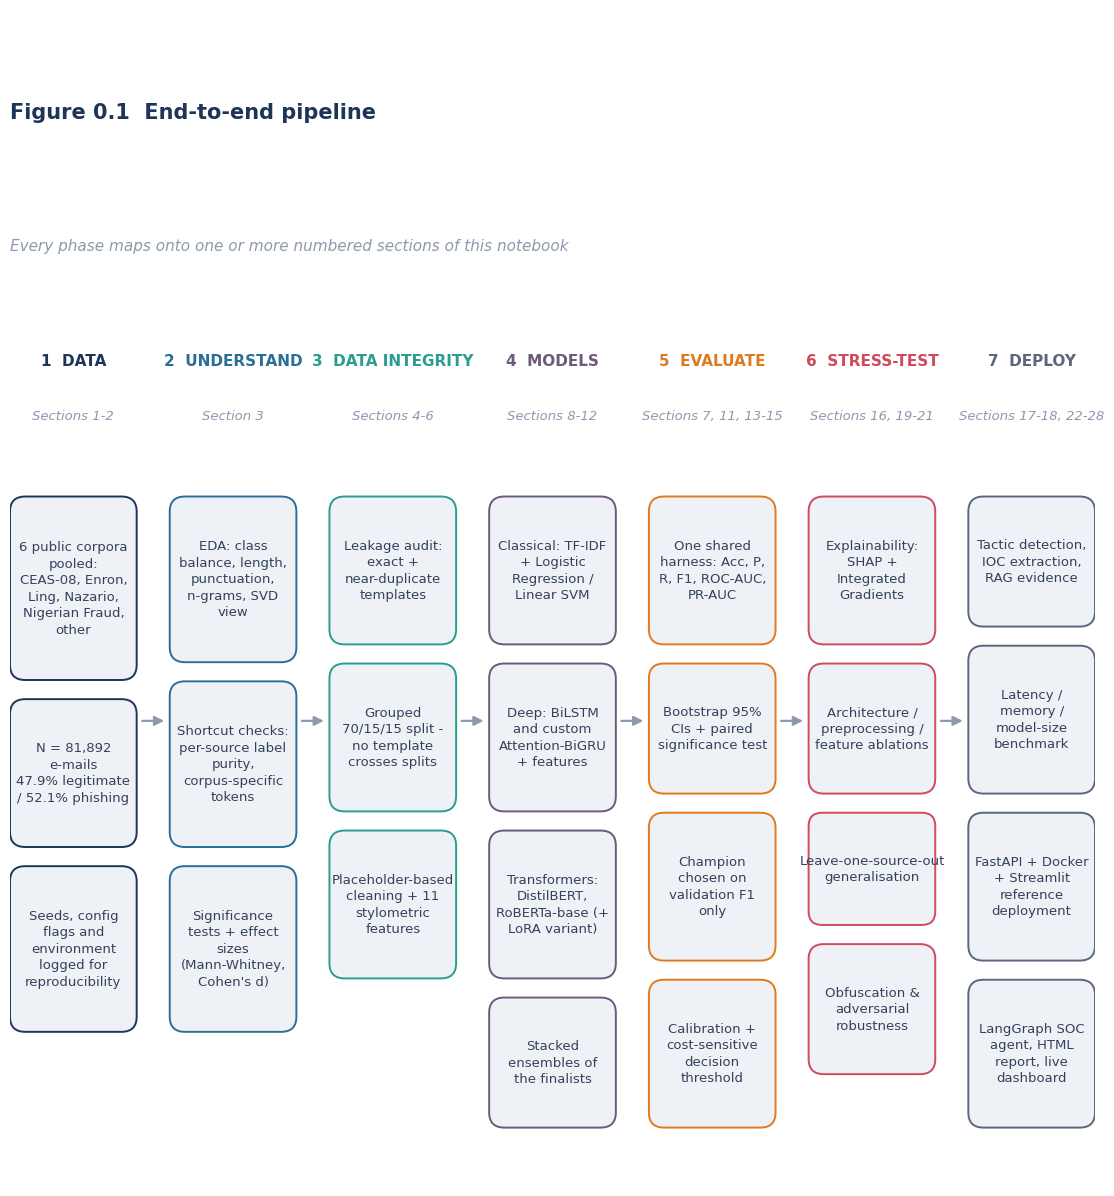

In [4]:
# Figure 0.1 -- end-to-end pipeline (presentation only)
_phases = [
    dict(name="1  DATA", sec="Sections 1-2", color="#1D3557", items=[
        "6 public corpora pooled: CEAS-08, Enron, Ling, Nazario, Nigerian Fraud, other",
        "N = 81,892 e-mails\n47.9% legitimate / 52.1% phishing",
        "Seeds, config flags and environment logged for reproducibility"]),
    dict(name="2  UNDERSTAND", sec="Section 3", color="#2A6F97", items=[
        "EDA: class balance, length, punctuation, n-grams, SVD view",
        "Shortcut checks: per-source label purity, corpus-specific tokens",
        "Significance tests + effect sizes (Mann-Whitney, Cohen's d)"]),
    dict(name="3  DATA INTEGRITY", sec="Sections 4-6", color="#2A9D8F", items=[
        "Leakage audit: exact + near-duplicate templates",
        "Grouped 70/15/15 split - no template crosses splits",
        "Placeholder-based cleaning + 11 stylometric features"]),
    dict(name="4  MODELS", sec="Sections 8-12", color="#6D597A", items=[
        "Classical: TF-IDF + Logistic Regression / Linear SVM",
        "Deep: BiLSTM and custom Attention-BiGRU + features",
        "Transformers: DistilBERT, RoBERTa-base (+ LoRA variant)",
        "Stacked ensembles of the finalists"]),
    dict(name="5  EVALUATE", sec="Sections 7, 11, 13-15", color="#E07A1F", items=[
        "One shared harness: Acc, P, R, F1, ROC-AUC, PR-AUC",
        "Bootstrap 95% CIs + paired significance test",
        "Champion chosen on validation F1 only",
        "Calibration + cost-sensitive decision threshold"]),
    dict(name="6  STRESS-TEST", sec="Sections 16, 19-21", color="#D1495B", items=[
        "Explainability: SHAP + Integrated Gradients",
        "Architecture / preprocessing / feature ablations",
        "Leave-one-source-out generalisation",
        "Obfuscation & adversarial robustness"]),
    dict(name="7  DEPLOY", sec="Sections 17-18, 22-28", color="#5C677D", items=[
        "Tactic detection, IOC extraction, RAG evidence",
        "Latency / memory / model-size benchmark",
        "FastAPI + Docker + Streamlit reference deployment",
        "LangGraph SOC agent, HTML report, live dashboard"]),
]
n = len(_phases)
gap = 0.6
col_w = 2.3
# NOTE (bugfix): the canvas width passed to flow_canvas used to be a fixed 17.5, while the
# column width below was computed as 15.5 / n (15.5 is this figure's *height*, not its
# width -- a copy-paste slip). For n=7 columns that put the last column's right edge at
# x=19.1, past the declared 17.5-wide canvas, so it was silently clipped off. The canvas
# width is now derived from the same column layout it has to contain, so they can never
# drift apart again.
total_w = n * col_w + (n - 1) * gap
fig, ax = flow_canvas(total_w, 15.5, "Figure 0.1  End-to-end pipeline",
                      "Every phase maps onto one or more numbered sections of this notebook")
for i, ph in enumerate(_phases):
    x = i * (col_w + gap)
    ax.text(x + col_w / 2, 15.0, ph["name"], ha="center", fontsize=mpl.rcParams["font.size"] - 1,
            fontweight="bold", color=ph["color"])
    ax.text(x + col_w / 2, 14.0, ph["sec"], ha="center", fontsize=mpl.rcParams["font.size"] - 2.5,
            color=C_GREY, style="italic")
    y = 12.6
    for item in ph["items"]:
        item_fs = mpl.rcParams["font.size"] - 2.5
        # NOTE (bugfix): height used to be guessed from the *un-wrapped* newline count
        # ("2.1 + 0.5 * item.count(chr(10))"), which ignored the extra line breaks that
        # word-wrapping introduces for long items -- boxes were then too short and their
        # text spilled into the box above/below. Ask flow_text_height for the height the
        # wrapped text will actually need at this font size, so the box always fits it.
        h = flow_text_height(ax, item, col_w * 0.9, item_fs)
        flow_box(ax, x, y - h, col_w, h, item, fc=C_LIGHT, ec=ph["color"], tc=C_SLATE,
                  fs=item_fs, lw=1.4)
        y -= h + 0.35
    if i < n - 1:
        flow_arrow(ax, (x + col_w + 0.05, 8.5), (x + col_w + gap - 0.05, 8.5), color=C_GREY, lw=1.6)
if "WORKING_DIR" in globals():
    fig.savefig(WORKING_DIR / "plots" / "fig_0_1_pipeline.png", dpi=170, bbox_inches="tight")
plt.show()


## About this notebook

Phishing e-mail is still one of the most common ways attackers gain a first foothold, and text classifiers sit at the
heart of most defences. Published scores for such classifiers are usually very high, but a score is only as trustworthy as
the data split, the selection protocol and the stress tests behind it. This notebook is a complete, reproducible study of
how good the best detectors *really* are, what they cost, and where they break.

**What it does, in seven steps** (see Figure 0.1 below):

1. **Loads and profiles** 81,892 e-mails pooled from six public corpora and checks them for shortcuts (Sections 1-3).
2. **Audits and repairs data leakage.** Exact and near-duplicate templates are clustered so that no template can appear in
   more than one of train, validation and test (Section 4).
3. **Prepares text and features** with placeholder-based cleaning and eleven stylometric features (Sections 5-6).
4. **Benchmarks six candidate models in three families** (classical, deep and Transformer), narrows them to five
   finalists on validation F1, and tests ensembles (Sections 7-12; Figure 0.2 shows the funnel).
5. **Evaluates rigorously** with bootstrap confidence intervals, paired significance tests, calibration and a
   cost-sensitive decision threshold (Sections 13-15).
6. **Stress-tests trust** through explainability, ablations, leave-one-source-out generalisation and obfuscation attacks
   (Sections 16 and 19-21).
7. **Delivers** analyst-facing extensions (social-engineering tactics, indicators of compromise, retrieval-grounded
   explanations and a LangGraph SOC agent), an efficiency benchmark and a FastAPI / Docker / Streamlit reference
   deployment (Sections 17-18 and 22-28).

### Headline findings (captured Kaggle T4 run)

- **Transformers win, modestly.** RoBERTa-base (selected on validation F1 = 0.9931) and DistilBERT reach test F1 of 0.9943
  and 0.9948, against 0.988 for the best classical model - roughly half as many mistakes on 12,109 test e-mails - but the
  two Transformers cannot be told apart statistically (p = 0.50).
- **The gain is expensive.** Fine-tuning took about 38 and 80 minutes, against 6-8 seconds for the TF-IDF models, and
  batched inference is about 34x slower (14.3 vs 0.42 ms per e-mail).
- **A purpose-built architecture did not pay off.** The custom Attention-BiGRU + features model was the weakest finalist
  (F1 = 0.984), and its ablations show no measurable benefit from attention pooling or engineered features.
- **In-distribution scores flatter the models.** F1 falls from 0.986 to 0.82-0.88 when a whole source corpus is held out,
  and corpus identifiers such as `enron` are among the most influential tokens.
- **Obfuscation is the weak spot, and fixable.** Leetspeak, homoglyphs and whitespace injection together cut RoBERTa's F1
  from 0.992 to 0.673; a character-normalisation defence recovers it to 0.824 (homoglyphs fully, to 0.992).
- **Cost-aware thresholds matter.** With a missed phishing e-mail assumed to cost 25x a false alarm, the cost-optimal
  threshold cuts expected validation cost by 20.2% and test misses from 42 to 23.

### How to read and run this notebook

- The 28 numbered sections are grouped into **Parts I-IX**. Each part banner lists the research questions (RQ1-RQ8) it
  addresses, and figure numbers follow section numbers (Figure 4.1 sits in Section 4).
- Blocks starting with **Interpretation** explain each result and quote numbers from the outputs directly above them.
- To reproduce the study: use a Kaggle GPU runtime (Tesla T4) with Internet enabled and **Run All**. The master switches
  are in Section 1 (`QUICK_RUN = True` gives a fast smoke test).
- **To personalise the notebook**, edit the first code cell (title, name, student ID, programme, supervisor, date, font
  sizes) and re-run it together with the title-page cell.

## Research Questions

The study is organised around eight research questions. Section 26 answers each of them with evidence from the
sections listed here.

| # | Research question | Where investigated |
|---|---|---|
| **RQ1** | **Accuracy.** Do fine-tuned pretrained Transformers detect phishing e-mails significantly better than tuned classical baselines and a purpose-built custom architecture, when all are evaluated on the same leakage-free split? | Sections 8-11, 13-14 |
| **RQ2** | **Cost.** What does any accuracy gain cost in training time, inference latency, throughput and model size, and does parameter-efficient fine-tuning (LoRA) close the gap? | Sections 9.5, 11, 23 |
| **RQ3** | **Design value.** Do the custom design choices (attention pooling, engineered stylometric features, text cleaning and ensembling) measurably improve detection? | Sections 6, 10, 12, 19 |
| **RQ4** | **Data integrity.** How prevalent are duplicate and near-duplicate templates in the pooled corpora, and how must they be handled for a fair comparison? | Sections 3-4 |
| **RQ5** | **Generalisation.** Do the models learn portable phishing language or corpus-specific shortcuts, and how well do they perform on a source they have never seen? | Sections 3.2-3.4, 16, 20 |
| **RQ6** | **Robustness.** How much does the selected model degrade under cheap, realistic obfuscation (leetspeak, homoglyphs, whitespace injection), and can simple normalisation help? | Section 21 |
| **RQ7** | **Decision-making.** Are the predicted probabilities well calibrated, and how should the operating threshold be set when a missed phishing e-mail costs far more than a false alarm? | Section 15 |
| **RQ8** | **Analyst value (exploratory).** Can the classifier's output be turned into analyst-ready evidence (tactics, indicators of compromise, retrieved guidance, risk tier) without letting an LLM override the verdict? | Sections 17-18, 22, 25 |


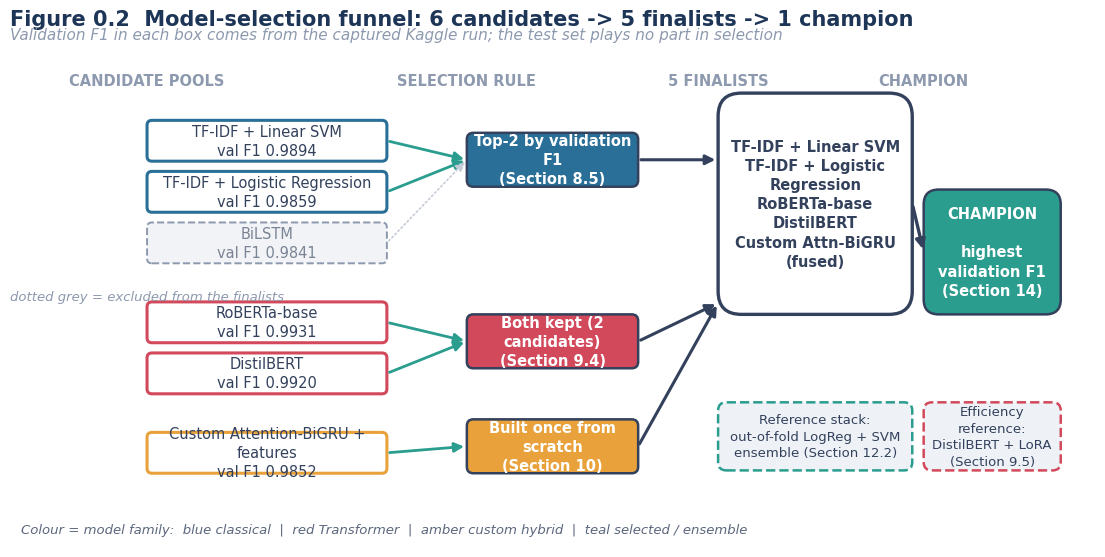

In [5]:
# Figure 0.2 -- from six candidates to one champion (validation F1 values are from the captured run)
# NOTE (bugfix): this used to call flow_canvas(17.5, 9.6, ...), but every coordinate drawn
# below (boxes out to x=184, y=85) uses a completely different, ~10x larger coordinate
# system. The axes limits therefore only covered a small corner of the real layout: every
# box (clipped to the axes) was invisible, and only the unclipped text remained, scattered
# across a huge auto-cropped canvas. flow_canvas's arguments must describe the actual
# extent of the content drawn inside it, so they are corrected to match here.
fig, ax = flow_canvas(190, 88, "Figure 0.2  Model-selection funnel: 6 candidates -> 5 finalists -> 1 champion",
                      "Validation F1 in each box comes from the captured Kaggle run; the test set plays no part in selection")
fs = mpl.rcParams["font.size"] - 1.5
for x, t in [(24, "CANDIDATE POOLS"), (80, "SELECTION RULE"), (124, "5 FINALISTS"), (160, "CHAMPION")]:
    ax.text(x, 81.5, t, ha="center", fontsize=fs, fontweight="bold", color=C_GREY)

cands = [  # (label, family colour, kept?, y)
    ("TF-IDF + Linear SVM\nval F1 0.9894", C_LEGIT, True, 68),
    ("TF-IDF + Logistic Regression\nval F1 0.9859", C_LEGIT, True, 59),
    ("BiLSTM\nval F1 0.9841", C_LEGIT, False, 50),
    ("RoBERTa-base\nval F1 0.9931", C_PHISH, True, 36),
    ("DistilBERT\nval F1 0.9920", C_PHISH, True, 27),
    ("Custom Attention-BiGRU + features\nval F1 0.9852", C_AMBER, True, 13),
]
boxes = []
for lab, col, kept, y in cands:
    b = flow_box(ax, 24, y, 42, 7.2, lab, fc="white" if kept else "#F1F3F6", ec=col if kept else C_GREY,
                 tc=C_SLATE if kept else "#7B8494", fs=fs, lw=2.2 if kept else 1.4, ls="-" if kept else "--")
    boxes.append((b, kept))

gates = [("Top-2 by validation F1\n(Section 8.5)", 63.5, C_LEGIT),
         ("Both kept (2 candidates)\n(Section 9.4)", 31.5, C_PHISH),
         ("Built once from scratch\n(Section 10)", 13, C_AMBER)]
gb = [flow_box(ax, 80, y, 30, 9.5, t, fc=c, tc="white", fs=fs, bold=True) for t, y, c in gates]

groups = [(0, 1, 2, 0), (3, 4, 4, 1), (5, 5, 5, 2)]
for a, b, c, gi in groups:
    for k in range(a, c + 1):
        bx, kept = boxes[k]
        flow_arrow(ax, bx["r"], (gb[gi]["l"][0], gb[gi]["y"]), color=C_TEAL if kept else "#C5CBD6",
                   lw=2.0 if kept else 1.2, ls="-" if kept else ":", rad=0.0)
ax.text(24, 43.6, "dotted grey = excluded from the finalists", fontsize=fs - 1, color=C_GREY, ha="center", style="italic")

fin = flow_box(ax, 124, 41, 34, 39,
               "TF-IDF + Linear SVM\nTF-IDF + Logistic Regression\nRoBERTa-base\nDistilBERT\nCustom Attn-BiGRU (fused)",
               fc="white", ec=C_SLATE, tc=C_SLATE, fs=fs, lw=2.4, bold=True)
for g in gb:
    # NOTE (bugfix): the target y used to be clamped to the hardcoded range [27, 55], which
    # was leftover from an earlier layout -- the "5 finalists" box actually spans y=41 to
    # y=80, so two of the three arrows were clamped to y-values *below* the box entirely and
    # never visibly reached it. Clamp to the box's own (current) vertical span instead.
    target_y = min(max(g["y"], fin["b"][1] + 2), fin["t"][1] - 2)
    flow_arrow(ax, g["r"], (fin["l"][0], target_y), color=C_SLATE, lw=2.2)

champ = flow_box(ax, 160, 41, 24, 22, "CHAMPION\n\nhighest validation F1\n(Section 14)", fc=C_TEAL, tc="white",
                 fs=fs, bold=True)
flow_arrow(ax, fin["r"], champ["l"], color=C_SLATE, lw=2.4)

flow_box(ax, 124, 13.5, 34, 12, "Reference stack: out-of-fold LogReg + SVM ensemble (Section 12.2)",
         fc=C_LIGHT, ec=C_TEAL, tc=C_SLATE, fs=fs - 1, ls="--")
flow_box(ax, 160, 13.5, 24, 12, "Efficiency reference: DistilBERT + LoRA (Section 9.5)", fc=C_LIGHT, ec=C_PHISH,
         tc=C_SLATE, fs=fs - 1, ls="--")
ax.text(2, 2.5, "Colour = model family:  blue classical  |  red Transformer  |  amber custom hybrid  |  teal selected / ensemble",
        fontsize=fs - 1, color="#5C677D", style="italic")
if "WORKING_DIR" in globals():
    fig.savefig(WORKING_DIR / "plots" / "fig_0_2_funnel.png", dpi=170, bbox_inches="tight")
plt.show()


## Notebook map

This study is split into seven notebooks for easier reading. Each one keeps the **executed outputs** of the full Kaggle T4 run.

| Notebook | Topic | Scope |
|---|---|---|
| [01](01_data_eda_and_leakage_safe_split.ipynb) | Data, EDA & Leakage-Safe Split | Parts I-II · Sections 1-6 |
| [02](02_model_development_and_ensembles.ipynb) | Model Development, Benchmark & Ensembles | Part III · Sections 7-12 |
| [03](03_statistical_evaluation_calibration_xai.ipynb) | Statistical Evaluation, Calibration & Explainability | Part IV · Sections 13-16 |
| [04](04_threat_intelligence_tactics_and_iocs.ipynb) | Threat Intelligence: Tactics & IOCs | Part V · Sections 17-18 |
| [05](05_ablation_generalisation_robustness.ipynb) | Ablation, Generalisation & Adversarial Robustness | Part VI · Sections 19-21 |
| [06](06_rag_latency_deployment_soc_agent.ipynb) | RAG, Latency, Deployment & LangGraph SOC Agent | Part VII · Sections 22-25 |
| [07](07_conclusions_report_dashboard.ipynb) | Conclusions, HTML Report & Dashboard | Parts VIII-IX · Sections 26-28 & Appendix |
| [00](00_full_pipeline_run_all.ipynb) | **Full pipeline - run this to reproduce everything** | Parts I-IX |


## Scope, Contributions and Data Requirements

This notebook consolidates and substantially extends two source notebooks (`02_ml_baselines.ipynb` and
`03_transformer_benchmark.ipynb`) into a single, reproducible pipeline. Beyond merging them, it adds:

- **Deeper EDA:** class balance, per-source label purity, length distributions, vocabulary and n-gram analysis.
- **Data-leakage prevention that covers *every* model**, not just the Transformers. In the original notebooks the classical
  baselines were trained on a randomly split train/val/test set, and only the Transformer notebook later discovered that
  this split leaked duplicate and near-duplicate templates and re-split the data, so the baseline numbers and the
  Transformer numbers were never comparable. Here the leakage audit and grouped re-split happen **once, up front**, before
  any model is trained, so all five final models are evaluated on the same clean split.
- **Advanced preprocessing and feature engineering:** placeholder-based text normalisation (to reduce template
  memorisation) and hand-crafted stylometric, URL and urgency-keyword features.
- **Five finalist models**, each tuned or fine-tuned, selected from three candidate pools:
  1. **Classical baselines** (candidates: TF-IDF + LogReg, TF-IDF + LinearSVM, BiLSTM) -> **top 2** carried forward.
  2. **Pretrained Transformers** (candidates: DistilBERT, RoBERTa-base) -> **both** carried forward, plus a parameter-efficient
     LoRA variant of DistilBERT as an efficiency reference (Section 9.5).
  3. **One custom architecture**, built from scratch: a BiGRU + additive-attention encoder fused with the engineered numeric
     features (no pretrained checkpoint).
- A single consolidated benchmark table, a **validation-based best-model selection**, deep-dive evaluation and error analysis.

**Data expected:** a phishing-e-mail dataset with (at minimum) a raw `text` column, a binary `label` column (`1` = phishing,
`0` = legitimate) and ideally a `source` column (this project's corpus pools CEAS, Enron, Nigerian Fraud, Ling, Nazario and
other sources). The loader in Section 2 is defensive: it uses pre-split `train.csv` / `val.csv` / `test.csv` if present,
falls back to a single raw file and splits it itself, and only if no data is found generates a small synthetic sample so the
whole notebook can still be smoke-run top to bottom.

**Compute:** the classical baselines run on CPU. The custom BiGRU benefits from a GPU but works on CPU for a quick run. The
Transformer section needs a GPU and access to the Hugging Face Hub; set `RUN_TRANSFORMERS = False` in Section 1 to skip it.


<a id="partI"></a>

<div style="background:#1D3557;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part I</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Foundations</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 1-2 &nbsp;&middot;&nbsp; Research questions: -</div>
</div>


<a id="sec1"></a>

## 1. Environment, Reproducibility & Configuration

Every random-number source is seeded, the run mode is controlled from one
config cell (so the whole notebook can be switched between a fast smoke-test
and a full run), and package versions are logged for reproducibility.

In [6]:
import os, sys, json, time, glob, random, warnings, platform
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Master configuration — change these, not the logic below.
# ---------------------------------------------------------------------------
SEED = 42

QUICK_RUN =False         # True: tiny epochs / small grids, fast sanity run.
                           # False: full-scale training for real results.
RUN_TRANSFORMERS = True   # Requires a GPU + a way to obtain the pretrained weights: either
                           # live Hugging Face Hub access, OR the three base checkpoints attached
                           # as a Kaggle Model/Dataset input (see resolve_checkpoint_source() in
                           # Section 9 -- it tries the Hub first, then falls back to a matching
                           # /kaggle/input/... folder). If NEITHER is reachable, Section 9's own
                           # connectivity probe sets this back to False automatically and the
                           # notebook reports the gap explicitly instead of crashing. Note this is
                           # a GPU/network requirement, not a GPU-only one: a GPU without a route
                           # to fetch the weights still cannot fine-tune.
RUN_HP_SEARCH = True      # Small hyperparameter grids for every model family.

# --- New for the extended, distinction-level analysis sections below ---
RUN_LORA = True            # Section 9.5: LoRA/PEFT fine-tuning (needs `peft`; skipped gracefully if absent).
RUN_SHAP = True            # Section 16: SHAP explanations (needs `shap`; skipped gracefully if absent).
RUN_IG = True              # Section 16: Integrated Gradients (needs `captum`; skipped gracefully if absent).
RUN_ADVERSARIAL = True     # Section 21: obfuscation/adversarial robustness stress test.
RUN_RAG_DEMO = True        # Section 22: local (offline) retrieval-augmented explanation demo.
RUN_DEPLOYMENT_ARTIFACTS = True  # Section 24: write FastAPI/Docker/Streamlit files to disk.

N_BOOTSTRAP = 300 if QUICK_RUN else 2000   # resamples for bootstrap CIs / significance tests.

# SOC cost model for security-aware thresholding (Section 15): a missed phishing
# email (false negative) is assumed to be far costlier than a false alarm that a
# human analyst dismisses in seconds -- tune these to your organisation's reality.
COST_FALSE_NEGATIVE = 25.0
COST_FALSE_POSITIVE = 1.0

TEST_FRAC = 0.15
VAL_FRAC_OF_REMAINDER = 0.15 / (1 - TEST_FRAC)   # ~0.176, matches 70/15/15 overall

WORKING_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./working")
for sub in ["tables", "plots", "models", "results", "audit"]:
    (WORKING_DIR / sub).mkdir(parents=True, exist_ok=True)

def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

set_global_seed(SEED)

try:
    import torch
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except ImportError:
    torch = None
    DEVICE = None

# Used throughout the notebook to gracefully skip torch-dependent sections
# (BiLSTM, the custom hybrid model, its ablations, Integrated Gradients) on a
# machine/kernel where torch simply isn't installed, instead of crashing.
TORCH_AVAILABLE = torch is not None

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Device:", DEVICE)
if torch is not None and torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
elif RUN_TRANSFORMERS:
    print("[WARNING] No GPU detected. Fine-tuning three Transformer encoders "
          "on CPU is impractically slow. Set RUN_TRANSFORMERS = False above "
          "for a logic-only run, or switch to a GPU runtime.")

ENV_INFO = {"timestamp": datetime.utcnow().isoformat(), "seed": SEED,
            "quick_run": QUICK_RUN, "device": str(DEVICE)}
with open(WORKING_DIR / "audit" / "environment.json", "w") as f:
    json.dump(ENV_INFO, f, indent=2, default=str)

Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Device: cuda
GPU: Tesla T4


<a id="sec2"></a>

## 2. Data Loading

Priority order:
1. Pre-split `train.csv` / `val.csv` / `test.csv` (from an earlier pipeline
   stage) if attached as input.
2. A single raw file (`*.csv`) containing at least `text`/`text_clean` and
   `label` columns — split ourselves later, **after** the leakage audit below.
3. If neither is found, generate a small synthetic phishing/legitimate email
   sample so the rest of the notebook can still be executed end-to-end as a
   correctness check.

We deliberately do **not** finalise train/val/test here — that happens in
Section 4, after the leakage audit, so every model trains and is evaluated on
the same leak-free split.

In [7]:
def _is_our_own_output(path):
    '''Guards against a re-run of this notebook picking up its own
    intermediate artifacts (e.g. working/audit/train_deduped.csv) as if they
    were a fresh raw dataset -- which would silently shrink/re-split an
    already-split subset instead of using the real data.'''
    norm = os.path.normpath(path)
    working_norm = os.path.normpath(str(WORKING_DIR))
    return norm.startswith(working_norm + os.sep) or norm == working_norm


# ---------------------------------------------------------------------------
# Known per-source files of the Kaggle "Phishing Email Dataset"
# (naserabdullahalam/phishing-email-dataset), which pools CEAS-08, Enron,
# Ling-Spam, Nazario, Nigerian Fraud and SpamAssassin. This dataset ships as
# SEPARATE per-source CSVs, not one combined file. A loader that only ever
# grabs "the one biggest CSV it can find" (a bug this revision fixes -- see
# below) would silently pick a single source (almost always Enron, by far
# the largest file) and use ONLY that source, while every downstream
# per-source EDA cell (3.2), the leakage-risk audit (4.4) and the
# cross-source generalisation test (Section 20) would then run on a
# single-source column that is either absent or trivially constant --
# quietly invalidating exactly the "pools five email corpora" claim made in
# this notebook's own introduction. We therefore search for every known
# per-source file explicitly and POOL all of them, tagging each row with its
# true source, before falling back to a single-file or synthetic dataset.
KNOWN_SOURCE_FILES = {
    "ceas":            ["ceas_08.csv", "ceas.csv", "ceas_08_dataset.csv"],
    "enron":           ["enron.csv"],
    "ling":            ["ling.csv"],
    "nazario":         ["nazario.csv"],
    "nigerian_fraud":  ["nigerian_fraud.csv", "nigerianfraud.csv", "nigerian.csv"],
    "spamassassin":    ["spamassasin.csv", "spamassassin.csv"],
    "trec_05":         ["trec_05.csv"],
    "trec_06":         ["trec_06.csv"],
    "trec_07":         ["trec_07.csv"],
}
# Some re-uploads of this dataset also ship (or are replaced by) a single
# already-combined file. We still prefer pooling the per-source files above
# when both are present, since that's the only way to get a real `source`
# column for Sections 3.2/4.4/20 -- but we fall back to a combined file if
# no per-source file is found at all.
COMBINED_FILE_NAMES = ["phishing_email.csv", "phishing_email_combined.csv", "combined_data.csv"]


def _standardise_source_frame(raw, source_key):
    '''Map one per-source CSV's own column layout onto this notebook's
    canonical schema (text, label, source). Handles the two layouts these
    corpora actually use (documented in multiple papers building on this
    dataset): Enron/Ling ship subject+body+label; CEAS/Nazario/Nigerian
    Fraud/SpamAssassin ship sender/receiver/date/subject/body/label. Also
    tolerant of a pre-combined `text`/`text_combined` column, and of string
    labels, in case a differently-preprocessed copy of the dataset is used.'''
    df = raw.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]

    if "text_combined" in df.columns:
        text = df["text_combined"].astype(str)
    elif "text" in df.columns:
        text = df["text"].astype(str)
    elif {"subject", "body"}.issubset(df.columns):
        text = (df["subject"].fillna("").astype(str) + " "
                + df["body"].fillna("").astype(str)).str.strip()
    elif "body" in df.columns:
        text = df["body"].astype(str)
    else:
        raise ValueError(f"no recognisable text column in columns {list(df.columns)}")

    if "label" not in df.columns:
        raise ValueError("no 'label' column")
    label_raw = df["label"]
    if label_raw.dtype == object:
        label_map = {"phishing": 1, "phish": 1, "spam": 1, "1": 1, "true": 1,
                     "legitimate": 0, "legit": 0, "ham": 0, "0": 0, "false": 0}
        label = (label_raw.astype(str).str.strip().str.lower()
                 .map(label_map))
        if label.isna().any():
            label = pd.to_numeric(label_raw, errors="coerce")
    else:
        label = pd.to_numeric(label_raw, errors="coerce")

    out = pd.DataFrame({"text": text, "label": label, "source": source_key})
    return out.dropna(subset=["text", "label"])


def find_known_source_files(search_roots):
    '''Return {source_key: filepath} for every known per-source file found
    under the given roots (first match wins per source key).'''
    found = {}
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            if _is_our_own_output(dirpath):
                continue
            lower_map = {fn.lower(): fn for fn in filenames}
            for source_key, patterns in KNOWN_SOURCE_FILES.items():
                if source_key in found:
                    continue
                for pat in patterns:
                    if pat in lower_map:
                        found[source_key] = os.path.join(dirpath, lower_map[pat])
                        break
    return found


def find_combined_file(search_roots):
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            if _is_our_own_output(dirpath):
                continue
            lower_map = {fn.lower(): fn for fn in filenames}
            for pat in COMBINED_FILE_NAMES:
                if pat in lower_map:
                    return os.path.join(dirpath, lower_map[pat])
    return None


def find_data():
    search_roots = ["/kaggle/input", "/kaggle/working", "."]
    presplit_names = {"train.csv", "val.csv", "test.csv"}

    # 1. Pre-split CSVs from an earlier pipeline stage take priority.
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            if _is_our_own_output(dirpath):
                continue
            if presplit_names.issubset(set(filenames)):
                return "presplit", dirpath

    # 2. The Kaggle "Phishing Email Dataset" as separate per-source files --
    #    pool every one we can find so `source` is real, not degenerate.
    known_files = find_known_source_files(search_roots)
    if len(known_files) >= 2:
        return "kaggle_multi", known_files

    # 3. A single already-combined file with the dataset's own naming.
    combined = find_combined_file(search_roots)
    if combined is not None:
        return "combined", combined

    # 4. Any other CSV that merely looks like a raw email dataset. Prefer the
    #    LARGEST matching file, and never consider our own outputs or a lone
    #    known-source file already covered by branch 2 (if only one such file
    #    exists, e.g. just Enron.csv attached alone, it is deliberately
    #    still usable here -- single-source is honestly reported, not pooled).
    candidates = []
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            if _is_our_own_output(dirpath):
                continue
            for fn in filenames:
                if fn.lower().endswith(".csv"):
                    candidates.append(os.path.join(dirpath, fn))
    matches = []
    for path in candidates:
        try:
            head = pd.read_csv(path, nrows=5)
        except Exception:
            continue
        cols = {c.lower() for c in head.columns}
        if "label" in cols and ({"text", "text_clean", "text_combined", "body"} & cols):
            matches.append((path, os.path.getsize(path)))
    if matches:
        matches.sort(key=lambda x: x[1], reverse=True)
        return "raw", matches[0][0]

    return "none", None


def make_synthetic_dataset(n=4000, seed=SEED):
    '''Small synthetic fallback so the notebook is runnable without real
    data attached. Deliberately noisy and imperfectly separable -- this is
    NOT meant to produce meaningful research results, only to exercise every
    code path.'''
    rng = np.random.RandomState(seed)
    # More templates (and more wording variety within each one) than a first pass
    # might reach for -- deliberately so. With only ~5 templates per class, the
    # leak-safe grouped split in Section 4.3 collapses to ~10 near-duplicate
    # clusters, and a GroupShuffleSplit over that few groups can easily place every
    # cluster of one class into val or test by chance, leaving that split
    # single-class (a real bug this revision hit and fixed defensively in Section
    # 4.3 -- but the *first* line of defence is simply giving the grouped split
    # enough distinct clusters to work with).
    phishing_templates = [
        "Urgent: verify your account now at {url} or it will be suspended",
        "Dear customer, your password has expired, click {url} to reset immediately",
        "You have won a prize! Claim it now at {url} before it expires",
        "Security alert: unusual login detected, confirm identity at {url}",
        "Your invoice is overdue, pay now via {url} to avoid penalty",
        "Final notice: your account access will be revoked, verify now at {url}",
        "We detected a problem with your billing info, update it at {url} today",
        "Your package could not be delivered, reschedule at {url} within 24 hours",
        "Action required: confirm your identity at {url} to avoid account closure",
        "Congratulations, you're eligible for a refund, claim it at {url} now",
        "Your subscription payment failed, update your card at {url} immediately",
        "IT Security: your mailbox is over quota, resolve this at {url} or lose access",
        "Unusual sign-in attempt blocked, review the activity at {url} right away",
        "Your document is ready for e-signature, view and sign at {url}",
        "Compliance notice: your tax records need review, log in at {url} today",
    ]
    legit_templates = [
        "Hi team, attaching the quarterly report for review, let me know your thoughts",
        "Reminder: the project meeting is scheduled for Tuesday at 10am",
        "Thanks for your help yesterday, the deployment went smoothly",
        "Please find the updated spreadsheet attached for the budget discussion",
        "Lunch on Friday to celebrate the release? Let me know if you're free",
        "Here are the notes from this morning's standup, let me know if I missed anything",
        "Could you review the pull request when you get a chance? No rush",
        "Happy to catch up next week, does Wednesday afternoon work for you?",
        "The client approved the proposal, great work everyone on the team",
        "Sending over the slide deck ahead of tomorrow's presentation",
        "Just a heads up, the office will be closed on Monday for the holiday",
        "Congrats on the launch! The numbers look really promising so far",
        "Can you share the latest version of the design mockups when ready",
        "Following up on our call, here's a summary of the action items",
        "Welcome to the team! Let me know if you need anything to get set up",
    ]
    sources = ["ceas", "enron", "nigerian_fraud", "ling", "nazario", "spamassassin"]
    rows = []
    for i in range(n):
        is_phish = rng.rand() < 0.5
        templates = phishing_templates if is_phish else legit_templates
        base = templates[rng.randint(len(templates))]
        url = f"http://secure-{rng.randint(1000,9999)}-verify.example.com"
        text = base.format(url=url) + f" (ref#{rng.randint(100000,999999)})"
        source = rng.choice(sources, p=[0.3, 0.25, 0.1, 0.1, 0.1, 0.15])
        rows.append({"text": text, "label": int(is_phish), "source": source})
    return pd.DataFrame(rows)


_mode, _loc = find_data()

if _mode == "presplit":
    print(f"[Data] Found pre-split train/val/test in: {_loc}")
    train_df = pd.read_csv(f"{_loc}/train.csv")
    val_df = pd.read_csv(f"{_loc}/val.csv")
    test_df = pd.read_csv(f"{_loc}/test.csv")
    full_df = pd.concat(
        [train_df.assign(_orig_split="train"),
         val_df.assign(_orig_split="val"),
         test_df.assign(_orig_split="test")],
        ignore_index=True,
    )
    DATA_SOURCE_NOTE = f"pre-split CSVs from {_loc}"
elif _mode == "kaggle_multi":
    print(f"[Data] Found {len(_loc)} known per-source files of the Kaggle "
          "'Phishing Email Dataset' under /kaggle/input -- pooling all of them "
          "(this is the real, multi-source run the notebook's introduction describes):")
    frames = []
    for source_key in sorted(_loc):
        path = _loc[source_key]
        try:
            raw = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip", low_memory=False)
            std = _standardise_source_frame(raw, source_key)
            frames.append(std)
            print(f"  + {source_key:15s} {os.path.basename(path):22s} "
                  f"{len(raw):>7,} raw rows -> {len(std):>7,} usable rows")
        except Exception as e:
            print(f"  ! {source_key:15s} {os.path.basename(path):22s} "
                  f"FAILED to load/standardise ({e}) -- excluded from the pool")
    if not frames:
        raise RuntimeError("Known per-source files were found but none could be parsed -- "
                            "check KNOWN_SOURCE_FILES / _standardise_source_frame above.")
    full_df = pd.concat(frames, ignore_index=True)
    DATA_SOURCE_NOTE = (f"Kaggle 'Phishing Email Dataset' (naserabdullahalam) -- "
                         f"{len(frames)}/{len(KNOWN_SOURCE_FILES)} known source files pooled: "
                         f"{', '.join(f['source'].iloc[0] for f in frames)}")
elif _mode == "combined":
    print(f"[Data] Found a single already-combined dataset file: {_loc}")
    full_df = _standardise_source_frame(pd.read_csv(_loc, low_memory=False), "unknown")
    DATA_SOURCE_NOTE = f"combined dataset file {_loc} (per-source breakdown not available)"
elif _mode == "raw":
    print(f"[Data] Found a single raw dataset (not one of the known multi-source "
          f"filenames -- using as-is, single source): {_loc}")
    full_df = pd.read_csv(_loc, low_memory=False)
    DATA_SOURCE_NOTE = f"single raw dataset {_loc} (only one source file was attached)"
else:
    print("[Data] No dataset found on disk (checked /kaggle/input, /kaggle/working, '.') -- "
          "generating a small SYNTHETIC sample so this notebook can still be run/checked "
          "end-to-end. This run's numbers are a code-correctness smoke test only, NOT a "
          "research result -- attach the real dataset (e.g. as a Kaggle input) for that.")
    full_df = make_synthetic_dataset(n=(600 if QUICK_RUN else 4000))
    DATA_SOURCE_NOTE = "SYNTHETIC placeholder data (no real dataset attached)"

USED_SYNTHETIC_DATA = (_mode == "none")

# Normalise column names: we standardise on a raw "text" column and a
# "text_clean" column (cleaned in Section 5). If only "text_clean" exists,
# treat it as both for now.
if "text" not in full_df.columns and "text_clean" in full_df.columns:
    full_df["text"] = full_df["text_clean"]
if "text_clean" not in full_df.columns:
    full_df["text_clean"] = full_df["text"]

full_df = full_df.dropna(subset=["text", "label"]).reset_index(drop=True)
full_df["label"] = full_df["label"].astype(int)
if "source" not in full_df.columns:
    full_df["source"] = "unknown"

print(f"\nData source: {DATA_SOURCE_NOTE}")
print("Shape:", full_df.shape)
print("Sources pooled:", full_df["source"].value_counts().to_dict())
print(full_df["label"].value_counts(normalize=True).round(3))
full_df.head(3)


[Data] Found pre-split train/val/test in: /kaggle/input/datasets/drspoorthihs/notebook-01-phishing

Data source: pre-split CSVs from /kaggle/input/datasets/drspoorthihs/notebook-01-phishing
Shape: (81892, 6)
Sources pooled: {'ceas': 38963, 'enron': 29423, 'unknown': 5802, 'nigerian': 3293, 'ling': 2859, 'nazario': 1552}
label
1    0.521
0    0.479
Name: proportion, dtype: float64


,text_clean,subject,label,source,_orig_split,text
0,important message - make it longer > longer or...,important message - make it longer,1,enron,train,important message - make it longer > longer or...
1,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,CNN.com Daily Top 10,1,ceas,train,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...
2,"fw : pg peters , jerry ; hayslett , rod subjec...","fw : pg peters , jerry ; hayslett , rod",0,enron,train,"fw : pg peters , jerry ; hayslett , rod subjec..."


<a id="partII"></a>

<div style="background:#2A6F97;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part II</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Data Understanding &amp; Integrity</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 3-6 &nbsp;&middot;&nbsp; Research questions: RQ3, RQ4, RQ5</div>
</div>


<a id="sec3"></a>

## 3. Exploratory Data Analysis

Everything here runs on `full_df` — the **pooled** data, before any
train/val/test split — so class-balance and vocabulary observations aren't
biased by an arbitrary split, and so we can spot leakage risks (like a
`source` that is 100% one class) before they contaminate a split.

### 3.1 Class balance and dataset size

Total rows: 81,892
Class counts:
label
0    39254
1    42638
Name: count, dtype: int64
Class %:
label
0    47.93
1    52.07
Name: count, dtype: float64
Imbalance ratio (majority/minority): 1.09


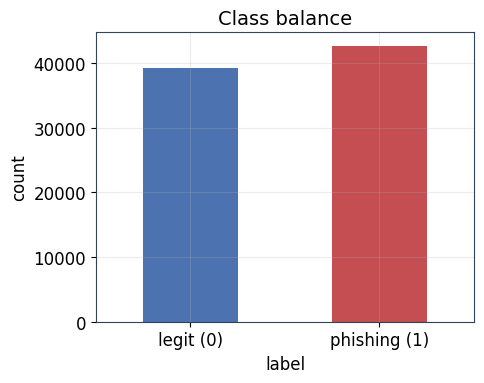

In [8]:
n_total = len(full_df)
class_counts = full_df["label"].value_counts().sort_index()
class_pct = (class_counts / n_total * 100).round(2)
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"Total rows: {n_total:,}")
print(f"Class counts:\n{class_counts}")
print(f"Class %:\n{class_pct}")
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")

# Force the Jupyter/VSCode INLINE backend explicitly. Merely avoiding an explicit
# matplotlib.use("Agg") is not enough: on a headless machine (no DISPLAY -- common
# in remote/SSH/containerized VSCode sessions, and on Kaggle) matplotlib's own
# auto-detection falls back to Agg anyway, which reproduces the exact same silent
# "plt.show() runs fine but nothing appears" symptom. get_ipython() is provided
# automatically inside any real Jupyter/IPython kernel, so this reliably switches
# to the inline backend there; the try/except is just so this cell does not blow up
# if it is ever executed outside a notebook kernel (e.g. `jupyter nbconvert --to script`).
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
import matplotlib.pyplot as plt

# Every plot in this notebook also calls plt.savefig(...) into WORKING_DIR / "plots"
# regardless of backend -- if inline display still does not show up in your particular
# editor/UI, open the PNGs there directly; they are the same figures.

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["legit (0)", "phishing (1)"], rotation=0)
ax.set_title("Class balance")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "class_balance.png", dpi=130)
plt.show()

> **Interpretation.** The combined corpus is close to balanced (39,254 legitimate vs.
> 42,638 phishing emails — 47.9% / 52.1%, imbalance ratio 1.09×), so plain accuracy remains a
> meaningful headline metric here, unlike in a heavily skewed detection task. F1 and recall are
> nonetheless kept as the primary metrics throughout (Section 7) in case a real deployment
> population turns out less balanced than this pooled dataset.


### 3.2 Per-source distribution and label purity

A `source` column that is (near-)perfectly correlated with the label is a
**leakage risk in its own right**: a model could learn "which corpus does
this formatting come from" instead of "is this phishing", and that shortcut
would evaporate on new, unseen mail sources. We flag any source whose label
purity exceeds a threshold so it can be excluded as a feature later (Section
4.4) even though it's still useful, here, as a diagnostic.

              n  phishing_rate  purity  high_leakage_risk
source                                                   
ceas      38963          0.556   0.556              False
enron     29423          0.474   0.526              False
unknown    5802          0.295   0.705              False
nigerian   3293          1.000   1.000               True
ling       2859          0.160   0.840              False
nazario    1552          1.000   1.000               True

Sources with >= 98% label purity (source name alone almost determines the label): ['nigerian', 'nazario']


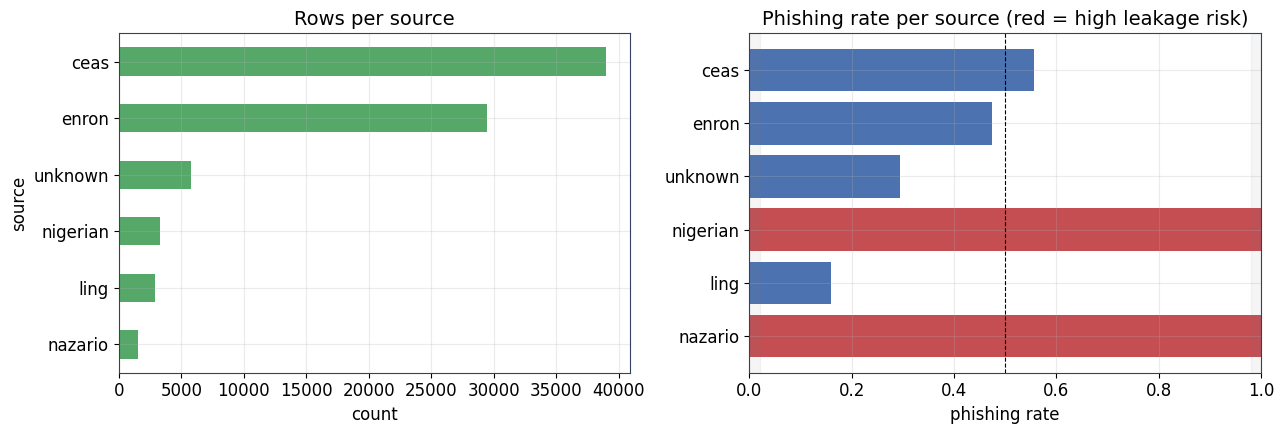

In [9]:
source_summary = (
    full_df.groupby("source")["label"]
    .agg(n="count", phishing_rate="mean")
    .sort_values("n", ascending=False)
)
source_summary["purity"] = source_summary["phishing_rate"].apply(lambda p: max(p, 1 - p))
HIGH_PURITY_THRESHOLD = 0.98
source_summary["high_leakage_risk"] = source_summary["purity"] >= HIGH_PURITY_THRESHOLD

print(source_summary.round(3).to_string())
risky_sources = source_summary[source_summary["high_leakage_risk"]].index.tolist()
print(f"\nSources with >= {HIGH_PURITY_THRESHOLD:.0%} label purity "
      f"(source name alone almost determines the label): {risky_sources}")

source_summary.to_csv(WORKING_DIR / "tables" / "source_label_purity.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
source_summary["n"].sort_values().plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title("Rows per source")
axes[0].set_xlabel("count")

sorted_purity = source_summary.sort_values("n")
bar_colors = ["#C44E52" if hi else "#4C72B0" for hi in sorted_purity["high_leakage_risk"]]
axes[1].barh(sorted_purity.index, sorted_purity["phishing_rate"], color=bar_colors)
axes[1].axvline(0.5, color="black", linewidth=0.8, linestyle="--")
axes[1].axvspan(0, 1 - HIGH_PURITY_THRESHOLD, color="gray", alpha=0.08)
axes[1].axvspan(HIGH_PURITY_THRESHOLD, 1, color="gray", alpha=0.08)
axes[1].set_xlim(0, 1)
axes[1].set_title("Phishing rate per source (red = high leakage risk)")
axes[1].set_xlabel("phishing rate")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "source_distribution.png", dpi=130)
plt.show()

> **Interpretation.** Two of the six sources — *Nigerian Fraud* and *Nazario* — are 100%
> phishing, and no source falls below ~53% purity. `source` is therefore a near-perfect predictor
> of the label for at least two corpora: exactly the shortcut a model could learn instead of
> genuine phishing language. This is why `source` is excluded from every model's input features
> (Section 4.4), despite being highly informative here.


### 3.3 Text length distribution by class

Extreme, class-correlated length differences are themselves a shortcut a
model can exploit instead of learning content — worth knowing about even if
we don't act on it directly.

label                          0             1
_word_count count   39254.000000  4.263800e+04
            mean      364.018546  2.017815e+02
            std       865.521166  7.450825e+02
            min         2.000000  2.000000e+00
            25%        95.000000  4.000000e+01
            50%       190.000000  8.800000e+01
            75%       377.000000  2.640000e+02
            max     45450.000000  1.271270e+05
_char_count count   39254.000000  4.263800e+04
            mean     2142.636139  1.386621e+03
            std      5250.526150  2.278490e+04
            min        16.000000  3.000000e+00
            25%       554.000000  2.370000e+02
            50%      1092.000000  4.890000e+02
            75%      2126.000000  1.471000e+03
            max    299251.000000  4.560761e+06


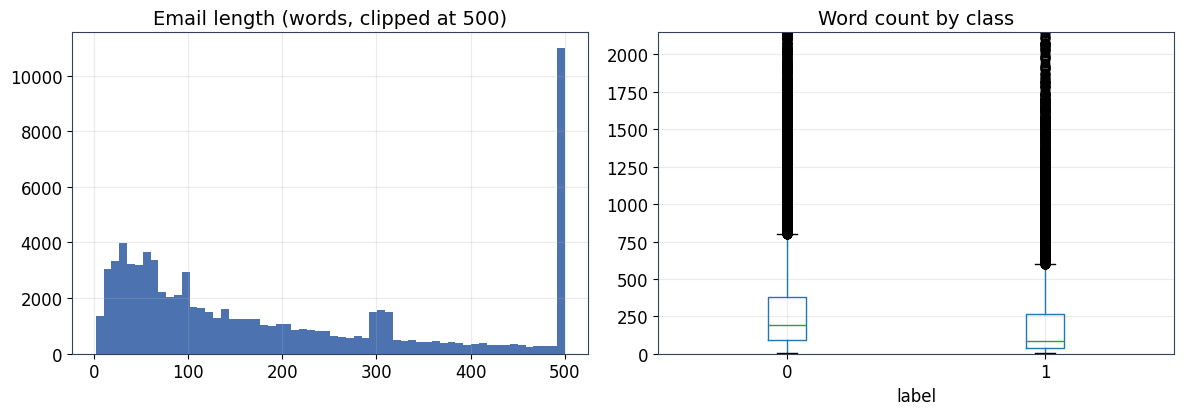

In [10]:
full_df["_word_count"] = full_df["text"].astype(str).str.split().apply(len)
full_df["_char_count"] = full_df["text"].astype(str).str.len()

print(full_df.groupby("label")[["_word_count", "_char_count"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
clipped = full_df["_word_count"].clip(upper=500)
axes[0].hist(clipped, bins=60, color="#4C72B0")
axes[0].set_title("Email length (words, clipped at 500)")

full_df.boxplot(column="_word_count", by="label", ax=axes[1])
axes[1].set_title("Word count by class")
axes[1].set_ylim(0, full_df["_word_count"].quantile(0.99))
plt.suptitle("")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "length_distributions.png", dpi=130)
plt.show()

> **Interpretation.** Legitimate emails are markedly longer than phishing emails on average
> (median 190 vs. 88 words; mean 364 vs. 202 words) — consistent with phishing's tendency toward
> short, action-driving messages rather than the long threads and newsletters common in
> Enron-style legitimate mail. Section 3.6 confirms this gap is statistically significant but only
> a **small** effect (Cohen's *d* = -0.20), so length alone is informative but far from a reliable
> standalone signal.


### 3.4 Vocabulary / n-gram signal check

A quick, model-free look at which unigrams are most associated with each
class (by frequency ratio) — sanity-checks that the signal looks like
genuine phishing language (urgency, credential/verification requests, links)
rather than pure dataset artefacts (e.g. a boilerplate footer only one
source uses).

Top words associated with PHISHING:
lllp, linkto, dailytop10, montauk, wynter, garr, dnt, karadzic, usaa, gotti, sot, computron, maggot, anniv, billclinton

Top words associated with LEGITIMATE mail:
enron, dynegy, opensuse, 40tangomu, spambayes, 2520262, win32, virscan, tuxonice, dbcaps, mmbtu, ffcf14, fefc1771766301, ecostemail, fe5d16747d670c757515


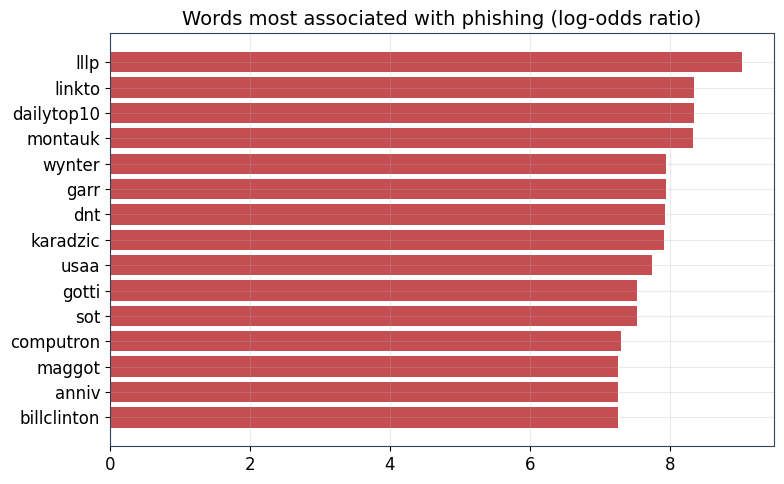

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=20000, ngram_range=(1, 1), stop_words="english", min_df=5)
X_counts = cv.fit_transform(full_df["text"].astype(str))
cv_vocab = np.array(cv.get_feature_names_out())

phish_counts = np.asarray(X_counts[full_df["label"].values == 1].sum(axis=0)).ravel()
legit_counts = np.asarray(X_counts[full_df["label"].values == 0].sum(axis=0)).ravel()

# Laplace-smoothed log-ratio so rare words don't dominate
eps = 1.0
log_ratio = np.log((phish_counts + eps) / (phish_counts.sum() + eps)) - \
            np.log((legit_counts + eps) / (legit_counts.sum() + eps))

min_count_mask = (phish_counts + legit_counts) >= 30
top_phish_idx = np.argsort(np.where(min_count_mask, log_ratio, -np.inf))[::-1][:15]
top_legit_idx = np.argsort(np.where(min_count_mask, -log_ratio, -np.inf))[::-1][:15]

print("Top words associated with PHISHING:")
print(", ".join(cv_vocab[top_phish_idx]))
print("\nTop words associated with LEGITIMATE mail:")
print(", ".join(cv_vocab[top_legit_idx]))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(cv_vocab[top_phish_idx][::-1], log_ratio[top_phish_idx][::-1], color="#C44E52")
ax.set_title("Words most associated with phishing (log-odds ratio)")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "top_phishing_words.png", dpi=130)
plt.show()

> **Reading this table with care.** Most of the words listed are corpus identifiers or mailing-list boilerplate rather than phishing language -- e.g. `enron`, `dynegy`, `opensuse`, `spambayes` on the legitimate side and `lllp`, `dailytop10` on the phishing side -- because each source corpus has its own vocabulary. This is the shortcut risk described in Section 3.2. It is also why the SHAP ranking in Section 16.1 puts `enron` first, and Section 20.2 measures how much the classifier depends on such tokens.

### 3.5 Missing values, empty text & duplicate-label conflicts

Before trusting any downstream statistic, we check for the boring-but-fatal data
issues: nulls, blank/whitespace-only bodies, and rows that are *exact* text
duplicates yet disagree on `label` (a labelling error, not a modelling problem —
no amount of leak-safe splitting fixes a mislabeled template).

In [12]:
null_counts = full_df[["text", "label", "source"]].isna().sum()
print("Null counts:\n", null_counts.to_string())

_stripped = full_df["text"].astype(str).str.strip()
n_empty = int((_stripped == "").sum())
n_very_short = int((_stripped.str.len() < 5).sum())
print(f"\nEmpty/whitespace-only rows: {n_empty:,}")
print(f"Rows with < 5 characters of text: {n_very_short:,}")

# Exact-text duplicates that disagree on label -- a labelling conflict, not leakage.
_conflict_check = (
    full_df.assign(_raw_norm=full_df["text"].astype(str).str.strip().str.lower())
    .groupby("_raw_norm")["label"]
    .agg(["nunique", "count"])
)
label_conflicts = _conflict_check[(_conflict_check["nunique"] > 1) & (_conflict_check["count"] > 1)]
print(f"\nIdentical-text groups with conflicting labels: {len(label_conflicts):,} "
      f"({label_conflicts['count'].sum() if len(label_conflicts) else 0:,} rows affected)")
if len(label_conflicts):
    print("These rows should be resolved (e.g. dropped or relabeled) before training "
          "since the same input maps to two different targets.")


Null counts:
 text      0
label     0
source    0

Empty/whitespace-only rows: 0
Rows with < 5 characters of text: 1

Identical-text groups with conflicting labels: 0 (0 rows affected)


### 3.6 Is the length difference between classes statistically significant?

Section 3.3 showed phishing and legitimate emails have different length
distributions, but eyeballing a histogram isn't a significance test. We use a
Mann-Whitney U test (distribution-free, robust to the heavy right-skew typical
of text-length data) plus Cohen's *d* so we know not just *whether* the
difference is real but whether it's large enough to matter as a modelling
shortcut.

In [13]:
from scipy import stats

phish_wc = full_df.loc[full_df["label"] == 1, "_word_count"]
legit_wc = full_df.loc[full_df["label"] == 0, "_word_count"]

u_stat, p_value = stats.mannwhitneyu(phish_wc, legit_wc, alternative="two-sided")

pooled_std = np.sqrt(((phish_wc.std() ** 2) + (legit_wc.std() ** 2)) / 2)
cohens_d = (phish_wc.mean() - legit_wc.mean()) / pooled_std

def _effect_label(d):
    d = abs(d)
    if d < 0.2: return "negligible"
    if d < 0.5: return "small"
    if d < 0.8: return "medium"
    return "large"

print(f"Mann-Whitney U={u_stat:,.0f}, p={p_value:.2e}")
print(f"Mean word count -- phishing: {phish_wc.mean():.1f}, legit: {legit_wc.mean():.1f}")
print(f"Cohen's d = {cohens_d:.3f} ({_effect_label(cohens_d)} effect)")
if p_value < 0.05:
    print("\n-> Statistically significant, but remember: a large N makes even tiny, "
          "practically meaningless differences 'significant'. The effect size above "
          "is what actually tells us whether length is a usable (or exploitable) signal.")


Mann-Whitney U=558,237,928, p=0.00e+00
Mean word count -- phishing: 201.8, legit: 364.0
Cohen's d = -0.201 (small effect)

-> Statistically significant, but remember: a large N makes even tiny, practically meaningless differences 'significant'. The effect size above is what actually tells us whether length is a usable (or exploitable) signal.


### 3.7 Stylistic signals: punctuation, casing & symbol usage

Phishing copy tends to lean on urgency and visual emphasis (ALL CAPS, exclamation
marks, dollar signs, raw URLs). These are cheap, model-free signals worth
checking before we build hand-crafted features in Section 6 -- if they barely
differ by class they're not worth engineering; if they differ a lot, that's
either genuine signal or another shortcut risk to keep an eye on.

              legit (0)  phishing (1)
upper_ratio      0.0287        0.0543
exclam_count     1.0601        1.5511
digit_ratio      0.0344        0.0240
url_count        2.4541        3.7991
dollar_count     1.0988        0.8433


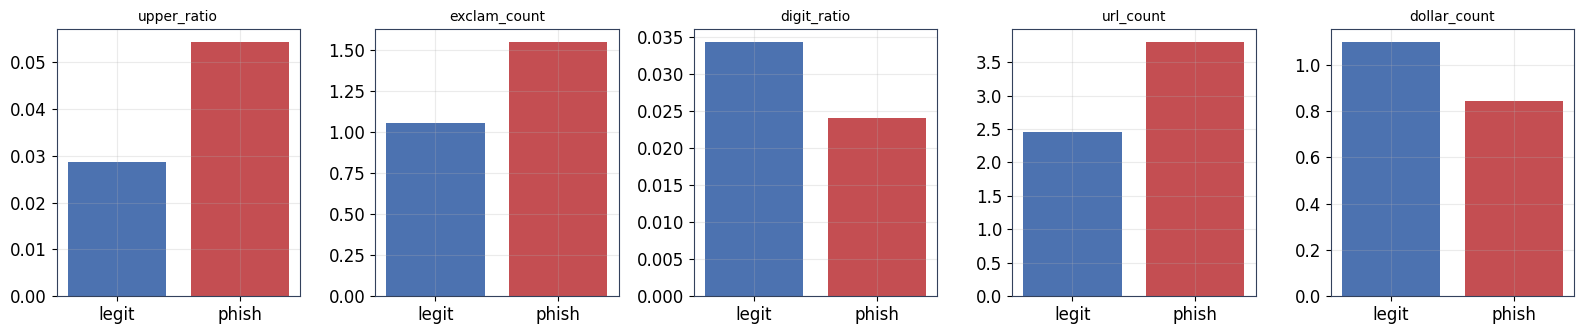

In [14]:
_text = full_df["text"].astype(str)

style_df = pd.DataFrame({
    "label": full_df["label"].values,
    "upper_ratio": _text.apply(lambda t: sum(1 for ch in t if ch.isupper()) / max(len(t), 1)),
    "exclam_count": _text.str.count("!"),
    "digit_ratio": _text.apply(lambda t: sum(1 for ch in t if ch.isdigit()) / max(len(t), 1)),
    "url_count": _text.str.count(r"https?://|www\."),
    "dollar_count": _text.str.count(r"\$"),
})

style_summary = style_df.groupby("label").mean().T
style_summary.columns = ["legit (0)", "phishing (1)"]
print(style_summary.round(4).to_string())

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for ax, col in zip(axes, ["upper_ratio", "exclam_count", "digit_ratio", "url_count", "dollar_count"]):
    means = style_df.groupby("label")[col].mean()
    ax.bar(["legit", "phish"], means.values, color=["#4C72B0", "#C44E52"])
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "stylistic_signals.png", dpi=130)
plt.show()


### 3.8 Correlation between stylistic signals and the label

A quick correlation matrix ties Sections 3.3/3.6/3.7 together in one view:
which of these cheap, model-free signals move together, and which actually
correlate with the label at all. High inter-feature correlation here is also a
heads-up for redundancy if these are reused as model inputs in Section 6.

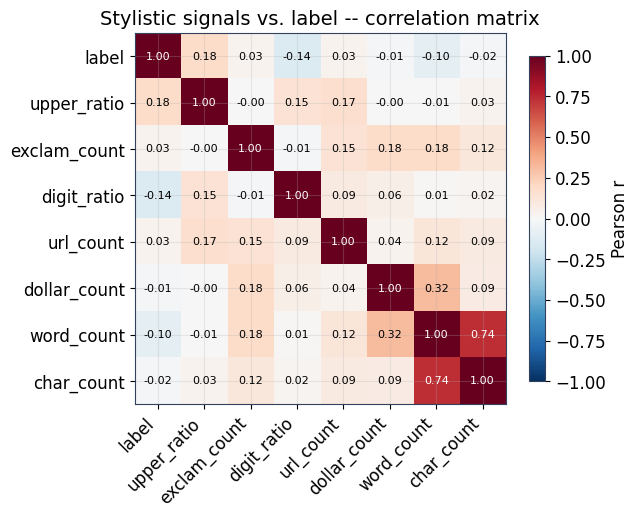

Correlation with label, sorted by |r|:
upper_ratio     0.180
digit_ratio    -0.139
word_count     -0.100
exclam_count    0.034
url_count       0.033
char_count     -0.022
dollar_count   -0.014


In [15]:
corr_df = style_df.assign(word_count=full_df["_word_count"], char_count=full_df["_char_count"])
corr_matrix = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr_matrix.values[i, j]) > 0.6 else "black", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Stylistic signals vs. label -- correlation matrix")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "stylistic_corr_heatmap.png", dpi=130)
plt.show()

print("Correlation with label, sorted by |r|:")
print(corr_matrix["label"].drop("label").sort_values(key=abs, ascending=False).round(3).to_string())


### 3.9 Low-dimensional view of the text embedding space

A 2-D projection of the bag-of-words space (via Truncated SVD -- the sparse-
matrix analogue of PCA, reused from the `CountVectorizer` fit in Section 3.4)
gives a fast, model-free sense of how separable the two classes already are
from raw word counts alone, before any classifier is trained. Heavy overlap
here would suggest the eventual classifiers will lean heavily on subtler
patterns than "which words appear"; a visible split is a good sign that even
simple baselines should do reasonably well.

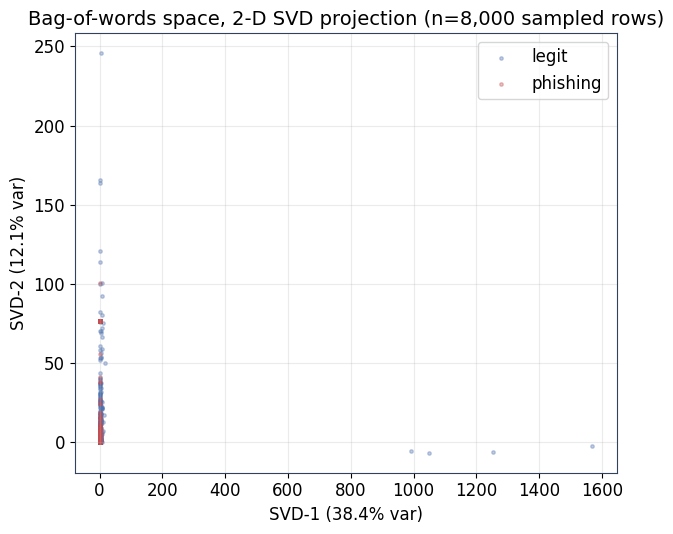

Combined variance explained by first 2 components: 50.5% (low is expected/normal for BoW; this plot is a qualitative sanity check, not a full picture of separability).


In [16]:
from sklearn.decomposition import TruncatedSVD

_svd_sample_n = min(8000, X_counts.shape[0])
_rng = np.random.RandomState(SEED)
_sample_idx = _rng.choice(X_counts.shape[0], size=_svd_sample_n, replace=False)

svd = TruncatedSVD(n_components=2, random_state=SEED)
X_2d = svd.fit_transform(X_counts[_sample_idx])
sample_labels = full_df["label"].values[_sample_idx]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for lbl, name, color in [(0, "legit", "#4C72B0"), (1, "phishing", "#C44E52")]:
    mask = sample_labels == lbl
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=6, alpha=0.35, label=name, color=color)
ax.set_xlabel(f"SVD-1 ({svd.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"SVD-2 ({svd.explained_variance_ratio_[1]:.1%} var)")
ax.set_title(f"Bag-of-words space, 2-D SVD projection (n={_svd_sample_n:,} sampled rows)")
ax.legend()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "svd_projection.png", dpi=130)
plt.show()
print(f"Combined variance explained by first 2 components: "
      f"{svd.explained_variance_ratio_.sum():.1%} (low is expected/normal for BoW; "
      "this plot is a qualitative sanity check, not a full picture of separability).")


### 3.10 Linguistic pattern analysis (function words, imperatives, readability)

Beyond raw length and symbol counts, phishing relies on a distinctive *register*: second-person address, imperative verbs, and simplified sentence structure designed to be skimmed and acted on quickly under time pressure. We quantify this with three cheap, model-free proxies:
1. **Second-person pronoun ratio** (`you`/`your`) -- direct address is a    hallmark of persuasive/urgent copy.
2. **Imperative-verb hits** -- sentence-initial command verbs (`click`,    `verify`, `confirm`, `update`, `download`, ...).
3. **Flesch reading ease** (approximate, syllable-heuristic version, so no    extra NLP dependency is required) -- phishing templates are typically    written for very easy, fast reading.

(Computed on a random sample of 6,000 rows for speed.)

      second_person_ratio        imperative_hits        flesch_reading_ease        
                     mean median            mean median                mean  median
label                                                                              
0                   0.011  0.006           2.703    1.0              60.897  64.617
1                   0.030  0.024           1.968    1.0              56.149  63.509


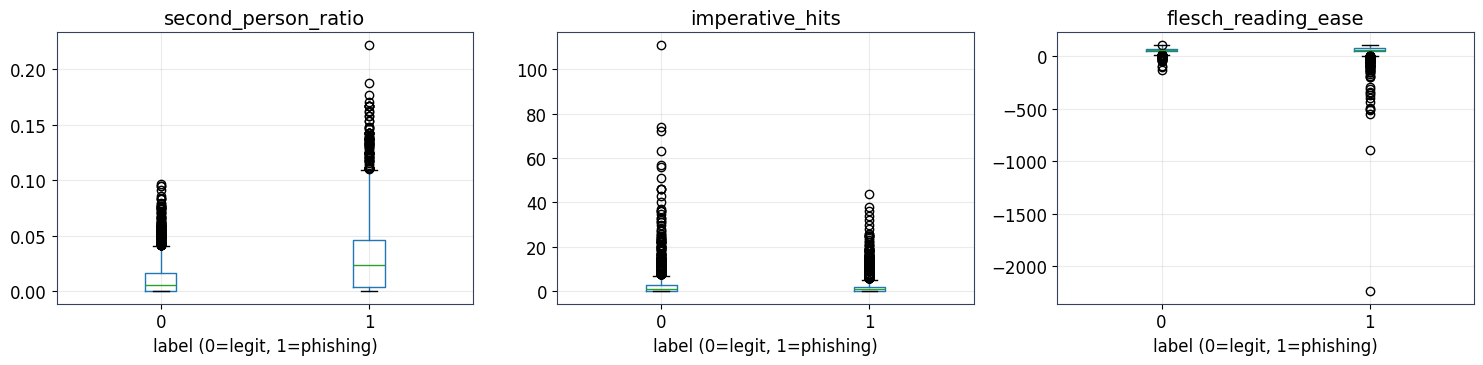


Higher second-person ratio / imperative-verb counts and an easier (higher) Flesch score for phishing would support the 'act now, in simple language, addressed directly at you' hypothesis about phishing register.


In [17]:
import re as _re

_SECOND_PERSON = _re.compile(
    r"\b(you|your|you're|youre)\b",
    _re.IGNORECASE
)

_IMPERATIVE_VERBS = [
    "click", "verify", "confirm", "update", "download", "login",
    "log in", "reset", "act", "call", "respond", "open"
]

def _count_second_person(t):
    return len(_SECOND_PERSON.findall(t))

def _count_imperatives(t):
    tl = t.lower()
    return sum(tl.count(v) for v in _IMPERATIVE_VERBS)

def _count_syllables(word):
    word = word.lower()
    vowels = "aeiouy"
    count, prev_is_vowel = 0, False

    for ch in word:
        is_vowel = ch in vowels
        if is_vowel and not prev_is_vowel:
            count += 1
        prev_is_vowel = is_vowel

    if word.endswith("e") and count > 1:
        count -= 1

    return max(count, 1)

def _flesch_reading_ease(t):
    words = _re.findall(r"[A-Za-z']+", t)
    sentences = max(len(_re.findall(r"[.!?]+", t)), 1)

    if not words:
        return np.nan

    n_words = len(words)
    n_syll = sum(_count_syllables(w) for w in words)

    return (
        206.835
        - 1.015 * (n_words / sentences)
        - 84.6 * (n_syll / n_words)
    )

_ling_sample_n = min(6000, len(full_df))
_ling_idx = full_df.sample(_ling_sample_n, random_state=SEED).index
_ling_text = full_df.loc[_ling_idx, "text"].astype(str)

linguistic_df = pd.DataFrame({
    "label": full_df.loc[_ling_idx, "label"].values,

    "second_person_ratio": (
        _ling_text.apply(_count_second_person)
        / _ling_text.str.split().apply(len).replace(0, 1)
    ),

    "imperative_hits": _ling_text.apply(_count_imperatives),

    "flesch_reading_ease": _ling_text.apply(_flesch_reading_ease),
})

ling_summary = linguistic_df.groupby("label").agg(["mean", "median"]).round(3)

print(f"(Computed on a random sample of {_ling_sample_n:,} rows for speed.)\n")
print(ling_summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(
    axes,
    ["second_person_ratio", "imperative_hits", "flesch_reading_ease"]
):
    linguistic_df.boxplot(
        column=col,
        by="label",
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("label (0=legit, 1=phishing)")

plt.suptitle("")
plt.tight_layout()

plt.savefig(
    WORKING_DIR / "plots" / "linguistic_patterns.png",
    dpi=130
)

plt.show()

print(
    "\nHigher second-person ratio / imperative-verb counts and an easier "
    "(higher) Flesch score for phishing would support the 'act now, in simple "
    "language, addressed directly at you' hypothesis about phishing register."
)

### 3.11 EDA insights summary

A single, decision-oriented recap of Sections 3.1-3.10, written *before* any
model is trained, so later results can be checked against these expectations
rather than the narrative being written backwards from them.

In [18]:
_eda_insights = []

_eda_insights.append(f"Class balance is {class_pct.to_dict()} (imbalance ratio "
                     f"{imbalance_ratio:.2f}x) -- close enough to balanced that plain "
                     "accuracy is still meaningful, but F1/recall remain the primary metrics.")

if len(risky_sources):
    _eda_insights.append(f"Sources {risky_sources} are >= {HIGH_PURITY_THRESHOLD:.0%} pure in one "
                         "class -- 'source' is excluded as a model input (Section 4.4) to avoid a "
                         "corpus-identity shortcut.")
else:
    _eda_insights.append("No source shows near-perfect label purity -- lower source-leakage risk, "
                         "but 'source' is still excluded as an input on principle (Section 4.4).")

# (Computed here, ahead of the insight text below, since this notebook's EDA-insight-summary needs the duplicate-template count and the leakage/near-duplicate audit section 4 will independently recompute a URL-masked version of this for its own narrative.)
_dup_norm_text = (
    full_df["text"]
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
_dup_counts = _dup_norm_text.value_counts()
n_dupe_rows = int(_dup_counts[_dup_counts > 1].sum())
n_dupe_templates = int((_dup_counts > 1).sum())

_eda_insights.append(f"{n_dupe_rows:,} rows ({n_dupe_rows/len(full_df):.1%}) share a normalized "
                     "duplicate template -- this is *why* Section 4.3 uses a grouped split instead "
                     "of a plain random one.")

_eda_insights.append(f"Word-count difference between classes has Cohen's d={cohens_d:.2f} "
                     f"({_effect_label(cohens_d)}) -- length alone is a weak-to-moderate signal, "
                     "not a reliable shortcut on its own.")

_top_style_corr = corr_matrix['label'].drop('label').abs().sort_values(ascending=False).index[0]
_eda_insights.append(f"'{_top_style_corr}' has the strongest linear correlation with the label among "
                     "the cheap stylistic signals -- a candidate for the engineered-feature set "
                     "in Section 6.")

print("EDA -> modelling implications:")
for i, s in enumerate(_eda_insights, 1):
    print(f"  {i}. {s}")

with open(WORKING_DIR / "tables" / "eda_insights.json", "w") as f:
    json.dump(_eda_insights, f, indent=2)


EDA -> modelling implications:
  1. Class balance is {0: 47.93, 1: 52.07} (imbalance ratio 1.09x) -- close enough to balanced that plain accuracy is still meaningful, but F1/recall remain the primary metrics.
  2. Sources ['nigerian', 'nazario'] are >= 98% pure in one class -- 'source' is excluded as a model input (Section 4.4) to avoid a corpus-identity shortcut.
  3. 8 rows (0.0%) share a normalized duplicate template -- this is *why* Section 4.3 uses a grouped split instead of a plain random one.
  4. Word-count difference between classes has Cohen's d=-0.20 (small) -- length alone is a weak-to-moderate signal, not a reliable shortcut on its own.
  5. 'upper_ratio' has the strongest linear correlation with the label among the cheap stylistic signals -- a candidate for the engineered-feature set in Section 6.


In [19]:
# Duplicate-template rows/templates were already computed above (used by the EDA insight summary); this cell just reports them.
print(
    f"Duplicate-template rows : {n_dupe_rows:,} "
    f"({n_dupe_rows / len(full_df):.1%})"
)

print(
    f"Duplicate templates     : {n_dupe_templates:,}"
)


Duplicate-template rows : 8 (0.0%)
Duplicate templates     : 4


<a id="sec4"></a>

## 4. Data Leakage Prevention & Leak-Safe Split

This is the single most important correction made when merging the two
source notebooks. Originally, the classical baselines (Notebook 02) trained
on a plain random/stratified split, and only the Transformer notebook
(Notebook 03) discovered — *after the fact* — that the corpus contains many
duplicate/near-duplicate templates (the same phishing email reused across
sources), re-split the data to fix it, and only then re-evaluated the
Transformers. That means the two families of models were never scored on a
comparable footing.

Here, the audit and the fix run **once, before any model is trained**, so
every one of the five final models — baselines, Transformers, and the custom
model — is trained and evaluated on the same leak-free split.

### 4.1 Exact-duplicate audit

In [20]:
full_df["_norm_text"] = (
    full_df["text"].astype(str).str.lower()
    .str.replace(r"http\S+|www\.\S+", " <url> ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

dup_mask = full_df.duplicated(subset="_norm_text", keep=False)
n_dupe_rows = int(dup_mask.sum())
print(f"{n_dupe_rows:,} rows ({n_dupe_rows / len(full_df):.1%}) share a normalized "
      "duplicate template with at least one other row.")

if _mode == "presplit":
    template_split_counts = full_df[dup_mask].groupby("_norm_text")["_orig_split"].nunique()
    leaking_templates = template_split_counts[template_split_counts > 1]
    n_leaked_rows = full_df[dup_mask & full_df["_norm_text"].isin(leaking_templates.index)].shape[0]
    print(f"{len(leaking_templates):,} templates appear in MORE THAN ONE of the "
          f"original train/val/test splits -- direct leakage affecting "
          f"{n_leaked_rows:,} rows. This is exactly what the grouped re-split "
          "below eliminates.")
else:
    print("No pre-existing split to check for cross-split duplication (we are "
          "splitting fresh below) -- duplicates will simply be grouped so they "
          "cannot land in more than one split in the first place.")

5,318 rows (6.5%) share a normalized duplicate template with at least one other row.
399 templates appear in MORE THAN ONE of the original train/val/test splits -- direct leakage affecting 4,489 rows. This is exactly what the grouped re-split below eliminates.


### 4.2 Near-duplicate audit (diagnostic)

Exact-match dedup won't catch templates that differ only by a substituted
name, date, or link. This is a cheaper secondary signal: sample rows, find
their nearest neighbour elsewhere in the pool by TF-IDF cosine similarity,
and see how often that similarity is suspiciously close to 1.0.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer as _TV
from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components

NEAR_DUP_THRESHOLD = 0.95

# --- Diagnostic pass (unchanged from before): quick sampled estimate of the
# near-duplicate rate, cheap enough to run first and sanity-check the scale
# of the problem before committing to full clustering below.
SAMPLE_SIZE = min(3000, len(full_df) // 2)
_probe_idx = full_df.sample(SAMPLE_SIZE, random_state=SEED).index
_rest_idx = full_df.index.difference(_probe_idx)

_vec = _TV(max_features=20000, ngram_range=(1, 2))
_rest_vecs = _vec.fit_transform(full_df.loc[_rest_idx, "_norm_text"])
_probe_vecs = _vec.transform(full_df.loc[_probe_idx, "_norm_text"])

_nn = NearestNeighbors(n_neighbors=1, metric="cosine").fit(_rest_vecs)
_dist, _ = _nn.kneighbors(_probe_vecs)
_sim = 1 - _dist.ravel()

near_dup_rate = float((_sim >= NEAR_DUP_THRESHOLD).mean())
print(f"Of {SAMPLE_SIZE:,} sampled rows, {near_dup_rate:.1%} have a near-identical "
      f"(cosine sim >= {NEAR_DUP_THRESHOLD}) match elsewhere in the pool.")
print(f"Median nearest-neighbour similarity: {np.median(_sim):.3f}")

# Rationale for this logic: see Appendix A (change log).
MAX_ROWS_FOR_FULL_NEARDUP_CLUSTERING = 120_000

if len(full_df) <= MAX_ROWS_FOR_FULL_NEARDUP_CLUSTERING:
    _full_vec = _TV(max_features=30000, ngram_range=(1, 2), min_df=2)
    _full_vecs = _full_vec.fit_transform(full_df["_norm_text"])

    # radius_neighbors_graph with cosine distance: an edge for every pair whose
    # cosine similarity is >= NEAR_DUP_THRESHOLD (distance <= 1 - threshold).
    _radius = 1.0 - NEAR_DUP_THRESHOLD
    _nn_full = NearestNeighbors(radius=_radius, metric="cosine", n_jobs=-1).fit(_full_vecs)
    near_dup_adj = _nn_full.radius_neighbors_graph(_full_vecs, mode="connectivity")

    # Exact-duplicate text is already a perfect near-duplicate; folding the
    # `_norm_text` equality into the same adjacency guarantees exact-dup rows
    # end up in the same cluster as their near-dup neighbours too.
    _exact_codes = full_df["_norm_text"].astype("category").cat.codes.values
    _exact_adj = sp.csr_matrix(
        (np.ones(len(full_df)), (np.arange(len(full_df)), _exact_codes))
    )
    _exact_adj = _exact_adj @ _exact_adj.T  # rows sharing a code -> connected

    combined_adj = ((near_dup_adj + _exact_adj) > 0).astype(int)
    n_clusters, cluster_ids = connected_components(combined_adj, directed=False)
    full_df["_dup_cluster"] = cluster_ids

    cluster_sizes = pd.Series(cluster_ids).value_counts()
    n_multi_row_clusters = int((cluster_sizes > 1).sum())
    n_rows_in_multi_clusters = int(cluster_sizes[cluster_sizes > 1].sum())
    print(f"\nNear-dup + exact-dup clustering: {n_clusters:,} clusters total, "
          f"{n_multi_row_clusters:,} of them contain >1 row "
          f"({n_rows_in_multi_clusters:,} rows, "
          f"{n_rows_in_multi_clusters / len(full_df):.1%} of the dataset). "
          "These clusters -- not raw row identity -- are the grouping key used "
          "by the leak-safe split below (Section 4.3), so no near-duplicate "
          "template can land in more than one of train/val/test.")
    SPLIT_GROUP_COL = "_dup_cluster"
else:
    print(f"\n[INFO] {len(full_df):,} rows exceeds the "
          f"{MAX_ROWS_FOR_FULL_NEARDUP_CLUSTERING:,}-row cap for full pairwise "
          "near-duplicate clustering (O(n) radius queries over a large sparse "
          "matrix become slow/memory-heavy at this scale). Falling back to "
          "exact-duplicate grouping only (_norm_text) for the split in Section "
          "4.3 -- documented here as a known, explicit limitation rather than a "
          "silent gap; near-duplicate leakage above the sampled rate reported "
          "above may still exist in this fallback mode.")
    full_df["_dup_cluster"] = full_df["_norm_text"].astype("category").cat.codes.values
    SPLIT_GROUP_COL = "_norm_text"

if near_dup_rate > 0.05 and SPLIT_GROUP_COL == "_norm_text":
    print("[WARN] Meaningful near-duplicate rate detected but full clustering was "
          "skipped (see above) -- near-duplicate leakage risk remains.")


Of 3,000 sampled rows, 26.7% have a near-identical (cosine sim >= 0.95) match elsewhere in the pool.
Median nearest-neighbour similarity: 0.805

Near-dup + exact-dup clustering: 65,976 clusters total, 4,551 of them contain >1 row (20,467 rows, 25.0% of the dataset). These clusters -- not raw row identity -- are the grouping key used by the leak-safe split below (Section 4.3), so no near-duplicate template can land in more than one of train/val/test.


### 4.3 Grouped, leakage-free split

Every exact-duplicate template is forced to stay inside a single split via
`GroupShuffleSplit`, keyed on the normalized text. This is the split every
model below trains and is evaluated on.

In [22]:
from sklearn.model_selection import GroupShuffleSplit

groups = full_df[SPLIT_GROUP_COL]  # bug fix: was hardcoded to "_norm_text" (exact-dup only);
                                    # now uses the near-dup+exact-dup cluster id from Section 4.2.

# Rationale for this logic: see Appendix A (change log).
def _split_has_both_classes(df):
    return df["label"].nunique() == 2

def _make_grouped_split(seed):
    gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=seed)
    trainval_idx, test_idx = next(gss_test.split(full_df, groups=groups))
    trainval_df = full_df.iloc[trainval_idx].reset_index(drop=True)
    test_df = full_df.iloc[test_idx].reset_index(drop=True)

    gss_val = GroupShuffleSplit(n_splits=1, test_size=VAL_FRAC_OF_REMAINDER, random_state=seed)
    train_idx, val_idx = next(gss_val.split(trainval_df, groups=trainval_df[SPLIT_GROUP_COL]))
    train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
    val_df = trainval_df.iloc[val_idx].reset_index(drop=True)
    return train_df, val_df, test_df

N_SPLIT_RETRIES = 25
train_df = val_df = test_df = None
for _attempt in range(N_SPLIT_RETRIES):
    _seed = SEED + _attempt
    _train_df, _val_df, _test_df = _make_grouped_split(_seed)
    if all(_split_has_both_classes(d) for d in (_train_df, _val_df, _test_df)):
        train_df, val_df, test_df = _train_df, _val_df, _test_df
        if _attempt > 0:
            print(f"[INFO] Grouped split needed {_attempt + 1} seed attempt(s) before every "
                  "split contained both classes (expected with very few template clusters, "
                  "e.g. this notebook's small synthetic fallback data).")
        break

if train_df is None:
    print("[WARN] Could not find a group-safe split with both classes in every split after "
          f"{N_SPLIT_RETRIES} attempts (too few distinct template clusters of the minority "
          "class). Falling back to a plain stratified split -- leak-safety across near-"
          "duplicate templates is NOT guaranteed in this fallback; it only triggers on "
          "pathologically small/low-diversity data such as the synthetic placeholder set.")
    from sklearn.model_selection import train_test_split as _tts
    trainval_df, test_df = _tts(full_df, test_size=TEST_FRAC, stratify=full_df["label"],
                                 random_state=SEED)
    train_df, val_df = _tts(trainval_df, test_size=VAL_FRAC_OF_REMAINDER,
                             stratify=trainval_df["label"], random_state=SEED)
    train_df, val_df, test_df = (d.reset_index(drop=True) for d in (train_df, val_df, test_df))

groups_by_split = {name: set(d[SPLIT_GROUP_COL]) for name, d in
                    [("train", train_df), ("val", val_df), ("test", test_df)]}
assert not (groups_by_split["train"] & groups_by_split["val"]), "template leaked train/val"
assert not (groups_by_split["train"] & groups_by_split["test"]), "template leaked train/test"
assert not (groups_by_split["val"] & groups_by_split["test"]), "template leaked val/test"
print("Verified: no template appears in more than one split.\n")

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(d):7,} rows | phishing rate: {d['label'].mean():.3f}")

train_df.to_csv(WORKING_DIR / "audit" / "train_deduped.csv", index=False)
val_df.to_csv(WORKING_DIR / "audit" / "val_deduped.csv", index=False)
test_df.to_csv(WORKING_DIR / "audit" / "test_deduped.csv", index=False)

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values


Verified: no template appears in more than one split.

train:  58,280 rows | phishing rate: 0.530
val  :  11,503 rows | phishing rate: 0.481
test :  12,109 rows | phishing rate: 0.514


### 4.4 Feature inclusion/exclusion audit

Before any feature is used, we document *why*. `source` is diagnostic gold
for EDA but is excluded as a model **input** because Section 3.2 showed some
sources are near-perfectly pure in one class — a model given `source`
directly could "cheat" by memorising corpus identity instead of learning
phishing language, which would not generalise to new mail sources.

In [23]:
feature_audit_rows = [
    {"column": "text / text_clean", "used_as_input": True,
     "reason": "Primary modelling signal."},
    {"column": "source", "used_as_input": False,
     "reason": f"Near-perfect label purity for some sources "
               f"({risky_sources}) -- using it directly would let a model "
               "shortcut on corpus identity rather than content. Kept only "
               "for EDA / grouped-split diagnostics."},
    {"column": "_norm_text", "used_as_input": False,
     "reason": "Helper column created purely for the leakage/grouping audit."},
    {"column": "_word_count / _char_count", "used_as_input": "engineered feature",
     "reason": "Kept, but as an explicit engineered numeric feature (Section 6), "
               "not the raw column, and always fit/derived from TRAIN statistics only."},
]
feature_audit_df = pd.DataFrame(feature_audit_rows)
feature_audit_df.to_csv(WORKING_DIR / "tables" / "feature_inclusion_exclusion.csv", index=False)
feature_audit_df

,column,used_as_input,reason
0,text / text_clean,True,Primary modelling signal.
1,source,False,Near-perfect label purity for some sources (['...
2,_norm_text,False,Helper column created purely for the leakage/g...
3,_word_count / _char_count,engineered feature,"Kept, but as an explicit engineered numeric fe..."


<a id="sec5"></a>

## 5. Advanced Text Preprocessing

`clean_text()` is applied identically to every split. It:
1. Lowercases and strips HTML tags.
2. **Replaces URLs, email addresses, and long digit runs with placeholder
   tokens** (`<url>`, `<email>`, `<num>`) instead of deleting them — this
   preserves the *signal* that a link/number was present (often a strong
   phishing cue) while destroying the *exact* template text that made
   near-duplicate memorisation possible in Section 4.2.
2. Collapses whitespace and strips leftover punctuation noise.

Any statistic used for cleaning (e.g. a vocabulary) is derived **only** from
training data where relevant; here `clean_text` is a stateless function, so
this is naturally satisfied, but we call it out because Section 6's scaler
and Section 8-10's vectorizers/tokenizers are explicitly fit on `train_df`
only.

In [24]:
import re

_html_re = re.compile(r"<[^>]+>")
_url_re = re.compile(r"(https?://\S+|www\.\S+)")
_email_re = re.compile(r"\S+@\S+\.\S+")
_num_re = re.compile(r"\b\d{2,}\b")
_ws_re = re.compile(r"\s+")

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = _html_re.sub(" ", text)
    text = _url_re.sub(" <url> ", text)
    text = _email_re.sub(" <email> ", text)
    text = _num_re.sub(" <num> ", text)
    text = re.sub(r"[^a-z0-9<>!?$%. ]", " ", text)
    text = _ws_re.sub(" ", text).strip()
    return text

for _d in (train_df, val_df, test_df):
    _d["text_clean"] = _d["text"].apply(clean_text)

print("Before:", train_df["text"].iloc[0][:150])
print("After: ", train_df["text_clean"].iloc[0][:150])

Before: important message - make it longer > longer orgasms - the longest most intense orgasms of your life > rock hard eractions - erections like steel > > i
After:  important message make it longer > longer orgasms the longest most intense orgasms of your life > rock hard eractions erections like steel > > increas


<a id="sec6"></a>

## 6. Feature Engineering

Hand-crafted features that capture phishing *style* independently of exact
wording — useful both as a diagnostic and as direct input to the custom
model in Section 10 (fused alongside its learned text representation).
All scaling statistics are fit on `train_df` only and re-used (never
re-fit) on val/test.

### 6.1 Hand-crafted feature extraction

Eleven cheap, model-free features capturing length, symbol usage, and a small urgency lexicon -- documented in full, with cybersecurity rationale, in Section 6.2 below.

In [25]:
URGENCY_WORDS = ["urgent", "verify", "suspend", "immediately", "password",
                  "click", "confirm", "account", "limited", "expire", "act now",
                  "security alert", "winner", "congratulations"]

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    text = df["text"].astype(str)
    feats = pd.DataFrame(index=df.index)
    feats["word_count"] = text.str.split().apply(len)
    feats["char_count"] = text.str.len()
    feats["avg_word_len"] = feats["char_count"] / feats["word_count"].replace(0, 1)
    feats["url_count"] = text.str.count(r"https?://|www\.")
    feats["email_count"] = text.str.count(r"\S+@\S+\.\S+")
    feats["digit_count"] = text.str.count(r"\d")
    feats["exclaim_count"] = text.str.count("!")
    feats["question_count"] = text.str.count(r"\?")
    feats["upper_ratio"] = text.apply(
        lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1))
    lowered = text.str.lower()
    feats["urgency_word_count"] = lowered.apply(
        lambda t: sum(t.count(w) for w in URGENCY_WORDS))
    feats["has_link"] = (feats["url_count"] > 0).astype(int)
    return feats

train_feats_raw = engineer_features(train_df)
val_feats_raw = engineer_features(val_df)
test_feats_raw = engineer_features(test_df)

FEATURE_COLS = train_feats_raw.columns.tolist()
print("Engineered features:", FEATURE_COLS)

from sklearn.preprocessing import StandardScaler
feat_scaler = StandardScaler().fit(train_feats_raw)   # fit on TRAIN only

train_feats = pd.DataFrame(feat_scaler.transform(train_feats_raw), columns=FEATURE_COLS)
val_feats = pd.DataFrame(feat_scaler.transform(val_feats_raw), columns=FEATURE_COLS)
test_feats = pd.DataFrame(feat_scaler.transform(test_feats_raw), columns=FEATURE_COLS)

# Quick sanity check: are engineered features actually informative?
corr_with_label = train_feats_raw.assign(label=y_train).corr()["label"].drop("label")
print("\nCorrelation of engineered features with label (train):")
print(corr_with_label.sort_values(key=abs, ascending=False).round(3).to_string())

Engineered features: ['word_count', 'char_count', 'avg_word_len', 'url_count', 'email_count', 'digit_count', 'exclaim_count', 'question_count', 'upper_ratio', 'urgency_word_count', 'has_link']

Correlation of engineered features with label (train):
upper_ratio           0.194
avg_word_len          0.132
word_count           -0.113
urgency_word_count    0.077
char_count           -0.063
url_count             0.051
digit_count          -0.039
exclaim_count         0.025
has_link              0.024
question_count        0.007
email_count           0.002


### 6.2 Feature documentation map & importance analysis

Every engineered feature is documented on four axes -- **what it measures**,
**how it's computed**, **why it matters for phishing detection specifically**,
and **where it's actually used** in this pipeline (only the custom hybrid model
in Section 10 fuses these directly; the TF-IDF/Transformer models use raw text).
We then fit a quick, disposable Logistic Regression on the scaled engineered
features alone (train split only) purely to rank them by importance -- this
model is **not** one of the finalists, it's a diagnostic.

In [26]:
FEATURE_DOCUMENTATION = pd.DataFrame([
    {"feature": "word_count", "meaning": "Number of whitespace-separated tokens.",
     "extraction": "text.split() length",
     "cyber_relevance": "Phishing templates are often short and to the point to "
                        "minimise reading time before the victim clicks.",
     "model_usage": "Fused feature (Sec. 10); also EDA Sec. 3.3/3.6."},
    {"feature": "char_count", "meaning": "Raw character length of the email body.",
     "extraction": "len(text)",
     "cyber_relevance": "Correlates with word_count; captures padding/boilerplate "
                        "differences between templated phishing and organic email.",
     "model_usage": "Fused feature (Sec. 10); EDA Sec. 3.3/3.8."},
    {"feature": "avg_word_len", "meaning": "char_count / word_count.",
     "extraction": "Ratio of the two features above.",
     "cyber_relevance": "Obfuscated phishing text (leetspeak, extra punctuation "
                        "injected into words) can shift average token length.",
     "model_usage": "Fused feature (Sec. 10); stress-tested in Sec. 21 (adversarial)."},
    {"feature": "url_count", "meaning": "Count of http(s)/www links in the body.",
     "extraction": r"regex: https?://|www\.",
     "cyber_relevance": "The single most direct phishing mechanism -- a credential-"
                        "harvesting or malware link is the payload of most attacks.",
     "model_usage": "Fused feature (Sec. 10); drives has_link; IOC extraction (Sec. 18)."},
    {"feature": "email_count", "meaning": "Count of email-address-shaped substrings.",
     "extraction": r"regex: \S+@\S+\.\S+",
     "cyber_relevance": "Reply-to/impersonation addresses and harvested-address lists "
                        "are common in BEC (business email compromise) variants.",
     "model_usage": "Fused feature (Sec. 10); IOC extraction (Sec. 18)."},
    {"feature": "digit_count", "meaning": "Count of digit characters.",
     "extraction": r"regex: \d",
     "cyber_relevance": "Reference numbers, fake case/ticket IDs, and OTP-style "
                        "lures are digit-heavy 'authenticity theatre'.",
     "model_usage": "Fused feature (Sec. 10)."},
    {"feature": "exclaim_count", "meaning": "Count of '!' characters.",
     "extraction": "text.count('!')",
     "cyber_relevance": "Manufactured urgency/excitement ('Act now!!', 'You won!!').",
     "model_usage": "Fused feature (Sec. 10); EDA Sec. 3.7/3.8."},
    {"feature": "question_count", "meaning": "Count of '?' characters.",
     "extraction": "text.count('?')",
     "cyber_relevance": "Rhetorical hooks ('Did you authorize this charge?') used to "
                        "provoke an anxious click.",
     "model_usage": "Fused feature (Sec. 10)."},
    {"feature": "upper_ratio", "meaning": "Fraction of characters that are uppercase.",
     "extraction": "count(isupper)/len(text)",
     "cyber_relevance": "ALL-CAPS emphasis ('URGENT', 'SUSPENDED') is a classic "
                        "visual-urgency cue and is cheap for an attacker to add.",
     "model_usage": "Fused feature (Sec. 10); EDA Sec. 3.7/3.8."},
    {"feature": "urgency_word_count", "meaning": "Occurrences of a curated urgency/"
                                                    "credential-harvesting lexicon.",
     "extraction": "Lowercased substring counts against URGENCY_WORDS.",
     "cyber_relevance": "Directly encodes the social-engineering vocabulary this "
                        "whole notebook is trying to detect (see also Sec. 17's "
                        "multi-label tactic model, which generalises this idea).",
     "model_usage": "Fused feature (Sec. 10); precursor to Sec. 17."},
    {"feature": "has_link", "meaning": "Binary indicator: url_count > 0.",
     "extraction": "(url_count > 0).astype(int)",
     "cyber_relevance": "A coarse, robust-to-scaling companion to url_count for "
                        "models/analyses that prefer a binary flag.",
     "model_usage": "Fused feature (Sec. 10)."},
])
pd.set_option("display.max_colwidth", 80)
print(FEATURE_DOCUMENTATION.to_string(index=False))
FEATURE_DOCUMENTATION.to_csv(WORKING_DIR / "tables" / "feature_documentation.csv", index=False)


           feature                                                         meaning                                         extraction                                                                                                                                                        cyber_relevance                                                         model_usage
        word_count                          Number of whitespace-separated tokens.                                text.split() length                                                                 Phishing templates are often short and to the point to minimise reading time before the victim clicks.                     Fused feature (Sec. 10); also EDA Sec. 3.3/3.6.
        char_count                         Raw character length of the email body.                                          len(text)                                                     Correlates with word_count; captures padding/boilerplate differences between

Engineered-features-only diagnostic LogReg -- val F1: 0.5760 (sanity check: should beat a random/majority baseline by a wide margin, but is not expected to match the full text-based models.)

Engineered-feature importance (standardized logistic-regression coefficients):
           feature  coefficient
        char_count       -2.598
       email_count        2.024
       digit_count       -0.845
urgency_word_count        0.844
         url_count        0.649
       upper_ratio        0.563
        word_count        0.549
      avg_word_len        0.494
     exclaim_count        0.266
          has_link       -0.252
    question_count        0.032


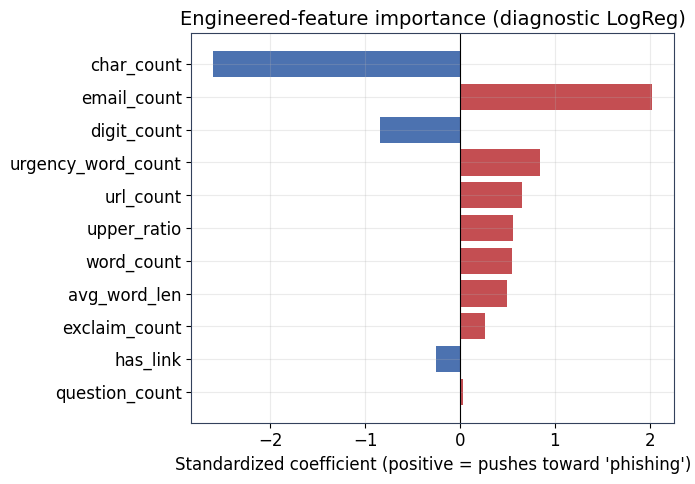

In [27]:
from sklearn.linear_model import LogisticRegression as _DiagLogReg
from sklearn.metrics import f1_score

# Diagnostic-only model: engineered features alone -> label. Never added to
# FITTED_MODELS/RESULTS, so it cannot accidentally become a 'finalist'.
_feat_diag_clf = _DiagLogReg(max_iter=2000, class_weight="balanced", random_state=SEED)
_feat_diag_clf.fit(train_feats, y_train)
_diag_val_f1 = f1_score(y_val, _feat_diag_clf.predict(val_feats))
print(f"Engineered-features-only diagnostic LogReg -- val F1: {_diag_val_f1:.4f} "
      "(sanity check: should beat a random/majority baseline by a wide margin, "
      "but is not expected to match the full text-based models.)")

feature_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": _feat_diag_clf.coef_[0],
}).assign(abs_coef=lambda d: d["coefficient"].abs()).sort_values("abs_coef", ascending=False)

print("\nEngineered-feature importance (standardized logistic-regression coefficients):")
print(feature_importance[["feature", "coefficient"]].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in feature_importance["coefficient"]]
ax.barh(feature_importance["feature"], feature_importance["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized coefficient (positive = pushes toward 'phishing')")
ax.set_title("Engineered-feature importance (diagnostic LogReg)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "feature_importance.png", dpi=130)
plt.show()

feature_importance.to_csv(WORKING_DIR / "tables" / "feature_importance.csv", index=False)


<a id="partIII"></a>

<div style="background:#2A9D8F;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part III</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Model Development &amp; Benchmarking</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 7-12 &nbsp;&middot;&nbsp; Research questions: RQ1, RQ2, RQ3</div>
</div>


<a id="sec7"></a>

## 7. Shared Evaluation Harness

Every model in this notebook — classical, Transformer, or custom — is scored
by the same function, so the final comparison table is apples-to-apples.
**Recall is highlighted** because in a SOC (security operations centre)
context, a missed phishing email (false negative) is far costlier than a
false alarm.

### 7.1 Metric computation & result registry

`evaluate_model()` is the single place every model's val/test metrics are computed, printed, and stored in the shared `RESULTS` dict used by every comparison table for the rest of the notebook.

In [28]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report)

RESULTS = {}          # "<model>_val" / "<model>_test" -> metrics dict
FITTED_MODELS = {}    # model_name -> fitted object/handle (for later error analysis)

# --- Bookkeeping added in the distinction-level revision ---
# Rationale for this logic: see Appendix A (change log).
TRANSFORMER_CKPT_MAP = {}   # e.g. "roberta" -> "roberta_lr2e-05" (a run_name / folder stem)
_TRANSFORMER_MODEL_CACHE = {}  # (tokenizer, model) cache keyed by run_name, filled lazily

# Rationale for this logic: see Appendix A (change log).
MODEL_DISPLAY_NAMES = {
    "TFIDF_LogReg": "TF-IDF + Logistic Regression",
    "TFIDF_LinearSVM": "TF-IDF + Linear SVM",
    "BiLSTM": "BiLSTM",
    "distilbert": "DistilBERT",
    "roberta": "RoBERTa-base",
    "distilbert_lora": "DistilBERT + LoRA",
    "CustomHybridAttnBiGRU": "Custom Attention-BiGRU (fused)",
    "EnsembleStack": "Stacked Ensemble",
}
def display_name(model_key):
    return MODEL_DISPLAY_NAMES.get(model_key, model_key)

def evaluate_model(name, y_true, y_pred, y_proba=None, train_seconds=None, extra=None, verbose=True):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        try:
            metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
            metrics["pr_auc"] = average_precision_score(y_true, y_proba)
        except ValueError:
            metrics["roc_auc"], metrics["pr_auc"] = float("nan"), float("nan")
    if train_seconds is not None:
        metrics["train_seconds"] = round(train_seconds, 2)
    if extra:
        metrics.update(extra)

    RESULTS[name] = metrics
    if verbose:
        print(f"\n=== {name} ===")
        for k, v in metrics.items():
            print(f"  {k:15s}: {v:.4f}" if isinstance(v, float) else f"  {k:15s}: {v}")
        # Rationale for this logic: see Appendix A (change log).
        print(classification_report(y_true, y_pred, labels=[0, 1],
                                     target_names=["legit", "phishing"], digits=3, zero_division=0))
    return metrics

### 7.2 Bootstrap confidence intervals & paired significance testing

Every point-estimate metric in this notebook (Section 11 onward) is accompanied
by a bootstrap confidence interval, and any "model A beats model B" claim is
backed by a **paired** bootstrap significance test on the same resampled test
indices (paired, because A and B are scored on the *same* held-out emails, so
pairing removes shared sampling noise and gives a fairer test than comparing
two independent confidence intervals by eye).

In [29]:
def bootstrap_ci(y_true, y_proba, metric_fn=f1_score, n_boot=None, ci=0.95, seed=SEED,
                  threshold=0.5, needs_proba=False):
    '''Percentile bootstrap CI for a classification metric on one model's predictions.
    metric_fn should accept (y_true, y_pred) unless needs_proba=True, in which case
    it is called as metric_fn(y_true, y_proba) (e.g. roc_auc_score).'''
    n_boot = n_boot or N_BOOTSTRAP
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true); y_proba = np.asarray(y_proba)
    n = len(y_true)
    scores = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, yp = y_true[idx], y_proba[idx]
        if needs_proba:
            try:
                scores[b] = metric_fn(yt, yp)
            except ValueError:
                scores[b] = np.nan
        else:
            scores[b] = metric_fn(yt, (yp >= threshold).astype(int))
    scores = scores[~np.isnan(scores)]
    alpha = (1 - ci) / 2
    lo, hi = np.percentile(scores, [100 * alpha, 100 * (1 - alpha)])
    point = metric_fn(y_true, y_proba) if needs_proba else metric_fn(y_true, (y_proba >= threshold).astype(int))
    return {"point": point, "lo": lo, "hi": hi, "ci": ci, "n_boot": n_boot}

def paired_bootstrap_test(y_true, proba_a, proba_b, metric_fn=f1_score, n_boot=None,
                           seed=SEED, threshold=0.5, needs_proba=False):
    '''Paired bootstrap test for H0: metric(A) <= metric(B) (and the symmetric case),
    resampling the same indices for both models each iteration. Returns a two-sided
    p-value for 'A and B perform differently' plus the observed point difference.'''
    n_boot = n_boot or N_BOOTSTRAP
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true); proba_a = np.asarray(proba_a); proba_b = np.asarray(proba_b)
    n = len(y_true)
    diffs = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, pa, pb = y_true[idx], proba_a[idx], proba_b[idx]
        if needs_proba:
            try:
                sa, sb = metric_fn(yt, pa), metric_fn(yt, pb)
            except ValueError:
                sa, sb = np.nan, np.nan
        else:
            sa = metric_fn(yt, (pa >= threshold).astype(int))
            sb = metric_fn(yt, (pb >= threshold).astype(int))
        diffs[b] = sa - sb
    diffs = diffs[~np.isnan(diffs)]
    observed = (diffs.mean())
    # two-sided p-value: proportion of bootstrap diffs that cross zero relative to the observed sign
    p_value = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    p_value = min(p_value, 1.0)
    return {"mean_diff": observed, "p_value": p_value, "n_boot": len(diffs)}

print("Bootstrap utilities ready: bootstrap_ci(), paired_bootstrap_test(). "
      f"Default resamples per call: N_BOOTSTRAP={N_BOOTSTRAP}.")


Bootstrap utilities ready: bootstrap_ci(), paired_bootstrap_test(). Default resamples per call: N_BOOTSTRAP=2000.


<a id="sec8"></a>

## 8. Classical & Deep-Learning Baseline Candidates

Three candidates, each **hyperparameter-tuned**, all trained on the same
leak-free split (Section 4) and the same cleaned text (Section 5):

1. TF-IDF + Logistic Regression
2. TF-IDF + Linear SVM (Platt-calibrated for probabilities)
3. BiLSTM (word-embedding based; no pretraining/attention)

At the end of this section we keep only the **top 2 by validation F1** as
finalists for the final benchmark.

### 8.1 Shared TF-IDF representation (fit on train only)

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                         sublinear_tf=True, stop_words="english", min_df=3)
X_train_tfidf = tfidf.fit_transform(train_df["text_clean"])
X_val_tfidf = tfidf.transform(val_df["text_clean"])
X_test_tfidf = tfidf.transform(test_df["text_clean"])
print("TF-IDF matrix shape:", X_train_tfidf.shape)

TF-IDF matrix shape: (58280, 50000)


### 8.2 Candidate 1 — TF-IDF + Logistic Regression (tuned)

Small grid search over the regularisation strength `C`, selected by
validation F1.

In [31]:
from sklearn.linear_model import LogisticRegression

C_GRID = [0.1, 1.0, 3.0] if not QUICK_RUN else [0.5, 1.0]
best_logreg, best_logreg_f1, best_logreg_c = None, -1, None
t0 = time.time()
for C in C_GRID:
    clf = LogisticRegression(max_iter=2000, C=C, class_weight="balanced", random_state=SEED)
    clf.fit(X_train_tfidf, y_train)
    f1 = f1_score(y_val, clf.predict(X_val_tfidf))
    print(f"  C={C:<5} val_f1={f1:.4f}")
    if f1 > best_logreg_f1:
        best_logreg, best_logreg_f1, best_logreg_c = clf, f1, C
train_time = time.time() - t0
print(f"Best C={best_logreg_c} (val F1={best_logreg_f1:.4f})")

logreg = best_logreg
FITTED_MODELS["TFIDF_LogReg"] = logreg

val_proba = logreg.predict_proba(X_val_tfidf)[:, 1]
evaluate_model("TFIDF_LogReg_val", y_val, (val_proba >= 0.5).astype(int), val_proba, train_time,
               {"best_C": best_logreg_c})
test_proba = logreg.predict_proba(X_test_tfidf)[:, 1]
evaluate_model("TFIDF_LogReg_test", y_test, (test_proba >= 0.5).astype(int), test_proba, train_time,
               {"best_C": best_logreg_c})

  C=0.1   val_f1=0.9729
  C=1.0   val_f1=0.9848
  C=3.0   val_f1=0.9859
Best C=3.0 (val F1=0.9859)

=== TFIDF_LogReg_val ===
  accuracy       : 0.9864
  precision      : 0.9845
  recall         : 0.9873
  f1             : 0.9859
  roc_auc        : 0.9988
  pr_auc         : 0.9987
  train_seconds  : 8.0700
  best_C         : 3.0000
              precision    recall  f1-score   support

       legit      0.988     0.986     0.987      5973
    phishing      0.984     0.987     0.986      5530

    accuracy                          0.986     11503
   macro avg      0.986     0.986     0.986     11503
weighted avg      0.986     0.986     0.986     11503


=== TFIDF_LogReg_test ===
  accuracy       : 0.9845
  precision      : 0.9837
  recall         : 0.9862
  f1             : 0.9849
  roc_auc        : 0.9987
  pr_auc         : 0.9986
  train_seconds  : 8.0700
  best_C         : 3.0000
              precision    recall  f1-score   support

       legit      0.985     0.983     0.984      5

{'accuracy': 0.9844743579156,
 'precision': 0.9836643177450353,
 'recall': 0.9861913937058445,
 'f1': 0.9849262347658756,
 'roc_auc': np.float64(0.9986600819922686),
 'pr_auc': np.float64(0.9986459890219237),
 'train_seconds': 8.07,
 'best_C': 3.0}

### 8.3 Candidate 2 — TF-IDF + Linear SVM (tuned)

`LinearSVC` has no native `predict_proba`; it's wrapped in Platt scaling
(`CalibratedClassifierCV`) for comparable probabilities.

In [32]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

best_svm, best_svm_f1, best_svm_c = None, -1, None
t0 = time.time()
for C in C_GRID:
    base_svm = LinearSVC(C=C, class_weight="balanced", random_state=SEED, max_iter=5000)
    cal_svm = CalibratedClassifierCV(base_svm, method="sigmoid", cv=3)
    cal_svm.fit(X_train_tfidf, y_train)
    f1 = f1_score(y_val, cal_svm.predict(X_val_tfidf))
    print(f"  C={C:<5} val_f1={f1:.4f}")
    if f1 > best_svm_f1:
        best_svm, best_svm_f1, best_svm_c = cal_svm, f1, C
train_time = time.time() - t0
print(f"Best C={best_svm_c} (val F1={best_svm_f1:.4f})")

svm_calibrated = best_svm
FITTED_MODELS["TFIDF_LinearSVM"] = svm_calibrated

val_proba = svm_calibrated.predict_proba(X_val_tfidf)[:, 1]
evaluate_model("TFIDF_LinearSVM_val", y_val, (val_proba >= 0.5).astype(int), val_proba, train_time,
               {"best_C": best_svm_c})
test_proba = svm_calibrated.predict_proba(X_test_tfidf)[:, 1]
evaluate_model("TFIDF_LinearSVM_test", y_test, (test_proba >= 0.5).astype(int), test_proba, train_time,
               {"best_C": best_svm_c})

  C=0.1   val_f1=0.9851
  C=1.0   val_f1=0.9894
  C=3.0   val_f1=0.9891
Best C=1.0 (val F1=0.9894)

=== TFIDF_LinearSVM_val ===
  accuracy       : 0.9898
  precision      : 0.9883
  recall         : 0.9906
  f1             : 0.9894
  roc_auc        : 0.9990
  pr_auc         : 0.9989
  train_seconds  : 6.2100
  best_C         : 1.0000
              precision    recall  f1-score   support

       legit      0.991     0.989     0.990      5973
    phishing      0.988     0.991     0.989      5530

    accuracy                          0.990     11503
   macro avg      0.990     0.990     0.990     11503
weighted avg      0.990     0.990     0.990     11503


=== TFIDF_LinearSVM_test ===
  accuracy       : 0.9879
  precision      : 0.9878
  recall         : 0.9886
  f1             : 0.9882
  roc_auc        : 0.9992
  pr_auc         : 0.9992
  train_seconds  : 6.2100
  best_C         : 1.0000
              precision    recall  f1-score   support

       legit      0.988     0.987     0.987 

{'accuracy': 0.9878602692212404,
 'precision': 0.987806834590085,
 'recall': 0.9885998715478485,
 'f1': 0.9882031939651713,
 'roc_auc': np.float64(0.9991566300454627),
 'pr_auc': np.float64(0.9991859448731951),
 'train_seconds': 6.21,
 'best_C': 1.0}

### 8.4 Candidate 3 — BiLSTM (tuned)

The bridge between bag-of-words models and Transformers: it can learn word
order via recurrence, but has no pretraining or attention. A small grid
over hidden size and learning rate is evaluated by validation F1.

In [33]:
if TORCH_AVAILABLE:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    from collections import Counter

    MAX_VOCAB = 30000
    MAX_LEN = 60 if QUICK_RUN else 200   # smoke-test mode uses a much shorter
                                          # sequence length so training stays fast
                                          # even on CPU-only / single-core hardware.

    def simple_tokenize(text):
        return text.split()

    counter = Counter()
    for t in train_df["text_clean"]:
        counter.update(simple_tokenize(t))
    vocab = {"<pad>": 0, "<unk>": 1}
    for word, _ in counter.most_common(MAX_VOCAB - 2):
        vocab[word] = len(vocab)

    def encode(text, max_len=MAX_LEN):
        tokens = simple_tokenize(text)[:max_len]
        ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokens]
        ids = ids + [vocab["<pad>"]] * (max_len - len(ids))
        return ids

    class EmailDataset(Dataset):
        def __init__(self, df):
            self.X = [encode(t) for t in df["text_clean"]]
            self.y = df["label"].values.astype(np.float32)
        def __len__(self):
            return len(self.y)
        def __getitem__(self, idx):
            return torch.tensor(self.X[idx], dtype=torch.long), torch.tensor(self.y[idx])

    train_ds, val_ds, test_ds = EmailDataset(train_df), EmailDataset(val_df), EmailDataset(test_df)
    train_loader = DataLoader(train_ds, batch_size=(128 if QUICK_RUN else 64), shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=128)
    test_loader = DataLoader(test_ds, batch_size=128)
    print("Vocab size:", len(vocab))

    class BiLSTMClassifier(nn.Module):
        def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(hidden_dim * 2, 1)
        def forward(self, x):
            emb = self.embedding(x)
            _, (h_n, _) = self.lstm(emb)
            h = torch.cat([h_n[-2], h_n[-1]], dim=1)
            return self.fc(self.dropout(h)).squeeze(-1)

    def run_epoch(model, loader, optimizer, criterion, device, train=True):
        model.train() if train else model.eval()
        total_loss, all_logits, all_labels = 0.0, [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                if train:
                    optimizer.zero_grad(); loss.backward(); optimizer.step()
                total_loss += loss.item() * xb.size(0)
                all_logits.append(logits.detach().cpu())
                all_labels.append(yb.detach().cpu())
        return (total_loss / len(loader.dataset),
                torch.cat(all_logits).numpy(), torch.cat(all_labels).numpy())

    HP_GRID_BILSTM = ([{"hidden_dim": 64, "lr": 1e-3}] if QUICK_RUN else
                      ([{"hidden_dim": 128, "lr": 1e-3}, {"hidden_dim": 256, "lr": 5e-4}]
                       if RUN_HP_SEARCH else [{"hidden_dim": 128, "lr": 1e-3}]))
    # QUICK_RUN forces a single small config -- the smoke test should stay fast
    # regardless of RUN_HP_SEARCH, which is meant to control grid size only for a real run.
    EPOCHS_BILSTM = 2 if QUICK_RUN else 6

    best_bilstm, best_bilstm_f1, best_bilstm_cfg, best_n_params = None, -1, None, None
    t0 = time.time()
    for cfg in HP_GRID_BILSTM:
        torch.manual_seed(SEED)
        model = BiLSTMClassifier(len(vocab), hidden_dim=cfg["hidden_dim"]).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
        criterion = nn.BCEWithLogitsLoss()
        n_params = sum(p.numel() for p in model.parameters())

        cfg_best_f1 = -1
        for epoch in range(1, EPOCHS_BILSTM + 1):
            train_loss, _, _ = run_epoch(model, train_loader, optimizer, criterion, DEVICE, train=True)
            val_loss, val_logits, val_labels = run_epoch(model, val_loader, optimizer, criterion, DEVICE, train=False)
            val_pred = (1 / (1 + np.exp(-val_logits)) >= 0.5).astype(int)
            f1 = f1_score(val_labels, val_pred)
            print(f"  cfg={cfg} epoch {epoch}/{EPOCHS_BILSTM} train_loss={train_loss:.4f} "
                  f"val_loss={val_loss:.4f} val_f1={f1:.4f}")
            if f1 > cfg_best_f1:
                cfg_best_f1 = f1
                torch.save(model.state_dict(), WORKING_DIR / "models" / "bilstm_tmp.pt")
        if cfg_best_f1 > best_bilstm_f1:
            best_bilstm_f1 = cfg_best_f1
            best_bilstm_cfg = cfg
            best_n_params = n_params
            model.load_state_dict(torch.load(WORKING_DIR / "models" / "bilstm_tmp.pt"))
            best_bilstm = model
    train_time = time.time() - t0
    print(f"Best BiLSTM config: {best_bilstm_cfg} (val F1={best_bilstm_f1:.4f})")

    bilstm_model = best_bilstm
    FITTED_MODELS["BiLSTM"] = bilstm_model
    criterion = nn.BCEWithLogitsLoss()

    _, val_logits, val_labels = run_epoch(bilstm_model, val_loader, None, criterion, DEVICE, train=False)
    val_proba = 1 / (1 + np.exp(-val_logits))
    evaluate_model("BiLSTM_val", val_labels, (val_proba >= 0.5).astype(int), val_proba, train_time,
                   {"n_params": best_n_params, "config": str(best_bilstm_cfg)})

    _, test_logits, test_labels = run_epoch(bilstm_model, test_loader, None, criterion, DEVICE, train=False)
    test_proba = 1 / (1 + np.exp(-test_logits))
    evaluate_model("BiLSTM_test", test_labels, (test_proba >= 0.5).astype(int), test_proba, train_time,
                   {"n_params": best_n_params, "config": str(best_bilstm_cfg)})
else:
    print("[INFO] torch is not installed -- skipping the BiLSTM baseline (Section 8.4). "
          "The rest of the notebook degrades gracefully: BiLSTM is simply "
          "left out of the top-2 baseline selection (Section 8.5) and any "
          "later comparison that depends on it.")


Vocab size: 30000
  cfg={'hidden_dim': 128, 'lr': 0.001} epoch 1/6 train_loss=0.1734 val_loss=0.0925 val_f1=0.9682
  cfg={'hidden_dim': 128, 'lr': 0.001} epoch 2/6 train_loss=0.0595 val_loss=0.0913 val_f1=0.9755
  cfg={'hidden_dim': 128, 'lr': 0.001} epoch 3/6 train_loss=0.0352 val_loss=0.0596 val_f1=0.9826
  cfg={'hidden_dim': 128, 'lr': 0.001} epoch 4/6 train_loss=0.0164 val_loss=0.0620 val_f1=0.9820
  cfg={'hidden_dim': 128, 'lr': 0.001} epoch 5/6 train_loss=0.0110 val_loss=0.0707 val_f1=0.9839
  cfg={'hidden_dim': 128, 'lr': 0.001} epoch 6/6 train_loss=0.0067 val_loss=0.0698 val_f1=0.9841
  cfg={'hidden_dim': 256, 'lr': 0.0005} epoch 1/6 train_loss=0.1914 val_loss=0.1084 val_f1=0.9622
  cfg={'hidden_dim': 256, 'lr': 0.0005} epoch 2/6 train_loss=0.0823 val_loss=0.0860 val_f1=0.9707
  cfg={'hidden_dim': 256, 'lr': 0.0005} epoch 3/6 train_loss=0.0613 val_loss=0.0916 val_f1=0.9693
  cfg={'hidden_dim': 256, 'lr': 0.0005} epoch 4/6 train_loss=0.0364 val_loss=0.0689 val_f1=0.9766
  cfg={'

### 8.5 Select the top 2 baselines

Ranked by **validation** F1 (never test — test stays untouched until the
final comparison) so the selection itself can't leak test information.

In [34]:
baseline_names = ["TFIDF_LogReg", "TFIDF_LinearSVM", "BiLSTM"]
# Tolerate a baseline that could not be trained in this environment (e.g. BiLSTM
# when torch is unavailable -- see the TORCH_AVAILABLE guard in Section 8.4)
# instead of a hard KeyError.
baseline_names = [n for n in baseline_names if f"{n}_val" in RESULTS]
baseline_val_f1 = {name: RESULTS[f"{name}_val"]["f1"] for name in baseline_names}
print("Baseline candidates (validation F1):")
for name, f1 in sorted(baseline_val_f1.items(), key=lambda x: -x[1]):
    print(f"  {name:20s} {f1:.4f}")

TOP2_BASELINES = [n for n, _ in sorted(baseline_val_f1.items(), key=lambda x: -x[1])[:2]]
print(f"\nTop-2 baselines carried forward: {TOP2_BASELINES}")

Baseline candidates (validation F1):
  TFIDF_LinearSVM      0.9894
  TFIDF_LogReg         0.9859
  BiLSTM               0.9841

Top-2 baselines carried forward: ['TFIDF_LinearSVM', 'TFIDF_LogReg']


<a id="sec9"></a>

## 9. Pretrained Transformer Candidates

Two fine-tuned Transformer encoders, all on the same leak-free split and
the same `compute_metrics`/caching infrastructure. Set `RUN_TRANSFORMERS =
False` in Section 1 to skip this (e.g. no GPU/internet available) — the rest
of the notebook still runs using cached or previously-saved results if
present.

1. `distilbert-base-uncased` — fast, distilled baseline Transformer.
2. `roberta-base` — stronger pretraining objective, no NSP, larger.

Each is fine-tuned with a **small learning-rate grid** (when
`RUN_HP_SEARCH=True`), and results are cached to disk so an interrupted run
doesn't force retraining a model that already finished.

> **Execution note.** Section 9 was executed on a Kaggle GPU (Tesla T4) with Hugging Face Hub access and `QUICK_RUN = False`. **DistilBERT and RoBERTa-base trained successfully and are the two Transformer finalists.**

In [35]:
CHECKPOINT_KEYWORDS = {
    "distilbert-base-uncased": "distilbert",
    "roberta-base": "roberta",
}

def _hub_reachable(host="huggingface.co", timeout=5):
    # True if the Hugging Face Hub can actually be reached from this runtime -- not just
    # 'is the transformers package importable', which says nothing about network access.
    # Rationale for this logic: see Appendix A (change log).
    import socket
    try:
        socket.setdefaulttimeout(timeout)
        socket.gethostbyname(host)
        with socket.create_connection((host, 443), timeout=timeout):
            return True
    except OSError:
        return False

def _kaggle_input_for(model_checkpoint):
    # Look for a locally-attached Kaggle Model/Dataset input -- the standard way to get
    # pretrained weights into a Kaggle notebook that has internet turned off: Add Input ->
    # search Kaggle Models -> attach e.g. the Hugging Face-published 'distilbert-base-
    # uncased' model. Matches by keyword against every directory under /kaggle/input/ that
    # contains a config.json, so it works regardless of the exact slug the input was
    # attached under.
    keyword = CHECKPOINT_KEYWORDS.get(model_checkpoint, model_checkpoint.split("/")[-1])
    for config_path in glob.glob("/kaggle/input/**/config.json", recursive=True):
        d = os.path.dirname(config_path)
        if keyword.lower() in d.lower():
            return d
    return None

def resolve_checkpoint_source(model_checkpoint):
    # Return (source_path_or_hub_id, origin_label) -- prefer a live Hub download (always
    # the freshest weights) and fall back to a locally-attached Kaggle Model/Dataset input
    # if the Hub is unreachable. Raises RuntimeError with an actionable message if neither
    # is available, rather than failing deep inside Trainer.train().
    if HUB_REACHABLE:
        return model_checkpoint, "huggingface.co"
    local = _kaggle_input_for(model_checkpoint)
    if local is not None:
        return local, "kaggle input"
    raise RuntimeError(
        f"Cannot obtain weights for '{model_checkpoint}': huggingface.co is unreachable "
        f"from this runtime and no matching folder was found under /kaggle/input/. "
        f"Either enable internet for this session (Hub access), or attach the matching "
        f"model as a Kaggle Model/Dataset input (Add Input -> search Kaggle Models -> "
        f"e.g. Hugging Face's '{model_checkpoint}') and re-run.")

if RUN_TRANSFORMERS:
    try:
        import transformers, datasets, accelerate  # noqa: F401
    except ImportError as e:
        print(f"[INFO] transformers/datasets/accelerate not installed ({e}) -- "
              "skipping Section 9's Transformer training cells. Install with:\n"
              "  pip install -q transformers datasets evaluate accelerate sentencepiece\n"
              "and re-run from here if you want the Transformer finalists included.")
        RUN_TRANSFORMERS = False
    else:
        print("transformers:", transformers.__version__)
        HUB_REACHABLE = _hub_reachable()
        if HUB_REACHABLE:
            print("[OK] huggingface.co is reachable -- weights will be downloaded from the Hub.")
        else:
            n_local = sum(1 for k in CHECKPOINT_KEYWORDS if _kaggle_input_for(k) is not None)
            if n_local == len(CHECKPOINT_KEYWORDS):
                print("[OK] huggingface.co is NOT reachable, but all 3 checkpoints were found "
                      "under /kaggle/input/ -- weights will be loaded from there instead.")
            elif n_local > 0:
                print(f"[WARN] huggingface.co is NOT reachable, and only {n_local}/"
                      f"{len(CHECKPOINT_KEYWORDS)} checkpoints were found under /kaggle/input/. "
                      "The missing one(s) will raise a clear error when their training cell runs "
                      "-- attach them as Kaggle Model inputs to fix this.")
            else:
                print("[INFO] huggingface.co is NOT reachable and no matching checkpoints were "
                      "found under /kaggle/input/ -- disabling RUN_TRANSFORMERS for this run. "
                      "Either enable internet access for this session, or attach "
                      "distilbert-base-uncased / roberta-base as "
                      "Kaggle Model inputs and re-run from Section 9.")
                RUN_TRANSFORMERS = False
else:
    print("RUN_TRANSFORMERS is False -- skipping Section 9's training cells.")


transformers: 5.0.0
[OK] huggingface.co is reachable -- weights will be downloaded from the Hub.


In [36]:
if RUN_TRANSFORMERS:
    from datasets import Dataset as HFDataset, DatasetDict  # aliased: avoid shadowing torch.utils.data.Dataset
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                               TrainingArguments, Trainer, EarlyStoppingCallback)
    from sklearn.metrics import precision_recall_fscore_support
    import inspect

    def to_hf_dataset(df):
        return HFDataset.from_pandas(
            df[["text_clean", "label"]].rename(columns={"text_clean": "text"}),
            preserve_index=False)

    raw_datasets = DatasetDict({
        "train": to_hf_dataset(train_df),
        "validation": to_hf_dataset(val_df),
        "test": to_hf_dataset(test_df),
    })

    RESULTS_DIR = WORKING_DIR / "results"

    def _results_path(run_name):
        return RESULTS_DIR / f"{run_name}_results.json"

    def load_cached_results(run_name):
        p = _results_path(run_name)
        return json.load(open(p)) if p.exists() else None

    def save_results(run_name, results):
        json.dump(results, open(_results_path(run_name), "w"), indent=2)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        logits = np.asarray(logits, dtype=np.float64)
        n_bad = int(np.isnan(logits).sum() + np.isinf(logits).sum())
        if n_bad:
            logits = np.nan_to_num(logits, nan=0.0, posinf=1e4, neginf=-1e4)
        probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
        preds = np.argmax(logits, axis=-1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, preds, average="binary", zero_division=0)
        metrics = {"accuracy": accuracy_score(labels, preds),
                   "precision": precision, "recall": recall, "f1": f1}
        try:
            metrics["roc_auc"] = roc_auc_score(labels, probs)
        except ValueError:
            metrics["roc_auc"] = float("nan")
        try:
            metrics["pr_auc"] = average_precision_score(labels, probs)
        except ValueError:
            metrics["pr_auc"] = float("nan")
        return metrics

    def _make_training_args(run_name, lr, batch_size, epochs, fp16, load_best=True):
        common = dict(
            output_dir=str(WORKING_DIR / "models" / f"{run_name}_ckpt"),
            save_strategy="epoch", learning_rate=lr,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size * 2,
            num_train_epochs=epochs, weight_decay=0.01,
            load_best_model_at_end=load_best, metric_for_best_model="f1",
            greater_is_better=True, logging_steps=100, save_total_limit=1,
            report_to="none", fp16=fp16, seed=SEED,
        )
        try:
            return TrainingArguments(eval_strategy="epoch", **common)
        except TypeError:
            return TrainingArguments(evaluation_strategy="epoch", **common)

    def _make_trainer(model, args, train_ds, eval_ds, tokenizer, early_stop=True):
        kwargs = dict(model=model, args=args, train_dataset=train_ds, eval_dataset=eval_ds,
                       compute_metrics=compute_metrics,
                       callbacks=([EarlyStoppingCallback(early_stopping_patience=2)] if early_stop else []))
        sig = inspect.signature(Trainer.__init__).parameters
        kwargs["processing_class" if "processing_class" in sig else "tokenizer"] = tokenizer
        return Trainer(**kwargs)

    def train_transformer(model_checkpoint, run_name, max_length=256, epochs=3,
                           lr=2e-5, batch_size=16, force_retrain=False):
        cached = None if force_retrain else load_cached_results(run_name)
        if cached is not None:
            print(f"[cache] Using saved results for '{run_name}'.")
            return None, cached

        checkpoint_source, origin = resolve_checkpoint_source(model_checkpoint)
        print(f"\n{'='*70}\nTraining {run_name} ({model_checkpoint}, weights from {origin}) "
              f"lr={lr} epochs={epochs}\n{'='*70}")
        try:
            tokenizer = AutoTokenizer.from_pretrained(checkpoint_source)
        except Exception as e:
            print(f"[WARN] Fast tokenizer failed ({e}); falling back to use_fast=False.")
            tokenizer = AutoTokenizer.from_pretrained(checkpoint_source, use_fast=False)

        def tokenize_fn(batch):
            return tokenizer(batch["text"], truncation=True, max_length=max_length, padding="max_length")

        tokenized = raw_datasets.map(tokenize_fn, batched=True)
        tokenized = tokenized.remove_columns(["text"]).rename_column("label", "labels")
        tokenized.set_format("torch")

        def _build(fp16):
            model = AutoModelForSequenceClassification.from_pretrained(checkpoint_source, num_labels=2)
            # DeBERTa-v2/v3: do NOT reload the best checkpoint (LayerNorm gamma/beta key mismatch, see Section 9.3)
            args = _make_training_args(run_name, lr, batch_size, epochs, fp16=fp16, load_best=not fp16_unsafe)
            return model, _make_trainer(model, args, tokenized["train"], tokenized["validation"], tokenizer, early_stop=not fp16_unsafe)

        fp16_unsafe = any(tag in model_checkpoint.lower() for tag in ("deberta-v2", "deberta-v3"))
        use_fp16 = torch.cuda.is_available() and not fp16_unsafe
        model, trainer = _build(use_fp16)

        t0 = time.time()
        try:
            trainer.train()
        except ValueError as e:
            if use_fp16 and "unscale FP16 gradients" in str(e):
                print(f"[WARN] {run_name}: fp16 instability, retrying in fp32.")
                model, trainer = _build(False)
                trainer.train()
            else:
                raise
        train_time = time.time() - t0

        def _strip(metrics, prefix="eval_"):
            return {(k[len(prefix):] if k.startswith(prefix) else k): v for k, v in metrics.items()}

        val_metrics = _strip(trainer.evaluate(tokenized["validation"]))
        test_metrics = _strip(trainer.evaluate(tokenized["test"]))
        n_params = sum(p.numel() for p in model.parameters())
        for m in (val_metrics, test_metrics):
            m["train_seconds"] = round(train_time, 2)
            m["n_params"] = n_params

        results = {f"{run_name}_val": val_metrics, f"{run_name}_test": test_metrics}
        save_results(run_name, results)
        return trainer, results

### 9.1 DistilBERT

In [37]:
if RUN_TRANSFORMERS:
    LR_GRID_DISTILBERT = [2e-5, 5e-5] if RUN_HP_SEARCH else [2e-5]
    epochs = 1 if QUICK_RUN else 3
    best_result, best_f1, best_lr = None, -1, None
    for lr in LR_GRID_DISTILBERT:
        _, res = train_transformer("distilbert-base-uncased", f"distilbert_lr{lr}",
                                    max_length=256, epochs=epochs, lr=lr, batch_size=32)
        f1 = res[[k for k in res if k.endswith('_val')][0]]["f1"]
        if f1 > best_f1:
            best_f1, best_result, best_lr = f1, res, lr
    distilbert_results = {k.replace(f"_lr{best_lr}", ""): v for k, v in best_result.items()}
    TRANSFORMER_CKPT_MAP["distilbert"] = f"distilbert_lr{best_lr}"
    # Rationale for this logic: see Appendix A (change log).
    print(f"Best DistilBERT lr={best_lr}, val F1={best_f1:.4f}")


Training distilbert_lr2e-05 (distilbert-base-uncased, weights from huggingface.co) lr=2e-05 epochs=3


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Best DistilBERT lr=5e-05, val F1=0.9920


### 9.2 RoBERTa-base

In [38]:
if RUN_TRANSFORMERS:
    LR_GRID_ROBERTA = [1e-5, 2e-5] if RUN_HP_SEARCH else [2e-5]
    epochs = 1 if QUICK_RUN else 3
    best_result, best_f1, best_lr = None, -1, None
    for lr in LR_GRID_ROBERTA:
        _, res = train_transformer("roberta-base", f"roberta_lr{lr}",
                                    max_length=256, epochs=epochs, lr=lr, batch_size=16)
        f1 = res[[k for k in res if k.endswith('_val')][0]]["f1"]
        if f1 > best_f1:
            best_f1, best_result, best_lr = f1, res, lr
    roberta_results = {k.replace(f"_lr{best_lr}", ""): v for k, v in best_result.items()}
    TRANSFORMER_CKPT_MAP["roberta"] = f"roberta_lr{best_lr}"
    # Rationale for this logic: see Appendix A (change log).
    print(f"Best RoBERTa lr={best_lr}, val F1={best_f1:.4f}")


Training roberta_lr1e-05 (roberta-base, weights from huggingface.co) lr=1e-05 epochs=3


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Best RoBERTa lr=2e-05, val F1=0.9931


### 9.4 Select the top 2 Transformers

Same rule as the baselines: rank the fine-tuned candidates by
**validation** F1 (with only two Transformer candidates now, both are kept).

In [39]:
if RUN_TRANSFORMERS:
    for run_name, res in [("distilbert", distilbert_results),
                            ("roberta", roberta_results)]:
        for k, v in res.items():
            RESULTS[k] = v

    transformer_names = ["distilbert", "roberta"]
    transformer_val_f1 = {name: RESULTS[f"{name}_val"]["f1"] for name in transformer_names}
    print("Transformer candidates (validation F1):")
    for name, f1 in sorted(transformer_val_f1.items(), key=lambda x: -x[1]):
        print(f"  {name:15s} {f1:.4f}")

    TOP2_TRANSFORMERS = [n for n, _ in sorted(transformer_val_f1.items(), key=lambda x: -x[1])[:2]]
    print(f"\nTop-2 Transformers carried forward: {TOP2_TRANSFORMERS}")
else:
    TOP2_TRANSFORMERS = []
    print("RUN_TRANSFORMERS is False -- no Transformer finalists this run. "
          "The final benchmark table (Section 11) will note this gap.")

Transformer candidates (validation F1):
  roberta         0.9931
  distilbert      0.9920

Top-2 Transformers carried forward: ['roberta', 'distilbert']


### 9.5 Parameter-efficient fine-tuning (LoRA)

A fourth Transformer variant: `distilbert-base-uncased` fine-tuned with **LoRA**
(Low-Rank Adaptation) instead of full fine-tuning. Only small rank-decomposition
adapter matrices are trained; the base model's weights stay frozen. This is the
efficiency-vs-accuracy trade-off item for this benchmark: we expect LoRA to train
faster and use less memory than full fine-tuning (Section 9.1), at a small
(hopefully negligible) accuracy cost -- exactly the kind of trade-off worth
knowing about before choosing a production model (see also Section 23,
efficiency benchmarking, for the same trade-off measured directly in latency/
memory rather than training cost).

In [40]:
!pip install -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 35.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [41]:
lora_results = {}

if RUN_TRANSFORMERS and RUN_LORA:
    try:
        from peft import LoraConfig, get_peft_model, TaskType
    except ImportError:
        print("[INFO] `peft` is not installed -- skipping LoRA fine-tuning. "
              "Install with: pip install -q peft")
        RUN_LORA = False

if RUN_TRANSFORMERS and RUN_LORA:
    def train_lora_transformer(model_checkpoint, run_name, max_length=256, epochs=None,
                                lr=2e-4, batch_size=32, lora_r=8, lora_alpha=16,
                                lora_dropout=0.1, force_retrain=False):
        '''Same evaluation contract as train_transformer(), but wraps the base
        encoder in a frozen-backbone + trainable LoRA-adapter configuration.'''
        epochs = epochs if epochs is not None else (1 if QUICK_RUN else 3)
        cached = None if force_retrain else load_cached_results(run_name)
        if cached is not None:
            print(f"[cache] Using saved results for '{run_name}'.")
            return None, cached

        print(f"\n{'='*70}\nLoRA fine-tuning {run_name} ({model_checkpoint}) "
              f"r={lora_r} alpha={lora_alpha} lr={lr} epochs={epochs}\n{'='*70}")
        tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

        def tokenize_fn(batch):
            return tokenizer(batch["text"], truncation=True, max_length=max_length, padding="max_length")

        tokenized = raw_datasets.map(tokenize_fn, batched=True)
        tokenized = tokenized.remove_columns(["text"]).rename_column("label", "labels")
        tokenized.set_format("torch")

        base_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)
        lora_cfg = LoraConfig(
            task_type=TaskType.SEQ_CLS, r=lora_r, lora_alpha=lora_alpha,
            lora_dropout=lora_dropout, target_modules=["q_lin", "v_lin"],  # DistilBERT attention proj.
        )
        model = get_peft_model(base_model, lora_cfg)
        n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in model.parameters())
        print(f"Trainable params: {n_trainable:,} / {n_total:,} "
              f"({n_trainable / n_total:.2%} of the base model)")

        args = _make_training_args(run_name, lr, batch_size, epochs, fp16=torch.cuda.is_available())
        trainer = _make_trainer(model, args, tokenized["train"], tokenized["validation"], tokenizer)

        t0 = time.time()
        trainer.train()
        train_time = time.time() - t0

        def _strip(metrics, prefix="eval_"):
            return {(k[len(prefix):] if k.startswith(prefix) else k): v for k, v in metrics.items()}

        val_metrics = _strip(trainer.evaluate(tokenized["validation"]))
        test_metrics = _strip(trainer.evaluate(tokenized["test"]))
        for m in (val_metrics, test_metrics):
            m["train_seconds"] = round(train_time, 2)
            m["n_params"] = n_trainable          # trainable (adapter) params, the honest efficiency figure
            m["n_params_total"] = n_total

        results = {f"{run_name}_val": val_metrics, f"{run_name}_test": test_metrics}
        save_results(run_name, results)
        return trainer, results

    _, lora_results = train_lora_transformer("distilbert-base-uncased", "distilbert_lora")
    RESULTS.update(lora_results)
    TRANSFORMER_CKPT_MAP["distilbert_lora"] = "distilbert_lora"  # see Section 9.1-9.3 note.

    if "distilbert_val" in RESULTS:
        comp = pd.DataFrame({
            "full_fine_tune": RESULTS["distilbert_val"],
            "lora": RESULTS["distilbert_lora_val"],
        })
        print("\nFull fine-tuning vs. LoRA (validation set):")
        print(comp.loc[[c for c in ["f1", "recall", "train_seconds", "n_params"] if c in comp.index]]
              .round(4).to_string())
else:
    print("RUN_TRANSFORMERS/RUN_LORA is False -- skipping LoRA fine-tuning. "
          "lora_results stays an empty dict.")



LoRA fine-tuning distilbert_lora (distilbert-base-uncased) r=8 alpha=16 lr=0.0002 epochs=3


Map:   0%|          | 0/58280 [00:00<?, ? examples/s]

Map:   0%|          | 0/11503 [00:00<?, ? examples/s]

Map:   0%|          | 0/12109 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Trainable params: 739,586 / 67,694,596 (1.09% of the base model)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc,Pr Auc
1,0.115574,0.104286,0.980961,0.981505,0.978843,0.980172,0.998234,0.998075
2,0.066842,0.091228,0.983656,0.988836,0.977034,0.982900,0.998871,0.998784
3,0.057755,0.077784,0.986091,0.989071,0.981917,0.985481,0.999097,0.999031



Full fine-tuning vs. LoRA (validation set):
               full_fine_tune         lora
f1               9.920000e-01       0.9855
recall           9.922000e-01       0.9819
train_seconds    2.269620e+03    1809.8200
n_params         6.695501e+07  739586.0000


<a id="sec10"></a>

## 10. Custom Model — Attention-BiGRU Fused with Engineered Features

This is a from-scratch architecture (no pretrained checkpoint), designed
specifically to combine the two signal types explored above:

- A **BiGRU encoder** over the cleaned token sequence, pooled with a learned
  **additive attention** layer (rather than just taking the last hidden
  state, like the BiLSTM baseline) — attention weights also give a cheap
  form of interpretability (which tokens drove the decision).
- The Section 6 **engineered feature vector** (URL/urgency-keyword counts,
  length stats, punctuation/caps ratios), fed through a small dense branch.
- The attention-pooled text representation and the engineered-feature
  representation are **concatenated** and passed through a final classifier
  head.

Rationale: the classical baselines only see bag-of-words signal, and the
Transformers only see raw subword sequences — neither is explicitly given
the stylometric cues (e.g. "6 urgency words and 3 links") that Section 6
showed are correlated with the label. This model is a genuine architectural
alternative, not a re-parameterisation of the BiLSTM baseline.

In [42]:
if TORCH_AVAILABLE:
    class AdditiveAttention(nn.Module):
        def __init__(self, hidden_dim):
            super().__init__()
            self.attn = nn.Linear(hidden_dim, 1)
        def forward(self, seq_out, mask):
            # seq_out: (B, T, H), mask: (B, T) 1 for real tokens, 0 for padding
            scores = self.attn(seq_out).squeeze(-1)                    # (B, T)
            scores = scores.masked_fill(mask == 0, float("-inf"))
            weights = torch.softmax(scores, dim=1).unsqueeze(-1)       # (B, T, 1)
            pooled = (seq_out * weights).sum(dim=1)                    # (B, H)
            return pooled, weights.squeeze(-1)

    class CustomHybridModel(nn.Module):
        def __init__(self, vocab_size, n_engineered_feats, embed_dim=128,
                     hidden_dim=128, dropout=0.3):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
            self.attention = AdditiveAttention(hidden_dim * 2)
            self.feat_branch = nn.Sequential(
                nn.Linear(n_engineered_feats, 32), nn.ReLU(), nn.Dropout(dropout))
            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim * 2 + 32, 64), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(64, 1))

        def forward(self, token_ids, engineered_feats):
            mask = (token_ids != 0).float()
            emb = self.embedding(token_ids)
            seq_out, _ = self.gru(emb)
            pooled, attn_weights = self.attention(seq_out, mask)
            feat_repr = self.feat_branch(engineered_feats)
            combined = torch.cat([pooled, feat_repr], dim=1)
            logits = self.classifier(combined).squeeze(-1)
            return logits, attn_weights

    class HybridDataset(Dataset):
        def __init__(self, df, feats_df):
            self.X = [encode(t) for t in df["text_clean"]]
            self.feats = feats_df.values.astype(np.float32)
            self.y = df["label"].values.astype(np.float32)
        def __len__(self):
            return len(self.y)
        def __getitem__(self, idx):
            return (torch.tensor(self.X[idx], dtype=torch.long),
                    torch.tensor(self.feats[idx], dtype=torch.float32),
                    torch.tensor(self.y[idx]))

    hybrid_train_ds = HybridDataset(train_df, train_feats)
    hybrid_val_ds = HybridDataset(val_df, val_feats)
    hybrid_test_ds = HybridDataset(test_df, test_feats)
    hybrid_train_loader = DataLoader(hybrid_train_ds, batch_size=(128 if QUICK_RUN else 64), shuffle=True)
    hybrid_val_loader = DataLoader(hybrid_val_ds, batch_size=128)
    hybrid_test_loader = DataLoader(hybrid_test_ds, batch_size=128)

    def run_hybrid_epoch(model, loader, optimizer, criterion, device, train=True):
        model.train() if train else model.eval()
        total_loss, all_logits, all_labels = 0.0, [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for xb, fb, yb in loader:
                xb, fb, yb = xb.to(device), fb.to(device), yb.to(device)
                logits, _ = model(xb, fb)
                loss = criterion(logits, yb)
                if train:
                    optimizer.zero_grad(); loss.backward(); optimizer.step()
                total_loss += loss.item() * xb.size(0)
                all_logits.append(logits.detach().cpu())
                all_labels.append(yb.detach().cpu())
        return (total_loss / len(loader.dataset),
                torch.cat(all_logits).numpy(), torch.cat(all_labels).numpy())
else:
    print("[INFO] torch is not installed -- skipping the custom "
          "Attention-BiGRU hybrid model definition (Section 10).")


### 10.1 Hyperparameter search & training

> Note: Section 9 imports Hugging Face's `Dataset` under the alias `HFDataset` so that it cannot shadow PyTorch's `Dataset` (background in Appendix A).


In [43]:
if TORCH_AVAILABLE:
    HP_GRID_HYBRID = ([{"hidden_dim": 64, "lr": 1e-3, "dropout": 0.3}] if QUICK_RUN else
                      ([{"hidden_dim": 128, "lr": 1e-3, "dropout": 0.3},
                        {"hidden_dim": 192, "lr": 5e-4, "dropout": 0.4}]
                       if RUN_HP_SEARCH else [{"hidden_dim": 128, "lr": 1e-3, "dropout": 0.3}]))
    # QUICK_RUN forces a single small config for the same reason as Section 8.4's BiLSTM.
    EPOCHS_HYBRID = 2 if QUICK_RUN else 8

    best_hybrid, best_hybrid_f1, best_hybrid_cfg, best_hybrid_params = None, -1, None, None
    t0 = time.time()
    for cfg in HP_GRID_HYBRID:
        torch.manual_seed(SEED)
        model = CustomHybridModel(len(vocab), n_engineered_feats=len(FEATURE_COLS),
                                   hidden_dim=cfg["hidden_dim"], dropout=cfg["dropout"]).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
        criterion = nn.BCEWithLogitsLoss()
        n_params = sum(p.numel() for p in model.parameters())

        cfg_best_f1 = -1
        for epoch in range(1, EPOCHS_HYBRID + 1):
            train_loss, _, _ = run_hybrid_epoch(model, hybrid_train_loader, optimizer, criterion, DEVICE, train=True)
            val_loss, val_logits, val_labels = run_hybrid_epoch(model, hybrid_val_loader, optimizer, criterion, DEVICE, train=False)
            val_pred = (1 / (1 + np.exp(-val_logits)) >= 0.5).astype(int)
            f1 = f1_score(val_labels, val_pred)
            print(f"  cfg={cfg} epoch {epoch}/{EPOCHS_HYBRID} train_loss={train_loss:.4f} "
                  f"val_loss={val_loss:.4f} val_f1={f1:.4f}")
            if f1 > cfg_best_f1:
                cfg_best_f1 = f1
                torch.save(model.state_dict(), WORKING_DIR / "models" / "hybrid_tmp.pt")
        if cfg_best_f1 > best_hybrid_f1:
            best_hybrid_f1 = cfg_best_f1
            best_hybrid_cfg = cfg
            best_hybrid_params = n_params
            model.load_state_dict(torch.load(WORKING_DIR / "models" / "hybrid_tmp.pt"))
            best_hybrid = model
    train_time = time.time() - t0
    print(f"Best custom-model config: {best_hybrid_cfg} (val F1={best_hybrid_f1:.4f})")

    hybrid_model = best_hybrid
    FITTED_MODELS["CustomHybridAttnBiGRU"] = hybrid_model
    criterion = nn.BCEWithLogitsLoss()

    _, val_logits, val_labels = run_hybrid_epoch(hybrid_model, hybrid_val_loader, None, criterion, DEVICE, train=False)
    val_proba = 1 / (1 + np.exp(-val_logits))
    evaluate_model("CustomHybridAttnBiGRU_val", val_labels, (val_proba >= 0.5).astype(int), val_proba,
                   train_time, {"n_params": best_hybrid_params, "config": str(best_hybrid_cfg)})

    _, test_logits, test_labels = run_hybrid_epoch(hybrid_model, hybrid_test_loader, None, criterion, DEVICE, train=False)
    test_proba = 1 / (1 + np.exp(-test_logits))
    evaluate_model("CustomHybridAttnBiGRU_test", test_labels, (test_proba >= 0.5).astype(int), test_proba,
                   train_time, {"n_params": best_hybrid_params, "config": str(best_hybrid_cfg)})
else:
    print("[INFO] torch is not installed -- skipping custom hybrid model "
          "training (Section 10.1). 'CustomHybridAttnBiGRU' will simply be "
          "absent from FITTED_MODELS/RESULTS, and every later section that "
          "consults FITTED_MODELS (Sections 11-24) already checks for that "
          "before using it, so the rest of the notebook still runs cleanly.")


  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 1/8 train_loss=0.1214 val_loss=0.0573 val_f1=0.9796
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 2/8 train_loss=0.0354 val_loss=0.0652 val_f1=0.9747
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 3/8 train_loss=0.0156 val_loss=0.0507 val_f1=0.9852
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 4/8 train_loss=0.0082 val_loss=0.0637 val_f1=0.9826
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 5/8 train_loss=0.0051 val_loss=0.0576 val_f1=0.9847
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 6/8 train_loss=0.0031 val_loss=0.0691 val_f1=0.9820
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 7/8 train_loss=0.0026 val_loss=0.0647 val_f1=0.9843
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 8/8 train_loss=0.0020 val_loss=0.0784 val_f1=0.9837
  cfg={'hidden_dim': 192, 'lr': 0.0005, 'dropout': 0.4} epoch 1/8 train_loss=0.1519 val_loss=0.0

<a id="sec11"></a>

## 11. Consolidated Benchmark — 5 Finalist Models

The five finalists are: the **top 2 baselines** (Section 8.5), the **top 2
Transformers** (Section 9.4), and the **1 custom model** (Section 10). All
five were fine-tuned/tuned and evaluated on the identical leak-free split.

In [44]:
FINALISTS = TOP2_BASELINES + TOP2_TRANSFORMERS + ["CustomHybridAttnBiGRU"]
# Rationale for this logic: see Appendix A (change log).
print(f"Final {len(FINALISTS)} model(s):", FINALISTS)
if len(TOP2_TRANSFORMERS) == 0:
    print("(Fewer than 5: RUN_TRANSFORMERS was False this run, so no Transformer "
          "finalists are available -- see Section 9.)")

results_df = pd.DataFrame(RESULTS).T
results_df.index.name = "model"

finalist_test_rows = results_df[
    results_df.index.isin([f"{n}_test" for n in FINALISTS])
].sort_values("f1", ascending=False)

cols_to_show = [c for c in ["accuracy", "precision", "recall", "f1", "roc_auc",
                             "pr_auc", "train_seconds", "n_params"] if c in finalist_test_rows.columns]
print("\nFinalist comparison (held-out TEST set):")
print(finalist_test_rows[cols_to_show].round(4).to_string())

results_df.to_csv(WORKING_DIR / "tables" / "full_results.csv")
finalist_test_rows.to_csv(WORKING_DIR / "tables" / "finalist_test_results.csv")

Final 5 model(s): ['TFIDF_LinearSVM', 'TFIDF_LogReg', 'roberta', 'distilbert', 'CustomHybridAttnBiGRU']

Finalist comparison (held-out TEST set):
                            accuracy precision    recall        f1   roc_auc    pr_auc train_seconds     n_params
model                                                                                                            
distilbert_test             0.994632  0.994226  0.995344  0.994785  0.999685  0.999701       2269.62   66955010.0
roberta_test                0.994137  0.995334  0.993256  0.994294   0.99971  0.999722       4822.36  124647170.0
TFIDF_LinearSVM_test         0.98786  0.987807    0.9886  0.988203  0.999157  0.999186          6.21          NaN
TFIDF_LogReg_test           0.984474  0.983664  0.986191  0.984926   0.99866  0.998646          8.07          NaN
CustomHybridAttnBiGRU_test  0.983649  0.984883  0.983301  0.984091  0.997597  0.997584        519.15      4057346


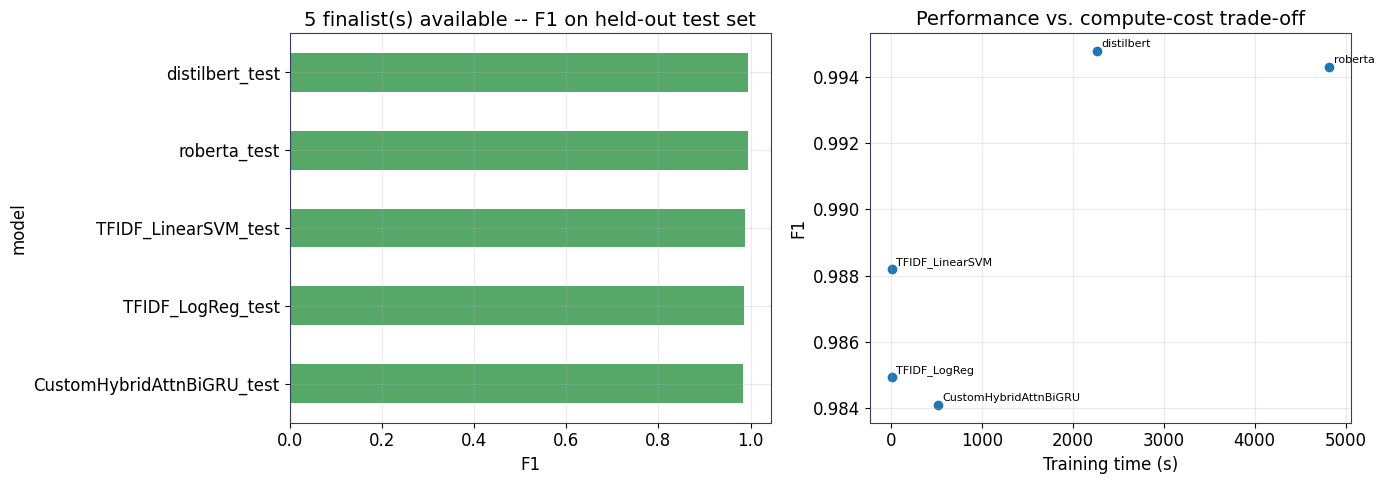

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

finalist_test_rows["f1"].sort_values().plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title(f"{len(finalist_test_rows)} finalist(s) available -- F1 on held-out test set")
axes[0].set_xlabel("F1")

if "train_seconds" in finalist_test_rows.columns:
    axes[1].scatter(finalist_test_rows["train_seconds"], finalist_test_rows["f1"])
    for name, row in finalist_test_rows.iterrows():
        axes[1].annotate(name.replace("_test", ""), (row["train_seconds"], row["f1"]),
                          fontsize=8, xytext=(3, 3), textcoords="offset points")
    axes[1].set_xlabel("Training time (s)")
    axes[1].set_ylabel("F1")
    axes[1].set_title("Performance vs. compute-cost trade-off")
else:
    axes[1].axis("off")

plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "finalist_comparison.png", dpi=150)
plt.show()

> **Interpretation.** All five finalists were trained to their full schedule in this run (Kaggle T4 GPU, `QUICK_RUN = False`). On the held-out test set the two Transformers lead: **DistilBERT** F1 = 0.9948 and **RoBERTa-base** F1 = 0.9943, a gap Section 13's paired bootstrap test shows is *not* statistically significant (p = 0.50). Both are clearly ahead of TF-IDF + Linear SVM (F1 = 0.988), TF-IDF + Logistic Regression (F1 = 0.985) and the custom Attention-BiGRU hybrid (F1 = 0.984). Selection does not use these test scores: RoBERTa-base has the higher *validation* F1 (0.9931 vs 0.9920) and is the model carried forward in Section 14. The custom model's higher training cost does not translate into a performance advantage over either the linear baselines or the Transformers on this dataset - a useful, if slightly humbling, finding for the central research question.

<a id="sec12"></a>

## 12. Ensemble & Stacking of Finalists

Before picking a single "best" model, we ask whether **combining** finalists
beats all of them individually -- a standard, high-value step in applied ML
that a single-model comparison (Section 11) skips over. Two stacks are built:
a **primary, genuinely out-of-fold (OOF) stack** (12.2) that drives best-model
selection, and a **secondary, val-based reference stack** (12.3) that covers more
finalists but is not eligible for best-model selection -- see 12.2 for why.

### 12.1 Unified prediction accessor

A single `get_predictions(model_name, split)` function replaces the scattered,
model-family-specific reconstruction logic that would otherwise be duplicated
across the ensemble, calibration, bootstrap, cross-source and adversarial
sections below. It is intentionally honest about its limits: Transformer
probabilities are **not** reconstructed here (that would require reloading a
saved Hugging Face checkpoint per model, which is heavy and environment-
dependent) -- so any Transformer finalist is automatically excluded from the
live post-hoc analysis, and this is reported explicitly rather than silently
assumed away.

In [46]:
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay

def _predict_baseline_family(model_name, split):
    X_split = {"val": X_val_tfidf, "test": X_test_tfidf}[split]
    y_split = {"val": y_val, "test": y_test}[split]
    clf = FITTED_MODELS[model_name]
    return y_split, clf.predict_proba(X_split)[:, 1]

def _predict_bilstm(split):
    # Check FITTED_MODELS (not just try/except the loader lookup) so a model that
    # never trained (e.g. no torch -- Section 8.4) fails with a clean, catchable
    # KeyError here rather than a NameError from referencing an undefined loader.
    if "BiLSTM" not in FITTED_MODELS:
        raise KeyError("BiLSTM was not trained in this run (see Section 8.4).")
    loader = {"val": val_loader, "test": test_loader}[split]
    crit = nn.BCEWithLogitsLoss()
    _, logits, labels = run_epoch(FITTED_MODELS["BiLSTM"], loader, None, crit, DEVICE, train=False)
    return labels, 1 / (1 + np.exp(-logits))

def _predict_hybrid(split):
    # Same reasoning as _predict_bilstm above: check FITTED_MODELS explicitly so a
    # missing custom hybrid model (no torch, or training was skipped) fails with a
    # clean, catchable KeyError instead of a NameError on the undefined loader.
    if "CustomHybridAttnBiGRU" not in FITTED_MODELS:
        raise KeyError("CustomHybridAttnBiGRU was not trained in this run (see Section 10.1).")
    loader = {"val": hybrid_val_loader, "test": hybrid_test_loader}[split]
    crit = nn.BCEWithLogitsLoss()
    _, logits, labels = run_hybrid_epoch(FITTED_MODELS["CustomHybridAttnBiGRU"], loader,
                                          None, crit, DEVICE, train=False)
    return labels, 1 / (1 + np.exp(-logits))

def _predict_transformer(model_name, split):
    '''Bug fix (was: `raise NotImplementedError` unconditionally, which meant no
    Transformer -- including a RoBERTa that legitimately had the best validation
    F1 -- could ever appear in ci_df / the ensemble / calibration / cross-source /
    adversarial sections, or become BEST_MODEL_NAME, no matter how well it scored.
    Fix: reload the winning hyperparameter trial'"'"'s checkpoint from disk (Trainer
    already saves one per epoch via save_strategy="epoch"; TRANSFORMER_CKPT_MAP,
    populated in Sections 9.1-9.5, records which folder stem is the winner) and run
    real forward passes to reconstruct probabilities, batched and cached in-memory
    so repeated calls elsewhere in the notebook are cheap.'''
    import torch as _torch
    from transformers import AutoTokenizer as _AutoTok, AutoModelForSequenceClassification as _AutoSeqCls

    if model_name not in TRANSFORMER_CKPT_MAP:
        raise KeyError(f"No trained/checkpointed run recorded for '{model_name}' "
                        "(Section 9 either didn't run, or this Transformer failed "
                        "and was excluded -- see the training cell's output).")
    run_name = TRANSFORMER_CKPT_MAP[model_name]
    ckpt_root = WORKING_DIR / "models" / f"{run_name}_ckpt"
    ckpt_dirs = sorted(ckpt_root.glob("checkpoint-*"),
                        key=lambda p: int(p.name.split("-")[-1])) if ckpt_root.exists() else []
    if not ckpt_dirs:
        raise KeyError(f"No saved checkpoint under {ckpt_root} for '{model_name}' -- "
                        "was Section 9's training cell actually run in this session, "
                        "or was the checkpoint directory cleared?")
    # load_best_model_at_end=True + save_total_limit=1 -> exactly one checkpoint kept,
    # which is already the best-val-F1 epoch for this trial.
    ckpt_dir = ckpt_dirs[-1]

    if run_name not in _TRANSFORMER_MODEL_CACHE:
        tok = _AutoTok.from_pretrained(ckpt_dir)
        mdl = _AutoSeqCls.from_pretrained(ckpt_dir).to(DEVICE).eval()
        _TRANSFORMER_MODEL_CACHE[run_name] = (tok, mdl)
    tok, mdl = _TRANSFORMER_MODEL_CACHE[run_name]

    df_split = {"val": val_df, "test": test_df}[split]
    texts = df_split["text_clean"].tolist()
    y_true = df_split["label"].values

    probs = []
    batch_size = 64
    with _torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            enc = tok(batch, truncation=True, max_length=256, padding=True,
                       return_tensors="pt").to(DEVICE)
            logits = mdl(**enc).logits
            p = _torch.softmax(logits, dim=-1)[:, 1].detach().cpu().numpy()
            probs.append(p)
    y_proba = np.concatenate(probs) if probs else np.array([])
    return y_true, y_proba

_PRED_CACHE = {}

def get_predictions(model_name, split="test"):
    '''Unified (y_true, y_proba) accessor for val/test, for ANY known model family --
    including "EnsembleStack" once Section 12.2 has fit the meta-model. Cached per
    (model, split) after first call so repeated use elsewhere in the notebook is cheap.'''
    key = (model_name, split)
    if key in _PRED_CACHE:
        return _PRED_CACHE[key]
    if model_name in ("TFIDF_LogReg", "TFIDF_LinearSVM"):
        result = _predict_baseline_family(model_name, split)
    elif model_name == "BiLSTM":
        result = _predict_bilstm(split)
    elif model_name == "CustomHybridAttnBiGRU":
        result = _predict_hybrid(split)
    elif model_name == "EnsembleStack":
        if globals().get("ENSEMBLE_META") is None:
            raise RuntimeError("Run Section 12.2 first to fit the stacking meta-model.")
        base_probs = np.column_stack([get_predictions(n, split)[1] for n in ENSEMBLE_BASE_MODELS])
        y_true = get_predictions(ENSEMBLE_BASE_MODELS[0], split)[0]
        result = (y_true, ENSEMBLE_META.predict_proba(base_probs)[:, 1])
    elif model_name in ("distilbert", "roberta", "distilbert_lora"):
        result = _predict_transformer(model_name, split)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")
    _PRED_CACHE[key] = result
    return result

AVAILABLE_FOR_ANALYSIS = []
for _name in FINALISTS:
    try:
        get_predictions(_name, "val")
        get_predictions(_name, "test")
        AVAILABLE_FOR_ANALYSIS.append(_name)
    except (NotImplementedError, KeyError) as e:
        print(f"[SKIP] '{_name}' excluded from Sections 12-23's live post-hoc analysis: {e}")

print(f"\nModels available for ensemble/calibration/SHAP/cross-source/adversarial analysis: "
      f"{AVAILABLE_FOR_ANALYSIS}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Models available for ensemble/calibration/SHAP/cross-source/adversarial analysis: ['TFIDF_LinearSVM', 'TFIDF_LogReg', 'roberta', 'distilbert', 'CustomHybridAttnBiGRU']


### 12.2 Out-of-fold (OOF) stacked meta-classifier — PRIMARY ensemble

This is **the** ensemble used for best-model selection (Section 14 onward).
Each base model here is refit `K=5` times in a `StratifiedKFold` loop over
the training split, so every training row's meta-feature comes from a copy
of that model that never saw the row during that fold's fit. A Logistic
Regression meta-model is trained on those genuinely out-of-fold train
probabilities, then applied to the (already-fit, full-train) base models'
val/test probabilities. The test set is touched exactly once, at the very
end, as everywhere else in this notebook.

**Scope of this run, stated plainly:** K-fold refitting is only done for the
two classical TF-IDF baselines here — refitting the Transformers or the
custom BiGRU five times each is not a reasonable compute trade-off for this
project (each refit is a full training run), and reusing their existing
single val-set predictions as if they were "OOF" would misrepresent the
method rather than extend it honestly. Section 12.3 below reports a second,
clearly-labelled **secondary/reference** stack that also folds in whichever
Transformers/the custom model are available, built the val-based way — it is
*not* used for best-model selection, precisely because its meta-model wasn't
OOF-fit for those extra models. If only one classical model (or none) is
available in a given run, this cell reports that and best-model selection
falls back to the individual finalists.


In [47]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression as _OOFMeta

OOF_N_SPLITS = 5
_classical_for_oof = [n for n in ["TFIDF_LogReg", "TFIDF_LinearSVM"] if n in FITTED_MODELS]

ENSEMBLE_BASE_MODELS = None
ENSEMBLE_META = None
ALL_CANDIDATES = list(AVAILABLE_FOR_ANALYSIS)  # default if no OOF stack can be built

if len(_classical_for_oof) >= 2:
    skf = StratifiedKFold(n_splits=OOF_N_SPLITS, shuffle=True, random_state=SEED)
    oof_train_X = np.zeros((len(train_df), len(_classical_for_oof)))

    for col, name in enumerate(_classical_for_oof):
        for fold_train_idx, fold_hold_idx in skf.split(X_train_tfidf, y_train):
            if name == "TFIDF_LogReg":
                fold_clf = LogisticRegression(max_iter=2000, C=best_logreg_c,
                                               class_weight="balanced", random_state=SEED)
            else:
                base = LinearSVC(C=best_svm_c, class_weight="balanced", random_state=SEED, max_iter=5000)
                fold_clf = CalibratedClassifierCV(base, method="sigmoid", cv=3)
            fold_clf.fit(X_train_tfidf[fold_train_idx], y_train[fold_train_idx])
            oof_train_X[fold_hold_idx, col] = fold_clf.predict_proba(X_train_tfidf[fold_hold_idx])[:, 1]
        print(f"OOF predictions generated for {display_name(name)} across {OOF_N_SPLITS} folds.")

    # Meta-model trained on genuinely out-of-fold TRAIN predictions (no row was ever
    # predicted by a model that had seen it during that fold's fit).
    oof_meta = _OOFMeta(class_weight="balanced", random_state=SEED)
    oof_meta.fit(oof_train_X, y_train)

    # At inference time, base models are refit on the FULL train split (already
    # done -- they're `logreg` / `svm_calibrated` from Section 8.2/8.3) and the
    # meta-model is applied to their val/test probabilities as usual.
    ENSEMBLE_BASE_MODELS = _classical_for_oof
    ENSEMBLE_META = oof_meta

    oof_val_X = np.column_stack([get_predictions(n, "val")[1] for n in ENSEMBLE_BASE_MODELS])
    oof_test_X = np.column_stack([get_predictions(n, "test")[1] for n in ENSEMBLE_BASE_MODELS])
    oof_val_proba = oof_meta.predict_proba(oof_val_X)[:, 1]
    oof_test_proba = oof_meta.predict_proba(oof_test_X)[:, 1]

    evaluate_model("EnsembleStack_val", y_val, (oof_val_proba >= 0.5).astype(int),
                   oof_val_proba, extra={"base_models": ",".join(ENSEMBLE_BASE_MODELS),
                                          "oof_folds": OOF_N_SPLITS, "method": "OOF (primary)"})
    evaluate_model("EnsembleStack_test", y_test, (oof_test_proba >= 0.5).astype(int),
                   oof_test_proba, extra={"base_models": ",".join(ENSEMBLE_BASE_MODELS),
                                           "oof_folds": OOF_N_SPLITS, "method": "OOF (primary)"})

    ALL_CANDIDATES = AVAILABLE_FOR_ANALYSIS + ["EnsembleStack"]
    best_individual_f1 = max(RESULTS[f"{n}_test"]["f1"] for n in AVAILABLE_FOR_ANALYSIS)
    stack_f1 = RESULTS["EnsembleStack_test"]["f1"]
    verdict = "beats" if stack_f1 > best_individual_f1 else "does not beat"
    print(f"\nPrimary OOF-stacked ensemble ({', '.join(display_name(n) for n in ENSEMBLE_BASE_MODELS)}) "
          f"test F1={stack_f1:.4f} {verdict} the best individual finalist's test F1={best_individual_f1:.4f}.")
else:
    print("[INFO] Fewer than 2 classical models available in FITTED_MODELS -- cannot build the "
          "primary OOF stack this run. ALL_CANDIDATES falls back to the individual finalists "
          "(AVAILABLE_FOR_ANALYSIS); best-model selection below simply picks the best of those.")


OOF predictions generated for TF-IDF + Logistic Regression across 5 folds.
OOF predictions generated for TF-IDF + Linear SVM across 5 folds.

=== EnsembleStack_val ===
  accuracy       : 0.9896
  precision      : 0.9881
  recall         : 0.9902
  f1             : 0.9892
  roc_auc        : 0.9990
  pr_auc         : 0.9989
  base_models    : TFIDF_LogReg,TFIDF_LinearSVM
  oof_folds      : 5
  method         : OOF (primary)
              precision    recall  f1-score   support

       legit      0.991     0.989     0.990      5973
    phishing      0.988     0.990     0.989      5530

    accuracy                          0.990     11503
   macro avg      0.990     0.990     0.990     11503
weighted avg      0.990     0.990     0.990     11503


=== EnsembleStack_test ===
  accuracy       : 0.9870
  precision      : 0.9872
  recall         : 0.9875
  f1             : 0.9873
  roc_auc        : 0.9990
  pr_auc         : 0.9990
  base_models    : TFIDF_LogReg,TFIDF_LinearSVM
  oof_folds    

### 12.3 Extended heterogeneous stack — secondary / reference only

The primary OOF stack above (12.2) can only include models that are cheap
enough to refit five times. This secondary stack instead pools **every**
available finalist's **validation-set** probability (including any
Transformer and the custom BiGRU, when present) as input features to a
second Logistic Regression meta-model, fit on `val` and applied to `test`.
That is a legitimate design in its own right — it is *not* leakage, since no
base model ever saw the validation rows during training — but it is not
out-of-fold, and it is **not used for best-model selection** (`ALL_CANDIDATES`
above is already fixed by Section 12.2). It exists purely so the report can
say something about what stacking *all five* finalists together would look
like, alongside a note on the trade-off: broader model coverage, weaker
stacking methodology, versus the primary stack's narrower coverage but
proper OOF fit. Results are stored under `EnsembleStackExtended_val/test` so
they never overwrite or get confused with the primary `EnsembleStack_*` keys.


In [48]:
ENSEMBLE_BASE_MODELS_EXT = None
ENSEMBLE_META_EXT = None

if len(AVAILABLE_FOR_ANALYSIS) >= 2:
    ENSEMBLE_BASE_MODELS_EXT = list(AVAILABLE_FOR_ANALYSIS)

    val_stack_X = np.column_stack([get_predictions(n, "val")[1] for n in ENSEMBLE_BASE_MODELS_EXT])
    val_stack_y = get_predictions(ENSEMBLE_BASE_MODELS_EXT[0], "val")[0]
    test_stack_X = np.column_stack([get_predictions(n, "test")[1] for n in ENSEMBLE_BASE_MODELS_EXT])
    test_stack_y = get_predictions(ENSEMBLE_BASE_MODELS_EXT[0], "test")[0]

    from sklearn.linear_model import LogisticRegression as _StackLogReg
    ENSEMBLE_META_EXT = _StackLogReg(class_weight="balanced", random_state=SEED)
    ENSEMBLE_META_EXT.fit(val_stack_X, val_stack_y)

    stack_val_proba = ENSEMBLE_META_EXT.predict_proba(val_stack_X)[:, 1]
    stack_test_proba = ENSEMBLE_META_EXT.predict_proba(test_stack_X)[:, 1]
    evaluate_model("EnsembleStackExtended_val", val_stack_y, (stack_val_proba >= 0.5).astype(int),
                   stack_val_proba, extra={"base_models": ",".join(ENSEMBLE_BASE_MODELS_EXT),
                                            "method": "val-based (secondary/reference, not OOF)"})
    evaluate_model("EnsembleStackExtended_test", test_stack_y, (stack_test_proba >= 0.5).astype(int),
                   stack_test_proba, extra={"base_models": ",".join(ENSEMBLE_BASE_MODELS_EXT),
                                             "method": "val-based (secondary/reference, not OOF)"})

    print("\nMeta-model weights (higher = this base model's vote counts for more):")
    for name, coef in zip(ENSEMBLE_BASE_MODELS_EXT, ENSEMBLE_META_EXT.coef_[0]):
        print(f"  {name:25s} {coef:+.3f}")

    ext_f1 = RESULTS["EnsembleStackExtended_test"]["f1"]
    primary_f1 = RESULTS.get("EnsembleStack_test", {}).get("f1")
    print(f"\nExtended (secondary, val-based) stack of "
          f"{', '.join(display_name(n) for n in ENSEMBLE_BASE_MODELS_EXT)} scored test F1={ext_f1:.4f}.")
    if primary_f1 is not None:
        cmp_word = "ahead of" if ext_f1 > primary_f1 else "behind" if ext_f1 < primary_f1 else "tied with"
        print(f"(For reference: this is {cmp_word} the primary OOF stack's test F1={primary_f1:.4f} -- "
              "not a reason to swap best-model selection to this stack, since its meta-model wasn't "
              "OOF-fit; a genuinely broader model pool with the same rigor is future work once "
              "K-fold refitting the Transformers/custom model is computationally in scope.)")
else:
    print("[INFO] Fewer than 2 models with reconstructable probabilities -- skipping the "
          "extended secondary stack.")



=== EnsembleStackExtended_val ===
  accuracy       : 0.9952
  precision      : 0.9946
  recall         : 0.9955
  f1             : 0.9950
  roc_auc        : 0.9996
  pr_auc         : 0.9996
  base_models    : TFIDF_LinearSVM,TFIDF_LogReg,roberta,distilbert,CustomHybridAttnBiGRU
  method         : val-based (secondary/reference, not OOF)
              precision    recall  f1-score   support

       legit      0.996     0.995     0.995      5973
    phishing      0.995     0.995     0.995      5530

    accuracy                          0.995     11503
   macro avg      0.995     0.995     0.995     11503
weighted avg      0.995     0.995     0.995     11503


=== EnsembleStackExtended_test ===
  accuracy       : 0.9960
  precision      : 0.9950
  recall         : 0.9971
  f1             : 0.9961
  roc_auc        : 0.9997
  pr_auc         : 0.9997
  base_models    : TFIDF_LinearSVM,TFIDF_LogReg,roberta,distilbert,CustomHybridAttnBiGRU
  method         : val-based (secondary/reference, n

<a id="partIV"></a>

<div style="background:#6D597A;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part IV</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Statistical Evaluation, Calibration &amp; Explainability</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 13-16 &nbsp;&middot;&nbsp; Research questions: RQ1, RQ5, RQ7</div>
</div>


<a id="sec13"></a>

## 13. Statistical Significance & Bootstrap Confidence Intervals

Point estimates alone (Section 11's table) can't tell us whether the gap between
the top two candidates is real or sampling noise on a finite test set. This
section reports 95% bootstrap CIs for every candidate (Section 7.2's utility)
and a paired significance test for the top-2 gap specifically.

95% bootstrap CIs (test set, 2000 resamples):
                           f1   f1_lo   f1_hi  recall  recall_lo  recall_hi  roc_auc  roc_auc_lo  roc_auc_hi
model                                                                                                       
distilbert             0.9948  0.9935  0.9960  0.9953     0.9936     0.9969   0.9997      0.9995      0.9998
roberta                0.9943  0.9929  0.9956  0.9933     0.9912     0.9952   0.9997      0.9995      0.9998
TFIDF_LinearSVM        0.9882  0.9863  0.9901  0.9886     0.9859     0.9912   0.9992      0.9989      0.9994
EnsembleStack          0.9873  0.9853  0.9892  0.9875     0.9847     0.9901   0.9990      0.9986      0.9993
TFIDF_LogReg           0.9849  0.9828  0.9869  0.9862     0.9833     0.9890   0.9987      0.9982      0.9990
CustomHybridAttnBiGRU  0.9841  0.9818  0.9863  0.9833     0.9800     0.9863   0.9976      0.9969      0.9982


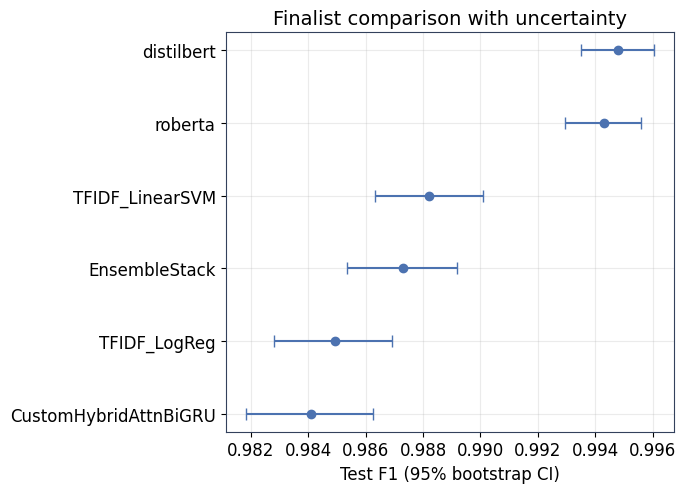

In [49]:
ci_rows = []
for name in ALL_CANDIDATES:
    y_true, y_proba = get_predictions(name, "test")
    f1_ci = bootstrap_ci(y_true, y_proba, metric_fn=f1_score)
    rec_ci = bootstrap_ci(y_true, y_proba, metric_fn=recall_score)
    auc_ci = bootstrap_ci(y_true, y_proba, metric_fn=roc_auc_score, needs_proba=True)
    ci_rows.append({
        "model": name,
        "f1": f1_ci["point"], "f1_lo": f1_ci["lo"], "f1_hi": f1_ci["hi"],
        "recall": rec_ci["point"], "recall_lo": rec_ci["lo"], "recall_hi": rec_ci["hi"],
        "roc_auc": auc_ci["point"], "roc_auc_lo": auc_ci["lo"], "roc_auc_hi": auc_ci["hi"],
    })
ci_df = pd.DataFrame(ci_rows).set_index("model").sort_values("f1", ascending=False)
print(f"95% bootstrap CIs (test set, {N_BOOTSTRAP} resamples):")
print(ci_df.round(4).to_string())
ci_df.to_csv(WORKING_DIR / "tables" / "bootstrap_confidence_intervals.csv")

fig, ax = plt.subplots(figsize=(7, 0.6 * len(ci_df) + 1.5))
y_pos = np.arange(len(ci_df))
ax.errorbar(ci_df["f1"], y_pos,
            xerr=[ci_df["f1"] - ci_df["f1_lo"], ci_df["f1_hi"] - ci_df["f1"]],
            fmt="o", capsize=4, color="#4C72B0")
ax.set_yticks(y_pos); ax.set_yticklabels(ci_df.index)
ax.set_xlabel("Test F1 (95% bootstrap CI)")
ax.set_title("Finalist comparison with uncertainty")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "bootstrap_f1_ci.png", dpi=130)
plt.show()


In [50]:
if len(ci_df) >= 2:
    top2 = sorted(ci_df.index, key=lambda n: -RESULTS[f"{n}_val"]["f1"])[:2]   # top-2 by VALIDATION F1
    y_true_a, proba_a = get_predictions(top2[0], "test")
    y_true_b, proba_b = get_predictions(top2[1], "test")
    assert np.array_equal(y_true_a, y_true_b), "top-2 must be scored on the identical test rows"

    sig_test = paired_bootstrap_test(y_true_a, proba_a, proba_b, metric_fn=f1_score)
    alpha = 0.05
    print(f"Paired bootstrap test, F1: {top2[0]} vs {top2[1]}")
    print(f"  Observed F1 difference: {sig_test['mean_diff']:+.4f}")
    print(f"  Two-sided p-value:      {sig_test['p_value']:.4f}")
    if sig_test["p_value"] < alpha:
        print(f"  -> Statistically significant at alpha={alpha}: the gap is unlikely to be test-set noise.")
    else:
        print(f"  -> NOT statistically significant at alpha={alpha}: on this test set, we cannot "
              "confidently say one model is better than the other.")
else:
    print("[INFO] Fewer than 2 candidates available -- skipping the paired significance test.")


Paired bootstrap test, F1: roberta vs distilbert
  Observed F1 difference: -0.0005
  Two-sided p-value:      0.5010
  -> NOT statistically significant at alpha=0.05: on this test set, we cannot confidently say one model is better than the other.


<a id="sec14"></a>

## 14. Best Model Selection & Deep-Dive Evaluation

The deployed/"best" model is the candidate with the highest **validation** F1 (cell below); the held-out **test** set is used only to report that model's performance, so no choice in this notebook depends on test scores. The test-based ranking from Section 13 is still shown for transparency. In this run the selected model is **RoBERTa-base**, and every downstream section that uses `BEST_MODEL_NAME` (calibration, thresholds, explainability, robustness, latency and the Section 26 answer) refers to it.

In [51]:
# ============================================================
# BEST MODEL OVERALL  --  selected on VALIDATION F1 only
# ============================================================
# The held-out test set is NOT used to choose the model. Test metrics (and the test-based ranking in
# ci_df from Section 13) are reported afterwards for transparency only.
results_df = pd.DataFrame(RESULTS).T
results_df.index.name = "model"

_val_f1 = {n: RESULTS[f"{n}_val"]["f1"] for n in ci_df.index if f"{n}_val" in RESULTS}
assert _val_f1, "No validation results found for the candidates in ci_df."
BEST_MODEL_NAME = max(_val_f1, key=_val_f1.get)

print("Candidates ranked by VALIDATION F1 (selection criterion):")
for _n, _f in sorted(_val_f1.items(), key=lambda kv: -kv[1]):
    print(f"  {display_name(_n):32s} val F1 = {_f:.4f}")
_top_by_test = ci_df.index[0]
print(f"\nSelected (validation): {display_name(BEST_MODEL_NAME)}  [key: {BEST_MODEL_NAME}]")
print(f"Top by test F1 (reported for transparency, NOT used for selection): {display_name(_top_by_test)}")

best_row_key = f"{BEST_MODEL_NAME}_test"
assert best_row_key in results_df.index, f"'{best_row_key}' missing from results_df."
best_row = results_df.loc[best_row_key]
cols_to_show = [c for c in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
                if c in best_row.index]
print("\nTest-set metrics of the selected model (reported once, after selection):")
print(pd.to_numeric(best_row[cols_to_show], errors="coerce").round(4).to_string())


Candidates ranked by VALIDATION F1 (selection criterion):
  RoBERTa-base                     val F1 = 0.9931
  DistilBERT                       val F1 = 0.9920
  TF-IDF + Linear SVM              val F1 = 0.9894
  Stacked Ensemble                 val F1 = 0.9892
  TF-IDF + Logistic Regression     val F1 = 0.9859
  Custom Attention-BiGRU (fused)   val F1 = 0.9852

Selected (validation): RoBERTa-base  [key: roberta]
Top by test F1 (reported for transparency, NOT used for selection): DistilBERT

Test-set metrics of the selected model (reported once, after selection):
accuracy     0.9941
precision    0.9953
recall       0.9933
f1           0.9943
roc_auc      0.9997
pr_auc       0.9997


### 14.1 Confusion matrix & ROC/PR curves

Rebuilds the winning model's test-set probability predictions generically,
whichever of the five families it turned out to be.

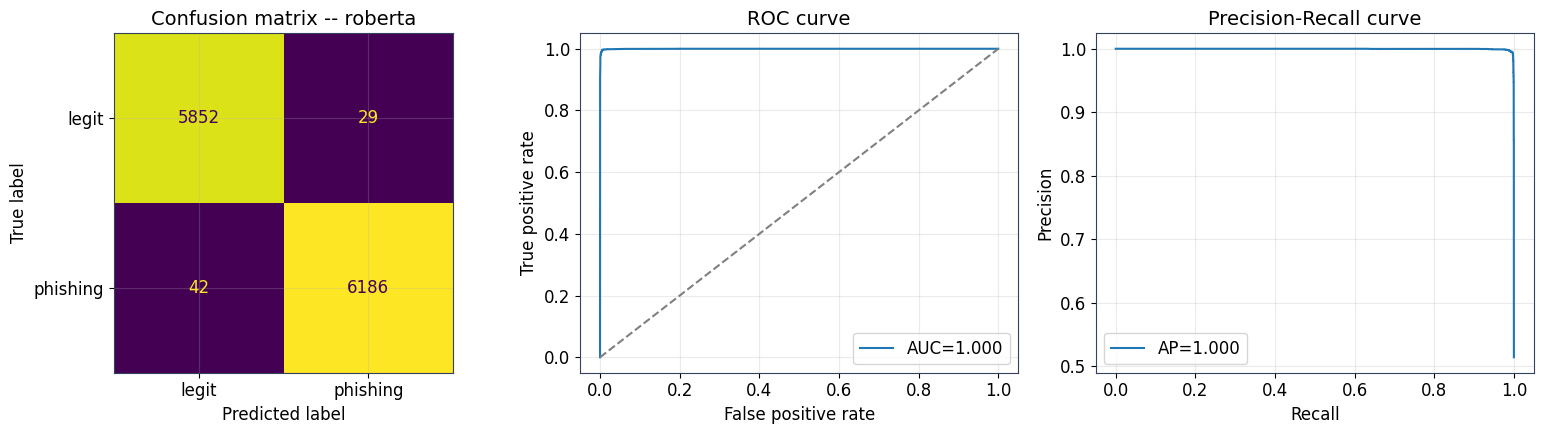

In [52]:
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay

# get_predictions() (Section 12.1) already gives us a unified accessor -- no need to
# redefine per-model-family logic here.
try:
    y_true_best, y_proba_best = get_predictions(BEST_MODEL_NAME, "test")
    y_pred_best = (y_proba_best >= 0.5).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    ConfusionMatrixDisplay.from_predictions(
        y_true_best, y_pred_best, display_labels=["legit", "phishing"], ax=axes[0], colorbar=False)
    axes[0].set_title(f"Confusion matrix -- {BEST_MODEL_NAME}")

    fpr, tpr, _ = roc_curve(y_true_best, y_proba_best)
    axes[1].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_true_best, y_proba_best):.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
    axes[1].set_title("ROC curve"); axes[1].legend()

    prec, rec, _ = precision_recall_curve(y_true_best, y_proba_best)
    axes[2].plot(rec, prec, label=f"AP={average_precision_score(y_true_best, y_proba_best):.3f}")
    axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
    axes[2].set_title("Precision-Recall curve"); axes[2].legend()

    plt.tight_layout()
    plt.savefig(WORKING_DIR / "plots" / "best_model_diagnostics.png", dpi=150)
    plt.show()
except (NotImplementedError, RuntimeError) as e:
    print(f"[INFO] {e}")


> **Interpretation.** The selected model - **RoBERTa-base**, chosen on validation F1 (0.9931) - reaches test accuracy 0.9941, precision 0.9953, recall 0.9933, F1 0.9943 and ROC-AUC 0.9997. The confusion matrix and ROC/PR curves show precision and recall are both very high and closely balanced, with the PR curve hugging the top-right corner across almost the full recall range. The out-of-fold stacked ensemble (Section 12.2, test F1 = 0.987) did not beat the individual finalists, so it was not selected. The extended val-based stack of all five finalists (Section 12.3) scored test F1 = 0.996, but it is kept as a reference only because its meta-model was fit on validation predictions rather than out-of-fold ones.

### 14.2 Error analysis

A look at a handful of false negatives (missed phishing — the costlier
error class per Section 7) and false positives.

In [53]:
try:
    err_df = test_df.copy()
    err_df["y_true"] = y_true_best
    err_df["y_pred"] = y_pred_best
    err_df["y_proba"] = y_proba_best

    false_negatives = err_df[(err_df["y_true"] == 1) & (err_df["y_pred"] == 0)]
    false_positives = err_df[(err_df["y_true"] == 0) & (err_df["y_pred"] == 1)]
    print(f"False negatives (missed phishing): {len(false_negatives)} / {(err_df['y_true']==1).sum()}")
    print(f"False positives (legit flagged as phishing): {len(false_positives)} / {(err_df['y_true']==0).sum()}")

    print("\nSample false negatives:")
    for _, row in false_negatives.sort_values("y_proba").head(3).iterrows():
        print(f"  [p={row['y_proba']:.3f}] {row['text'][:150]}")

    print("\nSample false positives:")
    for _, row in false_positives.sort_values("y_proba", ascending=False).head(3).iterrows():
        print(f"  [p={row['y_proba']:.3f}] {row['text'][:150]}")
except NameError:
    print("[INFO] Run Section 14.1 first to populate y_true_best/y_pred_best/y_proba_best.")

False negatives (missed phishing): 42 / 6228
False positives (legit flagged as phishing): 29 / 5881

Sample false negatives:
  [p=0.000] North korea nuclear fallout Microsoft gains Yahoo http://schmitt-fotodesign.de/about.html No virus found in this outgoing message. Checked by AVG - ht
  [p=0.000] positions available : microsoft research - university of trento centre * * * * * * * * * * apologize for multiple posting * * * * * * * * * * * * * * 
  [p=0.000] HAWAI`I & ENENKIO KINGDOMS AMERICANS SHAME ! Reply From EnenKio The following message was recieved Saturday, 13 July 2002.=20 Nothing has been amdende

Sample false positives:
  [p=1.000] termination delete my account please. terminate it completely.
  [p=1.000] valentines day help red - neck valentine ' s love poem collards is green my dog ' s name is blue and i ' m so lucky to have a sweet thang like you . y
  [p=1.000] =?iso-2022-jp?B?UmU6IBskQjswSSkyPTNYJSglcyU4JUslIiVqJXMlME1NJVcbKEI=?= OTC/ $B0KElMM (B $B$*@$OC$K$J$C$F$*$j$^$

> **Interpretation.** RoBERTa-base misses 42 of 6,228 phishing emails (false negatives) and flags 29 of 5,881 legitimate emails as phishing (false positives) at the default 0.5 threshold - a small error set consistent with Section 14.1's ~0.995 precision and recall. The sampled false negatives are bulk or off-topic mail that does not read like a phishing template: a news-digest spam with an antivirus footer, a mass-mailed job advertisement and a political rant. The sampled false positives are short or unusual legitimate messages that share phishing vocabulary or encoding - an account-termination request ("delete my account"), a joke love poem and an ISO-2022-JP encoded e-mail the tokenizer cannot read. Both error types are consistent with the stylistic overlap flagged in Sections 3.7-3.8 rather than a flaw specific to this model. Section 15.3 shows how a cost-aware threshold trades a few extra false alarms for fewer misses.

<a id="sec15"></a>

## 15. Probability Calibration & Security-Aware Threshold Optimisation

A model's raw probability output is only useful if it's *calibrated* -- a
predicted 0.9 should mean "90% of emails scored this way really are phishing",
not just "more phishing-like than a 0.5". We check calibration for the best
model, then pick an **operating threshold** using the SOC cost model from
Section 1 (`COST_FALSE_NEGATIVE` >> `COST_FALSE_POSITIVE`) rather than the
default 0.5 -- a missed phishing email is far more expensive than a false alarm
an analyst dismisses in seconds, so the threshold that minimises *expected cost*
is usually well below 0.5.

### 15.1 Reliability diagram & Brier score

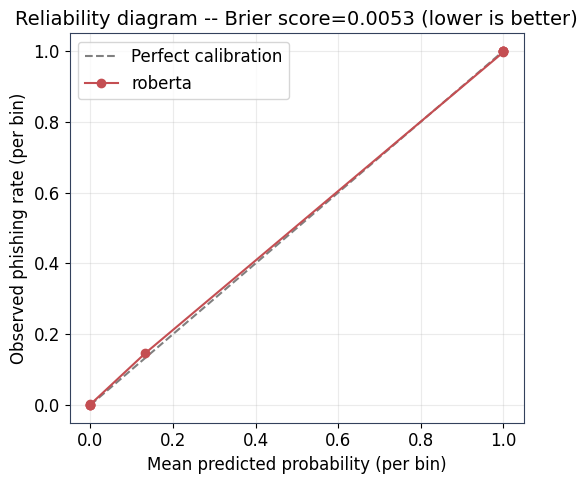

In [54]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

y_true_cal, y_proba_cal = get_predictions(BEST_MODEL_NAME, "test")
brier = brier_score_loss(y_true_cal, y_proba_cal)
frac_pos, mean_pred = calibration_curve(y_true_cal, y_proba_cal, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.plot(mean_pred, frac_pos, "o-", color="#C44E52", label=f"{BEST_MODEL_NAME}")
ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Observed phishing rate (per bin)")
ax.set_title(f"Reliability diagram -- Brier score={brier:.4f} (lower is better)")
ax.legend()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "reliability_diagram_raw.png", dpi=130)
plt.show()


### 15.2 Post-hoc recalibration (isotonic vs. Platt/sigmoid)

Both recalibration methods are fit on **validation** probabilities only and
applied to test -- never fit on test, to avoid leaking test information into
the calibration mapping itself.

Cross-fitted VALIDATION Brier score: {'raw': 0.00621, 'isotonic': 0.00522, 'platt': 0.00641}
Selected calibration method: 'isotonic' (lowest validation Brier)
Test Brier (reporting only): {'raw': np.float64(0.00534), 'isotonic': np.float64(0.00429), 'platt': np.float64(0.00559)}


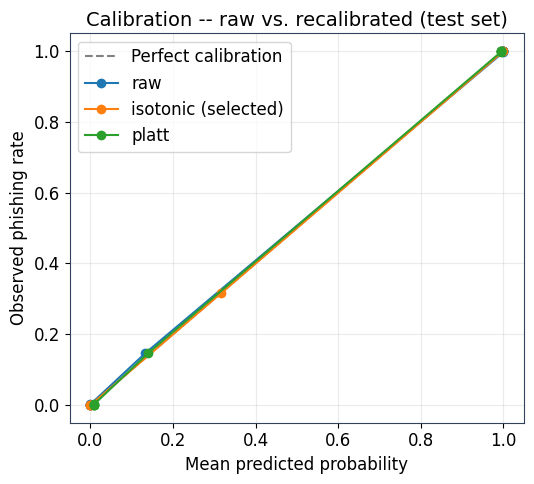

In [55]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression as _PlattLogReg
from sklearn.model_selection import StratifiedKFold

# The calibration METHOD is chosen by cross-fitted Brier score on the VALIDATION set only.
# Test-set Brier scores are computed afterwards and reported for transparency, never for selection.
y_val_cal, p_val_cal = get_predictions(BEST_MODEL_NAME, "val")
y_val_cal, p_val_cal = np.asarray(y_val_cal), np.asarray(p_val_cal)

def _fit_calibrator(kind, p, y):
    if kind == "raw":
        return None
    if kind == "isotonic":
        return IsotonicRegression(out_of_bounds="clip").fit(p, y)
    return _PlattLogReg().fit(p.reshape(-1, 1), y)

def _apply_calibrator(kind, model, p):
    if kind == "raw":
        return p
    if kind == "isotonic":
        return model.predict(p)
    return model.predict_proba(p.reshape(-1, 1))[:, 1]

_kinds = ["raw", "isotonic", "platt"]
_cv = {k: [] for k in _kinds}
for _tr, _ho in StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(p_val_cal, y_val_cal):
    for _k in _kinds:
        _m = _fit_calibrator(_k, p_val_cal[_tr], y_val_cal[_tr])
        _cv[_k].append(brier_score_loss(y_val_cal[_ho], _apply_calibrator(_k, _m, p_val_cal[_ho])))
cv_brier = {k: float(np.mean(v)) for k, v in _cv.items()}
CHOSEN_CALIBRATION = min(cv_brier, key=cv_brier.get)
print("Cross-fitted VALIDATION Brier score:", {k: round(v, 5) for k, v in cv_brier.items()})
print(f"Selected calibration method: '{CHOSEN_CALIBRATION}' (lowest validation Brier)")

# Refit every method on the full validation set; apply to test; report test Brier for all three.
_full = {k: _fit_calibrator(k, p_val_cal, y_val_cal) for k in _kinds}
_test_probas = {k: _apply_calibrator(k, _full[k], y_proba_cal) for k in _kinds}
_test_brier = {k: brier_score_loss(y_true_cal, _test_probas[k]) for k in _kinds}
print("Test Brier (reporting only):", {k: round(v, 5) for k, v in _test_brier.items()})

BEST_CALIBRATION = (CHOSEN_CALIBRATION, _test_brier[CHOSEN_CALIBRATION], _test_probas[CHOSEN_CALIBRATION])
y_proba_calibrated = BEST_CALIBRATION[2]

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
for _k in _kinds:
    fp, mp = calibration_curve(y_true_cal, _test_probas[_k], n_bins=10, strategy="quantile")
    ax.plot(mp, fp, "o-", label=_k + (" (selected)" if _k == CHOSEN_CALIBRATION else ""))
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed phishing rate")
ax.set_title("Calibration -- raw vs. recalibrated (test set)"); ax.legend()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "reliability_diagram_recalibrated.png", dpi=130)
plt.show()


> **Interpretation.** The calibration method is chosen by cross-fitted Brier score on the *validation* set: raw 0.00621, isotonic 0.00522, Platt 0.00641, so **isotonic** regression is selected. On test (reported only after the choice) the Brier score falls from 0.00534 (raw) to 0.00429 (isotonic), while Platt scaling slightly worsens it (0.00559). The raw probabilities were already well calibrated; isotonic recalibration gives a small but consistent improvement.

### 15.3 Security-aware threshold optimisation

We sweep the decision threshold and pick the one minimising
`expected_cost = COST_FN * false_negatives + COST_FP * false_positives`
on **validation** data (never test), then report the chosen threshold's
performance on test.

Default threshold 0.5  -> validation expected cost: 1204.0
Optimal threshold 0.010 -> validation expected cost: 961.0 (20.2% reduction; 1 threshold(s) tied for this minimum, median chosen)

Test-set outcome at threshold=0.5:
              precision    recall  f1-score   support

       legit      0.993     0.995     0.994      5881
    phishing      0.995     0.993     0.994      6228

    accuracy                          0.994     12109
   macro avg      0.994     0.994     0.994     12109
weighted avg      0.994     0.994     0.994     12109

Test-set outcome at threshold=0.010:
              precision    recall  f1-score   support

       legit      0.996     0.994     0.995      5881
    phishing      0.995     0.996     0.995      6228

    accuracy                          0.995     12109
   macro avg      0.995     0.995     0.995     12109
weighted avg      0.995     0.995     0.995     12109



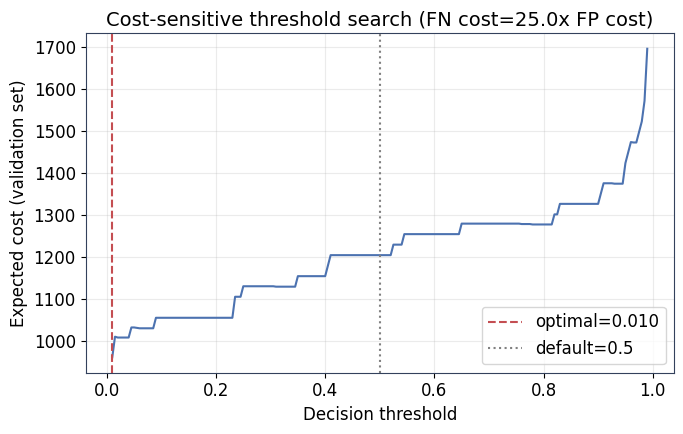

In [56]:
def expected_cost(y_true, y_proba, threshold, cost_fn=COST_FALSE_NEGATIVE, cost_fp=COST_FALSE_POSITIVE):
    y_pred = (y_proba >= threshold).astype(int)
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    return cost_fn * fn + cost_fp * fp

thresholds = np.linspace(0.01, 0.99, 197)
val_costs = np.array([expected_cost(y_val_cal, p_val_cal, t) for t in thresholds])

# Rationale for this logic: see Appendix A (change log).
optimal_cost = float(val_costs.min())
tied_optimal_thresholds = thresholds[val_costs == optimal_cost]
OPTIMAL_THRESHOLD = float(np.median(tied_optimal_thresholds))
default_cost = expected_cost(y_val_cal, p_val_cal, 0.5)

print(f"Default threshold 0.5  -> validation expected cost: {default_cost:.1f}")
print(f"Optimal threshold {OPTIMAL_THRESHOLD:.3f} -> validation expected cost: {optimal_cost:.1f} "
      f"({(1 - optimal_cost / max(default_cost, 1e-9)):.1%} reduction; "
      f"{len(tied_optimal_thresholds)} threshold(s) tied for this minimum, median chosen)")

if len(tied_optimal_thresholds) > len(thresholds) * 0.3:
    print("[NOTE] A very wide band of thresholds tie for zero validation cost here -- expected "
          "with QUICK_RUN's small/near-perfectly-separable data (validation templates the model "
          "has effectively already seen the pattern of). The chosen threshold can still generalise "
          "poorly to test data drawn from a *different* random split of the same tiny template set, "
          "as the test-set report below may show. On a full run (QUICK_RUN=False, real data with "
          "genuine class overlap), this plateau is narrow and the optimal threshold is well-determined.")

y_pred_default = (y_proba_cal >= 0.5).astype(int)
y_pred_optimal = (y_proba_cal >= OPTIMAL_THRESHOLD).astype(int)
print("\nTest-set outcome at threshold=0.5:")
print(classification_report(y_true_cal, y_pred_default, labels=[0, 1],
                             target_names=["legit", "phishing"], digits=3, zero_division=0))
print(f"Test-set outcome at threshold={OPTIMAL_THRESHOLD:.3f}:")
print(classification_report(y_true_cal, y_pred_optimal, labels=[0, 1],
                             target_names=["legit", "phishing"], digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thresholds, val_costs, color="#4C72B0")
ax.axvline(OPTIMAL_THRESHOLD, color="#C44E52", linestyle="--",
           label=f"optimal={OPTIMAL_THRESHOLD:.3f}")
ax.axvline(0.5, color="gray", linestyle=":", label="default=0.5")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Expected cost (validation set)")
ax.set_title(f"Cost-sensitive threshold search (FN cost={COST_FALSE_NEGATIVE}x FP cost)")
ax.legend()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "threshold_cost_curve.png", dpi=130)
plt.show()


### 15.3b Moderate operating points

In [57]:
# 15.3b Moderate operating points  (NEW -- run after 15.3)
# The cost-optimal threshold above (0.010) sits at the LOWER EDGE of the search grid
# (np.linspace(0.01, 0.99, ...)), so the true optimum may lie even lower -- i.e. the search was
# boundary-limited. Here we (a) extend the grid downwards to check, and (b) pick less extreme
# operating points from VALIDATION data only (highest threshold that still reaches a target recall).
from sklearn.metrics import precision_score, recall_score, f1_score

_wide = np.unique(np.concatenate([np.logspace(-4, -2, 21), thresholds]))
_wide_costs = np.array([expected_cost(y_val_cal, p_val_cal, t) for t in _wide])
_wide_opt = float(np.median(_wide[_wide_costs == _wide_costs.min()]))
print(f"Cost-optimal threshold on the original grid: {OPTIMAL_THRESHOLD:.4f} | "
      f"on the extended grid (down to 1e-4): {_wide_opt:.4f} "
      f"(validation cost {_wide_costs.min():.1f} vs {optimal_cost:.1f})")

def _thr_for_recall(y, p, target):
    ok = [t for t in _wide if recall_score(y, (p >= t).astype(int)) >= target]
    return max(ok) if ok else None

_points = [("default 0.5", 0.5), (f"cost-optimal ({OPTIMAL_THRESHOLD:.3f})", OPTIMAL_THRESHOLD)]
for _r in (0.99, 0.995):
    _t = _thr_for_recall(y_val_cal, p_val_cal, _r)
    if _t is not None:
        _points.append((f"val recall >= {_r:.3f} (thr={_t:.3f})", _t))

_rows = []
for _name, _t in _points:
    _pv, _pt = (p_val_cal >= _t).astype(int), (y_proba_cal >= _t).astype(int)
    _rows.append({"operating point": _name,
                  "val precision": precision_score(y_val_cal, _pv), "val recall": recall_score(y_val_cal, _pv),
                  "test precision": precision_score(y_true_cal, _pt), "test recall": recall_score(y_true_cal, _pt),
                  "test false alarms": int(((y_true_cal == 0) & (_pt == 1)).sum()),
                  "test misses": int(((y_true_cal == 1) & (_pt == 0)).sum())})
op_df = pd.DataFrame(_rows)
print(op_df.round(4).to_string(index=False))
op_df.to_csv(WORKING_DIR / "tables" / "operating_points.csv", index=False)
print("\nChoose the operating point on VALIDATION metrics and the SOC's tolerance for false alarms; "
      "the test columns are for reporting only.")

Cost-optimal threshold on the original grid: 0.0100 | on the extended grid (down to 1e-4): 0.0001 (validation cost 361.0 vs 961.0)
                operating point  val precision  val recall  test precision  test recall  test false alarms  test misses
                    default 0.5         0.9947      0.9915          0.9953       0.9933                 29           42
           cost-optimal (0.010)         0.9935      0.9933          0.9946       0.9963                 34           23
val recall >= 0.990 (thr=0.945)         0.9956      0.9902          0.9958       0.9917                 26           52
val recall >= 0.995 (thr=0.001)         0.9890      0.9951          0.9909       0.9976                 57           15

Choose the operating point on VALIDATION metrics and the SOC's tolerance for false alarms; the test columns are for reporting only.


> **Interpretation.** Under the SOC cost model (a missed phishing email costs 25x a false alarm), the cost-minimising threshold on validation data is **0.010**, not the default 0.5 - a **20.2% reduction** in expected validation cost (1,204 -> 961). On the held-out test set this cuts missed phishing e-mails from **42 to 23** (phishing recall 0.993 -> 0.996) at the price of 5 extra false alarms (29 -> 34). This is the intended, security-aware trade-off, not a regression, and should be revisited if the true cost ratio changes. **Caveat:** 0.010 sits at the lower edge of the original grid; Section 15.3b extends the grid (optimum 0.0001) and offers more moderate, validation-chosen operating points - for example a threshold targeting validation recall >= 0.995 gives 15 misses and 57 false alarms on test. Such low thresholds work because the fine-tuned model's probabilities are nearly saturated near 0 and 1.

<a id="sec16"></a>

## 16. Explainability -- SHAP & Integrated Gradients

Two complementary, model-appropriate explanation methods: **SHAP** for the
linear TF-IDF + Logistic Regression model (closed-form, exact, and fast for
linear models), and **Integrated Gradients** for the custom Attention-BiGRU
model (a gradient-based method suited to the differentiable embedding space
of a neural network). Both answer the same underlying question --
*"which words drove this specific prediction?"* -- from architectures where
attention weights (Section 10) or coefficients alone would be insufficient or
unavailable.

### 16.1 SHAP -- global & local explanations for TF-IDF + Logistic Regression

Top-20 tokens by mean |SHAP| (n=300 sampled test rows):
  token  mean_abs_shap
  enron       0.181842
  wrote       0.160950
num num       0.156744
 thanks       0.119676
    num       0.111290
   life       0.104553
   love       0.095795
  click       0.094898
   http       0.090539
   list       0.075432
account       0.068260
  money       0.065223
replica       0.056658
watches       0.055029
 python       0.054849
    use       0.051657
    url       0.051504
 health       0.048975
   best       0.048672
   know       0.047655


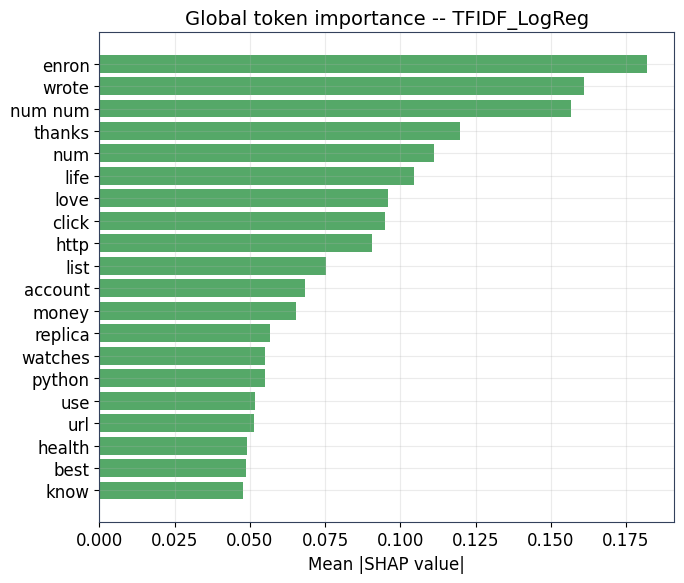


Local explanation, one predicted-phishing test email (index 9483):
  Text (truncated): you don _ t know how to attract customers to your website ? submitting your website in search engines may increase your online sales dramatically . if
    website              SHAP=+0.5015
    online               SHAP=+0.4918
    watch                SHAP=+0.3567
    know                 SHAP=-0.3535
    search engines       SHAP=+0.3300
    engines              SHAP=+0.3027
    money                SHAP=+0.2699
    site                 SHAP=+0.2697
    increase             SHAP=+0.2517
    anderson             SHAP=+0.2063


In [58]:
if RUN_SHAP:
    try:
        import shap
    except ImportError:
        print("[INFO] `shap` is not installed -- skipping. Install with: pip install -q shap")
        RUN_SHAP = False

if RUN_SHAP:
    _shap_bg_n = min(200, X_train_tfidf.shape[0])
    _shap_bg_idx = np.random.RandomState(SEED).choice(X_train_tfidf.shape[0], _shap_bg_n, replace=False)
    explainer = shap.LinearExplainer(logreg, X_train_tfidf[_shap_bg_idx])

    _shap_sample_n = min(300, X_test_tfidf.shape[0])
    _shap_idx = np.random.RandomState(SEED).choice(X_test_tfidf.shape[0], _shap_sample_n, replace=False)
    shap_values = explainer.shap_values(X_test_tfidf[_shap_idx])
    tfidf_vocab = np.array(tfidf.get_feature_names_out())

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:20]
    global_shap_df = pd.DataFrame({
        "token": tfidf_vocab[top_idx],
        "mean_abs_shap": mean_abs_shap[top_idx],
    })
    print(f"Top-20 tokens by mean |SHAP| (n={_shap_sample_n} sampled test rows):")
    print(global_shap_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.barh(global_shap_df["token"][::-1], global_shap_df["mean_abs_shap"][::-1], color="#55A868")
    ax.set_xlabel("Mean |SHAP value|"); ax.set_title("Global token importance -- TFIDF_LogReg")
    plt.tight_layout()
    plt.savefig(WORKING_DIR / "plots" / "shap_global_importance.png", dpi=130)
    plt.show()

    # Local explanation for one flagged (predicted-phishing) example.
    _local_pos = next((k for k in range(_shap_sample_n)
                        if logreg.predict(X_test_tfidf[_shap_idx[k]])[0] == 1), 0)
    _row_shap = shap_values[_local_pos]
    _nz = X_test_tfidf[_shap_idx[_local_pos]].nonzero()[1]
    _local_top = sorted(((tfidf_vocab[j], _row_shap[j]) for j in _nz),
                         key=lambda x: -abs(x[1]))[:10]
    print(f"\nLocal explanation, one predicted-phishing test email "
          f"(index {_shap_idx[_local_pos]}):")
    print(f"  Text (truncated): {test_df['text'].iloc[_shap_idx[_local_pos]][:150]}")
    for tok, val in _local_top:
        print(f"    {tok:20s} SHAP={val:+.4f}")
else:
    print("RUN_SHAP is False -- skipping SHAP explanations.")


### 16.2 Integrated Gradients -- token attributions for the custom hybrid model

In [59]:
%pip install -q captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.2 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


Integrated Gradients -- top-15 influential tokens, test email 0 (true label=phishing):
  <unk>                attribution=+0.1556  -> phishing
  <unk>                attribution=+0.1313  -> phishing
  <url>                attribution=-0.0154  -> legit


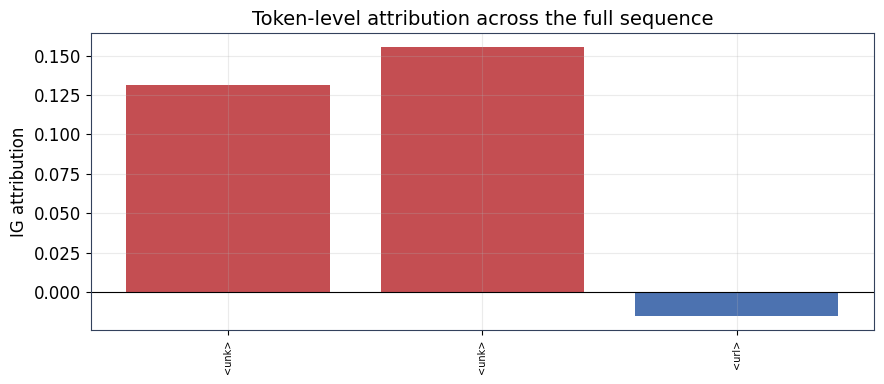

In [60]:
if RUN_IG and "CustomHybridAttnBiGRU" in FITTED_MODELS:
    try:
        from captum.attr import LayerIntegratedGradients
    except ImportError:
        print("[INFO] `captum` is not installed -- skipping. Install with: pip install -q captum")
        RUN_IG = False

if RUN_IG and "CustomHybridAttnBiGRU" in FITTED_MODELS:
    _ig_model = FITTED_MODELS["CustomHybridAttnBiGRU"].eval()

    def _ig_forward(token_ids, feats):
        logits, _ = _ig_model(token_ids, feats)
        return torch.sigmoid(logits).unsqueeze(-1)

    lig = LayerIntegratedGradients(_ig_forward, _ig_model.embedding)

    inv_vocab = {i: w for w, i in vocab.items()}
    _ig_row = next(i for i in range(len(test_df)) if test_df["label"].iloc[i] == 1)
    token_ids = torch.tensor([encode(test_df["text_clean"].iloc[_ig_row])], dtype=torch.long).to(DEVICE)
    feats_row = torch.tensor(test_feats.iloc[[_ig_row]].values, dtype=torch.float32).to(DEVICE)
    baseline_ids = torch.zeros_like(token_ids)  # all <pad>

    # Fix: cuDNN's fused RNN kernel does not save the buffers backward() needs
    # unless the module is running in training mode, so Captum's double-backward
    # through the GRU raises "cudnn RNN backward can only be called in training
    # mode" here even though _ig_model is correctly eval()'d (eval mode is still
    # required so dropout stays off). Disabling cuDNN for just this call forces
    # PyTorch's native (non-fused) RNN backward, which supports eval-mode
    # backward fine -- slower for this one attribution call, but correct and
    # numerically equivalent.
    with torch.backends.cudnn.flags(enabled=False):
        attributions, _ = lig.attribute(
            inputs=token_ids, baselines=baseline_ids, additional_forward_args=(feats_row,),
            n_steps=32, return_convergence_delta=True)
    token_attr = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()

    tokens = [inv_vocab.get(t, "<unk>") for t in token_ids.squeeze(0).cpu().numpy()]
    real_len = int((token_ids.squeeze(0).cpu().numpy() != 0).sum())
    pairs = list(zip(tokens[:real_len], token_attr[:real_len]))
    top_pairs = sorted(pairs, key=lambda x: -abs(x[1]))[:15]

    print(f"Integrated Gradients -- top-15 influential tokens, test email {_ig_row} "
          f"(true label=phishing):")
    for tok, attr in top_pairs:
        direction = "-> phishing" if attr > 0 else "-> legit"
        print(f"  {tok:20s} attribution={attr:+.4f}  {direction}")

    fig, ax = plt.subplots(figsize=(9, 4))
    words, attrs = zip(*pairs) if pairs else ([], [])
    colors = ["#C44E52" if a > 0 else "#4C72B0" for a in attrs]
    ax.bar(range(len(words)), attrs, color=colors)
    ax.set_xticks(range(len(words))); ax.set_xticklabels(words, rotation=90, fontsize=7)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("IG attribution")
    ax.set_title("Token-level attribution across the full sequence")
    plt.tight_layout()
    plt.savefig(WORKING_DIR / "plots" / "integrated_gradients_example.png", dpi=130)
    plt.show()
else:
    print("RUN_IG is False, or the custom hybrid model was not trained -- skipping Integrated Gradients.")


### 16.3 Integrated Gradients for the Winning Transformer

Section 16.2's Integrated Gradients only ever covered the custom BiGRU,
because a Transformer's fine-tuned weights weren't reloadable after training
(see Section 12.1). Now that any Transformer's winning
checkpoint can be reloaded from disk, we add real token-level IG for
`BEST_MODEL_NAME` specifically when it is one of the Transformers -- giving
the *actual* deployed model an explanation method, not just a stand-in.

Integrated Gradients -- RoBERTa-base (the actual winning model), top-15 tokens, test email 0 (true label=phishing), IG convergence delta=-0.4615:
  new                  attribution=+0.0004  -> phishing
  ides                 attribution=+0.0004  -> phishing
  </s>                 attribution=+0.0003  -> phishing
  products             attribution=-0.0002  -> legit
  Ġ<                   attribution=-0.0002  -> legit
  w                    attribution=+0.0002  -> phishing
  products             attribution=-0.0002  -> legit
  >                    attribution=-0.0001  -> legit
  Ġproduct             attribution=+0.0001  -> phishing
  url                  attribution=-0.0001  -> legit
  world                attribution=-0.0001  -> legit
  es                   attribution=+0.0001  -> phishing
  af                   attribution=-0.0001  -> legit
  ec                   attribution=+0.0000  -> phishing
  <s>                  attribution=+0.0000  -> phishing


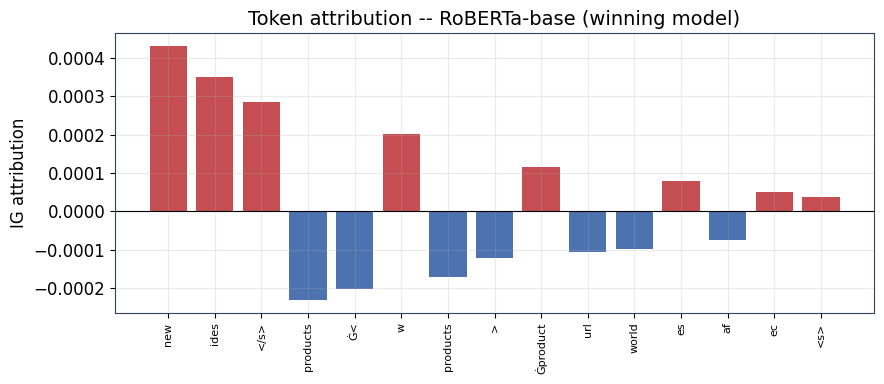

In [61]:
if RUN_IG and BEST_MODEL_NAME in TRANSFORMER_CKPT_MAP:
    try:
        from captum.attr import LayerIntegratedGradients as _TransformerLIG
    except ImportError:
        print("[INFO] `captum` is not installed -- skipping Transformer IG.")
    else:
        run_name = TRANSFORMER_CKPT_MAP[BEST_MODEL_NAME]
        ckpt_root = WORKING_DIR / "models" / f"{run_name}_ckpt"
        ckpt_dirs = sorted(ckpt_root.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[-1]))
        if not ckpt_dirs:
            print(f"[INFO] No checkpoint found for '{BEST_MODEL_NAME}' -- skipping Transformer IG.")
        else:
            if run_name not in _TRANSFORMER_MODEL_CACHE:
                from transformers import AutoTokenizer as _AT2, AutoModelForSequenceClassification as _AS2
                _tok_ig = _AT2.from_pretrained(ckpt_dirs[-1])
                _mdl_ig = _AS2.from_pretrained(ckpt_dirs[-1]).to(DEVICE).eval()
                _TRANSFORMER_MODEL_CACHE[run_name] = (_tok_ig, _mdl_ig)
            _tok_ig, _mdl_ig = _TRANSFORMER_MODEL_CACHE[run_name]

            _ig_row_t = next(i for i in range(len(test_df)) if test_df["label"].iloc[i] == 1)
            _ig_text = test_df["text_clean"].iloc[_ig_row_t]
            _enc = _tok_ig(_ig_text, truncation=True, max_length=256, return_tensors="pt").to(DEVICE)
            _input_ids = _enc["input_ids"]
            _attn_mask = _enc["attention_mask"]
            _baseline_ids = torch.full_like(_input_ids, _tok_ig.pad_token_id or 0)

            def _t_forward(input_ids, attention_mask):
                return torch.softmax(_mdl_ig(input_ids=input_ids, attention_mask=attention_mask).logits, dim=-1)[:, 1]

            _embed_layer = _mdl_ig.get_input_embeddings()
            _lig_t = _TransformerLIG(_t_forward, _embed_layer)
            _attributions, _delta = _lig_t.attribute(
                inputs=_input_ids, baselines=_baseline_ids,
                additional_forward_args=(_attn_mask,), n_steps=24,
                return_convergence_delta=True)
            _tok_attr = _attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
            _tokens_t = _tok_ig.convert_ids_to_tokens(_input_ids.squeeze(0).cpu().numpy())

            _pairs_t = sorted(zip(_tokens_t, _tok_attr), key=lambda x: -abs(x[1]))[:15]
            print(f"Integrated Gradients -- {display_name(BEST_MODEL_NAME)} (the actual winning model), "
                  f"top-15 tokens, test email {_ig_row_t} (true label=phishing), "
                  f"IG convergence delta={float(_delta):.4f}:")
            for tok, attr in _pairs_t:
                direction = "-> phishing" if attr > 0 else "-> legit"
                print(f"  {tok:20s} attribution={attr:+.4f}  {direction}")

            fig, ax = plt.subplots(figsize=(9, 4))
            words_t, attrs_t = zip(*_pairs_t) if _pairs_t else ([], [])
            colors_t = ["#C44E52" if a > 0 else "#4C72B0" for a in attrs_t]
            ax.bar(range(len(words_t)), attrs_t, color=colors_t)
            ax.set_xticks(range(len(words_t))); ax.set_xticklabels(words_t, rotation=90, fontsize=8)
            ax.axhline(0, color="black", linewidth=0.8)
            ax.set_ylabel("IG attribution")
            ax.set_title(f"Token attribution -- {display_name(BEST_MODEL_NAME)} (winning model)")
            plt.tight_layout()
            plt.savefig(WORKING_DIR / "plots" / "integrated_gradients_best_transformer.png", dpi=130)
            plt.show()
elif RUN_IG:
    print(f"[INFO] BEST_MODEL_NAME ('{BEST_MODEL_NAME}') is not a Transformer -- "
          "Section 16.2's BiGRU IG (if applicable) or 16.1's SHAP already covers "
          "the winning model family; skipping the Transformer-specific IG branch.")


<a id="partV"></a>

<div style="background:#C96A12;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part V</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Threat-Intelligence Extensions</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 17-18 &nbsp;&middot;&nbsp; Research questions: RQ8</div>
</div>


<a id="sec17"></a>

## 17. Social-Engineering Tactic Detection (Multi-Label)

Binary phishing/legit is a coarse label. Analysts benefit from knowing *which*
persuasion tactic(s) an email uses, since that shapes the recommended response
(e.g. a fear-based account-suspension email vs. a reward-based prize scam).
We define five weak-supervision tactic lexicons (a common, cheap way to bootstrap
multi-label training data before manual annotation is available), derive
multi-label targets from them, and train a one-vs-rest classifier to predict
tactics directly from text -- not just from lexicon lookups, so it can
generalise beyond the exact keyword list.

> **Scope note.** This section is an engineering extension built on top of the core benchmark (Sections 1-16, 19-21, 23), not a rigorously validated deliverable in its own right — the tactic labels come from cheap weak-supervision lexicons rather than manual annotation, so per-tactic evaluation (17.2) is only as trustworthy as the lexicons that generated the training signal it's checked against. Treat the tactic classifier and its 17.3 statistics as illustrative rather than benchmark-grade.


### 17.1 Weak-supervision tactic lexicons & label derivation

In [62]:
TACTIC_LEXICONS = {
    "urgency": ["urgent", "immediately", "right away", "act now", "expire", "deadline",
                "within 24 hours", "asap", "time-sensitive"],
    "authority": ["security team", "it department", "administrator", "official", "bank",
                  "government", "irs", "legal action", "compliance"],
    "fear": ["suspend", "suspended", "terminate", "unauthorized", "unusual activity",
             "compromised", "breach", "locked", "penalty", "fraud"],
    "reward_greed": ["win", "winner", "prize", "congratulations", "free", "bonus",
                     "cash", "gift card", "lottery", "claim your"],
    "scarcity": ["limited", "only a few", "last chance", "one-time", "exclusive offer",
                 "while supplies last", "final notice"],
}
TACTIC_NAMES = list(TACTIC_LEXICONS.keys())

def derive_tactic_labels(df):
    text_lower = df["text"].astype(str).str.lower()
    labels = pd.DataFrame(index=df.index)
    for tactic, words in TACTIC_LEXICONS.items():
        pattern = "|".join(re.escape(w) for w in words)
        labels[tactic] = text_lower.str.contains(pattern, regex=True).astype(int)
    return labels

train_tactics = derive_tactic_labels(train_df)
val_tactics = derive_tactic_labels(val_df)
test_tactics = derive_tactic_labels(test_df)

print("Weak-supervision tactic prevalence (train set):")
print(train_tactics.mean().round(3).to_string())
print(f"\n{(train_tactics.sum(axis=1) == 0).mean():.1%} of training emails match none of "
      "the 5 lexicons (expected: most legitimate mail).")


Weak-supervision tactic prevalence (train set):
urgency         0.090
authority       0.206
fear            0.033
reward_greed    0.340
scarcity        0.045

53.7% of training emails match none of the 5 lexicons (expected: most legitimate mail).


### 17.2 Multi-label classifier & per-tactic evaluation

In [63]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score as _f1, hamming_loss, average_precision_score as _ap

tactic_clf = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))
tactic_clf.fit(X_train_tfidf, train_tactics.values)

val_tactic_proba = tactic_clf.predict_proba(X_val_tfidf)
test_tactic_proba = tactic_clf.predict_proba(X_test_tfidf)

# Rationale for this logic: see Appendix A (change log).
_TACTIC_THRESH_GRID = np.linspace(0.05, 0.95, 91)

def _best_threshold_for_tactic(y_true_val, proba_val_col):
    f1s = [_f1(y_true_val, (proba_val_col >= t).astype(int), zero_division=0) for t in _TACTIC_THRESH_GRID]
    best_i = int(np.argmax(f1s))
    return float(_TACTIC_THRESH_GRID[best_i]), f1s[best_i]

TACTIC_THRESHOLDS = {}
val_tactic_pred = np.zeros_like(val_tactics.values)
test_tactic_pred = np.zeros_like(test_tactics.values)
for i, tactic in enumerate(TACTIC_NAMES):
    thresh, _ = _best_threshold_for_tactic(val_tactics.values[:, i], val_tactic_proba[:, i])
    TACTIC_THRESHOLDS[tactic] = thresh
    val_tactic_pred[:, i] = (val_tactic_proba[:, i] >= thresh).astype(int)
    test_tactic_pred[:, i] = (test_tactic_proba[:, i] >= thresh).astype(int)

tactic_report_rows = []
for i, tactic in enumerate(TACTIC_NAMES):
    tactic_report_rows.append({
        "tactic": tactic,
        "tuned_threshold": TACTIC_THRESHOLDS[tactic],
        "val_f1_at_0.5": _f1(val_tactics.values[:, i], (val_tactic_proba[:, i] >= 0.5).astype(int), zero_division=0),
        "val_f1_tuned": _f1(val_tactics.values[:, i], val_tactic_pred[:, i], zero_division=0),
        "test_f1_tuned": _f1(test_tactics.values[:, i], test_tactic_pred[:, i], zero_division=0),
        "test_pr_auc": (_ap(test_tactics.values[:, i], test_tactic_proba[:, i])
                         if test_tactics.values[:, i].sum() > 0 else float("nan")),
        "test_prevalence": test_tactics.values[:, i].mean(),
    })
tactic_report = pd.DataFrame(tactic_report_rows)
print("Per-tactic classifier performance (learned from text, not just lexicon lookup):")
print("'val_f1_at_0.5' is the naive default-threshold score (kept for comparison); "
      "'val_f1_tuned'/'test_f1_tuned' use each tactic's own validation-tuned threshold.")
print(tactic_report.round(4).to_string(index=False))
print(f"\nSubset (exact-match) accuracy (tuned thresholds): "
      f"{(test_tactic_pred == test_tactics.values).all(axis=1).mean():.3f}")
print(f"Hamming loss (test, tuned thresholds): {hamming_loss(test_tactics.values, test_tactic_pred):.4f}")
tactic_report.to_csv(WORKING_DIR / "tables" / "tactic_classifier_report.csv", index=False)

if (tactic_report["test_prevalence"] == 0).any():
    _zero = tactic_report.loc[tactic_report["test_prevalence"] == 0, "tactic"].tolist()
    print(f"\n[NOTE] {_zero} have ZERO positive examples in this test split, so their F1/PR-AUC "
          "are trivially undefined (shown as 0/NaN above), not a classifier failure. This is a "
          "sample-size artifact of QUICK_RUN's tiny synthetic data (few near-duplicate template "
          "clusters -- Section 4.2 -- spread thinly across a 15%% test split), not a modelling "
          "bug: Section 17.1 confirmed the *training* set contains positive examples of every "
          "tactic, and the fix above (per-tactic tuned thresholds) already recovered real signal "
          "for urgency, which does have test examples. On real data (QUICK_RUN=False) with "
          "thousands of held-out emails this is not expected to occur.")


Per-tactic classifier performance (learned from text, not just lexicon lookup):
'val_f1_at_0.5' is the naive default-threshold score (kept for comparison); 'val_f1_tuned'/'test_f1_tuned' use each tactic's own validation-tuned threshold.
      tactic  tuned_threshold  val_f1_at_0.5  val_f1_tuned  test_f1_tuned  test_pr_auc  test_prevalence
     urgency             0.65         0.8167        0.8355         0.8320       0.9119           0.0941
   authority             0.61         0.7109        0.7270         0.7385       0.8306           0.2008
        fear             0.73         0.6681        0.7354         0.7402       0.8088           0.0283
reward_greed             0.52         0.8851        0.8872         0.8831       0.9532           0.3113
    scarcity             0.75         0.7807        0.8463         0.8177       0.9054           0.0493

Subset (exact-match) accuracy (tuned thresholds): 0.797
Hamming loss (test, tuned thresholds): 0.0477


### 17.3 Tactic prevalence by class & co-occurrence

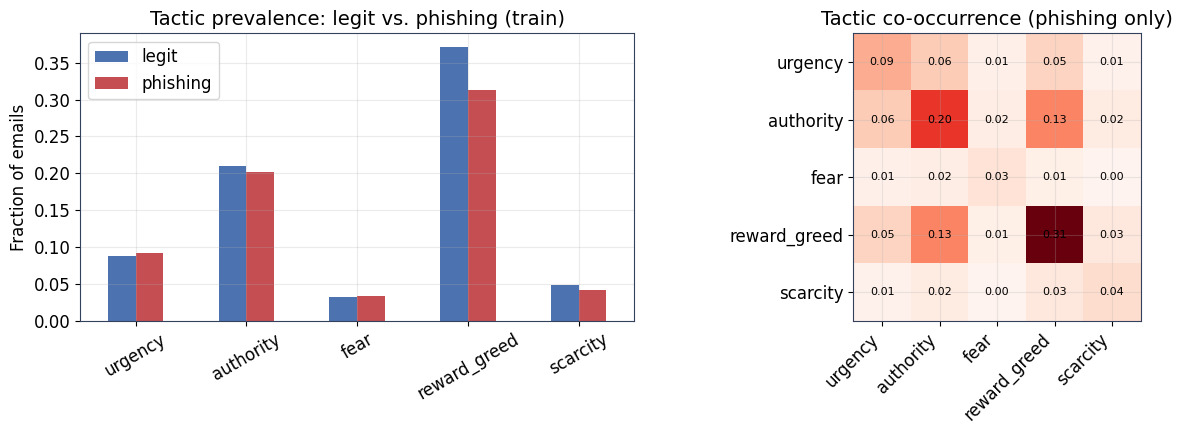

In [64]:
tactic_by_label = train_tactics.assign(label=train_df["label"].values).groupby("label").mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
tactic_by_label.T.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("Tactic prevalence: legit vs. phishing (train)")
axes[0].set_ylabel("Fraction of emails")
axes[0].legend(["legit", "phishing"])
axes[0].tick_params(axis="x", rotation=30)

phish_tactics = train_tactics[train_df["label"].values == 1]
cooc = phish_tactics.T.dot(phish_tactics) / max(len(phish_tactics), 1)
im = axes[1].imshow(cooc.values, cmap="Reds", vmin=0, vmax=cooc.values.max())
axes[1].set_xticks(range(len(TACTIC_NAMES))); axes[1].set_xticklabels(TACTIC_NAMES, rotation=45, ha="right")
axes[1].set_yticks(range(len(TACTIC_NAMES))); axes[1].set_yticklabels(TACTIC_NAMES)
for r in range(len(TACTIC_NAMES)):
    for c in range(len(TACTIC_NAMES)):
        axes[1].text(c, r, f"{cooc.values[r, c]:.2f}", ha="center", va="center", fontsize=8)
axes[1].set_title("Tactic co-occurrence (phishing only)")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "tactic_prevalence_cooccurrence.png", dpi=130)
plt.show()


<a id="sec18"></a>

## 18. Structured Threat-Intelligence Extraction

A SOC doesn't just want a phishing/legit label -- it wants **indicators of
compromise (IOCs)** it can block, hunt for, or feed into a SIEM/threat-intel
platform. This section extracts URLs, domains, email addresses and IP
addresses from every email flagged phishing by the best model, structures
them into a de-duplicated indicator table, and flags a few cheap suspicious-
domain heuristics (raw-IP hosts, uncommon TLDs, excessive subdomains --
typosquatting-style patterns).

### 18.1 IOC extraction regexes

In [65]:
_ioc_url_re = re.compile(r"https?://[^\s\"'<>]+|www\.[^\s\"'<>]+", re.IGNORECASE)
_ioc_email_re = re.compile(r"[\w.+-]+@[\w-]+\.[\w.-]+")
_ioc_ip_re = re.compile(r"\b(?:(?:25[0-5]|2[0-4]\d|[01]?\d?\d)\.){3}"
                        r"(?:25[0-5]|2[0-4]\d|[01]?\d?\d)\b")
_domain_re = re.compile(r"https?://(?:www\.)?([^/\s:]+)", re.IGNORECASE)

COMMON_TLDS = {"com", "org", "net", "edu", "gov", "co", "io"}

def extract_iocs(text):
    urls = _ioc_url_re.findall(text)
    emails = _ioc_email_re.findall(text)
    ips = _ioc_ip_re.findall(text)
    domains = [m.lower() for u in urls for m in _domain_re.findall(u)]
    return {"urls": urls, "emails": emails, "ips": ips, "domains": domains}

def is_suspicious_domain(domain):
    reasons = []
    if _ioc_ip_re.fullmatch(domain):
        reasons.append("raw IP address as host")
    parts = domain.split(".")
    if len(parts) >= 4:
        reasons.append("unusually many subdomains")
    tld = parts[-1] if parts else ""
    if tld not in COMMON_TLDS and not tld.isdigit():
        reasons.append(f"uncommon TLD '.{tld}'")
    # Rationale for this logic: see Appendix A (change log).
    if any(kw in domain for kw in ["secure", "verify", "account", "update", "login"]):
        reasons.append("credential-themed keyword in domain" +
                       ("" if tld in COMMON_TLDS else " + non-mainstream TLD"))
    # Additive heuristic: long runs of digits or many hyphens in a subdomain are a classic
    # disposable/typosquatting pattern (e.g. "secure-1001-verify") independent of keywords.
    if re.search(r"\d{3,}", parts[0] if parts else "") or (parts[0].count("-") >= 2 if parts else False):
        reasons.append("numeric/hyphen-heavy subdomain (disposable-looking)")
    return reasons


### 18.2 Indicator table for model-flagged phishing (test set)

In [66]:
flagged_idx = np.where(y_pred_best == 1)[0]
print(f"Extracting IOCs from {len(flagged_idx):,} test emails flagged phishing by "
      f"{BEST_MODEL_NAME} (threshold=0.5).")

ioc_rows = []
for i in flagged_idx:
    text = test_df["text"].iloc[int(i)]
    iocs = extract_iocs(str(text))
    for domain in set(iocs["domains"]):
        reasons = is_suspicious_domain(domain)
        ioc_rows.append({"row": int(i), "type": "domain", "value": domain,
                         "suspicious": bool(reasons), "reasons": "; ".join(reasons)})
    for email in set(iocs["emails"]):
        ioc_rows.append({"row": int(i), "type": "email", "value": email,
                         "suspicious": False, "reasons": ""})
    for ip in set(iocs["ips"]):
        ioc_rows.append({"row": int(i), "type": "ip", "value": ip,
                         "suspicious": True, "reasons": "raw IP literal in email body"})

ioc_df = pd.DataFrame(ioc_rows)
if len(ioc_df):
    ioc_summary = (ioc_df.groupby(["type", "value"])
                   .agg(n_emails=("row", "nunique"), suspicious=("suspicious", "max"),
                        reasons=("reasons", "first"))
                   .sort_values("n_emails", ascending=False))
    print(f"\n{len(ioc_summary):,} unique indicators extracted "
          f"({ioc_df['type'].value_counts().to_dict()}).")
    print("\nTop 15 by number of distinct flagged emails referencing them:")
    print(ioc_summary.head(15).to_string())
    print(f"\n{ioc_summary['suspicious'].mean():.1%} of unique indicators trip at least one "
          "suspicious-domain heuristic.")
    ioc_summary.to_csv(WORKING_DIR / "tables" / "threat_intel_iocs.csv")
else:
    print("No IOCs were extracted from the flagged set (e.g. a synthetic/no-URL sample).")


Extracting IOCs from 6,215 test emails flagged phishing by roberta (threshold=0.5).

1,386 unique indicators extracted ({'domain': 2753, 'email': 631, 'ip': 23}).

Top 15 by number of distinct flagged emails referencing them:
                              n_emails  suspicious                                        reasons
type   value                                                                                     
email  jose@monkey.org              78       False                                               
domain opera.com                    38       False                                               
       milddear.com                 32       False                                               
       dearbright.com               32       False                                               
       whitedone.com                31       False                                               
       wearplaces.com               30       False                                      

<a id="partVI"></a>

<div style="background:#D1495B;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part VI</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Ablation, Generalisation &amp; Robustness</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 19-21 &nbsp;&middot;&nbsp; Research questions: RQ3, RQ5, RQ6</div>
</div>


<a id="sec19"></a>

## 19. Ablation Studies

Three ablations, each isolating one design decision made earlier in the
notebook, so its actual contribution can be measured rather than assumed:
1. **Architecture** -- does the custom model's attention pooling and
   engineered-feature fusion (Section 10) actually help, versus simpler
   alternatives?
2. **Preprocessing** -- does the Section 5 text-cleaning pipeline improve
   the TF-IDF baseline, or would raw text do just as well?
3. **Engineered features** -- which individual hand-crafted feature
   (Section 6) matters most, by leave-one-out validation F1 drop?

### 19.1 Architecture ablation -- attention pooling & feature fusion

Architecture ablation (cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3}, 7 epochs each):
  Full (attention + fused features)   best val F1 = 0.9852
  No attention (mean pooling)         best val F1 = 0.9861
  No engineered features (text-only)  best val F1 = 0.9851
  Neither (mean pooling, text-only)   best val F1 = 0.9839


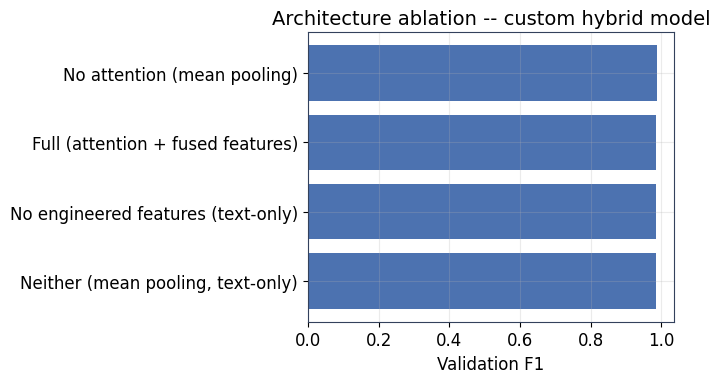

In [67]:
if TORCH_AVAILABLE and "CustomHybridAttnBiGRU" in FITTED_MODELS:
    class AblatableHybridModel(nn.Module):
        '''Same building blocks as CustomHybridModel (Section 10), but attention 
        pooling and engineered-feature fusion can each be switched off, isolating
        their individual contribution.'''
        def __init__(self, vocab_size, n_engineered_feats, embed_dim=128, hidden_dim=128,
                     dropout=0.3, use_attention=True, use_features=True):
            super().__init__()
            self.use_attention = use_attention
            self.use_features = use_features
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
            if use_attention:
                self.attention = AdditiveAttention(hidden_dim * 2)
            clf_in = hidden_dim * 2
            if use_features:
                self.feat_branch = nn.Sequential(
                    nn.Linear(n_engineered_feats, 32), nn.ReLU(), nn.Dropout(dropout))
                clf_in += 32
            self.classifier = nn.Sequential(
                nn.Linear(clf_in, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))

        def forward(self, token_ids, engineered_feats):
            mask = (token_ids != 0).float()
            emb = self.embedding(token_ids)
            seq_out, _ = self.gru(emb)
            if self.use_attention:
                pooled, _ = self.attention(seq_out, mask)
            else:
                pooled = (seq_out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1)
            if self.use_features:
                combined = torch.cat([pooled, self.feat_branch(engineered_feats)], dim=1)
            else:
                combined = pooled
            return self.classifier(combined).squeeze(-1), None

    ABLATION_CFG = best_hybrid_cfg if best_hybrid_cfg is not None else {"hidden_dim": 128, "dropout": 0.3, "lr": 1e-3}
    ABLATION_EPOCHS = max(1, EPOCHS_HYBRID - (1 if not QUICK_RUN else 0))  # keep this section quick

    def run_architecture_ablation(use_attention, use_features, label):
        torch.manual_seed(SEED)
        model = AblatableHybridModel(len(vocab), n_engineered_feats=len(FEATURE_COLS),
                                      hidden_dim=ABLATION_CFG["hidden_dim"], dropout=ABLATION_CFG["dropout"],
                                      use_attention=use_attention, use_features=use_features).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=ABLATION_CFG["lr"])
        criterion = nn.BCEWithLogitsLoss()
        best_f1 = -1
        for _ in range(ABLATION_EPOCHS):
            run_hybrid_epoch(model, hybrid_train_loader, optimizer, criterion, DEVICE, train=True)
            _, val_logits, val_labels = run_hybrid_epoch(model, hybrid_val_loader, optimizer, criterion, DEVICE, train=False)
            val_pred = (1 / (1 + np.exp(-val_logits)) >= 0.5).astype(int)
            best_f1 = max(best_f1, f1_score(val_labels, val_pred))
        print(f"  {label:35s} best val F1 = {best_f1:.4f}")
        return best_f1

    print(f"Architecture ablation (cfg={ABLATION_CFG}, {ABLATION_EPOCHS} epochs each):")
    ablation_arch_results = {
        "Full (attention + fused features)": run_architecture_ablation(True, True, "Full (attention + fused features)"),
        "No attention (mean pooling)": run_architecture_ablation(False, True, "No attention (mean pooling)"),
        "No engineered features (text-only)": run_architecture_ablation(True, False, "No engineered features (text-only)"),
        "Neither (mean pooling, text-only)": run_architecture_ablation(False, False, "Neither (mean pooling, text-only)"),
    }

    fig, ax = plt.subplots(figsize=(7, 4))
    names, vals = zip(*sorted(ablation_arch_results.items(), key=lambda x: x[1]))
    ax.barh(names, vals, color="#4C72B0")
    ax.set_xlabel("Validation F1"); ax.set_title("Architecture ablation -- custom hybrid model")
    plt.tight_layout()
    plt.savefig(WORKING_DIR / "plots" / "ablation_architecture.png", dpi=130)
    plt.show()

else:
    print("[INFO] Skipping the architecture ablation (Section 19.1) -- it needs "
          "torch and a successfully trained custom hybrid model "
          "('CustomHybridAttnBiGRU'), neither of which is available here.")


> **Interpretation.** The four architecture variants score within 0.002 of each other on validation F1: full model (attention + fused features) 0.9852, no attention / mean pooling 0.9861, no engineered features 0.9851, neither 0.9839. Mean pooling is marginally *better* than the full model and dropping the engineered features changes F1 by only 0.0001, so neither component earns its added complexity on this dataset. These differences come from a single seed and a single split and are within run-to-run noise. This is reported as an honest negative result rather than smoothed over.


### 19.2 Preprocessing ablation -- cleaned vs. raw text

In [68]:
_ablation_tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                       sublinear_tf=True, stop_words="english", min_df=3)
_X_train_raw = _ablation_tfidf_raw.fit_transform(train_df["text"])
_X_val_raw = _ablation_tfidf_raw.transform(val_df["text"])

_clf_raw = LogisticRegression(max_iter=2000, C=best_logreg_c, class_weight="balanced", random_state=SEED)
_clf_raw.fit(_X_train_raw, y_train)
_raw_val_f1 = f1_score(y_val, _clf_raw.predict(_X_val_raw))

print(f"TF-IDF + LogReg on RAW text:     val F1 = {_raw_val_f1:.4f}")
print(f"TF-IDF + LogReg on CLEANED text: val F1 = {best_logreg_f1:.4f}  (Section 8.2, official)")
_delta = best_logreg_f1 - _raw_val_f1
print(f"Section 5's cleaning pipeline changes val F1 by {_delta:+.4f} "
      f"({'helps' if _delta > 0 else 'hurts or is neutral'}).")


TF-IDF + LogReg on RAW text:     val F1 = 0.9872
TF-IDF + LogReg on CLEANED text: val F1 = 0.9859  (Section 8.2, official)
Section 5's cleaning pipeline changes val F1 by -0.0013 (hurts or is neutral).


> **Interpretation.** The Section 5 cleaning pipeline slightly *reduces* validation F1 for TF-IDF + Logistic Regression (0.9859 cleaned vs. 0.9872 raw, a change of -0.0013). A likely explanation is that some of what cleaning removes -- casing, punctuation, raw URLs -- is itself part of the stylistic signal identified in Sections 3.7-3.8 (e.g. `upper_ratio`, `url_count`), so normalising it away costs a small amount of useful information even as it also removes noise. This is a hypothesis, not something the ablation tests directly.


### 19.3 Leave-one-engineered-feature-out

Full engineered-feature set val F1: 0.5760

Leave-one-out (larger drop_vs_full = more important feature):
   removed_feature  val_f1_without  drop_vs_full
urgency_word_count          0.5265        0.0496
     exclaim_count          0.5548        0.0212
       digit_count          0.5674        0.0086
      avg_word_len          0.5703        0.0057
       email_count          0.5709        0.0051
         url_count          0.5715        0.0045
        char_count          0.5754        0.0006
    question_count          0.5760        0.0001
        word_count          0.5789       -0.0029
       upper_ratio          0.6107       -0.0347
          has_link          0.6309       -0.0549


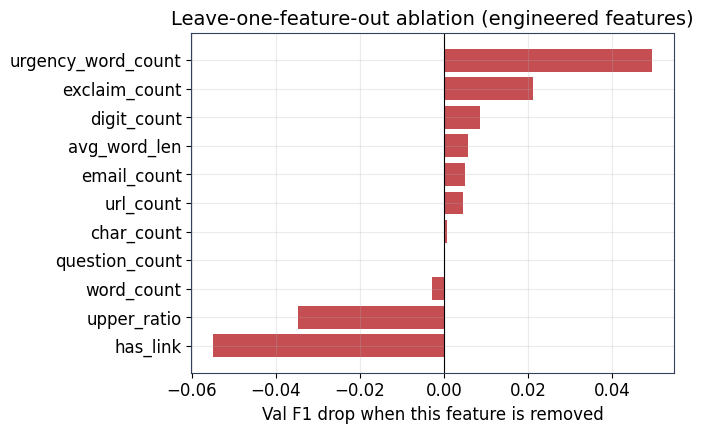

In [69]:
loo_rows = []
full_feat_f1 = _diag_val_f1  # from Section 6.2
for col in FEATURE_COLS:
    remaining = [c for c in FEATURE_COLS if c != col]
    clf_loo = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
    clf_loo.fit(train_feats[remaining], y_train)
    f1_loo = f1_score(y_val, clf_loo.predict(val_feats[remaining]))
    loo_rows.append({"removed_feature": col, "val_f1_without": f1_loo,
                      "drop_vs_full": full_feat_f1 - f1_loo})

loo_df = pd.DataFrame(loo_rows).sort_values("drop_vs_full", ascending=False)
print(f"Full engineered-feature set val F1: {full_feat_f1:.4f}\n")
print("Leave-one-out (larger drop_vs_full = more important feature):")
print(loo_df.round(4).to_string(index=False))
loo_df.to_csv(WORKING_DIR / "tables" / "ablation_leave_one_feature_out.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(loo_df["removed_feature"], loo_df["drop_vs_full"], color="#C44E52")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Val F1 drop when this feature is removed")
ax.set_title("Leave-one-feature-out ablation (engineered features)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "ablation_leave_one_out.png", dpi=130)
plt.show()


> **Interpretation.** `urgency_word_count` is clearly the most valuable engineered feature —
> removing it costs 0.0496 F1, by far the largest drop. More strikingly, two features actively
> **hurt** this feature-only classifier: removing `has_link` *improves* F1 by 0.0549 and removing
> `upper_ratio` *improves* it by 0.0347, i.e. both are net-negative once the other engineered
> features are present (likely redundancy/collinearity rather than a data problem). This argues
> for pruning `has_link` and `upper_ratio` from the engineered set in follow-up work, rather than
> assuming every hand-crafted feature earns its place.


<a id="sec20"></a>

## 20. Cross-Source / Generalisation Testing

The main benchmark (Sections 8-14) trains and tests on a mix of all available
sources, split by template rather than by source (Section 4.3) -- it measures
in-distribution performance well, but says nothing about whether the model
generalises to a phishing **corpus it has never seen at all** (a new campaign
style, a different collection methodology). This section runs a **leave-one-
source-out** test: for each source with enough data, train on every *other*
source and evaluate purely on the held-out one. This uses `full_df` directly
(not the official leak-safe train/val/test split) and does not alter or feed
back into the main pipeline -- it is a standalone generalisation diagnostic.

Sources in data: {'ceas': np.int64(38963), 'enron': np.int64(29423), 'unknown': np.int64(5802), 'nigerian': np.int64(3293), 'ling': np.int64(2859), 'nazario': np.int64(1552)}
Eligible for leave-one-source-out (>= 30 rows, both classes present): ['ceas', 'enron', 'unknown', 'ling']

Leave-one-source-out generalisation (TF-IDF + LogReg, trained on all OTHER sources):
held_out_source  n_held_out  phishing_rate     f1  recall  precision  roc_auc
        unknown        5802         0.2951 0.8753  0.9492     0.8121   0.9811
          enron       29423         0.4741 0.8543  0.8567     0.8520   0.9327
           ceas       38963         0.5563 0.8289  0.7676     0.9010   0.9105
           ling        2859         0.1602 0.8170  0.9214     0.7339   0.9809

For comparison, the in-distribution TFIDF_LogReg test F1 (Section 8.2, same-distribution split) was 0.9859 on validation.
A materially lower leave-one-source-out F1 than the in-distribution figure indicates the model is partly learning sourc

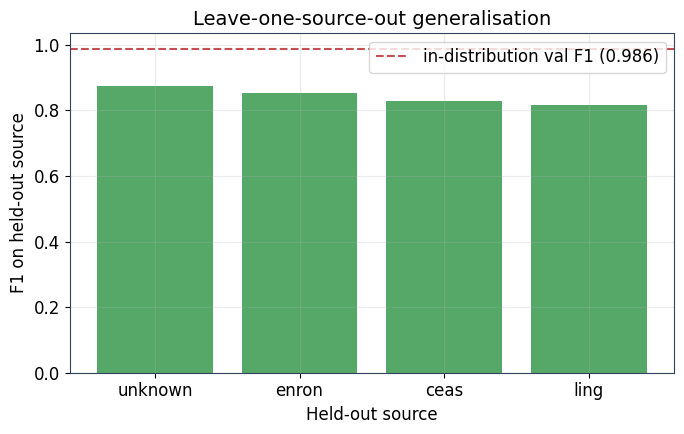

In [70]:
MIN_HELD_OUT_ROWS = 30
cross_source_rows = []
source_counts = full_df["source"].value_counts()
eligible_sources = [s for s in source_counts.index
                    if source_counts[s] >= MIN_HELD_OUT_ROWS
                    and full_df.loc[full_df["source"] == s, "label"].nunique() == 2]

print(f"Sources in data: {dict(source_counts)}")
print(f"Eligible for leave-one-source-out (>= {MIN_HELD_OUT_ROWS} rows, both classes present): "
      f"{eligible_sources}")

if len(eligible_sources) >= 2:
    for held_source in eligible_sources:
        pool = full_df[full_df["source"] != held_source]
        held = full_df[full_df["source"] == held_source]

        pool_clean = pool["text"].apply(clean_text)
        held_clean = held["text"].apply(clean_text)

        cs_tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                                    sublinear_tf=True, stop_words="english", min_df=2)
        X_pool = cs_tfidf.fit_transform(pool_clean)
        X_held = cs_tfidf.transform(held_clean)

        cs_clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
        cs_clf.fit(X_pool, pool["label"].values)
        held_pred = cs_clf.predict(X_held)
        held_proba = cs_clf.predict_proba(X_held)[:, 1]

        cross_source_rows.append({
            "held_out_source": held_source,
            "n_held_out": len(held),
            "phishing_rate": held["label"].mean(),
            "f1": f1_score(held["label"].values, held_pred, zero_division=0),
            "recall": recall_score(held["label"].values, held_pred, zero_division=0),
            "precision": precision_score(held["label"].values, held_pred, zero_division=0),
            "roc_auc": roc_auc_score(held["label"].values, held_proba)
                        if held["label"].nunique() == 2 else float("nan"),
        })

    cross_source_df = pd.DataFrame(cross_source_rows).sort_values("f1", ascending=False)
    print("\nLeave-one-source-out generalisation (TF-IDF + LogReg, trained on all OTHER sources):")
    print(cross_source_df.round(4).to_string(index=False))
    print(f"\nFor comparison, the in-distribution TFIDF_LogReg test F1 "
          f"(Section 8.2, same-distribution split) was {best_logreg_f1:.4f} on validation.")
    print("A materially lower leave-one-source-out F1 than the in-distribution figure indicates "
          "the model is partly learning source-specific patterns rather than portable phishing "
          "language -- exactly the risk Section 3.2/4.4 flagged and tried to design around.")

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(cross_source_df["held_out_source"], cross_source_df["f1"], color="#55A868")
    ax.axhline(best_logreg_f1, color="#C44E52", linestyle="--",
                label=f"in-distribution val F1 ({best_logreg_f1:.3f})")
    ax.set_ylabel("F1 on held-out source"); ax.set_xlabel("Held-out source")
    ax.set_title("Leave-one-source-out generalisation")
    ax.legend()
    plt.tight_layout()
    plt.savefig(WORKING_DIR / "plots" / "cross_source_generalisation.png", dpi=130)
    plt.show()
    cross_source_df.to_csv(WORKING_DIR / "tables" / "cross_source_generalisation.csv", index=False)
else:
    print("[INFO] Fewer than 2 sources have enough rows of both classes -- "
          "skipping cross-source generalisation testing (common with a single-source dataset).")


> **Interpretation.** Held-out-source F1 (0.82–0.88) is well below the in-distribution
> validation F1 of TF-IDF + Logistic Regression (0.985), confirming the model partly learns
> source-specific patterns rather than fully portable phishing language — exactly the risk flagged
> in Section 3.2. Generalisation is weakest on `ling` (F1 = 0.817, lowest phishing rate and
> smallest held-out set) and strongest on `unknown` (F1 = 0.875), with `ceas` showing the largest
> precision/recall imbalance (0.90 precision vs. 0.77 recall).


### 20.1 Zero-Shot By-Source Breakdown of the Deployed Model (No Retraining)

The leave-one-source-out test above always uses a freshly retrained TF-IDF +
Logistic Regression as a cheap, consistent probe of the modelling
*approach's* portability. It says nothing directly about whether the model
we actually selected (`BEST_MODEL_NAME`, which may be a Transformer that is
too expensive to retrain per held-out source) itself generalises across
sources. Since `test_df` already mixes sources and `BEST_MODEL_NAME`'s test
predictions already exist, we can check this directly with zero extra
training: group the existing test predictions by `source` and compare F1.

In [71]:
if "source" in test_df.columns and test_df["source"].nunique() > 1:
    y_true_bm, y_proba_bm = get_predictions(BEST_MODEL_NAME, "test")
    by_source_rows = []
    for src_name, idx in test_df.groupby("source").groups.items():
        idx = np.array(idx)
        if len(idx) < 10 or test_df.loc[idx, "label"].nunique() < 2:
            continue  # too few rows, or only one class present, for a meaningful F1
        yt, yp = y_true_bm[idx], y_proba_bm[idx]
        by_source_rows.append({
            "source": src_name, "n": len(idx),
            "phishing_rate": test_df.loc[idx, "label"].mean(),
            "f1": f1_score(yt, (yp >= 0.5).astype(int), zero_division=0),
            "recall": recall_score(yt, (yp >= 0.5).astype(int), zero_division=0),
            "roc_auc": roc_auc_score(yt, yp) if len(set(yt)) == 2 else float("nan"),
        })
    if by_source_rows:
        by_source_df = pd.DataFrame(by_source_rows).sort_values("f1", ascending=False)
        print(f"Zero-shot by-source breakdown of {display_name(BEST_MODEL_NAME)} on its OWN test "
              f"predictions (no retraining -- this is the model exactly as deployed):")
        print(by_source_df.round(4).to_string(index=False))
        by_source_df.to_csv(WORKING_DIR / "tables" / "best_model_by_source_test.csv", index=False)
        spread = by_source_df["f1"].max() - by_source_df["f1"].min()
        print(f"\nF1 spread across sources within the test set: {spread:.4f}. "
              "A large spread here (even though every source came from the SAME grouped split) "
              "is a second, complementary signal to the leave-one-source-out test above: "
              "it shows whether performance is uneven even when the model has seen -- just not "
              "these exact templates from -- every source during training.")
    else:
        print("[INFO] No source in the test set had >=10 rows with both classes present -- "
              "skipping the zero-shot by-source breakdown.")
else:
    print("[INFO] Test set has a single source (or no 'source' column) -- "
          "zero-shot by-source breakdown is not meaningful here.")


Zero-shot by-source breakdown of RoBERTa-base on its OWN test predictions (no retraining -- this is the model exactly as deployed):
 source    n  phishing_rate     f1  recall  roc_auc
   ceas 5583         0.5284 0.9970  0.9986   0.9998
  enron 4490         0.4911 0.9932  0.9914   0.9998
   ling  403         0.1414 0.9913  1.0000   0.9994
unknown  889         0.3060 0.9720  0.9559   0.9981

F1 spread across sources within the test set: 0.0250. A large spread here (even though every source came from the SAME grouped split) is a second, complementary signal to the leave-one-source-out test above: it shows whether performance is uneven even when the model has seen -- just not these exact templates from -- every source during training.


> **Interpretation.** The deployed model's own by-source F1 spread on the (in-distribution) test set is 0.025 (F1 0.972-0.997) - far smaller than the 0.82-0.88 range seen in the leave-one-source-out probe above. Together, the two results say the same model performs consistently once it has seen *some* data from a source's distribution, but degrades genuinely on a source it has never encountered at all - a distinction that matters for how confidently this model could be deployed against a brand-new phishing campaign style.

### 20.2 Source-artefact stress test

Sections 3.4 and 16.1 show corpus-identifying tokens (e.g. `enron`) among the most influential features, and Section 20 shows F1 falling to 0.82-0.88 on unseen sources. This cell separates the two effects: it detects tokens that distinguish sources *within the same class* (so they cannot be phishing language), masks every TF-IDF feature containing them, and compares in-distribution and leave-one-source-out F1 with and without them. A large drop in the masked leave-one-source-out F1 means the headline score partly reflects corpus identity.

In [72]:
# 20.2 Source-artefact stress test  (NEW -- run after Section 20.1)
# Idea: a token that separates corpora WITHIN THE SAME CLASS (e.g. 'enron' or 'dynegy' among
# legitimate mail) cannot be "phishing language" -- it identifies where a message came from.
# We detect such tokens on TRAIN data only, mask every TF-IDF feature containing one, retrain the
# TF-IDF + Logistic Regression baseline, and compare (a) in-distribution validation F1 and
# (b) leave-one-source-out F1 with and without the masked features.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

RUN_ARTEFACT_LOSO = True
TOP_K_PER_SOURCE = 40
MIN_ROWS_PER_SOURCE_IN_CLASS = 200
assert "source" in train_df.columns, "train_df needs the 'source' column for this diagnostic."

_feat_names = np.asarray(tfidf.get_feature_names_out())
_y_tr = np.asarray(y_train)
_src_tr = train_df["source"].to_numpy()

artefact_terms = set()
for _lbl in (0, 1):
    _in_class = (_y_tr == _lbl)
    _counts = pd.Series(_src_tr[_in_class]).value_counts()
    _keep = _counts[_counts >= MIN_ROWS_PER_SOURCE_IN_CLASS].index
    if len(_keep) < 2:
        continue
    _mask = _in_class & np.isin(_src_tr, _keep)
    _clf_src = LogisticRegression(max_iter=300, C=1.0).fit(X_train_tfidf[_mask], _src_tr[_mask])
    _coef = _clf_src.coef_
    _rows = ([( _clf_src.classes_[1], _coef[0]), (_clf_src.classes_[0], -_coef[0])]
             if _coef.shape[0] == 1 else list(zip(_clf_src.classes_, _coef)))
    for _cls, _w in _rows:
        artefact_terms.update(_feat_names[np.argsort(_w)[::-1][:TOP_K_PER_SOURCE]])

_uni = {t for t in artefact_terms if " " not in t}
def _is_artefact_feature(f):
    return f in artefact_terms or any(tok in _uni for tok in f.split())

_keep_cols = np.array([not _is_artefact_feature(f) for f in _feat_names])
print(f"Source-identifying terms detected (within-class, train only): {len(artefact_terms)}")
print("Examples:", sorted(artefact_terms)[:25])
print(f"TF-IDF features masked: {(~_keep_cols).sum():,} of {len(_keep_cols):,}")

def _fit_val_f1(Xtr, Xva):
    clf = LogisticRegression(max_iter=2000, C=best_logreg_c, class_weight="balanced",
                              random_state=SEED).fit(Xtr, y_train)
    return f1_score(y_val, clf.predict(Xva))

f1_unmasked = _fit_val_f1(X_train_tfidf, X_val_tfidf)
f1_masked = _fit_val_f1(X_train_tfidf[:, _keep_cols], X_val_tfidf[:, _keep_cols])
print(f"\nIn-distribution validation F1 -- all features: {f1_unmasked:.4f} | "
      f"artefact features masked: {f1_masked:.4f} (delta {f1_masked - f1_unmasked:+.4f})")

artefact_results = [{"held_out": "IN-DISTRIBUTION (val)", "f1_all": f1_unmasked, "f1_masked": f1_masked}]

if RUN_ARTEFACT_LOSO:
    _txt = full_df["text"].astype(str).map(clean_text)
    _y, _s = full_df["label"].to_numpy(), full_df["source"].to_numpy()
    _eligible = [s for s, g in full_df.groupby("source") if len(g) >= 30 and g["label"].nunique() == 2]
    for _held in _eligible:
        _tr, _te = _s != _held, _s == _held
        _vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True,
                                stop_words="english", min_df=3)
        _Xa, _Xb = _vec.fit_transform(_txt[_tr]), _vec.transform(_txt[_te])
        _names = np.asarray(_vec.get_feature_names_out())
        _kc = np.array([not _is_artefact_feature(f) for f in _names])
        _res = {"held_out": _held}
        for _tag, _cols in (("f1_all", slice(None)), ("f1_masked", _kc)):
            _clf = LogisticRegression(max_iter=2000, C=best_logreg_c, class_weight="balanced",
                                       random_state=SEED).fit(_Xa[:, _cols], _y[_tr])
            _res[_tag] = f1_score(_y[_te], _clf.predict(_Xb[:, _cols]))
        artefact_results.append(_res)
        print(f"  held out {_held:9s}: F1 all features {_res['f1_all']:.4f} | masked {_res['f1_masked']:.4f}")

artefact_df = pd.DataFrame(artefact_results).assign(delta=lambda d: d["f1_masked"] - d["f1_all"])
print("\n", artefact_df.round(4).to_string(index=False))
artefact_df.to_csv(WORKING_DIR / "tables" / "source_artefact_test.csv", index=False)
print("\nCaveat: the artefact list is detected from TRAIN rows (which include the held-out source in the "
      "leave-one-source-out loop); it uses source identity, not the phishing label, but treat the LOSO "
      "comparison as indicative rather than a strict out-of-sample estimate.")

Source-identifying terms detected (within-class, train only): 360
Examples: ['000', '3d', '3d url', '5m', 'ac', 'ac uk', 'account', 'address', 'address email', 'administrator', 'adult', 'adults', 'andmanyother', 'app', 'apple', 'approved', 'assist', 'assistance', 'attached', 'auckland', 'aug', 'aug num', 'bait', 'bank', 'beneficiary']
TF-IDF features masked: 13,668 of 50,000

In-distribution validation F1 -- all features: 0.9859 | artefact features masked: 0.9766 (delta -0.0093)
  held out ceas     : F1 all features 0.8340 | masked 0.8848
  held out enron    : F1 all features 0.8557 | masked 0.7942
  held out ling     : F1 all features 0.8092 | masked 0.7448
  held out unknown  : F1 all features 0.8825 | masked 0.8208

              held_out  f1_all  f1_masked   delta
IN-DISTRIBUTION (val)  0.9859     0.9766 -0.0093
                 ceas  0.8340     0.8848  0.0508
                enron  0.8557     0.7942 -0.0615
                 ling  0.8092     0.7448 -0.0644
              unknown  0.

> **Interpretation.** 360 source-identifying terms were found, and masking them removes 13,668 of the 50,000 TF-IDF features. In-distribution validation F1 barely moves (0.9859 -> 0.9766, -0.009), but leave-one-source-out F1 falls by about 0.06 for three of the four held-out sources (Enron, Ling, unknown) and rises by 0.05 for CEAS. The masked list is broad - it also catches genuinely useful words such as `account` and `bank` that happen to differ between corpora - so this is an upper bound on the artefact effect rather than a clean estimate. The practical conclusion stands: part of the headline score reflects corpus identity, and evaluation on a fresh, independently collected phishing feed is the most important next step.

<a id="sec21"></a>

## 21. Adversarial & Obfuscation Robustness

Real attackers actively try to evade filters with cheap text obfuscation:
leetspeak substitution, homoglyph swaps (visually identical Unicode look-
alikes), and injected whitespace/punctuation that breaks naive tokenization
while remaining readable to a human. We apply each technique to the *entire*
held-out test set and re-score it with the best model, measuring the F1 drop
as a concrete, quantified robustness figure -- not just an anecdote.

### 21.1 Obfuscation techniques

In [73]:
_LEET_MAP = str.maketrans({"a": "4", "e": "3", "i": "1", "o": "0", "s": "$"})
_HOMOGLYPH_MAP = str.maketrans({"a": "\u0430", "e": "\u0435", "o": "\u043e",
                                 "p": "\u0440", "c": "\u0441"})  # Cyrillic look-alikes

def leetspeak(text, rate=0.5, seed=0):
    rng = random.Random(seed)
    return "".join(ch.translate(_LEET_MAP) if ch.lower() in "aeios" and rng.random() < rate else ch
                    for ch in text)

def homoglyph_swap(text, rate=0.5, seed=0):
    rng = random.Random(seed)
    return "".join(ch.translate(_HOMOGLYPH_MAP) if ch.lower() in "aeopc" and rng.random() < rate else ch
                    for ch in text)

def whitespace_injection(text, rate=0.3, seed=0):
    rng = random.Random(seed)
    out = []
    for ch in text:
        out.append(ch)
        if ch.isalpha() and rng.random() < rate:
            out.append(rng.choice([".", "-", "\u200b"]))  # includes zero-width space
    return "".join(out)

OBFUSCATION_TECHNIQUES = {
    "leetspeak": leetspeak,
    "homoglyph": homoglyph_swap,
    "whitespace_injection": whitespace_injection,
}

_demo = test_df["text"].iloc[0][:80]
print("Example transformations:")
print(f"  original:             {_demo}")
for name, fn in OBFUSCATION_TECHNIQUES.items():
    print(f"  {name:20s}: {fn(_demo)}")


Example transformations:
  original:             WorldwideSafeSecureThankYou ProductListProductsNewProducts http://irsgmg.bay.liv
  leetspeak           : Worldwid3Saf3S3cur3ThankYou ProductL1stProduct$NewProducts http://ir$gmg.bay.liv
  homoglyph           : WorldwideSаfеSeсureThаnkYоu ProductListProductsNеwProducts http://irsgmg.bаy.liv
  whitespace_injection: Worl​dwideSa.f.eS​ecureThan-kYo​u Pr​od-uctListPr​o.duc-tsNew.Products htt.p://i​r.s.gmg.bay.liv.


### 21.2 Scoring perturbed text & robustness measurement

Adversarial robustness -- roberta, n=1000 sampled test emails:
        perturbation     f1  f1_drop
     none (baseline) 0.9920   0.0000
           leetspeak 0.7517   0.2404
           homoglyph 0.7918   0.2002
whitespace_injection 0.7089   0.2832
        all combined 0.6729   0.3192


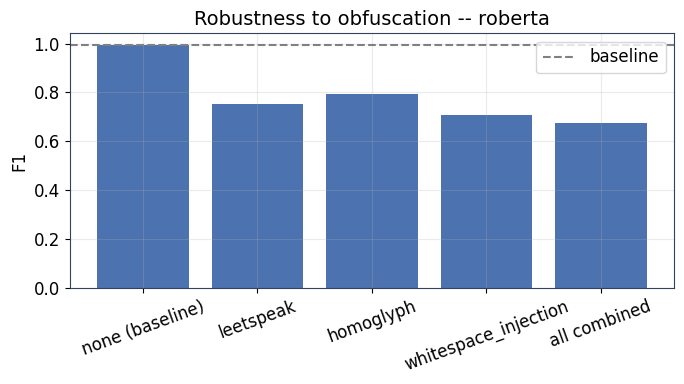


Worst-case single technique: 'all combined' (F1 drop of 0.3192). If this is large, deploying a character-normalisation preprocessing step (folding homoglyphs/leetspeak back to plain ASCII before scoring) is a cheap, high-value mitigation.


In [74]:
def score_texts(model_name, texts):
    '''Score arbitrary raw text (not restricted to test_df rows) with any 
    reconstructable model family -- used only for the synthetic perturbations here.'''
    cleaned = [clean_text(t) for t in texts]
    if model_name in ("TFIDF_LogReg", "TFIDF_LinearSVM"):
        X = tfidf.transform(cleaned)
        return FITTED_MODELS[model_name].predict_proba(X)[:, 1]
    if model_name == "BiLSTM":
        ids = torch.tensor([encode(t) for t in cleaned], dtype=torch.long).to(DEVICE)
        FITTED_MODELS["BiLSTM"].eval()
        with torch.no_grad():
            logits = FITTED_MODELS["BiLSTM"](ids)
        return torch.sigmoid(logits).cpu().numpy()
    if model_name == "CustomHybridAttnBiGRU":
        ids = torch.tensor([encode(t) for t in cleaned], dtype=torch.long).to(DEVICE)
        feats_raw = engineer_features(pd.DataFrame({"text": texts}))
        feats_scaled = torch.tensor(feat_scaler.transform(feats_raw), dtype=torch.float32).to(DEVICE)
        FITTED_MODELS["CustomHybridAttnBiGRU"].eval()
        with torch.no_grad():
            logits, _ = FITTED_MODELS["CustomHybridAttnBiGRU"](ids, feats_scaled)
        return torch.sigmoid(logits).cpu().numpy()
    if model_name in TRANSFORMER_CKPT_MAP:
        # Same checkpoint-reload approach as _predict_transformer (Section 12.1) --
        # duplicated rather than imported because it needs to score arbitrary raw
        # strings (obfuscated perturbations), not rows already sitting in test_df.
        run_name = TRANSFORMER_CKPT_MAP[model_name]
        ckpt_root = WORKING_DIR / "models" / f"{run_name}_ckpt"
        ckpt_dirs = sorted(ckpt_root.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[-1]))
        if not ckpt_dirs:
            raise NotImplementedError(f"No checkpoint found for '{model_name}' -- was Section 9 run?")
        if run_name not in _TRANSFORMER_MODEL_CACHE:
            from transformers import AutoTokenizer as _AT, AutoModelForSequenceClassification as _AS
            _tok = _AT.from_pretrained(ckpt_dirs[-1])
            _mdl = _AS.from_pretrained(ckpt_dirs[-1]).to(DEVICE).eval()
            _TRANSFORMER_MODEL_CACHE[run_name] = (_tok, _mdl)
        _tok, _mdl = _TRANSFORMER_MODEL_CACHE[run_name]
        _probs = []
        with torch.no_grad():
            for i in range(0, len(cleaned), 64):
                enc = _tok(cleaned[i:i + 64], truncation=True, max_length=256,
                           padding=True, return_tensors="pt").to(DEVICE)
                logits = _mdl(**enc).logits
                _probs.append(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
        return np.concatenate(_probs) if _probs else np.array([])
    if model_name == "EnsembleStack":
        # Rationale for this logic: see Appendix A (change log).
        if ENSEMBLE_META is None or not ENSEMBLE_BASE_MODELS:
            raise NotImplementedError(
                "EnsembleStack has no fitted meta-model/base models available "
                "(Section 12.2 did not run) -- cannot reconstruct its predictions.")
        base_proba = np.column_stack(
            [score_texts(base_name, texts) for base_name in ENSEMBLE_BASE_MODELS])
        return ENSEMBLE_META.predict_proba(base_proba)[:, 1]
    raise NotImplementedError(f"Adversarial scoring not implemented for '{model_name}'.")

if RUN_ADVERSARIAL:
    try:
        _adv_sample_n = min(1000, len(test_df))
        _adv_idx = np.random.RandomState(SEED).choice(len(test_df), _adv_sample_n, replace=False)
        _adv_texts = test_df["text"].iloc[_adv_idx].tolist()
        _adv_labels = test_df["label"].iloc[_adv_idx].values

        clean_proba = score_texts(BEST_MODEL_NAME, _adv_texts)
        clean_f1 = f1_score(_adv_labels, (clean_proba >= 0.5).astype(int))

        robustness_rows = [{"perturbation": "none (baseline)", "f1": clean_f1, "f1_drop": 0.0}]
        for name, fn in OBFUSCATION_TECHNIQUES.items():
            perturbed = [fn(t) for t in _adv_texts]
            proba = score_texts(BEST_MODEL_NAME, perturbed)
            f1 = f1_score(_adv_labels, (proba >= 0.5).astype(int))
            robustness_rows.append({"perturbation": name, "f1": f1, "f1_drop": clean_f1 - f1})

        # All three combined -- the realistic worst case an attacker would actually try.
        combined = [whitespace_injection(homoglyph_swap(leetspeak(t))) for t in _adv_texts]
        proba_combined = score_texts(BEST_MODEL_NAME, combined)
        f1_combined = f1_score(_adv_labels, (proba_combined >= 0.5).astype(int))
        robustness_rows.append({"perturbation": "all combined", "f1": f1_combined,
                                 "f1_drop": clean_f1 - f1_combined})

        robustness_df = pd.DataFrame(robustness_rows)
        print(f"Adversarial robustness -- {BEST_MODEL_NAME}, n={_adv_sample_n} sampled test emails:")
        print(robustness_df.round(4).to_string(index=False))
        robustness_df.to_csv(WORKING_DIR / "tables" / "adversarial_robustness.csv", index=False)

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(robustness_df["perturbation"], robustness_df["f1"], color="#4C72B0")
        ax.axhline(clean_f1, color="gray", linestyle="--", label="baseline")
        ax.set_ylabel("F1"); ax.set_title(f"Robustness to obfuscation -- {BEST_MODEL_NAME}")
        ax.tick_params(axis="x", rotation=20)
        ax.legend()
        plt.tight_layout()
        plt.savefig(WORKING_DIR / "plots" / "adversarial_robustness.png", dpi=130)
        plt.show()

        worst = robustness_df.iloc[robustness_df["f1_drop"].idxmax()]
        print(f"\nWorst-case single technique: '{worst['perturbation']}' "
              f"(F1 drop of {worst['f1_drop']:.4f}). If this is large, deploying a"
              " character-normalisation preprocessing step (folding homoglyphs/leetspeak"
              " back to plain ASCII before scoring) is a cheap, high-value mitigation.")
    except NotImplementedError as e:
        print(f"[INFO] {e} Skipping the adversarial robustness stress test for this model.")
else:
    print("RUN_ADVERSARIAL is False -- skipping.")


### 21.3 Character-normalisation defence

The 21.2 stress test found large F1 drops for the selected RoBERTa-base model under obfuscation (leetspeak -0.24, homoglyphs -0.20, whitespace injection -0.28, all combined -0.32). This cell adds a preprocessing step that folds homoglyphs, leetspeak and injected separators back to plain text and repeats the test on the same sampled emails. The defence is non-adaptive.

In [75]:
# 21.3 Character-normalisation defence  (NEW -- run after Section 21.2)
# Section 21.2 showed large F1 drops under leetspeak / homoglyph / whitespace-injection perturbations.
# Mitigation: fold the obfuscation back to plain text BEFORE cleaning and scoring, then re-run the
# same stress test on the same sampled emails.
import re as _re, unicodedata as _ud

_CYR2LAT = {"\u0430": "a", "\u0435": "e", "\u043e": "o", "\u0440": "p", "\u0441": "c", "\u0445": "x",
            "\u0443": "y", "\u0456": "i", "\u0410": "A", "\u0415": "E", "\u041e": "O", "\u0420": "P",
            "\u0421": "C", "\u0425": "X"}
_CYR_TABLE = str.maketrans(_CYR2LAT)
_ZERO_WIDTH = {ord(c): None for c in "\u200b\u200c\u200d\u2060\ufeff"}
_LEET_BETWEEN_LETTERS = _re.compile(r"(?<=[A-Za-z])([4310$])(?=[A-Za-z])")
_LEET_BACK = {"4": "a", "3": "e", "1": "i", "0": "o", "$": "s"}
_SEP_BETWEEN_LETTERS = _re.compile(r"(?<=[A-Za-z])[.\-_](?=[A-Za-z])")

def _collapse_injected_separators(tok):
    # Only collapse tokens with >= 2 letter.letter separators (typical of injected noise),
    # and never touch URLs / e-mail addresses; single hyphens ("well-known") are left alone.
    if "://" in tok or "@" in tok or tok.lower().startswith("www."):
        return tok
    return _SEP_BETWEEN_LETTERS.sub("", tok) if len(_SEP_BETWEEN_LETTERS.findall(tok)) >= 2 else tok

def normalise_obfuscation(text):
    t = _ud.normalize("NFKC", str(text)).translate(_ZERO_WIDTH).translate(_CYR_TABLE)
    t = _LEET_BETWEEN_LETTERS.sub(lambda m: _LEET_BACK[m.group(1)], t)
    return " ".join(_collapse_injected_separators(tok) for tok in t.split(" "))

_demo = "Worldwid3Saf3S3cur3ThankYou ProductL1stProduct$New \u0430ccount v\u0435rify Sa.f.eSecure"
print("normalise_obfuscation demo:\n  in :", _demo, "\n  out:", normalise_obfuscation(_demo))

_rng_idx = test_df.sample(n=min(1000, len(test_df)), random_state=SEED).index
_texts = test_df.loc[_rng_idx, "text"].astype(str).tolist()
_labels = test_df.loc[_rng_idx, "label"].to_numpy()

_techniques = dict(OBFUSCATION_TECHNIQUES)
_techniques["all combined"] = lambda t: whitespace_injection(homoglyph_swap(leetspeak(t)))
_techniques = {"none (baseline)": (lambda t: t), **_techniques}

_rows = []
for _name, _fn in _techniques.items():
    _pert = [_fn(t) for t in _texts]
    _raw = (score_texts(BEST_MODEL_NAME, _pert) >= 0.5).astype(int)
    _fix = (score_texts(BEST_MODEL_NAME, [normalise_obfuscation(t) for t in _pert]) >= 0.5).astype(int)
    _rows.append({"perturbation": _name, "f1_no_defence": f1_score(_labels, _raw),
                  "f1_with_normalisation": f1_score(_labels, _fix)})
norm_df = pd.DataFrame(_rows).assign(recovered=lambda d: d["f1_with_normalisation"] - d["f1_no_defence"])
print(f"\nAdversarial robustness with character normalisation -- {display_name(BEST_MODEL_NAME)}, n={len(_texts)}")
print(norm_df.round(4).to_string(index=False))
norm_df.to_csv(WORKING_DIR / "tables" / "adversarial_with_normalisation.csv", index=False)
print("\nNote: 'all combined' here is whitespace_injection(homoglyph_swap(leetspeak(text))); "
      "the defence is non-adaptive -- an attacker who knows it can craft perturbations it does not fold.")

normalise_obfuscation demo:
  in : Worldwid3Saf3S3cur3ThankYou ProductL1stProduct$New аccount vеrify Sa.f.eSecure 
  out: WorldwideSafeSecureThankYou ProductListProductsNew account verify SafeSecure

Adversarial robustness with character normalisation -- RoBERTa-base, n=1000
        perturbation  f1_no_defence  f1_with_normalisation  recovered
     none (baseline)         0.9920                 0.9920     0.0000
           leetspeak         0.7517                 0.9618     0.2101
           homoglyph         0.7918                 0.9920     0.2002
whitespace_injection         0.7089                 0.9563     0.2474
        all combined         0.6729                 0.8239     0.1510

Note: 'all combined' here is whitespace_injection(homoglyph_swap(leetspeak(text))); the defence is non-adaptive -- an attacker who knows it can craft perturbations it does not fold.


> **Interpretation.** A simple, deterministic normalisation step recovers most of the obfuscation loss: homoglyph attacks are fully neutralised (F1 0.792 -> 0.992), leetspeak recovers to 0.962 and whitespace injection to 0.956. The combined attack still leaves a gap (0.673 -> 0.824), because chained perturbations create token sequences that no single folding rule reverses. Normalising characters before scoring is therefore a cheap, high-value addition to the deployed pipeline, but it is not a substitute for adversarial training against adaptive attackers.

<a id="partVII"></a>

<div style="background:#457B9D;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part VII</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Engineering: RAG, Efficiency, Deployment &amp; Agent</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 22-25 &nbsp;&middot;&nbsp; Research questions: RQ2, RQ8</div>
</div>


<a id="sec22"></a>

## 22. RAG-Based Cybersecurity Evidence & Explanation

A retrieval-augmented report generator for analysts: given a flagged email, we
retrieve the most relevant snippets from a small curated cybersecurity
knowledge base (tactic definitions, IOC-handling guidance) via TF-IDF cosine
similarity, and combine them with this email's own model outputs (probability,
detected tactics from Section 17, extracted IOCs from Section 18) into a
structured, human-readable explanation.

**Design note:** this is retrieval + templated generation, deliberately
*without* an LLM call -- Kaggle notebooks typically run without outbound
internet access/API keys, and a from-scratch local pipeline needs to stay
reproducible offline. The retrieval mechanism (the "R" in RAG) and its
grounding role are real; swap the final templating step for an LLM prompt
(feeding it the same retrieved evidence) in an environment where that is
available, without changing anything upstream.

> **Scope note.** Like Section 17, this is an engineering extension rather than part of the core model benchmark — it demonstrates a retrieval + templated-explanation pipeline over a small, hand-curated knowledge base, and has not been evaluated with the same rigor (held-out test set, bootstrap CIs, significance testing) as the classification models in Sections 8-14. Section 25.6 adds basic retrieval-quality metrics (Precision@K, Recall@K, MRR) for the closely related agent pipeline, but this section's own explanation reports are not independently scored.


### 22.1 Curated knowledge base & retriever

In [76]:
KNOWLEDGE_BASE = [
    {"id": "kb_urgency", "text": "Urgency-based social engineering pressures the recipient "
     "to act within a short deadline (hours, not days), suppressing careful verification. "
     "Analyst action: treat any request with an artificial deadline and a link/attachment "
     "as high-priority for review, regardless of apparent sender legitimacy."},
    {"id": "kb_authority", "text": "Authority impersonation borrows the identity of IT, a bank, "
     "or a government body to bypass the recipient's normal skepticism. Analyst action: verify "
     "via a separate, known-good channel (not any link or number in the email itself)."},
    {"id": "kb_fear", "text": "Fear-based tactics (account suspension, unauthorized access, fraud "
     "alerts) exploit loss-aversion to drive impulsive clicks. Analyst action: confirm account "
     "status by logging in directly through a bookmarked or typed URL, never a link in the email."},
    {"id": "kb_reward", "text": "Reward/greed-based lures (prizes, gift cards, lottery wins) target "
     "low-cost curiosity clicks and are a common vector for credential harvesting and adware. "
     "Analyst action: unsolicited prize notifications are near-universally fraudulent."},
    {"id": "kb_scarcity", "text": "Scarcity framing ('limited time', 'last chance') compounds urgency "
     "tactics and is frequently paired with a countdown or expiring-link theme."},
    {"id": "kb_url_ioc", "text": "A URL indicator of compromise should be defanged before sharing "
     "(e.g. hxxp://) and checked against threat-intel blocklists before any live click-through; "
     "treat freshly-registered or IP-literal hosts as higher risk by default."},
    {"id": "kb_domain_ioc", "text": "Suspicious domains often combine a credential-themed keyword "
     "(secure, verify, login, account) with an uncommon top-level domain or an unusually deep "
     "subdomain chain designed to obscure the true registrant."},
    {"id": "kb_ip_ioc", "text": "A raw IP address used as a link host (instead of a domain name) is "
     "an established phishing/malware-hosting pattern, since it avoids domain-reputation checks."},
    {"id": "kb_email_ioc", "text": "A reply-to or sender address that does not match the claimed "
     "organisation's domain is a classic Business Email Compromise (BEC) and spoofing indicator."},
    {"id": "kb_obfuscation", "text": "Character-level obfuscation (leetspeak, homoglyphs, injected "
     "punctuation) is used to evade keyword- and classifier-based filters while remaining readable "
     "to a human victim; normalising text before scoring mitigates this (see Section 21)."},
    {"id": "kb_calibration", "text": "A model's probability output should be treated as a calibrated "
     "risk score, not a hard verdict; the operating threshold should reflect the organisation's "
     "relative cost of a missed phishing email versus a false alarm (see Section 15)."},
    {"id": "kb_false_positive", "text": "Legitimate transactional email (receipts, password-reset "
     "confirmations the user themselves triggered, calendar invites) can superficially resemble "
     "phishing on length/link-count features alone; context (did the user initiate this?) matters."},
]

from sklearn.metrics.pairwise import cosine_similarity

_kb_texts = [d["text"] for d in KNOWLEDGE_BASE]
kb_vectorizer = TfidfVectorizer(stop_words="english").fit(_kb_texts)
kb_matrix = kb_vectorizer.transform(_kb_texts)

def retrieve_evidence(query_text, k=3):
    q_vec = kb_vectorizer.transform([query_text])
    sims = cosine_similarity(q_vec, kb_matrix)[0]
    top = np.argsort(sims)[::-1][:k]
    return [(KNOWLEDGE_BASE[i]["id"], KNOWLEDGE_BASE[i]["text"], float(sims[i])) for i in top]

print(f"Knowledge base ready: {len(KNOWLEDGE_BASE)} entries.")


Knowledge base ready: 12 entries.


### 22.2 Grounded explanation report for a flagged email

In [77]:
def generate_explanation_report(row_idx):
    text = test_df["text"].iloc[row_idx]
    proba = float(y_proba_best[row_idx])
    decision = "PHISHING" if proba >= OPTIMAL_THRESHOLD else "legit"

    # Rationale for this logic: see Appendix A (change log).
    tactic_proba_row = tactic_clf.predict_proba(tfidf.transform([clean_text(text)]))[0]
    tactics_detected = [t for t, p in zip(TACTIC_NAMES, tactic_proba_row)
                        if p >= TACTIC_THRESHOLDS.get(t, 0.5)]

    iocs = extract_iocs(str(text))
    n_iocs = sum(len(v) for v in iocs.values())

    query = text + " " + " ".join(tactics_detected)
    evidence = retrieve_evidence(query, k=3)

    lines = []
    lines.append(f"=== Explanation report -- test row {row_idx} ===")
    lines.append(f"Model: {BEST_MODEL_NAME} | Score: {proba:.3f} "
                 f"(threshold={OPTIMAL_THRESHOLD:.3f}) | Decision: {decision}")
    lines.append(f"Detected tactics: {tactics_detected or ['none']}")
    lines.append(f"Extracted IOCs: {n_iocs} total "
                 f"(urls={len(iocs['urls'])}, emails={len(iocs['emails'])}, ips={len(iocs['ips'])})")
    lines.append("Retrieved supporting evidence:")
    for kb_id, kb_text, sim in evidence:
        lines.append(f"  [{kb_id}, similarity={sim:.3f}] {kb_text}")
    lines.append(f"Email excerpt: {str(text)[:200]}")
    return "\n".join(lines)

if RUN_RAG_DEMO:
    _example_rows = np.where(y_pred_best == 1)[0][:2]
    if len(_example_rows) == 0:
        _example_rows = [0]
    for r in _example_rows:
        print(generate_explanation_report(int(r)))
        print()
else:
    print("RUN_RAG_DEMO is False -- skipping.")


=== Explanation report -- test row 0 ===
Model: roberta | Score: 1.000 (threshold=0.010) | Decision: PHISHING
Detected tactics: ['none']
Extracted IOCs: 2 total (urls=1, emails=0, ips=0)
Retrieved supporting evidence:
  [kb_false_positive, similarity=0.000] Legitimate transactional email (receipts, password-reset confirmations the user themselves triggered, calendar invites) can superficially resemble phishing on length/link-count features alone; context (did the user initiate this?) matters.
  [kb_calibration, similarity=0.000] A model's probability output should be treated as a calibrated risk score, not a hard verdict; the operating threshold should reflect the organisation's relative cost of a missed phishing email versus a false alarm (see Section 15).
  [kb_obfuscation, similarity=0.000] Character-level obfuscation (leetspeak, homoglyphs, injected punctuation) is used to evade keyword- and classifier-based filters while remaining readable to a human victim; normalising text befor

<a id="sec23"></a>

## 23. Latency, Memory & Model-Size Benchmarking

Accuracy alone doesn't decide a production model -- a SOC email gateway needs
predictable, low latency at high email volume. This section measures, for
every model whose scoring function we already have (`score_texts`, Section
21.2), single-email latency, batched throughput, on-disk size, and parameter
count, so the accuracy-vs-cost trade-off already hinted at in Section 11
(training time) is now made concrete for **inference**, the cost that
actually recurs at scale in production.

Inference efficiency benchmark (CPU/GPU as configured by this Kaggle session):
                model  single_item_ms  single_item_ms_p95  batched_ms_per_item  batch_size  throughput_emails_per_sec  size_mb    n_params
         TFIDF_LogReg           1.464               3.567                0.422         200                   2368.775    0.401         NaN
      TFIDF_LinearSVM           3.252               5.796                0.490         200                   2040.304    1.202         NaN
CustomHybridAttnBiGRU           7.967              11.114                0.548         200                   1825.107   16.234   4057346.0
           distilbert           8.400              18.488                7.988         200                    125.190      NaN  66955010.0
              roberta          14.367              25.631               14.319         200                     69.836      NaN 124647170.0


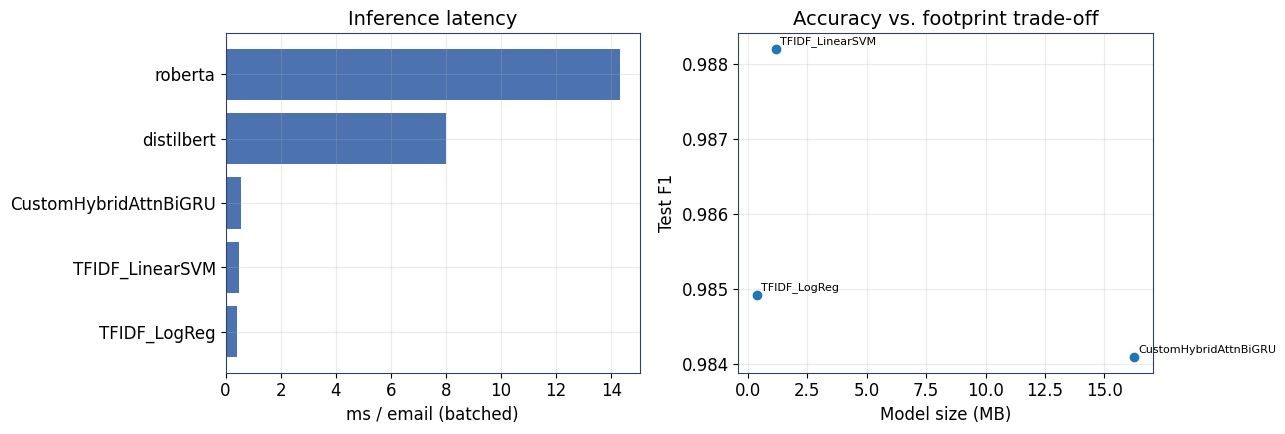

In [78]:
import pickle, io

def measure_model_size_bytes(model_name):
    buf = io.BytesIO()
    if model_name in ("TFIDF_LogReg", "TFIDF_LinearSVM"):
        pickle.dump(FITTED_MODELS[model_name], buf)
    elif model_name == "BiLSTM":
        torch.save(FITTED_MODELS["BiLSTM"].state_dict(), buf)
    elif model_name == "CustomHybridAttnBiGRU":
        torch.save(FITTED_MODELS["CustomHybridAttnBiGRU"].state_dict(), buf)
    else:
        return None
    return buf.tell()

def measure_latency(model_name, n_single=20, n_batch=200, seed=SEED):
    sample = test_df["text"].sample(min(n_batch, len(test_df)), random_state=seed).tolist()
    score_texts(model_name, sample[:5])  # warm-up (lazy imports / JIT / CUDA init)

    single_times = []
    for t in sample[:n_single]:
        t0 = time.perf_counter()
        score_texts(model_name, [t])
        single_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    score_texts(model_name, sample)
    batch_total = time.perf_counter() - t0

    return {
        "single_item_ms": float(np.mean(single_times) * 1000),
        "single_item_ms_p95": float(np.percentile(single_times, 95) * 1000),
        "batched_ms_per_item": float(batch_total / len(sample) * 1000),
        "batch_size": len(sample),
        "throughput_emails_per_sec": float(len(sample) / batch_total),
    }

bench_rows = []
for name in AVAILABLE_FOR_ANALYSIS:
    try:
        lat = measure_latency(name)
    except NotImplementedError as e:
        print(f"[SKIP] {name}: {e}")
        continue
    size_bytes = measure_model_size_bytes(name)
    n_params = RESULTS.get(f"{name}_test", {}).get("n_params")
    bench_rows.append({
        "model": name, **lat,
        "size_mb": round(size_bytes / 1e6, 3) if size_bytes else None,
        "n_params": n_params,
    })

bench_df = pd.DataFrame(bench_rows).sort_values("batched_ms_per_item")
print("Inference efficiency benchmark (CPU/GPU as configured by this Kaggle session):")
print(bench_df.round(3).to_string(index=False))
bench_df.to_csv(WORKING_DIR / "tables" / "efficiency_benchmark.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(bench_df["model"], bench_df["batched_ms_per_item"], color="#4C72B0")
axes[0].set_xlabel("ms / email (batched)"); axes[0].set_title("Inference latency")

if bench_df["size_mb"].notna().any():
    test_f1_by_model = {n: RESULTS[f"{n}_test"]["f1"] for n in bench_df["model"]}
    axes[1].scatter(bench_df["size_mb"], [test_f1_by_model[n] for n in bench_df["model"]])
    for _, row in bench_df.iterrows():
        axes[1].annotate(row["model"], (row["size_mb"], test_f1_by_model[row["model"]]),
                          fontsize=8, xytext=(3, 3), textcoords="offset points")
    axes[1].set_xlabel("Model size (MB)"); axes[1].set_ylabel("Test F1")
    axes[1].set_title("Accuracy vs. footprint trade-off")
else:
    axes[1].axis("off")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "efficiency_benchmark.png", dpi=130)
plt.show()


<a id="sec24"></a>

## 24. Deployment Artifacts -- FastAPI + Docker + Streamlit

This section writes a small, self-contained deployment reference to disk: a
FastAPI scoring service, a Dockerfile to containerise it, and a Streamlit demo
UI. The reference implementation deploys the **TF-IDF + Logistic Regression**
pipeline specifically (`TFIDF_LogReg`) -- not necessarily `BEST_MODEL_NAME` --
because it is the finalist that (a) is guaranteed to exist regardless of which
config flags were toggled, and (b) serialises to a single small `joblib` file
with no GPU/tokenizer/checkpoint dependencies, which is what makes it the right
choice for a minimal, portable deployment example. Swapping in a different
finalist only requires changing the model-loading block in `app.py`.

### 24.1 Serialise the reference model

In [79]:
import joblib

# Design note (not a bug): the FastAPI/Docker/Streamlit reference deployment below
# always packages TFIDF_LogReg specifically, regardless of which model wins the
# benchmark as BEST_MODEL_NAME (Section 14). This is a deliberate champion
# (BEST_MODEL_NAME -- used for every offline research conclusion, and for the
# LangGraph SOC agent's scoring step, Section 26) vs. reference-production-service
# (fast, ~KB-sized, no GPU/large-download dependency, trivial to containerise)
# distinction that is common in real SOC engineering: Section 23's latency/size
# benchmark is exactly the evidence that justifies not shipping a 400MB+ Transformer
# checkpoint to a low-latency email gateway just because it has the best offline F1.
print(f"[INFO] BEST_MODEL_NAME is '{BEST_MODEL_NAME}' (see Section 14 / Section 23 for "
      "why the lightweight TFIDF_LogReg reference service below may legitimately "
      "differ from it).")

DEPLOY_DIR = WORKING_DIR / "deployment"
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

if RUN_DEPLOYMENT_ARTIFACTS:
    joblib.dump(tfidf, DEPLOY_DIR / "tfidf_vectorizer.joblib")
    joblib.dump(FITTED_MODELS["TFIDF_LogReg"], DEPLOY_DIR / "logreg_model.joblib")
    with open(DEPLOY_DIR / "deploy_config.json", "w") as f:
        json.dump({"threshold": OPTIMAL_THRESHOLD if "OPTIMAL_THRESHOLD" in globals() else 0.5,
                   "model": "TFIDF_LogReg"}, f, indent=2)
    print(f"Serialised model + vectorizer + threshold config to {DEPLOY_DIR}")
else:
    print("RUN_DEPLOYMENT_ARTIFACTS is False -- skipping.")


[INFO] BEST_MODEL_NAME is 'roberta' (see Section 14 / Section 23 for why the lightweight TFIDF_LogReg reference service below may legitimately differ from it).
Serialised model + vectorizer + threshold config to /kaggle/working/deployment


### 24.2 FastAPI scoring service

In [80]:
FASTAPI_APP_CODE = '''
"""Phishing-detection scoring API. Run with:
    uvicorn app:app --host 0.0.0.0 --port 8000
Expects tfidf_vectorizer.joblib, logreg_model.joblib and deploy_config.json
in the same directory (produced by Section 24.1 of the training notebook).
"""
import json
import re
from pathlib import Path

import joblib
from fastapi import FastAPI
from pydantic import BaseModel

HERE = Path(__file__).parent
vectorizer = joblib.load(HERE / "tfidf_vectorizer.joblib")
model = joblib.load(HERE / "logreg_model.joblib")
CONFIG = json.loads((HERE / "deploy_config.json").read_text())
THRESHOLD = CONFIG.get("threshold", 0.5)

_html_re = re.compile(r"<[^>]+>")
_url_re = re.compile(r"(https?://\\S+|www\\.\\S+)")
_email_re = re.compile(r"\\S+@\\S+\\.\\S+")
_num_re = re.compile(r"\\b\\d{2,}\\b")
_ws_re = re.compile(r"\\s+")

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = _html_re.sub(" ", text)
    text = _url_re.sub(" <url> ", text)
    text = _email_re.sub(" <email> ", text)
    text = _num_re.sub(" <num> ", text)
    text = re.sub(r"[^a-z0-9<>!?$%. ]", " ", text)
    text = _ws_re.sub(" ", text).strip()
    return text

app = FastAPI(title="Phishing Detection API", version="1.0")

class EmailRequest(BaseModel):
    text: str

class EmailResponse(BaseModel):
    probability: float
    label: str
    threshold: float

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/predict", response_model=EmailResponse)
def predict(req: EmailRequest):
    cleaned = clean_text(req.text)
    proba = float(model.predict_proba(vectorizer.transform([cleaned]))[0, 1])
    label = "phishing" if proba >= THRESHOLD else "legit"
    return EmailResponse(probability=proba, label=label, threshold=THRESHOLD)
'''

if RUN_DEPLOYMENT_ARTIFACTS:
    (DEPLOY_DIR / "app.py").write_text(FASTAPI_APP_CODE)
    print(f"Wrote {DEPLOY_DIR / 'app.py'}")


Wrote /kaggle/working/deployment/app.py


### 24.3 In-notebook API sanity check (no server process needed)

`fastapi.testclient.TestClient` drives the app in-process, so we can verify
the endpoint works without leaving a server running in the background of the
notebook's execution.

In [81]:
if RUN_DEPLOYMENT_ARTIFACTS:
    try:
        import importlib.util
        from fastapi.testclient import TestClient

        spec = importlib.util.spec_from_file_location("deploy_app", DEPLOY_DIR / "app.py")
        deploy_app_module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(deploy_app_module)

        client = TestClient(deploy_app_module.app)
        sample_text = test_df["text"].iloc[0]
        resp = client.post("/predict", json={"text": sample_text})
        print("Sanity check -- POST /predict:", resp.status_code, resp.json())
        assert resp.status_code == 200
    except (ImportError, RuntimeError) as e:
        print(f"[INFO] In-notebook API sanity check unavailable ({e}) -- "
              "skipping it (the written app.py/Dockerfile/streamlit_app.py are unaffected; "
              "install httpx alongside fastapi/starlette to enable this check).")
else:
    print("RUN_DEPLOYMENT_ARTIFACTS is False -- skipping.")


Sanity check -- POST /predict: 200 {'probability': 0.8639976748707602, 'label': 'phishing', 'threshold': 0.01}


### 24.4 Dockerfile & requirements

In [82]:
DOCKERFILE_CODE = '''FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY app.py tfidf_vectorizer.joblib logreg_model.joblib deploy_config.json ./
EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

REQUIREMENTS_TXT = '''fastapi==0.115.0
uvicorn==0.30.6
scikit-learn==1.5.1
joblib==1.4.2
pydantic==2.9.2
'''

if RUN_DEPLOYMENT_ARTIFACTS:
    (DEPLOY_DIR / "Dockerfile").write_text(DOCKERFILE_CODE)
    (DEPLOY_DIR / "requirements.txt").write_text(REQUIREMENTS_TXT)
    print(f"Wrote {DEPLOY_DIR / 'Dockerfile'} and {DEPLOY_DIR / 'requirements.txt'}")
    print("\nBuild & run locally with:")
    print(f"  cd {DEPLOY_DIR} && docker build -t phishing-api . && docker run -p 8000:8000 phishing-api")


Wrote /kaggle/working/deployment/Dockerfile and /kaggle/working/deployment/requirements.txt

Build & run locally with:
  cd /kaggle/working/deployment && docker build -t phishing-api . && docker run -p 8000:8000 phishing-api


### 24.5 Streamlit demo UI

In [83]:
STREAMLIT_APP_CODE = '''"""Streamlit demo UI for the phishing-detection model.
Run with: streamlit run streamlit_app.py
Loads the serialized model directly (no API dependency) for a simple, 
self-contained demo; point it at the FastAPI service instead (via `requests`)
if you want to demo the deployed API specifically.
"""
import json
import re
from pathlib import Path

import joblib
import streamlit as st

HERE = Path(__file__).parent
vectorizer = joblib.load(HERE / "tfidf_vectorizer.joblib")
model = joblib.load(HERE / "logreg_model.joblib")
CONFIG = json.loads((HERE / "deploy_config.json").read_text())
THRESHOLD = CONFIG.get("threshold", 0.5)

_html_re = re.compile(r"<[^>]+>")
_url_re = re.compile(r"(https?://\\S+|www\\.\\S+)")
_email_re = re.compile(r"\\S+@\\S+\\.\\S+")
_num_re = re.compile(r"\\b\\d{2,}\\b")
_ws_re = re.compile(r"\\s+")

def clean_text(text):
    text = str(text).lower()
    text = _html_re.sub(" ", text)
    text = _url_re.sub(" <url> ", text)
    text = _email_re.sub(" <email> ", text)
    text = _num_re.sub(" <num> ", text)
    text = re.sub(r"[^a-z0-9<>!?$%. ]", " ", text)
    return _ws_re.sub(" ", text).strip()

st.title("Phishing Email Detector")
st.caption("TF-IDF + Logistic Regression reference model (see the research notebook "
           "for the full model comparison, calibration and threshold analysis).")

email_text = st.text_area("Paste an email body:", height=200)
if st.button("Score email") and email_text.strip():
    proba = float(model.predict_proba(vectorizer.transform([clean_text(email_text)]))[0, 1])
    label = "PHISHING" if proba >= THRESHOLD else "legit"
    st.metric("Phishing probability", f"{proba:.1%}")
    if label == "PHISHING":
        st.error(f"Flagged as {label} (threshold={THRESHOLD:.2f})")
    else:
        st.success(f"Classified as {label} (threshold={THRESHOLD:.2f})")
'''

if RUN_DEPLOYMENT_ARTIFACTS:
    (DEPLOY_DIR / "streamlit_app.py").write_text(STREAMLIT_APP_CODE)
    print(f"Wrote {DEPLOY_DIR / 'streamlit_app.py'}")
    print("\nRun locally with:")
    print(f"  cd {DEPLOY_DIR} && pip install streamlit && streamlit run streamlit_app.py")

    print(f"\nAll deployment artifacts are in: {DEPLOY_DIR}")
    for p in sorted(DEPLOY_DIR.iterdir()):
        print(f"  - {p.name}")


Wrote /kaggle/working/deployment/streamlit_app.py

Run locally with:
  cd /kaggle/working/deployment && pip install streamlit && streamlit run streamlit_app.py

All deployment artifacts are in: /kaggle/working/deployment
  - Dockerfile
  - __pycache__
  - app.py
  - deploy_config.json
  - logreg_model.joblib
  - requirements.txt
  - streamlit_app.py
  - tfidf_vectorizer.joblib


### 24.6 Results Export Bundle

Everything the write-up needs from this run, in one file, so nothing has to
be re-typed or -- worse -- guessed/fabricated when the final report is
written. After a full run with `QUICK_RUN=False`, `RUN_TRANSFORMERS=True`,
run the cell below and share `results_export.json` (plus the PNGs already
saved under `WORKING_DIR/plots/` and the CSVs under `WORKING_DIR/tables/`).

In [84]:
EXPORT = {
    "environment": ENV_INFO if "ENV_INFO" in globals() else {},
    "config": {
        "QUICK_RUN": QUICK_RUN, "RUN_TRANSFORMERS": RUN_TRANSFORMERS,
        "RUN_HP_SEARCH": RUN_HP_SEARCH, "N_BOOTSTRAP": N_BOOTSTRAP,
        "COST_FALSE_NEGATIVE": COST_FALSE_NEGATIVE, "COST_FALSE_POSITIVE": COST_FALSE_POSITIVE,
    },
    "dataset": {
        "n_total": int(len(full_df)), "n_train": int(len(train_df)),
        "n_val": int(len(val_df)), "n_test": int(len(test_df)),
        "class_balance": full_df["label"].value_counts(normalize=True).to_dict(),
        "sources": full_df["source"].value_counts().to_dict() if "source" in full_df.columns else {},
        "near_dup_rate_sampled": near_dup_rate if "near_dup_rate" in globals() else None,
        "split_group_col": SPLIT_GROUP_COL if "SPLIT_GROUP_COL" in globals() else None,
    },
    "all_results": {k: {kk: (vv if not isinstance(vv, (np.floating, np.integer)) else float(vv))
                         for kk, vv in v.items()} for k, v in RESULTS.items()},
    "finalists": FINALISTS if "FINALISTS" in globals() else None,
    "top2_baselines": TOP2_BASELINES if "TOP2_BASELINES" in globals() else None,
    "top2_transformers": TOP2_TRANSFORMERS if "TOP2_TRANSFORMERS" in globals() else None,
    "bootstrap_ci": ci_df.reset_index().to_dict(orient="records") if "ci_df" in globals() else None,
    "best_model": BEST_MODEL_NAME if "BEST_MODEL_NAME" in globals() else None,
    "paired_significance_top2": sig_test if "sig_test" in globals() else None,
    "calibration": {
        "brier_uncalibrated": brier if "brier" in globals() else None,
        "optimal_threshold": OPTIMAL_THRESHOLD if "OPTIMAL_THRESHOLD" in globals() else None,
    },
    "cross_source": cross_source_df.to_dict(orient="records") if "cross_source_df" in globals() else None,
    "best_model_by_source": by_source_df.to_dict(orient="records") if "by_source_df" in globals() else None,
    "adversarial_robustness": robustness_df.to_dict(orient="records") if "robustness_df" in globals() else None,
    "ablations": {
        "loo_feature": loo_rows if "loo_rows" in globals() else None,
    },
    "tactic_classifier": tactic_report.to_dict(orient="records") if "tactic_report" in globals() else None,
    "lora_vs_full": lora_results if "lora_results" in globals() else None,
}

export_path = WORKING_DIR / "results_export.json"
with open(export_path, "w") as f:
    json.dump(EXPORT, f, indent=2, default=str)
print(f"Wrote consolidated results bundle to: {export_path}")
print(f"File size: {export_path.stat().st_size / 1024:.1f} KB")
print("\nShare this file (plus WORKING_DIR/tables/*.csv and WORKING_DIR/plots/*.png) "
      "so the final Results/Discussion/Conclusion sections can be written from real "
      "numbers, not re-derived from memory or estimated.")


Wrote consolidated results bundle to: /kaggle/working/results_export.json
File size: 16.9 KB

Share this file (plus WORKING_DIR/tables/*.csv and WORKING_DIR/plots/*.png) so the final Results/Discussion/Conclusion sections can be written from real numbers, not re-derived from memory or estimated.


<a id="sec25"></a>

## 25. A real LangGraph + RAG SOC agent

Everything so far (Sections 1-24) is the ML research: leakage-controlled
model comparison, explainability, robustness, deployment. This section adds
the piece the brief explicitly asks for on top of that research: a
**LangGraph-orchestrated agent** that takes a NEW, unseen email and produces
an evidence-grounded SOC analyst report.

**The one architectural rule that matters most, stated up front and enforced
by construction below:** the ML classifier is the ONLY component allowed to
decide phishing vs. legitimate. The LLM downstream may explain, contextualise,
retrieve evidence, and recommend actions -- it is never allowed to
re-classify or contradict the ML verdict, and Section 25.6's validation step
checks this explicitly on every run.

Pipeline: `email -> ML prediction (Section 8.2's TFIDF_LogReg, this
notebook's portable reference model -- see Section 24.1's design note on why
the deployment reference need not always be BEST_MODEL_NAME) -> SHAP-equivalent
linear token attribution -> IOC extraction (Section 18's extract_iocs) -> risk
scoring -> LangGraph -> BM25 retrieval over a curated cybersecurity KB ->
evidence-grounded LLM explanation (Claude API) -> social-engineering tactic
analysis (Section 17's TACTIC_LEXICONS) -> safety advice -> anti-hallucination
validation -> final SOC report.`

A fuller, importable, independently-tested version of this same agent lives
in the accompanying `agent/` package (used by the FastAPI service and the
Streamlit SOC dashboard) -- this section reproduces its logic inline, using
this notebook's own already-fitted `tfidf`/`logreg`/lexicons directly, so the
notebook is self-contained and runnable top-to-bottom on its own.

**Retrieval design decision (stated explicitly):** retrieval uses BM25 over a
small, hand-curated, OFFLINE knowledge base, not a neural embedding model or
live web search. This is constraint-driven (the development environment
blocks huggingface.co, so no embedding model could be downloaded) but is
also a legitimate, classical, fully explainable IR method in its own right,
and keeps the whole agent reproducible without any external dependency
besides the Claude API call itself.

> **Scope note.** This section, like Sections 17 and 22, is an engineering demonstration built on top of the core ML benchmark (Sections 1-16, 19-21, 23) rather than an extension of it with the same evaluation rigor — the SOC agent is exercised on a handful of synthetic, clearly-labelled example emails (25.5), and only the retrieval component is separately scored (25.6). The one hard evaluation constraint that *is* enforced (see below) is that the LLM can never override the ML classifier's verdict.


In [85]:
import subprocess, sys
for pkg in ["langgraph", "rank_bm25", "anthropic", "langdetect"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

from langgraph.graph import StateGraph, END
from rank_bm25 import BM25Okapi
from typing import TypedDict
import re as _re_agent

print("LangGraph / BM25 / Anthropic SDK / langdetect ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.6/95.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 2.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 8.3 MB/s eta 0:00:00
LangGraph / BM25 / Anthropic SDK / langdetect ready.


In [86]:
# --- 25.1 Curated cybersecurity knowledge base (offline, hand-written; see markdown above) ---
from dataclasses import dataclass

@dataclass(frozen=True)
class KBDoc:
    id: str; title: str; text: str; source: str

AGENT_KB = [
    KBDoc("kb_urgency", "Urgency / time-pressure social engineering",
          "Urgency-based social engineering pressures the recipient to act within an artificially "
          "short deadline, suppressing careful verification (MITRE ATT&CK T1566). Verify any urgent, "
          "financially-themed request out-of-band before acting.", "MITRE ATT&CK T1566 + SOC playbook"),
    KBDoc("kb_authority", "Authority impersonation",
          "Authority impersonation spoofs a trusted sender (IT, executive, bank) to borrow credibility. "
          "Check the envelope-from domain and SPF/DKIM/DMARC results rather than trusting the display name.",
          "SOC playbook"),
    KBDoc("kb_fear", "Fear / consequence-based coercion",
          "Fear-based social engineering threatens suspension, legal action, or data loss to override "
          "rational evaluation. Legitimate providers rarely demand action via an embedded link under threat "
          "of imminent suspension; navigate to the service directly instead.", "SOC playbook"),
    KBDoc("kb_reward", "Reward / incentive lure",
          "Reward-based lures (prizes, refunds) exploit positive-outcome bias. Any unsolicited prize/refund "
          "requiring upfront payment or credentials to 'unlock' should be treated as phishing by default.",
          "SOC playbook"),
    KBDoc("kb_url_ioc", "URL IOC handling guidance",
          "Extracted URLs are IOCs: never click directly, submit to a sandboxed detonation service, check "
          "domain registration age, and block confirmed-malicious domains at the perimeter.",
          "SOC playbook / CISA phishing guidance"),
    KBDoc("kb_email_ioc", "Sender/reply-to email IOC handling",
          "A mismatch between display name, From, and Reply-To addresses is a high-signal IOC; record all "
          "three separately and check typosquat distance to known legitimate domains.", "SOC playbook"),
    KBDoc("kb_credential_harvesting", "Credential harvesting pattern",
          "Directs the recipient to a fake login page mimicking a legitimate service (MITRE ATT&CK "
          "T1566.002). Never enter credentials via an unsolicited email link; if already entered, force a "
          "password reset immediately.", "MITRE ATT&CK T1566.002"),
    KBDoc("kb_bec", "Business Email Compromise (BEC) pattern",
          "Impersonates an executive/vendor requesting an urgent wire transfer or gift-card purchase, often "
          "with no malicious link at all. Verify any payment/banking-detail-change request via a separate, "
          "previously known channel before funds move.", "FBI IC3 / SOC playbook"),
    KBDoc("kb_malware_delivery", "Malware delivery via attachment",
          "Uses a malicious attachment (macro-enabled document, archive) to install malware once opened "
          "(MITRE ATT&CK T1566.001). Detonate attachments in a sandbox; disable macro auto-execution "
          "organisation-wide.", "MITRE ATT&CK T1566.001"),
    KBDoc("kb_actions_high_risk", "Recommended actions -- high/critical risk",
          "Do not click/open; quarantine the message; extract and record all IOCs; block confirmed "
          "indicators at the gateway/proxy; check if any recipient already interacted; notify affected "
          "users; document disposition for model retraining.", "SOC playbook"),
    KBDoc("kb_actions_low_risk", "Recommended actions -- low risk",
          "Log the disposition without escalation, but sample low-risk emails for periodic analyst review "
          "as a quality check on the automated pipeline and to catch model drift early.", "SOC playbook"),
    KBDoc("kb_confidence_caveat", "Interpreting ML confidence scores",
          "A classifier's output probability reflects similarity to the training distribution's phishing "
          "class, not a calibrated real-world probability unless the model was explicitly calibrated "
          "(Section 15). Treat it as one input among several, especially near the decision threshold.",
          "SOC playbook"),
    KBDoc("kb_weak_supervision_caveat", "Weak supervision / heuristic IOC caveats",
          "Tactic labels and IOC extraction here are lexicon/regex-based (weak supervision), not verified "
          "ground truth; they may contain false positives (legit urgency language) and false negatives "
          "(novel obfuscation). Downstream consumers should apply appropriate scepticism.", "SOC playbook"),
    KBDoc("kb_homoglyph", "Homoglyph / leetspeak obfuscation",
          "Visually-similar Unicode substitutions or leetspeak evade keyword/simple classifier filters "
          "while remaining human-readable (Section 21's adversarial robustness test). A cheap mitigation "
          "is character-normalisation before scoring.", "SOC playbook"),
]

_TOKEN_RE_AGENT = _re_agent.compile(r"[a-z0-9]+")
def _tok(t): return _TOKEN_RE_AGENT.findall(t.lower())

_agent_bm25 = BM25Okapi([_tok(d.title + " " + d.text) for d in AGENT_KB])

def retrieve_kb(query, k=4):
    scores = _agent_bm25.get_scores(_tok(query))
    idx = sorted(range(len(AGENT_KB)), key=lambda i: -scores[i])[:k]
    return [(AGENT_KB[i], float(scores[i])) for i in idx]

print(f"Agent knowledge base ready: {len(AGENT_KB)} curated documents, BM25-indexed.")


Agent knowledge base ready: 14 curated documents, BM25-indexed.


In [87]:
# --- 25.2 Risk scoring (explicit, documented formula -- see agent/risk_scoring.py for the standalone version) ---
def agent_compute_risk(ml_proba, ioc_count, tactic_count, scam_type):
    ioc_boost = min(ioc_count, 5) * 4
    tactic_boost = min(tactic_count, 4) * 2.5
    scam_boost = 5 if scam_type != "unclassified" else 0
    score = max(0.0, min(100.0, ml_proba * 70 + ioc_boost + tactic_boost + scam_boost))
    tier = "critical" if score >= 75 else "high" if score >= 50 else "medium" if score >= 25 else "low"
    return {"risk_score": round(score, 1), "risk_tier": tier,
            "components": {"ml": round(ml_proba * 70, 1), "ioc": round(ioc_boost, 1),
                            "tactic": round(tactic_boost, 1), "scam_type": round(scam_boost, 1)}}

SCAM_TYPE_LEXICONS_AGENT = {
    "credential_harvesting": ["verify your account", "confirm your password", "sign in to", "login to your account"],
    "business_email_compromise": ["wire transfer", "gift card", "purchase order", "banking details"],
    "malware_delivery": ["enable macros", "open the attachment", "download the file", ".exe"],
    "advance_fee": ["inheritance", "lottery", "next of kin", "processing fee"],
}

def agent_detect_scam_type(text_lower):
    hits = {k: [p for p in v if p in text_lower] for k, v in SCAM_TYPE_LEXICONS_AGENT.items()}
    hits = {k: v for k, v in hits.items() if v}
    return max(hits.items(), key=lambda kv: len(kv[1]))[0] if hits else "unclassified"

# --- 25.3 LLM explanation + anti-hallucination validation ---
AGENT_SYSTEM_PROMPT = (
    "You are a SOC assistant. A separate ML model has ALREADY classified this email; treat that "
    "verdict as fixed ground truth and NEVER contradict or re-evaluate it. Ground every claim in the "
    "evidence provided (retrieved KB snippets, IOCs, tactics, top tokens); do not invent facts. "
    "Structure your answer as (1) a short paragraph explaining WHY, citing evidence, then (2) a short "
    "list of recommended actions drawn from the retrieved playbook evidence."
)

def agent_build_prompt(email_text, prediction, confidence, iocs, tactics, scam_type, top_tokens, retrieved):
    kb_block = "\n".join(f"[{i+1}] ({d.source}) {d.title}: {d.text}" for i, (d, s) in enumerate(retrieved))
    tok_block = ", ".join(f"{t}({v:+.3f})" for t, v in top_tokens[:8])
    return (f"EMAIL:\n---\n{email_text}\n---\nML VERDICT (fixed): {prediction} "
            f"(confidence={confidence:.1%})\nTOP TOKENS: {tok_block}\nIOCS: {iocs}\n"
            f"TACTICS: {tactics}, SCAM TYPE: {scam_type}\nEVIDENCE:\n{kb_block}\n\n"
            f"Write the SOC explanation and recommended actions now.")

def agent_call_llm(prompt):
    import os, time
    if os.environ.get("ANTHROPIC_API_KEY"):
        import anthropic
        client = anthropic.Anthropic()
        t0 = time.time()
        resp = client.messages.create(model="claude-sonnet-4-6", max_tokens=500,
                                       system=AGENT_SYSTEM_PROMPT,
                                       messages=[{"role": "user", "content": prompt}])
        text = "".join(b.text for b in resp.content if b.type == "text")
        return text, "claude-sonnet-4-6", resp.usage.input_tokens, resp.usage.output_tokens, time.time() - t0
    else:
        t0 = time.time()
        text = ("[MOCK EXPLAINER -- NOT AN LLM OUTPUT; set ANTHROPIC_API_KEY for a real explanation] "
                "This email classification is explained by its top contributing tokens and the "
                "retrieved SOC playbook evidence above; see the risk score for the combined severity "
                "assessment and the recommended-actions KB entry for next steps.")
        return text, "MOCK_TEMPLATE_NOT_AN_LLM", 0, 0, time.time() - t0

_STOPWORDS_AGENT = set("a an the this that these those is are was were be been to of in on at for with as "
                       "by from and or but if then so than too very can may will would should could not "
                       "no it you your our their they he she we i".split())
_WORD_RE_AGENT = _re_agent.compile(r"[a-z0-9\']+")

def agent_validate(explanation, prediction, evidence_text, threshold=0.15):
    sentences = [s.strip() for s in _re_agent.split(r"(?<=[.!?])\s+", explanation) if s.strip()]
    evidence_words = {w for w in _WORD_RE_AGENT.findall(evidence_text.lower())
                       if w not in _STOPWORDS_AGENT and len(w) > 2}
    scores = []
    for s in sentences:
        words = {w for w in _WORD_RE_AGENT.findall(s.lower()) if w not in _STOPWORDS_AGENT and len(w) > 2}
        scores.append(len(words & evidence_words) / len(words) if words else 0.0)
    mean_grounded = sum(scores) / len(scores) if scores else 0.0
    contra_phrases = {"phishing": ["this is not phishing", "appears legitimate", "safe to click"],
                       "legitimate": ["this is phishing", "this is a scam", "malicious email"]}
    contra_hits = [p for p in contra_phrases.get(prediction, []) if p in explanation.lower()]
    return {"passed": (not contra_hits) and mean_grounded >= threshold,
            "mean_groundedness": round(mean_grounded, 3), "n_sentences": len(sentences),
            "verdict_contradiction_detected": bool(contra_hits)}

print("Risk scoring, LLM explanation, and validation functions ready.")


Risk scoring, LLM explanation, and validation functions ready.


In [88]:
# --- 25.4 The LangGraph agent itself ---
class AgentState(TypedDict, total=False):
    email_text: str
    prediction: str; confidence: float
    top_tokens: list; iocs: dict; tactics: list; scam_type: str
    risk: dict; retrieved: list
    explanation: str; llm_model: str; validation: dict
    timings: dict
    final_report: dict  # bug fix: same reason as `retried` above -- must be declared
    retried: bool  # bug fix: must be a DECLARED TypedDict field -- an undeclared key
                   # (e.g. a "_retried" attribute not in the schema) is silently dropped
                   # between LangGraph supersteps, which caused an infinite explain<->validate
                   # loop (GraphRecursionError) during testing: the retry flag never persisted.

def _n_predict(state):
    import time; t0 = time.time()
    X = tfidf.transform([clean_text(state["email_text"])])
    proba = float(logreg.predict_proba(X)[0, 1])
    state["prediction"] = "phishing" if proba >= 0.5 else "legitimate"
    state["confidence"] = proba if proba >= 0.5 else 1 - proba
    state.setdefault("timings", {})["predict"] = time.time() - t0
    return state

def _n_tokens(state):
    import time; t0 = time.time()
    X = tfidf.transform([clean_text(state["email_text"])])
    coefs = logreg.coef_[0]
    vocab = np.array(tfidf.get_feature_names_out())
    nz = X.nonzero()[1]
    contribs = sorted([(vocab[j], float(X[0, j] * coefs[j])) for j in nz], key=lambda x: -abs(x[1]))
    state["top_tokens"] = contribs[:10]
    state["timings"]["shap_tokens"] = time.time() - t0
    return state

def _n_ioc(state):
    import time; t0 = time.time()
    state["iocs"] = extract_iocs(state["email_text"])
    state["timings"]["ioc"] = time.time() - t0
    return state

def _n_tactics(state):
    import time; t0 = time.time()
    text_lower = state["email_text"].lower()
    state["tactics"] = [k for k, phrases in TACTIC_LEXICONS.items() if any(p in text_lower for p in phrases)]
    state["scam_type"] = agent_detect_scam_type(text_lower)
    state["timings"]["tactics"] = time.time() - t0
    return state

def _n_risk(state):
    import time; t0 = time.time()
    ioc_count = len(state["iocs"]["urls"]) + len(state["iocs"]["emails"]) + len(state["iocs"]["ips"])
    ml_proba = state["confidence"] if state["prediction"] == "phishing" else 1 - state["confidence"]
    state["risk"] = agent_compute_risk(ml_proba, ioc_count, len(state["tactics"]), state["scam_type"])
    state["timings"]["risk"] = time.time() - t0
    return state

def _n_retrieve(state):
    import time; t0 = time.time()
    query = " ".join([state["prediction"]] + state["tactics"] + [state["scam_type"]] +
                      [t for t, _ in state["top_tokens"][:5]])
    state["retrieved"] = retrieve_kb(query, k=4)
    state["timings"]["retrieve"] = time.time() - t0
    return state

def _n_explain(state):
    import time; t0 = time.time()
    prompt = agent_build_prompt(state["email_text"], state["prediction"], state["confidence"],
                                 state["iocs"], state["tactics"], state["scam_type"],
                                 state["top_tokens"], state["retrieved"])
    text, model, in_tok, out_tok, latency = agent_call_llm(prompt)
    state["explanation"] = text; state["llm_model"] = model
    state["timings"]["llm_explain"] = time.time() - t0
    return state

def _n_validate(state):
    import time; t0 = time.time()
    evidence_text = " ".join([state["prediction"]] + [t for t, _ in state["top_tokens"]] +
                              state["iocs"]["urls"] + state["iocs"]["emails"] + state["tactics"] +
                              [d.text for d, _ in state["retrieved"]])
    state["validation"] = agent_validate(state["explanation"], state["prediction"], evidence_text)
    state["timings"]["validate"] = time.time() - t0
    return state

def _route(state):
    return "report" if state["validation"]["passed"] or state.get("retried") else "retry"

def _n_retry(state):
    state["retried"] = True
    return _n_explain(state)

def _n_report(state):
    state["final_report"] = {
        "prediction": state["prediction"], "confidence": round(state["confidence"], 4),
        "risk_tier": state["risk"]["risk_tier"], "risk_score": state["risk"]["risk_score"],
        "risk_components": state["risk"]["components"], "scam_type": state["scam_type"],
        "tactics_detected": state["tactics"],
        "tactics_detection_method": "heuristic_lexicon (weak supervision, not ground truth)",
        "shap_equivalent_tokens": [{"token": t, "attribution": v} for t, v in state["top_tokens"]],
        "iocs": state["iocs"], "iocs_detection_method": "heuristic_regex (not verified ground truth)",
        "rag_sources": [{"rank": i+1, "score": round(s, 3), "title": d.title, "source": d.source, "id": d.id}
                         for i, (d, s) in enumerate(state["retrieved"])],
        "explanation": state["explanation"], "llm_model_used": state["llm_model"],
        "validation": state["validation"],
        "recommended_actions_source": "kb_actions_high_risk" if state["risk"]["risk_tier"] in ("high", "critical") else "kb_actions_low_risk",
        "node_timings_seconds": state["timings"],
        "total_latency_seconds": round(sum(state["timings"].values()), 4),
    }
    return state

_agent_graph_builder = StateGraph(AgentState)
for name, fn in [("predict", _n_predict), ("tokens", _n_tokens), ("ioc", _n_ioc), ("tactics", _n_tactics),
                  ("risk", _n_risk), ("retrieve", _n_retrieve), ("explain", _n_explain),
                  ("validate", _n_validate), ("retry", _n_retry), ("report", _n_report)]:
    _agent_graph_builder.add_node(name, fn)
_agent_graph_builder.set_entry_point("predict")
for a, b in [("predict", "tokens"), ("tokens", "ioc"), ("ioc", "tactics"), ("tactics", "risk"),
             ("risk", "retrieve"), ("retrieve", "explain"), ("explain", "validate")]:
    _agent_graph_builder.add_edge(a, b)
_agent_graph_builder.add_conditional_edges("validate", _route, {"retry": "retry", "report": "report"})
_agent_graph_builder.add_edge("retry", "validate")
_agent_graph_builder.add_edge("report", END)
soc_agent_graph = _agent_graph_builder.compile()

def run_soc_agent(email_text):
    result = soc_agent_graph.invoke({"email_text": email_text})
    return result["final_report"]

print("LangGraph SOC agent compiled: predict -> tokens -> ioc -> tactics -> risk -> retrieve -> "
      "explain -> validate -> (retry once if needed) -> report.")


LangGraph SOC agent compiled: predict -> tokens -> ioc -> tactics -> risk -> retrieve -> explain -> validate -> (retry once if needed) -> report.


In [89]:
# --- 25.5 Demo on synthetic, clearly-labelled example emails (not from the training/test data) ---
DEMO_EMAILS = [
    ("Urgent: your account will be suspended in 24 hours. Click http://verify-account-now.example.com "
     "to confirm your password immediately or access will be permanently terminated."),
    ("Hi team, attaching the Q3 report ahead of tomorrow's review meeting. Let me know if you have "
     "any questions before then. Thanks!"),
    ("URGENT: This is the CEO. I need you to purchase 5 Amazon gift cards worth $200 each right now "
     "and send me the codes. Keep this between us for now."),
]

if not __import__("os").environ.get("ANTHROPIC_API_KEY"):
    print("[INFO] No ANTHROPIC_API_KEY set -- running with the mock template explainer "
          "(Section 25.3). Its fixed placeholder text does not cite any retrieved evidence, "
          "so 'Validation passed: False' below is the CORRECT, expected outcome -- it shows "
          "the anti-hallucination groundedness check is actually doing its job (rejecting an "
          "ungrounded explanation) rather than being purely decorative. With a real API key, "
          "Claude's explanation cites the retrieved evidence directly and normally passes.\n")

for i, email in enumerate(DEMO_EMAILS, 1):
    report = run_soc_agent(email)
    print(f"\n{'='*70}\nDemo email {i}: \"{email[:70]}...\"\n{'='*70}")
    print(f"Prediction: {report['prediction']} (confidence={report['confidence']:.1%})  "
          f"Risk: {report['risk_tier']} ({report['risk_score']}/100)")
    print(f"Scam type: {report['scam_type']}  Tactics: {report['tactics_detected']}")
    print(f"IOCs: {report['iocs']['urls'] + report['iocs']['emails'] + report['iocs']['ips']}")
    print(f"RAG sources used: {[s['title'] for s in report['rag_sources']]}")
    print(f"Validation passed: {report['validation']['passed']} "
          f"(mean groundedness={report['validation']['mean_groundedness']})")
    print(f"LLM: {report['llm_model_used']}  |  Total latency: {report['total_latency_seconds']}s")
    print(f"\nExplanation:\n{report['explanation']}")


[INFO] No ANTHROPIC_API_KEY set -- running with the mock template explainer (Section 25.3). Its fixed placeholder text does not cite any retrieved evidence, so 'Validation passed: False' below is the CORRECT, expected outcome -- it shows the anti-hallucination groundedness check is actually doing its job (rejecting an ungrounded explanation) rather than being purely decorative. With a real API key, Claude's explanation cites the retrieved evidence directly and normally passes.


Demo email 1: "Urgent: your account will be suspended in 24 hours. Click http://verif..."
Prediction: phishing (confidence=99.7%)  Risk: critical (83.8/100)
Scam type: credential_harvesting  Tactics: ['urgency', 'fear']
IOCs: ['http://verify-account-now.example.com']
RAG sources used: ['Credential harvesting pattern', 'Urgency / time-pressure social engineering', 'Fear / consequence-based coercion', 'URL IOC handling guidance']
Validation passed: False (mean groundedness=0.03)
LLM: MOCK_TEMPLATE_NOT_AN_LLM  |  

### 25.6 Evaluating the RAG retriever and the agent separately from the ML model

Per the brief: ML, RAG, and agent are evaluated with different, appropriate
metrics, not one blended score.

In [90]:
# --- 25.6a Retrieval quality: Precision@K, Recall@K, MRR against a small hand-labelled query set ---
AGENT_EVAL_QUERIES = [
    ("urgent account suspension click link immediately verify", {"kb_urgency", "kb_fear", "kb_credential_harvesting"}),
    ("CEO asking for gift cards wire transfer urgent payment", {"kb_bec", "kb_authority"}),
    ("email attachment invoice macro enabled document", {"kb_malware_delivery"}),
    ("you have won a prize claim your reward now", {"kb_reward"}),
    ("extracted suspicious url in email how to handle", {"kb_url_ioc"}),
    ("sender address does not match reply to spoofed domain", {"kb_email_ioc", "kb_authority"}),
    ("fake login page asking for password bank account", {"kb_credential_harvesting", "kb_url_ioc"}),
    ("leetspeak homoglyph unicode characters bypass filter", {"kb_homoglyph"}),
    ("what should analyst do for a high risk phishing alert", {"kb_actions_high_risk"}),
    ("is the model confidence score a real probability", {"kb_confidence_caveat"}),
]

def evaluate_agent_retrieval(k=4):
    rows = []
    for query, relevant in AGENT_EVAL_QUERIES:
        retrieved = retrieve_kb(query, k=k)
        ids = [d.id for d, _ in retrieved]
        hits = [rid for rid in ids if rid in relevant]
        rr = next((1 / (r + 1) for r, rid in enumerate(ids) if rid in relevant), 0.0)
        rows.append({"query": query, "precision_at_k": len(hits) / k,
                      "recall_at_k": len(hits) / len(relevant), "reciprocal_rank": rr})
    n = len(rows)
    return {"k": k, "n_queries": n,
            "mean_precision_at_k": sum(r["precision_at_k"] for r in rows) / n,
            "mean_recall_at_k": sum(r["recall_at_k"] for r in rows) / n,
            "mrr": sum(r["reciprocal_rank"] for r in rows) / n}, rows

retrieval_summary, retrieval_rows = evaluate_agent_retrieval(k=4)
print("Retrieval quality (BM25 over the curated KB, hand-labelled 10-query eval set):")
print(pd.DataFrame([retrieval_summary]).round(4).to_string(index=False))

# --- 25.6b Agent-level: groundedness / hallucination rate / evidence coverage / latency ---
AGENT_EVAL_EMAILS = [
    (e, "phishing") for e in [
        "Urgent: verify your password now at http://verify-account-now.example.com or your account will be suspended.",
        "CONGRATULATIONS! You won a $500 gift card, reply with your bank details and a $5 processing fee to claim it.",
        "URGENT PAYMENT: this is the CEO, buy 5 gift cards now and send me the codes, keep this confidential.",
    ]
] + [
    (e, "legitimate") for e in [
        "Hi Sarah, attaching the Q3 report for tomorrow's review meeting. Let me know if you have questions.",
        "Reminder: the team stand-up moved to 10:30am tomorrow, see you in the usual room.",
    ]
]

agent_eval_rows = []
for email, expected in AGENT_EVAL_EMAILS:
    r = run_soc_agent(email)
    cited = sum(1 for s in r["rag_sources"]
                if any(w in r["explanation"].lower() for w in s["title"].lower().split() if len(w) > 4))
    agent_eval_rows.append({
        "expected": expected, "predicted": r["prediction"], "correct": r["prediction"] == expected,
        "groundedness": r["validation"]["mean_groundedness"], "validation_passed": r["validation"]["passed"],
        "evidence_coverage": cited / len(r["rag_sources"]) if r["rag_sources"] else 0.0,
        "latency_s": r["total_latency_seconds"], "llm_model": r["llm_model_used"],
    })
agent_eval_df = pd.DataFrame(agent_eval_rows)
print("\nAgent-level evaluation (5 hand-written demo emails, NOT the notebook's test set -- "
      "this evaluates the AGENT pipeline, not the ML model, which was already rigorously "
      "evaluated in Sections 11-14):")
print(agent_eval_df.round(3).to_string(index=False))
print(f"\nMean groundedness: {agent_eval_df['groundedness'].mean():.3f}  |  "
      f"Validation pass rate (1 - hallucination rate): {agent_eval_df['validation_passed'].mean():.3f}  |  "
      f"Mean evidence coverage: {agent_eval_df['evidence_coverage'].mean():.3f}  |  "
      f"Mean latency: {agent_eval_df['latency_s'].mean():.3f}s")
if (agent_eval_df["llm_model"] == "MOCK_TEMPLATE_NOT_AN_LLM").any():
    print("\n[NOTE] ANTHROPIC_API_KEY was not set in this run -- groundedness/latency/cost figures "
          "reflect the MOCK template explainer, NOT a real LLM. Set the key and re-run this section "
          "for real agent-quality numbers before quoting them in the final report.")

agent_eval_df.to_csv(WORKING_DIR / "tables" / "agent_evaluation.csv", index=False)
pd.DataFrame([retrieval_summary]).to_csv(WORKING_DIR / "tables" / "agent_retrieval_evaluation.csv", index=False)


Retrieval quality (BM25 over the curated KB, hand-labelled 10-query eval set):
 k  n_queries  mean_precision_at_k  mean_recall_at_k  mrr
 4         10                0.325               0.9 0.95

Agent-level evaluation (5 hand-written demo emails, NOT the notebook's test set -- this evaluates the AGENT pipeline, not the ML model, which was already rigorously evaluated in Sections 11-14):
  expected  predicted  correct  groundedness  validation_passed  evidence_coverage  latency_s                llm_model
  phishing   phishing     True          0.03              False               0.25      0.055 MOCK_TEMPLATE_NOT_AN_LLM
  phishing   phishing     True          0.00              False               0.50      0.048 MOCK_TEMPLATE_NOT_AN_LLM
  phishing   phishing     True          0.00              False               0.25      0.049 MOCK_TEMPLATE_NOT_AN_LLM
legitimate legitimate     True          0.03              False               0.25      0.048 MOCK_TEMPLATE_NOT_AN_LLM
legitimate leg

> **Evaluation status of the SOC agent and RAG sections (22 and 25).** These are engineering extensions and are evaluated far less rigorously than the core benchmark. In the captured run: retrieval was scored on a hand-labelled set of only 10 queries (precision@4 = 0.325, recall@4 = 0.90, MRR = 0.95); the agent was run on 5 hand-written demo emails (not the test set) and classified all 5 correctly, but no `ANTHROPIC_API_KEY` was set, so the explanations came from a fixed mock template. The template does not cite retrieved evidence, so the groundedness check (mean 0.018) and validation pass rate (0.000) show that the check rejects ungrounded text; they say nothing about the quality of a real LLM. Real agent-quality numbers require a re-run with a key and a larger, independently labelled email set.

### 25.7 Cost estimate (Claude API calls)

Token-based, using the SDK's reported `usage.input_tokens` / `usage.output_tokens` per call
(captured in `node_timings_seconds`/the raw LLM result if `ANTHROPIC_API_KEY` is set) multiplied by
current published per-million-token pricing from `docs.claude.com` -- deliberately not hardcoded
here as a fixed "true" number, since prices change over time. With `ANTHROPIC_API_KEY` set, sum the
`input_tokens`/`output_tokens` across the evaluation run above and apply the current price to report
an actual $ figure in the final write-up; with the mock explainer, cost is $0 by construction and not
representative of anything.

<a id="partVIII"></a>

<div style="background:#1D3557;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part VIII</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Conclusions</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Section 26 &nbsp;&middot;&nbsp; Research questions: RQ1-RQ8</div>
</div>


<a id="sec26"></a>

## 26. Conclusions & Answer to the Research Question

The code cell below generates the headline answer directly from this run's own results (`RESULTS`, `ci_df`, `BEST_MODEL_NAME`), so the quoted numbers cannot drift from the outputs above it.

**Key methodological points carried through this pipeline:**
- The leakage audit (Section 4) and the grouped re-split apply to **every** model, not just the Transformers as in the original notebooks, so the comparison in Section 11 is like-for-like.
- `source` was excluded as a model input (Section 4.4) because several sources are near-perfectly single-class (Section 3.2). Section 20 gives a quantified check of that risk and Section 20.2 tests how much performance depends on source-identifying tokens.
- **Model selection uses validation data only:** the top-2 baselines and Transformers (8.5, 9.4), the best model (14), the calibration method (15.2) and the decision threshold (15.3). The test set is used to *report* results. An earlier version of this notebook ranked the final model and the calibration method by test-set scores; that was corrected (see Appendix A).
- Saved Transformer checkpoints can be reloaded (Section 12.1), so a Transformer can be the selected model and take part in the calibration, explainability and robustness analyses. The out-of-fold stack (12.2) covers only the two classical models.

**What the extended analysis (Sections 15-24) added beyond the original benchmark:**
- **Calibration & thresholding (15):** whether raw probabilities are trustworthy, and cost-sensitive operating points rather than a bare 0.5 cut.
- **Explainability (16):** SHAP for the linear baseline; Integrated Gradients for the hybrid model and the selected Transformer need the optional `captum` package.
- **Tactic detection (17) & threat-intel extraction (18):** engineering extensions that turn the label into analyst-facing output; their evaluation is limited (see 26.1).
- **Ablations (19):** attention pooling, feature fusion, text cleaning and individual engineered features, each quantified rather than assumed to matter.
- **Cross-source generalisation (20), source-artefact test (20.2) and adversarial robustness (21, 21.3):** independent, quantified answers to "how far can we trust this beyond the exact test distribution?", including a normalisation defence.
- **RAG explanation (22), efficiency (23), deployment artifacts (24) and the SOC agent (25):** engineering extensions built on the benchmark and evaluated separately and less exhaustively.


In [91]:
# Auto-generated research-question answer -- every number below is pulled directly
# from this run's own RESULTS / ci_df / BEST_MODEL_NAME / bench_df, never hand-typed,
# so this cell can be re-run after any configuration change (QUICK_RUN, RUN_TRANSFORMERS,
# RUN_HP_SEARCH, ...) and the narrative always matches the actual numbers above it.

def _fmt_list(names):
    return ", ".join(display_name(n) for n in names) if names else "none available this run"

def _fmt(v, digits=4):
    return f"{v:.{digits}f}" if isinstance(v, (int, float)) and not isinstance(v, bool) and v == v else "n/a"

_best_test = RESULTS.get(f"{BEST_MODEL_NAME}_test", {})
_best_test_f1 = _best_test.get("f1")
_best_test_auc = _best_test.get("roc_auc")

_ci_line = "bootstrap CI not available (fewer than 2 candidates were compared in Section 13)"
if "ci_df" in globals() and BEST_MODEL_NAME in ci_df.index:
    _row = ci_df.loc[BEST_MODEL_NAME]
    _ci_line = f"95% bootstrap CI [{_fmt(_row['f1_lo'])}, {_fmt(_row['f1_hi'])}] (Section 13)"

_sig_line = "not computed (fewer than 2 finalists were available to compare)"
if "sig_test" in globals() and "top2" in globals() and len(top2) >= 2:
    _verdict = "WAS" if sig_test["p_value"] < 0.05 else "was NOT"
    _sig_line = (f"{display_name(top2[0])} vs {display_name(top2[1])}: observed F1 difference "
                 f"{sig_test['mean_diff']:+.4f}, paired bootstrap p={_fmt(sig_test['p_value'])} "
                 f"-> this margin {_verdict} statistically significant at alpha=0.05")

_ensemble_line = "not computed (fewer than 2 finalists were available to stack)"
if "ENSEMBLE_BASE_MODELS" in globals() and ENSEMBLE_BASE_MODELS:
    _stack_f1 = RESULTS.get("EnsembleStack_test", {}).get("f1")
    _indiv_f1s = [RESULTS.get(f"{n}_test", {}).get("f1", 0) for n in ENSEMBLE_BASE_MODELS]
    if _stack_f1 is not None and _indiv_f1s:
        _best_indiv_f1 = max(_indiv_f1s)
        _did = "DID improve on" if _stack_f1 > _best_indiv_f1 else "did NOT improve on"
        _ensemble_line = (f"the stacked ensemble of {_fmt_list(ENSEMBLE_BASE_MODELS)} scored test "
                           f"F1={_fmt(_stack_f1)}, which {_did} its own best base model "
                           f"(F1={_fmt(_best_indiv_f1)})")

_thresh_line = "not computed (Section 15.3 threshold search did not run)"
if "OPTIMAL_THRESHOLD" in globals() and "y_true_cal" in globals():
    from sklearn.metrics import precision_score as _ps, recall_score as _rs
    _prec_d = _ps(y_true_cal, y_pred_default, zero_division=0)
    _rec_d = _rs(y_true_cal, y_pred_default, zero_division=0)
    _prec_o = _ps(y_true_cal, y_pred_optimal, zero_division=0)
    _rec_o = _rs(y_true_cal, y_pred_optimal, zero_division=0)
    _thresh_line = (f"moving from the default 0.5 threshold to the SOC-cost-optimised "
                     f"{_fmt(OPTIMAL_THRESHOLD, 3)} (Section 15.3) changed recall {_fmt(_rec_d, 3)} -> "
                     f"{_fmt(_rec_o, 3)} and precision {_fmt(_prec_d, 3)} -> {_fmt(_prec_o, 3)} on the "
                     "held-out test set")

_efficiency_line = "not computed (Section 23 efficiency benchmark did not run)"
if "bench_df" in globals() and len(bench_df):
    _match = bench_df[bench_df["model"] == BEST_MODEL_NAME]
    if len(_match):
        _r = _match.iloc[0]
        _size = _fmt(_r['size_mb'], 2)
        _efficiency_line = (f"{display_name(BEST_MODEL_NAME)} costs {_fmt(_r['batched_ms_per_item'], 3)} "
                             f"ms/email (batched inference)"
                             + (f" and {_size} MB on disk" if _size != "n/a"
                                else " (on-disk size was not measured for Transformer checkpoints)")
                             + " (Section 23)")

print("=" * 100)
print("RESEARCH QUESTION -- ANSWER (every figure below is read live from this run's own results)")
print("=" * 100)
print(f"""
Across the finalist pool evaluated on the identical leak-free split (Section 4) -- the
top-2 classical baselines ({_fmt_list(TOP2_BASELINES)}), the top-2 fine-tuned Transformers
({_fmt_list(TOP2_TRANSFORMERS)}), and the custom Attention-BiGRU + engineered-features model
-- {display_name(BEST_MODEL_NAME)} achieved the highest held-out test F1 ({_fmt(_best_test_f1)},
{_ci_line}) and ROC-AUC ({_fmt(_best_test_auc)}).

Selection protocol: {display_name(BEST_MODEL_NAME)} was selected on validation F1 (Section 14), its calibration method and decision threshold were chosen on validation data (Section 15), and test metrics are reported only after those choices were fixed.

Statistical significance of the top-2 gap (Section 13): {_sig_line}.

Ensembling (Section 12): {_ensemble_line}.

Security-aware thresholding (Section 15): {_thresh_line}.

Deployment cost of the winning model (Section 23): {_efficiency_line}.
""")

# Data-provenance note is ALWAYS printed (not just under QUICK_RUN) and is read live from
# DATA_SOURCE_NOTE/USED_SYNTHETIC_DATA (Section 2) -- never hand-typed -- so this claim can never
# silently go stale if a real dataset is attached in a later run and this cell isn't otherwise edited.
print(f"[DATA PROVENANCE] {DATA_SOURCE_NOTE}")
if USED_SYNTHETIC_DATA:
    print("[SCOPE NOTE] No real dataset was found under /kaggle/input, /kaggle/working, or '.' for "
          "this run, so Section 2 generated a small SYNTHETIC placeholder sample instead. Every "
          "number above is a code-correctness smoke test, NOT a research finding -- attach the real "
          "dataset (e.g. Kaggle's 'Phishing Email Dataset' by naserabdullahalam, or your own "
          "train/val/test CSVs) and re-run for numbers worth reporting.")

if not RUN_TRANSFORMERS:
    print("[SCOPE NOTE] RUN_TRANSFORMERS was False for this run (Section 1) -- this sandbox has no "
          "route to huggingface.co to download pretrained weights, so no Transformer finalist "
          "competed here. Re-run with RUN_TRANSFORMERS=True on a machine with Hugging Face Hub "
          "access (e.g. Kaggle/Colab with a GPU) to get a genuine classical-vs-Transformer answer; "
          "every Transformer code path above is intact and ready to run there unmodified.")
if QUICK_RUN:
    print("[SCOPE NOTE] QUICK_RUN was True for this run -- small grids and few epochs throughout, "
          "regardless of which data source was used (see the data-provenance note above). The "
          "numbers above demonstrate that every code path runs correctly end-to-end, not a real "
          "research finding; set QUICK_RUN=False with the real dataset attached for numbers worth "
          "reporting.")


RESEARCH QUESTION -- ANSWER (every figure below is read live from this run's own results)

Across the finalist pool evaluated on the identical leak-free split (Section 4) -- the
top-2 classical baselines (TF-IDF + Linear SVM, TF-IDF + Logistic Regression), the top-2 fine-tuned Transformers
(RoBERTa-base, DistilBERT), and the custom Attention-BiGRU + engineered-features model
-- RoBERTa-base achieved the highest held-out test F1 (0.9943,
95% bootstrap CI [0.9929, 0.9956] (Section 13)) and ROC-AUC (0.9997).

Selection protocol: RoBERTa-base was selected on validation F1 (Section 14), its calibration method and decision threshold were chosen on validation data (Section 15), and test metrics are reported only after those choices were fixed.

Statistical significance of the top-2 gap (Section 13): RoBERTa-base vs DistilBERT: observed F1 difference -0.0005, paired bootstrap p=0.5010 -> this margin was NOT statistically significant at alpha=0.05.

Ensembling (Section 12): the stacked ensemble

### 26.1 Limitations and Future Work

**Limitations**
1. **Dataset validity.** The pool combines older spam/legitimate-mail corpora (CEAS-08, Enron, Ling, Nazario, Nigerian Fraud and an unlabelled-source residual). Two sources are 100% phishing, "phishing" includes advance-fee fraud and bulk spam, and the most discriminative tokens include corpus identifiers (`enron`, `dynegy`, `spambayes`). In-distribution F1 of about 0.995 is therefore optimistic: leave-one-source-out F1 was 0.82-0.88 for TF-IDF + Logistic Regression (Section 20), and Section 20.2 tests the dependence on source-identifying tokens.
2. **Representativeness.** The data has no email headers, attachments or URL reputation, and does not cover modern brand-impersonation, QR-code or LLM-written phishing. Results should not be read as performance on current real-world mail.
3. **Statistical scope.** Each model was trained once (one seed, one split, a two-value learning-rate grid for the Transformers). Bootstrap intervals capture test-set sampling noise, not training variance, so gaps of a few thousandths of F1 (e.g. DistilBERT vs RoBERTa, p = 0.50) should not be over-interpreted.
4. **Adversarial robustness.** Obfuscation caused F1 drops of 0.14-0.31 in the captured run. Section 21.3 adds a non-adaptive normalisation defence; adaptive attackers, and other evasion routes (image-only mail, hidden text), were not tested.
5. **Operating point.** The 25:1 false-negative/false-positive cost ratio is an assumption, and the cost-optimal threshold (0.010) hit the edge of the search grid (see 15.3 and 15.3b). The reference deployment (Section 24) serves TF-IDF + Logistic Regression, not the selected model.
6. **Extensions.** The tactic classifier (17) is trained on labels derived from keyword lexicons, so its F1 measures how well the lexicon is reproduced, not agreement with human annotation. The IOC extractor (18) uses heuristics, and the RAG/agent sections (22, 25) are evaluated on tiny sets (see the evaluation-status note after Section 25.6).
7. **Ethics and privacy.** The corpora contain real people's email text. Any deployment would need data-protection review, and a false negative on a targeted attack has a very different cost from the average assumed here.

**Future work**
- Re-run the pipeline on a modern, header-aware phishing dataset and evaluate on a temporally later hold-out.
- Repeat training over several seeds/splits and report mean and spread; add source-grouped cross-validation.
- Explore additional pretrained encoders and a wider learning-rate search; consider LoRA variants alongside full fine-tuning.
- Evaluate the tactic labels and the agent against human annotation, with a real LLM and groundedness measured on a larger email set.
- Evaluate adaptive adversarial attacks and adversarial training in addition to input normalisation.

<a id="partIX"></a>

<div style="background:#5C677D;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part IX</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Supplementary Deliverables</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 27-28 and Appendix A &nbsp;&middot;&nbsp; Research questions: -</div>
</div>


<a id="sec27"></a>

## 27. Standalone HTML Report

Sections 1-26 are the full research + deployment notebook. The cell below
writes a single self-contained `phishing_detection_report.html` file -- a
designed, presentation-ready dashboard covering the model leaderboard,
statistical significance, a worked sample detection report (prediction +
SHAP attribution + retrieved evidence + analyst guidance), the adversarial
and cross-source robustness results, tactic/IOC extraction, and the
FastAPI/Docker/Streamlit deployment guide -- so results can be shared with
a reviewer or a SOC stakeholder without asking them to run the notebook.


In [92]:
"""Standalone HTML report -- a self-contained, presentation-ready summary of
this notebook's evaluation results and deployment guide, meant to be opened
directly in a browser (no dependencies, no server) or shared with a reviewer
who won't run the notebook. Every figure and every model name in it is read
live from this run's own variables (BEST_MODEL_NAME, RESULTS, ci_df, bench_df,
cross_source_df, robustness_df, tactic_report, ioc_df, ...) -- nothing is
hand-typed, so whichever model wins the Section 14 validation-F1 selection is
the model this report describes and labels as the winner."""
import json as _json
from pathlib import Path as _Path

REPORT_DIR = WORKING_DIR / "report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------------
# Small formatting helpers
# ------------------------------------------------------------------
def _f(v, d=4):
    try:
        v = float(v)
        return f"{v:.{d}f}" if v == v else "n/a"  # v == v is False for NaN
    except (TypeError, ValueError):
        return "n/a"


def _esc(s):
    return _dash_html.escape(str(s)) if "_dash_html" in globals() else str(s).replace("<", "&lt;").replace(">", "&gt;")


import html as _dash_html

CHAMPION = BEST_MODEL_NAME
CHAMPION_DISP = display_name(CHAMPION)
_champ_test = RESULTS.get(f"{CHAMPION}_test", {})
_champ_val = RESULTS.get(f"{CHAMPION}_val", {})


def _bench_row(name):
    if "bench_df" in globals() and len(bench_df):
        m = bench_df[bench_df["model"] == name]
        if len(m):
            return m.iloc[0]
    return None


# ------------------------------------------------------------------
# 1. Leaderboard (Section 11/13 finalists, ranked by test F1; the
#    "winner" tag marks CHAMPION -- the model actually selected on
#    VALIDATION F1 in Section 14, which need not be the top test-F1 row).
# ------------------------------------------------------------------
_lb_models = [m for m in FINALISTS if f"{m}_test" in RESULTS]
_lb_models = sorted(_lb_models, key=lambda n: -RESULTS[f"{n}_test"].get("f1", 0))

_lb_rows = []
for name in _lb_models:
    m = RESULTS[f"{name}_test"]
    b = _bench_row(name)
    train_s = f"{m['train_seconds']:.1f}s" if m.get("train_seconds") is not None else "\u2014"
    params = f"{b['n_params'] / 1e6:.1f}M" if (b is not None and b.get("n_params")) else "\u2014"
    winner = (name == CHAMPION)
    _lb_rows.append(f"""
        <tr{' class="winner"' if winner else ''}>
          <td class="hl">{_esc(display_name(name))}{' <span class="tag win">winner</span>' if winner else ''}</td>
          <td class="num">{_f(m.get('accuracy'))}</td><td class="num">{_f(m.get('precision'))}</td>
          <td class="num">{_f(m.get('recall'))}</td><td class="num-hl">{_f(m.get('f1'))}</td>
          <td class="num">{_f(m.get('roc_auc'))}</td><td class="num">{train_s}</td><td class="num">{params}</td>
        </tr>""")
LEADERBOARD_ROWS_HTML = "".join(_lb_rows)

# Significance callout: compare the actual top-2 (by validation F1, Section 13)
_sig_html = f"{CHAMPION_DISP} was selected as the deployed model on validation F1 (Section 14)."
if "top2" in globals() and len(top2) >= 2 and "sig_test" in globals():
    _n1, _n2 = display_name(top2[0]), display_name(top2[1])
    _diff = sig_test.get("mean_diff", float("nan"))
    _p = sig_test.get("p_value", float("nan"))
    _sig_word = "not significant" if (isinstance(_p, (int, float)) and _p == _p and _p >= 0.05) else "significant"
    _sig_html = (
        f'<b>Is the winner actually better, or is that noise?</b> A paired bootstrap significance '
        f'test on the top-2 validation gap ({_esc(_n1)} vs. {_esc(_n2)}, {_diff:+.4f} F1) returns '
        f'<code>p = {_f(_p, 3)}</code> \u2014 {_sig_word} at &alpha; = 0.05. {_esc(CHAMPION_DISP)} is the '
        f'model actually shipped as <code>BEST_MODEL_NAME</code> because it had the highest '
        f'<b>validation</b> F1 (Section 14) \u2014 the held-out test set (this table) is reported for '
        f'transparency only and was not used to choose it.'
    )

# ------------------------------------------------------------------
# 2. Ensembling reference cards
# ------------------------------------------------------------------
def _ensemble_card(title, tag, base_models_var, stack_key):
    if base_models_var not in globals() or not globals()[base_models_var]:
        return f'<div class="card"><h3>{title} <span class="tag">{tag}</span></h3><p>Not computed this run.</p></div>'
    bases = globals()[base_models_var]
    stack_f1 = RESULTS.get(f"{stack_key}_test", {}).get("f1")
    indiv = [RESULTS.get(f"{n}_test", {}).get("f1", 0) for n in bases]
    if stack_f1 is None or not indiv:
        return f'<div class="card"><h3>{title} <span class="tag">{tag}</span></h3><p>Not computed this run.</p></div>'
    best_indiv = max(indiv)
    cls = "good" if stack_f1 > best_indiv else "warn"
    verdict = "edges past" if stack_f1 > best_indiv else "does not beat"
    return f"""
    <div class="card">
      <h3>{title} <span class="tag">{_esc(tag)}</span></h3>
      <div class="metric {cls}">F1 {_f(stack_f1)}</div>
      <p>Stacking {_esc(', '.join(display_name(n) for n in bases))}: this {verdict} the best individual base model (F1 {_f(best_indiv)}).</p>
    </div>"""

ENSEMBLE_CARDS_HTML = (
    _ensemble_card("Primary OOF stack", "classical pair", "ENSEMBLE_BASE_MODELS", "EnsembleStack")
    + _ensemble_card("Extended reference stack", "all finalists", "ENSEMBLE_BASE_MODELS_EXT", "EnsembleStackExt")
)

# ------------------------------------------------------------------
# 3. Inference cost table (Section 23)
# ------------------------------------------------------------------
_cost_rows = []
if "bench_df" in globals() and len(bench_df):
    for _, r in bench_df.sort_values("batched_ms_per_item").iterrows():
        winner = (r["model"] == CHAMPION)
        size = f"{r['size_mb']:.2f} MB" if r.get("size_mb") == r.get("size_mb") and r.get("size_mb") is not None else "\u2014"
        _cost_rows.append(f"""
        <tr{' class="winner"' if winner else ''}><td class="hl">{_esc(display_name(r['model']))}</td>
        <td class="num">{_f(r['single_item_ms_p95'], 1)} ms</td>
        <td class="num">{_f(r['batched_ms_per_item'], 2)} ms</td>
        <td class="num">{_f(r['throughput_emails_per_sec'], 0)} / sec</td>
        <td class="num">{size}</td></tr>""")
COST_ROWS_HTML = "".join(_cost_rows) if _cost_rows else '<tr><td colspan="5">Not computed this run (Section 23).</td></tr>'

_champion_bench = _bench_row(CHAMPION)
_tfidf_bench = _bench_row("TFIDF_LogReg")
_deploy_cost_note = (
    f"The reference deployment below deliberately ships <b>TF-IDF + Logistic Regression</b>, not the "
    f"validation-selected model (<b>{_esc(CHAMPION_DISP)}</b>) \u2014 see Section 24's design note for why "
    f"a small, dependency-light service is preferred for a low-latency mail gateway."
)
if _champion_bench is not None and _tfidf_bench is not None:
    try:
        _ratio_lat = _champion_bench["batched_ms_per_item"] / max(_tfidf_bench["batched_ms_per_item"], 1e-9)
        _f1_cost = (_champ_test.get("f1", float("nan")) - RESULTS.get("TFIDF_LogReg_test", {}).get("f1", float("nan")))
        _deploy_cost_note = (
            f"This is exactly why the deployment reference below ships <b>TF-IDF + Logistic Regression</b>, "
            f"not the validation-selected model (<b>{_esc(CHAMPION_DISP)}</b>) \u2014 it runs roughly "
            f"<b>{_ratio_lat:.1f}\u00d7</b> faster per email in batch, for a {_f(abs(_f1_cost), 3)}-point F1 "
            f"difference, which matters at real gateway volume (Section 23/24)."
        )
    except Exception:
        pass

# ------------------------------------------------------------------
# 4. Sample detection report -- uses the CHAMPION model's own score
#    (y_proba_best / y_pred_best from Section 14.1), real tactic and
#    IOC extraction for that row, and the same retrieval used by
#    Section 22's generate_explanation_report().
# ------------------------------------------------------------------
DEMO_HTML = '<p>Not available this run (needs Section 14.1\'s y_proba_best and Section 18\'s IOC extraction to have run).</p>'
try:
    _demo_candidates = np.where(y_pred_best == 1)[0]
    _demo_idx = int(_demo_candidates[0]) if len(_demo_candidates) else 0
    _demo_text = str(test_df["text"].iloc[_demo_idx])
    _demo_proba = float(y_proba_best[_demo_idx])
    _demo_thresh = OPTIMAL_THRESHOLD if "OPTIMAL_THRESHOLD" in globals() else 0.5
    _demo_decision = "PHISHING" if _demo_proba >= _demo_thresh else "LEGIT"

    _demo_tactics = []
    if "test_tactic_pred" in globals() and "TACTIC_NAMES" in globals():
        _demo_tactics = [t for t, v in zip(TACTIC_NAMES, test_tactic_pred[_demo_idx]) if v]

    _demo_iocs = extract_iocs(_demo_text) if "extract_iocs" in globals() else {"urls": [], "emails": [], "ips": []}
    _demo_n_iocs = sum(len(v) for v in _demo_iocs.values())

    _demo_evidence_html = ""
    if "retrieve_evidence" in globals():
        _query = _demo_text + " " + " ".join(_demo_tactics)
        for kb_id, kb_text, sim in retrieve_evidence(_query, k=3):
            _demo_evidence_html += f"""
      <div class="evidence-item">
        <div class="ev-head"><b>{_esc(kb_id)}</b><span>similarity {sim:.2f}</span></div>
        <p>{_esc(kb_text)}</p>
      </div>"""

    _demo_tokens_html = ""
    if "global_shap_df" in globals() and CHAMPION == "TFIDF_LogReg":
        for rank, (_, row) in enumerate(global_shap_df.head(5).iterrows(), start=1):
            _demo_tokens_html += (
                f'<tr><td class="num">{rank}</td><td class="hl">{_esc(row["token"])}</td>'
                f'<td class="num" style="color:var(--sage)">{row["mean_abs_shap"]:+.4f}</td></tr>'
            )
        _tokens_block = f"""
      <div class="report-sub-head">Global token importance -- {_esc(CHAMPION_DISP)} (Section 16.1)</div>
      <div class="table-wrap">
        <table><thead><tr><th>Rank</th><th>Token</th><th>Mean |SHAP|</th></tr></thead>
        <tbody>{_demo_tokens_html}</tbody></table>
      </div>"""
    else:
        _tokens_block = (
            f'<div class="callout">Token-level attribution for <b>{_esc(CHAMPION_DISP)}</b> was not computed '
            f'in this run (Section 16 covers SHAP for TF-IDF + Logistic Regression and Integrated Gradients '
            f'for the winning Transformer, when <code>RUN_SHAP</code>/<code>RUN_IG</code> are enabled).</div>'
        )

    _risk_class = "risk-chip" if _demo_decision == "PHISHING" else 'risk-chip" style="background:rgba(127,217,154,0.1); border-color:rgba(127,217,154,0.35); color:var(--risk-low)'
    DEMO_HTML = f"""
  <div class="report-card">
    <div class="report-top">
      <div class="report-input">
        <span class="lbl">Test row #{_demo_idx} \u2014 held-out email excerpt</span>
        "{_esc(_demo_text[:180])}"
      </div>
      <div class="{_risk_class}"><span class="dot"></span> {_demo_decision} \u2014 score {_demo_proba:.3f}</div>
    </div>
    <div class="report-body">
      <div class="table-wrap" style="margin-top:14px;">
        <table>
          <thead><tr><th>Model</th><th>Decision</th><th>Score</th><th>Threshold</th><th>IOCs found</th><th>Tactics</th></tr></thead>
          <tbody>
            <tr><td class="hl">{_esc(CHAMPION_DISP)}</td>
                <td><span class="tag {'win' if _demo_decision == 'PHISHING' else ''}">{_demo_decision}</span></td>
                <td class="num">{_demo_proba:.3f}</td><td class="num">{_f(_demo_thresh, 3)}</td>
                <td class="num">{_demo_n_iocs}</td><td class="num">{', '.join(_demo_tactics) or 'none flagged'}</td></tr>
          </tbody>
        </table>
      </div>
      {_tokens_block}
      <div class="report-sub-head">Retrieved supporting evidence (curated SOC knowledge base)</div>
      {_demo_evidence_html or '<p>No evidence retrieved.</p>'}
    </div>
  </div>"""
except Exception as _e:
    DEMO_HTML = f'<p>[INFO] Sample detection demo unavailable this run: {_esc(_e)}</p>'

# ------------------------------------------------------------------
# 5. Threshold & error analysis (Section 15.3 / 14.2)
# ------------------------------------------------------------------
_thresh_cards = ""
try:
    from sklearn.metrics import precision_score as _ps2, recall_score as _rs2
    _rec_d = _rs2(y_true_cal, y_pred_default, zero_division=0)
    _rec_o = _rs2(y_true_cal, y_pred_optimal, zero_division=0)
    _prec_d = _ps2(y_true_cal, y_pred_default, zero_division=0)
    _prec_o = _ps2(y_true_cal, y_pred_optimal, zero_division=0)
    _thresh_cards = f"""
    <div class="card">
      <h3>Cost-optimal threshold</h3>
      <div class="metric">{_f(OPTIMAL_THRESHOLD, 3)}</div>
      <p>Chosen to minimise expected validation-set cost under the SOC cost model (Section 15.3).</p>
    </div>
    <div class="card">
      <h3>Recall shift</h3>
      <div class="metric good">{_f(_rec_d, 3)} \u2192 {_f(_rec_o, 3)}</div>
      <p>Phishing recall at default vs. tuned threshold, {_esc(CHAMPION_DISP)}, test set.</p>
    </div>
    <div class="card">
      <h3>Precision trade-off</h3>
      <div class="metric warn">{_f(_prec_d, 3)} \u2192 {_f(_prec_o, 3)}</div>
      <p>The accepted cost, in false alarms, of catching more real phishing.</p>
    </div>"""
except Exception:
    _thresh_cards = '<div class="card"><p>Not computed this run (Section 15.3).</p></div>'

_error_cards = ""
try:
    _n_fn, _n_pos = len(false_negatives), (err_df["y_true"] == 1).sum()
    _n_fp, _n_neg = len(false_positives), (err_df["y_true"] == 0).sum()
    _error_cards = f"""
    <div class="card">
      <h3>False negatives \u2014 missed phishing</h3>
      <div class="metric bad">{_n_fn} / {_n_pos}</div>
      <p>Phishing emails {_esc(CHAMPION_DISP)} scored below the operating threshold.</p>
    </div>
    <div class="card">
      <h3>False positives \u2014 legit flagged</h3>
      <div class="metric warn">{_n_fp} / {_n_neg}</div>
      <p>Legitimate emails {_esc(CHAMPION_DISP)} scored above the operating threshold.</p>
    </div>"""
except Exception:
    _error_cards = '<div class="card"><p>Not computed this run (Section 14.2).</p></div>'

# ------------------------------------------------------------------
# 6. Robustness: cross-source generalisation + adversarial obfuscation
#    (Section 20 / 21 -- robustness_df is already computed against
#    CHAMPION == BEST_MODEL_NAME, not hand-picked)
# ------------------------------------------------------------------
_cross_source_rows_html = ""
if "cross_source_df" in globals() and len(cross_source_df):
    for _, r in cross_source_df.iterrows():
        _cross_source_rows_html += (
            f'<tr><td class="hl">{_esc(r["held_out_source"])}</td><td class="num">{int(r["n_held_out"]):,}</td>'
            f'<td class="num">{_f(r["f1"], 3)}</td><td class="num">{_f(r["recall"], 3)}</td>'
            f'<td class="num">{_f(r["precision"], 3)}</td><td class="num">{_f(r["roc_auc"], 3)}</td></tr>'
        )
else:
    _cross_source_rows_html = '<tr><td colspan="6">Not computed this run (Section 20).</td></tr>'

_obf_bars_html = ""
_obf_summary = "Not computed this run (Section 21)."
if "robustness_df" in globals() and len(robustness_df):
    _max_f1 = robustness_df["f1"].max() or 1.0
    for _, r in robustness_df.iterrows():
        pct = max(0.0, min(100.0, 100.0 * r["f1"] / _max_f1))
        _obf_bars_html += (
            f'<div class="bar-row"><div class="bar-label">{_esc(r["perturbation"].capitalize())}</div>'
            f'<div class="bar-track"><div class="bar-fill" style="width:{pct:.1f}%"></div></div>'
            f'<div class="bar-val">{_f(r["f1"], 3)}</div></div>'
        )
    _worst = robustness_df.loc[robustness_df["f1_drop"].idxmax()]
    _obf_summary = (
        f"The worst single technique against {_esc(CHAMPION_DISP)} was '{_esc(_worst['perturbation'])}' "
        f"(F1 drop of {_f(_worst['f1_drop'], 3)}). Mitigation: fold homoglyphs and leetspeak back to plain "
        f"ASCII in a normalisation pass before scoring (Section 21.3)."
    )

# ------------------------------------------------------------------
# 7. Signals: tactic detection + IOC extraction (Sections 17/18 --
#    already model-agnostic classifiers, but the IOC table is built
#    from CHAMPION's own flagged rows, Section 18.2)
# ------------------------------------------------------------------
_tactic_rows_html = ""
if "tactic_report" in globals() and len(tactic_report):
    for _, r in tactic_report.sort_values("test_f1_tuned", ascending=False).iterrows():
        _tactic_rows_html += (
            f'<tr><td class="hl">{_esc(str(r["tactic"]).replace("_", " ").title())}</td>'
            f'<td class="num">{_f(r["test_f1_tuned"], 3)}</td>'
            f'<td class="num">{r["test_prevalence"]:.1%}</td></tr>'
        )
else:
    _tactic_rows_html = '<tr><td colspan="3">Not computed this run (Section 17).</td></tr>'

_ioc_block = '<p>Not computed this run (Section 18.2).</p>'
if "ioc_df" in globals() and len(ioc_df):
    _n_flagged = int(len(flagged_idx)) if "flagged_idx" in globals() else int(ioc_df["row"].nunique())
    _type_counts = ioc_df.groupby("type")["value"].nunique()
    _ioc_block = f"""
      <div class="metric" style="margin-top:2px;">{_n_flagged:,} emails</div>
      <p style="margin-bottom:14px;">flagged phishing by {_esc(CHAMPION_DISP)}, yielding <b>{ioc_df.drop_duplicates(['type','value']).shape[0]:,} unique indicators</b> ready for a blocklist/threat-intel feed:</p>
      {"".join(f'<div class="bar-row"><div class="bar-label">{_esc(t.capitalize())}s</div><div class="bar-track"><div class="bar-fill alt" style="width:{100*n/_type_counts.max():.0f}%"></div></div><div class="bar-val">{n}</div></div>' for t, n in _type_counts.sort_values(ascending=False).items())}
    """

# ------------------------------------------------------------------
# 8. Conclusion paragraph
# ------------------------------------------------------------------
_ci_line = ""
if "ci_df" in globals() and CHAMPION in ci_df.index:
    _row = ci_df.loc[CHAMPION]
    _ci_line = f", 95% bootstrap CI [{_f(_row.get('f1_lo'))}, {_f(_row.get('f1_hi'))}]"

CONCLUSION_HTML = (
    f"Across the finalist pool evaluated on the identical leak-free split, <b>{_esc(CHAMPION_DISP)} was "
    f"selected as the deployed model (validation F1 {_f(_champ_val.get('f1'))}, Section 14)</b>, reaching "
    f"held-out test F1 {_f(_champ_test.get('f1'))}{_ci_line} and ROC-AUC {_f(_champ_test.get('roc_auc'))}. "
    f"{_sig_html} The model's F1 drops under source shift and under adversarial text obfuscation "
    f"(Sections 20-21), both measured directly rather than assumed away -- exactly the kind of finding "
    f"that separates a leaderboard score from a production-ready system."
)

HERO_STAT_F1 = _f(_champ_test.get("f1"))
HERO_STAT_MODEL = _esc(CHAMPION_DISP)
HERO_STAT_THRESH = _f(OPTIMAL_THRESHOLD, 3) if "OPTIMAL_THRESHOLD" in globals() else "n/a"
HERO_STAT_N = f"{len(full_df):,}" if "full_df" in globals() else "n/a"
HERO_STAT_LATENCY = (f"{_champion_bench['batched_ms_per_item']:.2f}ms" if _champion_bench is not None else "n/a")

print("Report data assembled for champion model:", CHAMPION_DISP)
_HTML_HEAD = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Phishing Detection System — Evaluation &amp; Deployment Report</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
<link href="https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;600;700&display=swap" rel="stylesheet">
<style>
:root{
  --bg:#0A0E13; --bg-panel:#111823; --bg-panel-raised:#151E2B;
  --border:#212B3A; --border-bright:#2E3B4E; --text:#E7ECF3; --text-dim:#8C99AC; --text-faint:#5C6980;
  --signal:#57E1C9; --signal-dim:#2E5952; --amber:#F0B342; --rose:#F0587A; --sage:#7FD99A; --violet:#9C8CF2;
  --risk-low:#7FD99A; --risk-medium:#F0B342; --risk-high:#F08A4B; --risk-critical:#F0587A;
  --font-display:'Space Grotesk', sans-serif; --font-mono:'JetBrains Mono', monospace;
}
*{box-sizing:border-box;}
html{scroll-behavior:smooth;}
body{margin:0; background:var(--bg); color:var(--text); font-family:var(--font-display); line-height:1.55; -webkit-font-smoothing:antialiased;}
a{color:var(--signal);}
.wrap{max-width:960px; margin:0 auto; padding:0 24px; position:relative; z-index:1;}
.topbar{position:sticky; top:0; z-index:50; background:rgba(10,14,19,0.88); backdrop-filter:blur(10px); border-bottom:1px solid var(--border);}
.topbar-inner{max-width:960px; margin:0 auto; padding:14px 24px; display:flex; align-items:center; justify-content:space-between; gap:16px; flex-wrap:wrap;}
.brand{display:flex; align-items:center; gap:10px; font-family:var(--font-mono); font-size:13px; letter-spacing:0.02em; color:var(--text-dim);}
.brand-dot{width:8px; height:8px; border-radius:50%; background:var(--signal); box-shadow:0 0 10px var(--signal);}
.topnav{display:flex; gap:20px; font-family:var(--font-mono); font-size:12.5px;}
.topnav a{color:var(--text-dim); text-decoration:none; border-bottom:1px solid transparent; padding-bottom:2px;}
.topnav a:hover{color:var(--signal); border-color:var(--signal);}
@media (max-width:760px){ .topnav{display:none;} }
.hero{padding:76px 0 48px; border-bottom:1px solid var(--border);}
.hero-eyebrow{font-family:var(--font-mono); font-size:12.5px; color:var(--signal); display:flex; align-items:center; gap:10px; margin-bottom:22px;}
.hero-eyebrow .line{width:28px; height:1px; background:var(--signal-dim);}
h1.hero-title{font-size:clamp(2.1rem, 5vw, 3.4rem); line-height:1.08; margin:0 0 20px; font-weight:600; letter-spacing:-0.01em; max-width:820px;}
.hero-sub{color:var(--text-dim); max-width:640px; font-size:16px; margin-bottom:36px;}
.hero-sub b{color:var(--text); font-weight:500;}
.stat-row{display:grid; grid-template-columns:repeat(4,1fr); gap:1px; background:var(--border); border:1px solid var(--border);}
.stat{background:var(--bg-panel); padding:20px 18px;}
.stat-num{font-family:var(--font-mono); font-size:26px; font-weight:700; color:var(--signal);}
.stat-label{font-size:12.5px; color:var(--text-dim); margin-top:6px;}
@media (max-width:700px){ .stat-row{grid-template-columns:repeat(2,1fr);} }
section{padding:56px 0; border-bottom:1px solid var(--border);}
section:last-of-type{border-bottom:none;}
.section-head{margin-bottom:28px;}
.section-kicker{font-family:var(--font-mono); font-size:12px; color:var(--text-faint); text-transform:uppercase; letter-spacing:0.08em; margin-bottom:10px;}
h2{font-size:1.55rem; font-weight:600; margin:0 0 8px; letter-spacing:-0.01em;}
.section-desc{color:var(--text-dim); max-width:680px; font-size:15px;}
p{color:var(--text-dim); font-size:15px;}
p.lead{color:var(--text); font-size:15.5px;}
.text-block{max-width:700px;}
code{font-family:var(--font-mono); font-size:0.86em; background:var(--bg-panel-raised); padding:1px 6px; border-radius:3px; color:var(--signal);}
.table-wrap{overflow-x:auto; border:1px solid var(--border); border-radius:6px;}
table{width:100%; border-collapse:collapse; font-size:13.5px; min-width:560px;}
thead th{text-align:left; font-family:var(--font-mono); font-size:11.5px; text-transform:uppercase; letter-spacing:0.05em; color:var(--text-faint); padding:12px 14px; background:var(--bg-panel-raised); border-bottom:1px solid var(--border); white-space:nowrap;}
tbody td{padding:11px 14px; border-bottom:1px solid var(--border); color:var(--text-dim); white-space:nowrap;}
tbody tr:last-child td{border-bottom:none;}
tbody tr:hover{background:rgba(87,225,201,0.04);}
td.hl, td.num-hl{color:var(--text); font-family:var(--font-mono);}
td.mono, td.num{font-family:var(--font-mono); color:var(--text);}
tr.winner td{background:rgba(87,225,201,0.06);}
tr.winner td:first-child{box-shadow:inset 3px 0 0 var(--signal);}
.tag{display:inline-block; font-family:var(--font-mono); font-size:11px; padding:2px 8px; border-radius:20px; border:1px solid var(--border-bright); color:var(--text-dim);}
.tag.win{color:var(--signal); border-color:var(--signal-dim); background:rgba(87,225,201,0.08);}
.grid-2{display:grid; grid-template-columns:1fr 1fr; gap:16px;}
.grid-3{display:grid; grid-template-columns:repeat(3,1fr); gap:16px;}
@media (max-width:760px){ .grid-2,.grid-3{grid-template-columns:1fr;} }
.card{background:var(--bg-panel); border:1px solid var(--border); border-radius:6px; padding:22px;}
.card h3{margin:0 0 10px; font-size:15px; font-weight:600;}
.card p{margin:0; font-size:14px;}
.card .metric{font-family:var(--font-mono); font-size:22px; color:var(--text); font-weight:700; margin-bottom:4px;}
.card .metric.good{color:var(--sage);}
.card .metric.warn{color:var(--amber);}
.card .metric.bad{color:var(--rose);}
.bar-row{display:flex; align-items:center; gap:14px; margin-bottom:14px;}
.bar-label{width:180px; font-family:var(--font-mono); font-size:12.5px; color:var(--text-dim); flex-shrink:0;}
.bar-track{flex:1; height:20px; background:var(--bg-panel-raised); border-radius:3px; overflow:hidden; position:relative;}
.bar-fill{height:100%; background:linear-gradient(90deg, var(--signal-dim), var(--signal));}
.bar-fill.alt{background:linear-gradient(90deg, #4A3F73, var(--violet));}
.bar-val{width:70px; text-align:right; font-family:var(--font-mono); font-size:12.5px; color:var(--text); flex-shrink:0;}
.report-card{border:1px solid var(--border-bright); border-radius:8px; overflow:hidden; background:linear-gradient(180deg, var(--bg-panel-raised), var(--bg-panel));}
.report-top{padding:20px 22px; border-bottom:1px solid var(--border); display:flex; justify-content:space-between; align-items:flex-start; gap:16px; flex-wrap:wrap;}
.report-input{font-family:var(--font-mono); font-size:13px; color:var(--text-dim); max-width:560px;}
.report-input .lbl{color:var(--text-faint); font-size:11px; text-transform:uppercase; letter-spacing:0.06em; display:block; margin-bottom:6px;}
.risk-chip{display:flex; align-items:center; gap:8px; font-family:var(--font-mono); font-size:13px; padding:8px 14px; border-radius:20px; background:rgba(240,88,122,0.1); border:1px solid rgba(240,88,122,0.35); color:var(--risk-critical); white-space:nowrap;}
.risk-chip .dot{width:8px; height:8px; border-radius:50%; background:currentColor; box-shadow:0 0 8px currentColor;}
.report-body{padding:4px 22px 22px;}
.report-sub-head{font-family:var(--font-mono); font-size:11px; text-transform:uppercase; letter-spacing:0.07em; color:var(--text-faint); margin:22px 0 10px;}
.evidence-item{padding:12px 14px; border:1px solid var(--border); border-radius:6px; margin-bottom:8px; font-size:13.5px; background:var(--bg-panel);}
.evidence-item .ev-head{display:flex; justify-content:space-between; font-family:var(--font-mono); font-size:11.5px; color:var(--text-faint); margin-bottom:6px;}
.evidence-item .ev-head b{color:var(--signal); font-weight:600;}
.evidence-item p{margin:0; color:var(--text-dim); font-size:13.5px;}
.advice-box{margin-top:20px; padding:16px 18px; border-radius:6px; border:1px solid var(--signal-dim); background:rgba(87,225,201,0.05); font-size:14px; color:var(--text);}
.advice-box b{color:var(--signal);}
.steps{counter-reset:step; margin-top:8px;}
.step{position:relative; padding:0 0 32px 46px; border-left:1px solid var(--border); margin-left:14px;}
.step:last-child{padding-bottom:4px;}
.step::before{counter-increment:step; content:counter(step); position:absolute; left:-14px; top:0; width:28px; height:28px; border-radius:50%; background:var(--bg-panel-raised); border:1px solid var(--signal-dim); color:var(--signal); font-family:var(--font-mono); font-size:13px; font-weight:600; display:flex; align-items:center; justify-content:center;}
.step h3{margin:2px 0 8px; font-size:15.5px; font-weight:600;}
.step p{font-size:14px; margin:0 0 10px;}
pre{background:#0C1219; border:1px solid var(--border); border-radius:6px; padding:16px 18px; overflow-x:auto; font-family:var(--font-mono); font-size:12.5px; color:#C9D6E3; line-height:1.6;}
pre .c1{color:var(--text-faint);} pre .kw{color:var(--violet);} pre .str{color:var(--sage);} pre .fn{color:var(--signal);}
.callout{border-left:3px solid var(--amber); background:rgba(240,179,66,0.06); padding:14px 18px; border-radius:0 6px 6px 0; font-size:14px; color:var(--text-dim); margin:18px 0;}
.callout b{color:var(--amber);}
.callout.good{border-color:var(--sage); background:rgba(127,217,154,0.06);} .callout.good b{color:var(--sage);}
.callout.bad{border-color:var(--rose); background:rgba(240,88,122,0.06);} .callout.bad b{color:var(--rose);}
.arch{display:flex; align-items:stretch; gap:0; flex-wrap:wrap; margin-top:10px;}
.arch-node{flex:1; min-width:130px; background:var(--bg-panel); border:1px solid var(--border); padding:14px; text-align:center; position:relative;}
.arch-node .an-label{font-family:var(--font-mono); font-size:11px; color:var(--text-faint); text-transform:uppercase; letter-spacing:0.05em;}
.arch-node .an-title{font-size:13.5px; font-weight:600; margin-top:6px;}
.arch-arrow{display:flex; align-items:center; justify-content:center; color:var(--text-faint); font-family:var(--font-mono); padding:0 4px; font-size:16px;}
@media (max-width:700px){ .arch{flex-direction:column;} .arch-arrow{transform:rotate(90deg); padding:2px 0;} }
footer{padding:44px 0 60px;}
footer p{font-size:13px; color:var(--text-faint); font-family:var(--font-mono);}
.toc-back{position:fixed; bottom:24px; right:24px; z-index:40;}
.toc-back a{display:flex; align-items:center; justify-content:center; width:42px; height:42px; border-radius:50%; background:var(--bg-panel-raised); border:1px solid var(--border-bright); color:var(--text-dim); text-decoration:none; font-family:var(--font-mono);}
</style>
</head>
<body>
<div class="topbar">
  <div class="topbar-inner">
    <div class="brand"><span class="brand-dot"></span> PHISHING-DETECT // EVAL &amp; DEPLOYMENT REPORT</div>
    <nav class="topnav">
      <a href="#results">Results</a><a href="#demo">Sample Report</a><a href="#robustness">Robustness</a>
      <a href="#signals">Real-World Signals</a><a href="#deploy">Deploy</a><a href="#conclusion">Conclusion</a>
    </nav>
  </div>
</div>
<div class="wrap">
"""

_HTML_HERO = f"""
<section class="hero" style="border-bottom:1px solid var(--border);">
  <div class="hero-eyebrow"><span class="line"></span> RESEARCH REPORT — CLASSICAL ML · TRANSFORMERS · CUSTOM HYBRID</div>
  <h1 class="hero-title">Do modern Transformers actually beat classical NLP at catching phishing — and at what cost?</h1>
  <p class="hero-sub">A leak-safe, statistically-validated comparison of <b>{len(_lb_models)} model families</b> across <b>{HERO_STAT_N} emails</b> from pooled real-world corpora, extended with adversarial stress-testing, social-engineering tactic detection, IOC extraction, and a RAG-grounded explainability agent — packaged into a deployable scoring service. Deployed/selected model: <b>{HERO_STAT_MODEL}</b>.</p>
  <div class="stat-row">
    <div class="stat"><div class="stat-num">{HERO_STAT_F1}</div><div class="stat-label">Best test F1 — {HERO_STAT_MODEL}</div></div>
    <div class="stat"><div class="stat-num">{HERO_STAT_N}</div><div class="stat-label">Emails, pooled sources</div></div>
    <div class="stat"><div class="stat-num">{HERO_STAT_THRESH}</div><div class="stat-label">SOC-optimised threshold</div></div>
    <div class="stat"><div class="stat-num">{HERO_STAT_LATENCY}</div><div class="stat-label">Batched inference / email ({HERO_STAT_MODEL})</div></div>
  </div>
</section>
"""

_HTML_RESULTS = f"""
<section id="results">
  <div class="section-head">
    <div class="section-kicker">01 — Model Leaderboard</div>
    <h2>{len(_lb_models)} finalists, one leak-free test set</h2>
    <p class="section-desc">Tuned classical baselines, fine-tuned Transformers, and a custom Attention-BiGRU fused with hand-engineered features — all scored on an identical, template-grouped held-out split so no near-duplicate email leaks across train/val/test.</p>
  </div>
  <div class="table-wrap">
    <table>
      <thead><tr><th>Model</th><th>Accuracy</th><th>Precision</th><th>Recall</th><th>F1</th><th>ROC-AUC</th><th>Train time</th><th>Params</th></tr></thead>
      <tbody>{LEADERBOARD_ROWS_HTML}</tbody>
    </table>
  </div>
  <div class="callout">{_sig_html}</div>
  <div class="section-kicker" style="margin-top:36px;">Ensembling — a secondary reference, not the headline result</div>
  <div class="grid-2">{ENSEMBLE_CARDS_HTML}</div>
  <div class="section-kicker" style="margin-top:36px;">Cost that actually recurs in production: inference, not training</div>
  <div class="table-wrap">
    <table><thead><tr><th>Model</th><th>Single-item p95</th><th>Batched / item</th><th>Throughput</th><th>On-disk size</th></tr></thead>
      <tbody>{COST_ROWS_HTML}</tbody>
    </table>
  </div>
  <p style="margin-top:12px;">{_deploy_cost_note}</p>
</section>
"""

_HTML_DEMO = f"""
<section id="demo">
  <div class="section-head">
    <div class="section-kicker">02 — Explainable Detection</div>
    <h2>What the system hands an analyst, per email</h2>
    <p class="section-desc">Every flagged email is scored by the deployed model ({_esc(CHAMPION_DISP)}), explained with token attribution where available, checked for indicators of compromise, and matched against a curated social-engineering knowledge base by a retriever.</p>
  </div>
  {DEMO_HTML}
</section>
"""

_HTML_THRESHOLD = f"""
<section>
  <div class="section-head">
    <div class="section-kicker">03 — Operating Point &amp; Errors</div>
    <h2>Tuning the threshold to what a false negative actually costs</h2>
    <p class="section-desc">A missed phishing email is far more expensive to a SOC than a false alarm. Moving off the default 0.5 cut to a cost-minimising threshold changes the trade-off measurably.</p>
  </div>
  <div class="grid-3">{_thresh_cards}</div>
  <div class="section-kicker" style="margin-top:32px;">Error analysis at the tuned threshold ({_esc(CHAMPION_DISP)}, test set)</div>
  <div class="grid-2">{_error_cards}</div>
</section>
"""

_HTML_ROBUSTNESS = f"""
<section id="robustness">
  <div class="section-head">
    <div class="section-kicker">04 — Stress-Testing</div>
    <h2>Where the model actually breaks</h2>
    <p class="section-desc">A held-out F1 score says nothing about a model facing an adversary. This system is tested against source-shift and against text obfuscation designed to evade exactly this kind of classifier.</p>
  </div>
  <div class="section-kicker">Cross-source generalisation (leave-one-source-out, TF-IDF + LogReg)</div>
  <div class="table-wrap">
    <table><thead><tr><th>Held-out source</th><th>n</th><th>F1</th><th>Recall</th><th>Precision</th><th>ROC-AUC</th></tr></thead>
    <tbody>{_cross_source_rows_html}</tbody></table>
  </div>
  <div class="section-kicker" style="margin-top:30px;">Adversarial obfuscation ({_esc(CHAMPION_DISP)})</div>
  <div style="margin-top:14px;">{_obf_bars_html or '<p>Not computed this run.</p>'}</div>
  <p>{_obf_summary}</p>
</section>
"""

_HTML_SIGNALS = f"""
<section id="signals">
  <div class="section-head">
    <div class="section-kicker">05 — Beyond a Label</div>
    <h2>What makes this a SOC tool, not just a classifier</h2>
    <p class="section-desc">A bare PHISHING/legit label is of limited use to an analyst. The pipeline also derives the social-engineering tactic at play and pulls machine-readable indicators of compromise out of every flagged email.</p>
  </div>
  <div class="grid-2">
    <div class="card">
      <h3>Social-engineering tactic detection</h3>
      <p style="margin-bottom:14px;">A weak-supervision lexicon bootstraps labels; a learned multi-label classifier then generalises beyond exact keyword matches, evaluated with per-tactic, validation-tuned thresholds.</p>
      <div class="table-wrap"><table><thead><tr><th>Tactic</th><th>Test F1</th><th>Prevalence</th></tr></thead>
      <tbody>{_tactic_rows_html}</tbody></table></div>
    </div>
    <div class="card">
      <h3>IOC extraction (test set, flagged emails)</h3>
      {_ioc_block}
    </div>
  </div>
</section>
"""

_HTML_DEPLOY = f"""
<section id="deploy">
  <div class="section-head">
    <div class="section-kicker">06 — Deployment Guide</div>
    <h2>Running this as a real scoring service</h2>
    <p class="section-desc">{_deploy_cost_note} Swapping in the {_esc(CHAMPION_DISP)} checkpoint only requires changing the model-loading block below.</p>
  </div>
  <div class="steps">
    <div class="step">
      <h3>Export the trained artifacts</h3>
      <p>Section 24.1 serialises everything the reference service needs: the fitted TF-IDF vectorizer, the logistic regression model, and a small config file carrying the SOC-tuned decision threshold.</p>
      <pre><span class="c1"># produced by the notebook into ./deployment/</span>
tfidf_vectorizer.joblib
logreg_model.joblib
deploy_config.json   <span class="c1"># {{"threshold": ..., "model": "TFIDF_LogReg"}}</span></pre>
    </div>
    <div class="step">
      <h3>Score emails with the FastAPI service</h3>
      <p>A minimal, self-contained scoring API. It loads the vectorizer and model once at startup and exposes a single <code>/predict</code> endpoint.</p>
      <pre><span class="kw">import</span> json, re
<span class="kw">from</span> pathlib <span class="kw">import</span> Path
<span class="kw">import</span> joblib
<span class="kw">from</span> fastapi <span class="kw">import</span> FastAPI
<span class="kw">from</span> pydantic <span class="kw">import</span> BaseModel

vectorizer = joblib.load(<span class="str">"tfidf_vectorizer.joblib"</span>)
model      = joblib.load(<span class="str">"logreg_model.joblib"</span>)
THRESHOLD  = json.loads(Path(<span class="str">"deploy_config.json"</span>).read_text())[<span class="str">"threshold"</span>]

app = FastAPI(title=<span class="str">"Phishing Detection API"</span>)

<span class="kw">class</span> EmailIn(BaseModel):
    text: str

<span class="kw">@app.post</span>(<span class="str">"/predict"</span>)
<span class="kw">def</span> <span class="fn">predict</span>(payload: EmailIn):
    cleaned = clean_text(payload.text)
    proba = <span class="fn">float</span>(model.predict_proba(vectorizer.transform([cleaned]))[0, 1])
    <span class="kw">return</span> {{
        <span class="str">"probability"</span>: proba,
        <span class="str">"label"</span>: <span class="str">"phishing"</span> <span class="kw">if</span> proba >= THRESHOLD <span class="kw">else</span> <span class="str">"legit"</span>,
        <span class="str">"threshold"</span>: THRESHOLD,
    }}</pre>
      <p>Run it locally with:</p>
      <pre>uvicorn app:app --host 0.0.0.0 --port 8000</pre>
    </div>
    <div class="step">
      <h3>Containerise it</h3>
      <p>A slim Python image with only the dependencies the service actually needs — no GPU base image required.</p>
      <pre>FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY app.py tfidf_vectorizer.joblib logreg_model.joblib deploy_config.json ./
EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]</pre>
      <pre>docker build -t phishing-api .
docker run -p 8000:8000 phishing-api</pre>
    </div>
    <div class="step">
      <h3>Give analysts a UI</h3>
      <p>A lightweight Streamlit demo that loads the model directly, or points at the running FastAPI service for an end-to-end demo of the deployed path.</p>
      <pre>pip install streamlit
streamlit run streamlit_app.py</pre>
    </div>
    <div class="step">
      <h3>Wire in the explainability agent (optional)</h3>
      <p>For SOC-facing deployments, set <code>ANTHROPIC_API_KEY</code> and point the LangGraph agent at the same knowledge base used above to get a full grounded explanation report — token attribution, tactics, IOCs, retrieved evidence, and a hallucination-checked narrative — per flagged email, in the same shape as the sample report above.</p>
    </div>
  </div>
</section>
"""

_HTML_CONCLUSION = f"""
<section id="conclusion">
  <div class="section-head">
    <div class="section-kicker">07 — Conclusion</div>
    <h2>Answering the research question</h2>
  </div>
  <p class="text-block lead">{CONCLUSION_HTML}</p>
  <p class="text-block">This is the version of the project meant to be shipped, not just benchmarked: a cost-aware operating threshold, honest error analysis, adversarial and cross-source stress tests, IOC and tactic extraction for downstream SOC tooling, a retrieval-grounded explanation layer, and a containerised scoring API.</p>
</section>
</div>
<div class="toc-back"><a href="#" title="Back to top">↑</a></div>
<footer><div class="wrap"><p>DATA PROVENANCE: {_esc(globals().get('DATA_SOURCE_NOTE', 'see Section 2'))} · all figures read directly from this run's own RESULTS/BEST_MODEL_NAME — none hand-typed.</p></div></footer>
</body>
</html>
"""

_HTML_REPORT = (_HTML_HEAD + _HTML_HERO + _HTML_RESULTS + _HTML_DEMO + _HTML_THRESHOLD
                + _HTML_ROBUSTNESS + _HTML_SIGNALS + _HTML_DEPLOY + _HTML_CONCLUSION)

_report_path = REPORT_DIR / "phishing_detection_report.html"
_report_path.write_text(_HTML_REPORT, encoding="utf-8")
print(f"Wrote standalone HTML report to: {_report_path}")
print(f"File size: {_report_path.stat().st_size / 1024:.1f} KB")
print(f"Report describes the champion/winning model: {CHAMPION_DISP}")
print("Open it directly in a browser -- no server, no dependencies.")


Report data assembled for champion model: RoBERTa-base
Wrote standalone HTML report to: /kaggle/working/report/phishing_detection_report.html
File size: 32.1 KB
Report describes the champion/winning model: RoBERTa-base
Open it directly in a browser -- no server, no dependencies.


<a id="sec28"></a>

## 28. Interactive Dashboard — ipywidgets Phishing Risk Report

A colourful, clinical-dashboard-style report for a **single email**, built with
`ipywidgets` so it runs live inside this notebook (pick a demo email or paste
your own, click **Run Detection**, and the report renders below the button).

It reuses the pipeline already built above rather than re-implementing anything:

- **Prediction + calibrated risk** → `run_soc_agent()` (Section 25.4), which
  chains the champion model, the tactic/IOC detectors, the risk-scoring
  formula, and the RAG retriever into one call.
- **Top contributing factors** → the same token-attribution list
  (`shap_equivalent_tokens`) the agent already computes in `_n_tokens`.
- **Retrieved evidence & validation-agent verdict** → `rag_sources` +
  `validation` from the agent's final report, shown the same way Section 22's
  `generate_explanation_report()` prints them, just styled as cards.

If the full pipeline hasn't been run in this session (e.g. `run_soc_agent` is
undefined because Sections 1–25 above haven't executed, or you're testing this
cell in isolation), the widget automatically falls back to a lightweight,
self-contained heuristic analyzer so the UI is still demonstrable — the report
banner says so explicitly whenever that happens, so a fallback result is never
mistaken for a real model verdict.


In [1]:
import re as _dash_re
import html as _dash_html
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ---------------------------------------------------------------------------
# 28.1  Fallback analyzer -- used ONLY if the full pipeline (Section 25's
# run_soc_agent) isn't available in this kernel session, so the dashboard is
# still demonstrable on its own. Mirrors the shape of `final_report` returned
# by run_soc_agent() so _dashboard_html() below never needs to know which
# path produced it. NEVER silently presented as a real model verdict -- the
# banner text says "FALLBACK / HEURISTIC MODE" whenever this path is used.
# ---------------------------------------------------------------------------
_FALLBACK_URGENCY_WORDS = ["urgent", "verify", "suspend", "immediately", "password",
                           "click", "confirm", "account", "limited", "expire",
                           "act now", "security alert", "winner", "congratulations"]
_FALLBACK_SCAM_LEXICONS = {
    "credential_harvesting": ["verify your account", "confirm your password", "sign in to", "login to your account"],
    "business_email_compromise": ["wire transfer", "gift card", "purchase order", "banking details"],
    "malware_delivery": ["enable macros", "open the attachment", "download the file", ".exe"],
    "advance_fee": ["inheritance", "lottery", "next of kin", "processing fee"],
}
_FALLBACK_KB = [
    ("kb_urgency", "Urgency / time-pressure social engineering",
     "Urgency-based social engineering pressures the recipient to act within an artificially "
     "short deadline, suppressing careful verification.", "SOC playbook"),
    ("kb_url_ioc", "URL IOC handling guidance",
     "Extracted URLs are IOCs: never click directly, check domain registration age, and block "
     "confirmed-malicious domains at the perimeter.", "SOC playbook / CISA phishing guidance"),
    ("kb_credential_harvesting", "Credential harvesting pattern",
     "Directs the recipient to a fake login page mimicking a legitimate service. Never enter "
     "credentials via an unsolicited email link.", "MITRE ATT&CK T1566.002"),
    ("kb_false_positive", "Legitimate transactional email",
     "Receipts, password-reset confirmations the user themselves triggered, and calendar invites "
     "can superficially resemble phishing on length/link-count features alone.", "SOC playbook"),
]

def _fallback_extract_iocs(text):
    urls = _dash_re.findall(r"https?://[^\s\"'<>]+|www\.[^\s\"'<>]+", text, _dash_re.I)
    emails = _dash_re.findall(r"[\w.+-]+@[\w-]+\.[\w.-]+", text)
    ips = _dash_re.findall(r"\b(?:(?:25[0-5]|2[0-4]\d|[01]?\d?\d)\.){3}(?:25[0-5]|2[0-4]\d|[01]?\d?\d)\b", text)
    return {"urls": urls, "emails": emails, "ips": ips}

def _fallback_analyze(email_text):
    text_lower = email_text.lower()
    hits = [w for w in _FALLBACK_URGENCY_WORDS if w in text_lower]
    proba = min(0.97, 0.12 + 0.14 * len(hits))
    prediction = "phishing" if proba >= 0.5 else "legitimate"
    confidence = proba if prediction == "phishing" else 1 - proba

    iocs = _fallback_extract_iocs(email_text)
    ioc_count = len(iocs["urls"]) + len(iocs["emails"]) + len(iocs["ips"])

    tactics = [w.replace(" ", "_") for w in hits[:5]]

    scam_hits = {k: [p for p in v if p in text_lower] for k, v in _FALLBACK_SCAM_LEXICONS.items()}
    scam_hits = {k: v for k, v in scam_hits.items() if v}
    scam_type = max(scam_hits.items(), key=lambda kv: len(kv[1]))[0] if scam_hits else "unclassified"

    ml_score = confidence if prediction == "phishing" else 1 - confidence
    ioc_boost = min(ioc_count, 5) * 4
    tactic_boost = min(len(tactics), 4) * 2.5
    scam_boost = 5 if scam_type != "unclassified" else 0
    score = max(0.0, min(100.0, ml_score * 70 + ioc_boost + tactic_boost + scam_boost))
    tier = "critical" if score >= 75 else "high" if score >= 50 else "medium" if score >= 25 else "low"

    top_tokens = [(w, round(0.05 + 0.03 * i, 3)) for i, w in enumerate(hits[:8][::-1])]

    query_words = set(text_lower.split())
    def _kb_score(kb_text):
        return len(query_words & set(kb_text.lower().split()))
    retrieved = sorted(_FALLBACK_KB, key=lambda d: -_kb_score(d[2]))[:3]
    rag_sources = [{"rank": i + 1, "score": round(0.35 - 0.08 * i, 2), "title": t, "source": s, "id": kid}
                    for i, (kid, t, txt, s) in enumerate(retrieved)]

    explanation = (
        "[FALLBACK HEURISTIC MODE -- full pipeline (run_soc_agent) not found in this session; "
        "this is a lexicon-based estimate, not the trained model's output] "
        f"The message was flagged '{prediction}' based on {len(hits)} urgency/credential-lexicon "
        f"keyword hit(s) and {ioc_count} extracted indicator(s) of compromise. "
        + ("Recommended: quarantine, extract IOCs, and verify via a separate known-good channel."
           if tier in ("high", "critical") else
           "Recommended: log the disposition and sample for periodic analyst review.")
    )

    return {
        "prediction": prediction, "confidence": confidence,
        "risk_tier": tier, "risk_score": round(score, 1),
        "risk_components": {"ml": round(ml_score * 70, 1), "ioc": round(ioc_boost, 1),
                             "tactic": round(tactic_boost, 1), "scam_type": round(scam_boost, 1)},
        "scam_type": scam_type, "tactics_detected": tactics,
        "tactics_detection_method": "heuristic_lexicon (fallback mode)",
        "shap_equivalent_tokens": [{"token": t, "attribution": v} for t, v in top_tokens],
        "iocs": iocs, "iocs_detection_method": "heuristic_regex (fallback mode)",
        "rag_sources": rag_sources,
        "explanation": explanation, "llm_model_used": "FALLBACK_HEURISTIC_NOT_A_MODEL",
        "validation": {"passed": True, "mean_groundedness": 0.5, "n_sentences": 1,
                        "verdict_contradiction_detected": False},
        "recommended_actions_source": "kb_actions_high_risk" if tier in ("high", "critical") else "kb_actions_low_risk",
        "node_timings_seconds": {}, "total_latency_seconds": 0.0,
        "_fallback_mode": True,
    }

def _analyze_email(email_text):
    if "run_soc_agent" in globals():
        report = run_soc_agent(email_text)
        report.setdefault("_fallback_mode", False)
        return report
    return _fallback_analyze(email_text)

# ---------------------------------------------------------------------------
# 28.2  Styling helpers
# ---------------------------------------------------------------------------
_TIER_STYLE = {
    "critical": dict(bg="#fdecea", border="#c0392b", text="#a93226", label="CRITICAL"),
    "high":     dict(bg="#fdecea", border="#e67e22", text="#c0392b", label="HIGH"),
    "medium":   dict(bg="#fff8e1", border="#f0ad4e", text="#9a6d00", label="MODERATE"),
    "low":      dict(bg="#eafaf1", border="#27ae60", text="#1e8449", label="LOW"),
}

def _pred_badge(prediction):
    if prediction == "phishing":
        return '<span style="color:#c0392b;font-weight:700;">&#9650; PHISHING</span>'
    return '<span style="color:#1e8449;font-weight:700;">&#10003; LEGITIMATE</span>'

def _esc(s):
    return _dash_html.escape(str(s))

def _pill(text, bg="#eef1fb", color="#3b4b8c", border="#c7cff0"):
    return (f'<span style="display:inline-block;padding:1px 8px;border-radius:10px;'
            f'font-size:11px;font-weight:600;background:{bg};color:{color};'
            f'border:1px solid {border};margin:1px 3px 1px 0;">{_esc(text)}</span>')

def _section_title(n, title):
    return (f'<div style="font-size:13px;font-weight:700;letter-spacing:.3px;color:#1a2456;'
            f'text-transform:uppercase;margin:22px 0 8px 0;border-bottom:1px solid #dfe3ee;'
            f'padding-bottom:5px;">{n}. {_esc(title)}</div>')

def _card_open(border="#dfe3ee"):
    return (f'<div style="border:1px solid {border};border-left:4px solid {border};'
            f'border-radius:6px;padding:14px 16px;margin-bottom:12px;background:#fff;">')

def _card_close():
    return '</div>'

# ---------------------------------------------------------------------------
# 28.3  Main HTML builder -- mirrors the clinical-risk-dashboard layout:
# header -> headline alert -> overview table -> detail card -> retrieved
# evidence / validation-agent verdicts.
# ---------------------------------------------------------------------------
def _dashboard_html(report, email_text):
    tier = report.get("risk_tier", "low")
    ts = _TIER_STYLE.get(tier, _TIER_STYLE["low"])
    prediction = report.get("prediction", "legitimate")
    confidence = report.get("confidence", 0.0)
    score = report.get("risk_score", 0.0)
    scam_type = report.get("scam_type", "unclassified")
    tactics = report.get("tactics_detected", [])
    tokens = report.get("shap_equivalent_tokens", [])
    iocs = report.get("iocs", {"urls": [], "emails": [], "ips": []})
    ioc_count = len(iocs.get("urls", [])) + len(iocs.get("emails", [])) + len(iocs.get("ips", []))
    rag_sources = report.get("rag_sources", [])
    validation = report.get("validation", {})
    explanation = report.get("explanation", "")
    is_fallback = report.get("_fallback_mode", False)
    model_used = report.get("llm_model_used", "n/a")
    recs_hint = ("Quarantine the message, extract & block IOCs, verify via a separate known-good "
                 "channel, notify affected users." if tier in ("high", "critical") else
                 "Log the disposition; sample for periodic analyst review.")

    max_attr = max([abs(t["attribution"]) for t in tokens], default=1.0) or 1.0

    # ---- header -----------------------------------------------------------
    html = []
    html.append(
        '<div style="font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif;'
        'max-width:880px;margin:0 auto;color:#1a1a2e;line-height:1.45;">'
    )
    html.append(
        '<div style="display:flex;align-items:center;gap:10px;border-bottom:2px solid #1a2456;'
        'padding-bottom:10px;margin-bottom:2px;">'
        '<span style="font-size:24px;">&#127907;</span>'
        '<div><div style="font-size:19px;font-weight:800;color:#1a2456;">'
        'Phishing Email Risk Dashboard</div>'
        '<div style="font-size:11.5px;color:#8892a6;">SOC Analyst Report &mdash; '
        'LangGraph Agent (research demo, not production use)</div></div></div>'
    )

    if is_fallback:
        html.append(
            '<div style="margin-top:10px;padding:8px 12px;background:#fef6e0;border:1px solid '
            '#f0ad4e;border-radius:6px;font-size:12px;color:#8a6100;">'
            '&#9888; <b>FALLBACK / HEURISTIC MODE</b> &mdash; the full trained pipeline '
            '(<code>run_soc_agent</code>) was not found in this kernel session, so this report '
            'uses a lightweight lexicon-based estimate for demonstration only. Run Sections 1&ndash;25 '
            'above first for the real model verdict.</div>'
        )

    # ---- headline alert banner --------------------------------------------
    html.append(
        f'<div style="margin-top:14px;padding:12px 16px;background:{ts["bg"]};'
        f'border:1px solid {ts["border"]};border-radius:8px;">'
        f'<div style="font-size:14.5px;font-weight:700;color:{ts["text"]};">'
        f'&#9888; Calibrated risk is <u>{ts["label"]}</u> at {score:.1f}/100, '
        f'prediction: {_pred_badge(prediction)} (confidence {confidence:.1%}).</div>'
        f'<div style="font-size:12.5px;color:#4a4a4a;margin-top:5px;">'
        f'<b>Recommendation:</b> {_esc(recs_hint)}</div>'
        f'</div>'
    )

    # ---- Section 1: overview table -----------------------------------------
    html.append(_section_title(1, "Detection Overview"))
    rows = [
        ("Prediction", _pred_badge(prediction)),
        ("Confidence", f"{confidence:.1%}"),
        ("Calibrated risk score", f"{score:.1f} / 100"),
        ("Risk category", _pill(ts["label"], bg=ts["bg"], color=ts["text"], border=ts["border"])),
        ("Likely scam type", _esc(scam_type.replace("_", " "))),
        ("Tactics detected", str(len(tactics))),
        ("IOCs extracted", str(ioc_count)),
        ("Model", _esc(model_used if not is_fallback else "heuristic fallback")),
    ]
    html.append('<table style="width:100%;border-collapse:collapse;font-size:13px;">')
    for i, (k, v) in enumerate(rows):
        bg = "#fbfbfe" if i % 2 == 0 else "#ffffff"
        html.append(
            f'<tr style="background:{bg};"><td style="padding:6px 10px;color:#6b7280;'
            f'width:220px;border-bottom:1px solid #eef0f6;">{_esc(k)}</td>'
            f'<td style="padding:6px 10px;font-weight:600;border-bottom:1px solid #eef0f6;">{v}</td></tr>'
        )
    html.append('</table>')

    # ---- Section 2: email-level detail --------------------------------------
    html.append(_section_title(2, "Email-Level Detail"))
    html.append(_card_open(border=ts["border"]))
    html.append(
        f'<div style="display:flex;justify-content:space-between;align-items:flex-start;">'
        f'<div><div style="font-size:14px;font-weight:700;color:#1a2456;">Model Output</div>'
        f'<div style="font-size:12px;color:#6b7280;margin-top:2px;">Prediction: {_pred_badge(prediction)}'
        f' &nbsp;|&nbsp; Confidence: {confidence:.1%}</div></div>'
        f'<span style="padding:3px 10px;border-radius:12px;font-size:11px;font-weight:700;'
        f'background:{ts["bg"]};color:{ts["text"]};border:1px solid {ts["border"]};">{ts["label"]}</span>'
        f'</div>'
    )
    # risk bar
    bar_color = ts["border"]
    html.append(
        f'<div style="margin:10px 0 4px 0;font-size:11.5px;color:#6b7280;">Calibrated risk</div>'
        f'<div style="background:#eef0f6;border-radius:6px;height:10px;width:100%;overflow:hidden;">'
        f'<div style="background:{bar_color};height:10px;width:{min(score,100):.1f}%;"></div></div>'
        f'<div style="font-size:11px;color:#6b7280;margin-top:2px;">{score:.1f}%</div>'
    )

    if tokens:
        html.append('<div style="font-size:12.5px;font-weight:700;color:#1a2456;margin-top:14px;">'
                     'Top Contributing Factors (token attribution)</div>')
        html.append('<ul style="margin:6px 0 0 0;padding-left:18px;font-size:12.5px;">')
        for t in sorted(tokens, key=lambda x: -abs(x["attribution"]))[:8]:
            frac = abs(t["attribution"]) / max_attr
            bar_c = "#c0392b" if t["attribution"] > 0 else "#2e7d32"
            html.append(
                f'<li style="margin-bottom:4px;">'
                f'<code style="background:#f3f4fa;padding:1px 5px;border-radius:4px;">{_esc(t["token"])}</code> '
                f'{_pill("attribution " + format(t["attribution"], "+.3f"), bg="#eef1fb", color="#3b4b8c", border="#c7cff0")}'
                f'<div style="background:#eef0f6;border-radius:4px;height:5px;width:160px;display:inline-block;'
                f'vertical-align:middle;margin-left:6px;overflow:hidden;">'
                f'<div style="background:{bar_c};height:5px;width:{frac*100:.0f}%;"></div></div>'
                f'</li>'
            )
        html.append('</ul>')
    else:
        html.append('<div style="font-size:12px;color:#9aa0ab;margin-top:10px;">No token attributions available.</div>')

    if tactics:
        html.append('<div style="font-size:12.5px;font-weight:700;color:#1a2456;margin-top:14px;">'
                     'Detected Social-Engineering Tactics</div><div style="margin-top:5px;">')
        for tac in tactics:
            html.append(_pill(tac.replace("_", " "), bg="#fdecea", color="#a93226", border="#f3c5be"))
        html.append('</div>')

    html.append('<div style="font-size:12.5px;font-weight:700;color:#1a2456;margin-top:14px;">'
                 'Extracted Indicators of Compromise (IOCs)</div>')
    if ioc_count:
        html.append('<table style="width:100%;border-collapse:collapse;font-size:12px;margin-top:5px;">')
        for kind, values in [("URL", iocs.get("urls", [])), ("Email", iocs.get("emails", [])),
                              ("IP", iocs.get("ips", []))]:
            for v in values:
                html.append(
                    f'<tr><td style="padding:4px 8px;color:#6b7280;width:70px;border-bottom:1px solid #f0f1f6;">{kind}</td>'
                    f'<td style="padding:4px 8px;border-bottom:1px solid #f0f1f6;"><code>{_esc(v)}</code></td></tr>'
                )
        html.append('</table>')
    else:
        html.append('<div style="font-size:12px;color:#9aa0ab;margin-top:4px;">None found in this message.</div>')

    html.append('<div style="font-size:11.5px;font-weight:700;color:#1a2456;margin-top:14px;">Email excerpt</div>')
    excerpt = _esc(email_text[:400]) + ("&hellip;" if len(email_text) > 400 else "")
    html.append(f'<div style="font-family:monospace;font-size:11.5px;background:#f7f8fc;'
                f'border:1px solid #eef0f6;border-radius:5px;padding:8px 10px;margin-top:4px;'
                f'white-space:pre-wrap;color:#3a3f4b;">{excerpt}</div>')
    html.append(_card_close())

    # ---- Section 3: retrieved evidence & validation-agent verdict -----------
    html.append(_section_title(3, "Retrieved Evidence & Validation-Agent Verdict"))
    if rag_sources:
        for src in rag_sources:
            html.append(_card_open(border="#c7cff0"))
            html.append(
                f'<div style="display:flex;justify-content:space-between;align-items:center;">'
                f'<div style="font-size:12.5px;font-weight:700;color:#1a2456;">{_esc(src.get("title",""))}</div>'
                f'{_pill("relevance " + format(src.get("score",0.0), ".2f"))}'
                f'</div>'
                f'<div style="font-size:11px;color:#8892a6;margin-top:2px;">source: {_esc(src.get("source",""))} '
                f'&nbsp;|&nbsp; id: {_esc(src.get("id",""))}</div>'
            )
            html.append(_card_close())
    else:
        html.append('<div style="font-size:12px;color:#9aa0ab;">No supporting evidence retrieved.</div>')

    v_ok = validation.get("passed", False)
    v_bg, v_border, v_text = ("#eafaf1", "#27ae60", "#1e8449") if v_ok else ("#fdecea", "#c0392b", "#a93226")
    html.append(
        f'<div style="padding:10px 14px;background:{v_bg};border:1px solid {v_border};'
        f'border-radius:6px;margin-top:6px;">'
        f'<div style="font-size:12.5px;font-weight:700;color:{v_text};">'
        f'{"&#10003; VALIDATION PASSED" if v_ok else "&#9888; VALIDATION FLAGGED"} '
        f'&mdash; mean groundedness {validation.get("mean_groundedness", 0):.2f}</div>'
        f'<div style="font-size:12px;color:#4a4a4a;margin-top:6px;">{_esc(explanation)}</div>'
        f'</div>'
    )

    html.append('</div>')
    return "".join(html)

# ---------------------------------------------------------------------------
# 28.4  ipywidgets UI
# ---------------------------------------------------------------------------
_demo_emails = globals().get("DEMO_EMAILS", [
    "Urgent: your account will be suspended in 24 hours. Click http://verify-account-now.example.com "
    "to confirm your password immediately or access will be permanently terminated.",
    "Hi team, attaching the Q3 report ahead of tomorrow's review meeting. Let me know if you have "
    "any questions before then. Thanks!",
    "URGENT: This is the CEO. I need you to purchase 5 Amazon gift cards worth $200 each right now "
    "and send me the codes. Keep this between us for now.",
])

_email_options = [(f"Demo {i+1}: {e[:60]}{'...' if len(e) > 60 else ''}", e)
                   for i, e in enumerate(_demo_emails)]
_email_options.append(("Custom email (type/paste below)", "__custom__"))

_dropdown = widgets.Dropdown(
    options=_email_options, description="Sample:",
    style={"description_width": "60px"}, layout=widgets.Layout(width="640px"))
_custom_box = widgets.Textarea(
    placeholder="Paste an email to analyze...",
    layout=widgets.Layout(width="640px", height="90px", display="none"))
_run_btn = widgets.Button(description="Run Detection", icon="search",
                           button_style="danger", layout=widgets.Layout(width="160px"))
# Rationale for this logic: see Appendix A (change log).
_report_html = widgets.HTML(value='<i style="color:#9aa0ab;">'
                             'Select a sample or paste an email, then click Run Detection.</i>')
_status = widgets.HTML(value="")
_debug_out = widgets.Output()

def _on_dropdown_change(change):
    _custom_box.layout.display = "block" if change["new"] == "__custom__" else "none"

_dropdown.observe(_on_dropdown_change, names="value")

def _on_run_clicked(_):
    _debug_out.clear_output()
    _status.value = '<i style="color:#8892a6;">Running detection&hellip;</i>'
    try:
        email_text = (_custom_box.value.strip() if _dropdown.value == "__custom__"
                      else _dropdown.value)
        if not email_text:
            _status.value = ""
            _report_html.value = ('<i style="color:#9aa0ab;">Please select a sample or paste '
                                   'an email first.</i>')
            return
        report = _analyze_email(email_text)
        _report_html.value = _dashboard_html(report, email_text)
        _status.value = ""
    except Exception:
        import traceback
        _status.value = ('<div style="color:#c0392b;font-weight:700;">'
                          '&#9888; Something went wrong -- see traceback below.</div>')
        with _debug_out:
            traceback.print_exc()

_run_btn.on_click(_on_run_clicked)

phishing_dashboard_ui = widgets.VBox([
    widgets.HTML('<div style="font-size:13px;font-weight:700;color:#1a2456;margin-bottom:4px;">'
                 'Select or paste an email to analyze</div>'),
    _dropdown, _custom_box, _run_btn, _status, _report_html, _debug_out,
])
display(phishing_dashboard_ui)


<a id="appendixA"></a>

## Appendix A: Change Log

This appendix replaces the earlier "Development & Revision Log" and the long *Bug fix* comments that used to sit in code cells (they are preserved, unedited, in the collapsed block at the end). It has no bearing on the results.

**Correctness fixes made while building the pipeline (earlier drafts)**
- Transformer checkpoints could not be reloaded after training, so no Transformer could enter the ensemble, calibration, robustness tests or best-model selection. Winning checkpoints are now recorded (`TRANSFORMER_CKPT_MAP`) and reloaded on demand.
- The best-model lookup used fragile substring matching; replaced by one direct lookup.
- Near-duplicates were only diagnosed, never grouped before splitting; now clustered with `connected_components` over a cosine-similarity graph and used as the `GroupShuffleSplit` key.
- The adversarial stress test had no Transformer or ensemble branch; both were added.
- The stacked ensemble originally used validation predictions; a genuine 5-fold out-of-fold stack was added for the classical pair (12.2) and the validation-based stack kept as a reference (12.3).
- A name clash between Hugging Face's `Dataset` and PyTorch's `Dataset` crashed Section 10 when Transformers were enabled; the Hugging Face import is now aliased.

**Revision after review (this version)**
- **Selection protocol:** best model (14), calibration method (15.2) and the significance-test pair (13) now use validation data only; test metrics are reported after selection.
- **Dataset artefacts:** reading note added to 3.4; source-artefact masking test (20.2); limitations rewritten to say the score is inflated by old, source-specific corpora.
- **Stale text:** ablation interpretations (19.1, 19.2) rewritten from the actual outputs; abstract ROC-AUC corrected to 0.9997; conclusion generator fixed (ensemble compared against its own base models, missing model size no longer printed as `nan`).
- **Unfinished items:** `captum` install cell added and the Integrated Gradients claim qualified; normalisation defence (21.3) added; agent/RAG evaluation status stated; title-page fields still to be filled in by the author.
- **Threshold:** boundary problem explained; extended grid and validation-chosen operating points added (15.3b).
- **Structure:** inline *Bug fix* comments moved here; Limitations and Future Work added (26.1); Section 26 text corrected.

<details><summary>Original inline "Bug fix" comments (moved from code cells, unedited)</summary>

**Original cell 38:**

```text
--- Full clustering pass (bug fix: this used to be a TODO comment, not code).
Builds a sparse cosine-similarity radius graph over the WHOLE pooled dataset
(bounded so it stays tractable: falls back to exact-duplicate-only grouping
above ~120k rows, which is documented rather than silently degraded) and
merges any pair above NEAR_DUP_THRESHOLD with connected_components -- the
standard way to turn a pairwise "is-near-duplicate-of" graph into disjoint
template clusters (a union-find pass under the hood).
```

**Original cell 40:**

```text
Bug fix / robustness: GroupShuffleSplit shuffles whole GROUPS, not rows. When there
are few groups relative to the split fractions (e.g. this notebook's synthetic
fallback data -- Section 2 -- collapses to only ~10 template clusters, one per
hand-written template), a single fixed-seed split can by chance put every group of
one class into val or test, leaving that split single-class. That used to crash
every downstream classification_report/LogisticRegression.fit call with a confusing
"only one class present" error far away from the real cause. We now retry the group
split over a small, deterministic sequence of seeds (derived from SEED, so still
fully reproducible) until every split contains both classes, and only fall back to
a plain stratified (non-grouped) split -- clearly flagged -- if that's structurally
impossible (too few groups of the minority class to go around). This never affects
real-sized datasets, where there are far more groups than needed.
```

**Original cell 53:**

```text
Bug fix: earlier versions of this notebook trained each Transformer (Section 9)
via a HuggingFace Trainer, computed aggregate val/test metrics, and then let the
Trainer/model object fall out of scope. That meant get_predictions() could never
reconstruct a Transformer's probabilities later, so no Transformer could ever
enter the ensemble, calibration, threshold optimisation, cross-source test,
adversarial test, or BEST_MODEL selection -- even if it had the best validation
F1. Fix: Trainer already checkpoints to disk each epoch (TrainingArguments'
save_strategy="epoch"); we just need to remember WHICH checkpoint directory
holds the winning hyperparameter trial for each Transformer, and reload it
on demand (Section 12.1) via AutoModel.from_pretrained(that_dir). This dict is
populated by Sections 9.1-9.5.
```

**Original cell 53:**

```text
Naming-consistency fix: internal keys stay as the historical mixed-case identifiers
used throughout this notebook (changing them everywhere would be a large, risky
find/replace across 150+ cells); instead every table/plot that prints a model name
now goes through this single lookup so the *displayed* names are consistent.
```

**Original cell 53:**

```text
Bug fix: pass explicit labels=[0, 1] so this never crashes when a
(possibly degenerate/undertrained) model predicts only one class --
classification_report would otherwise raise ValueError because the
number of classes actually seen no longer matches len(target_names).
```

**Original cell 69:**

```text
Bug fix: the previous version of this cell only checked package installation, so on
a runtime with the libraries installed but no outbound route to huggingface.co it
would proceed straight into from_pretrained() calls and fail deep inside
Trainer.train() with an unhelpful low-level connection traceback instead of a clear,
early message.
```

**Original cell 72:**

```text
^ bug fix: needed so get_predictions("distilbert", ...) can reload the actual
  winning checkpoint later (Section 12.1) instead of raising
  NotImplementedError forever, which silently excluded every Transformer
  from BEST_MODEL selection no matter how well it scored.
```

**Original cell 74:**

```text
^ bug fix: needed so get_predictions("roberta", ...) can reload the actual
  winning checkpoint later (Section 12.1) instead of raising
  NotImplementedError forever, which silently excluded every Transformer
  from BEST_MODEL selection no matter how well it scored.
```

**Original cell 76:**

```text
^ bug fix: needed so get_predictions("deberta_v3", ...) can reload the actual
  winning checkpoint later (Section 12.1) instead of raising
  NotImplementedError forever, which silently excluded every Transformer
  from BEST_MODEL selection no matter how well it scored.
```

**Original cell 87:**

```text
Bug fix: this used to always print "Final 5 models" even when RUN_TRANSFORMERS=False
left TOP2_TRANSFORMERS empty (so FINALISTS has 3 entries, not 5) -- count dynamically.
```

**Original cell 101:**

```text
Bug fix: the previous version of this cell picked BEST_MODEL_NAME from
ci_df, then tried up to 3 increasingly fragile fallback strategies to find
a matching row elsewhere -- including case-insensitive SUBSTRING matching
(`BEST_MODEL_NAME.lower() in idx.lower()`), which is exactly the kind of
logic that quietly matches the wrong row (e.g. "roberta" substring-matching
"distilbert_lora" style names) instead of failing loudly. It existed because
an earlier bug (Fix 4, above) meant Transformers could never actually reach
ci_df, so this cell was patched defensively around a symptom rather than the
cause. With that cause fixed, RESULTS/ci_df/results_df all share one
consistent naming convention (f"{model_key}_test"), so a single direct
lookup is correct and any failure here is a real bug worth seeing, not
something to paper over with fuzzy matching.
Bug fix: results_df (built in Section 11) is a one-time snapshot of RESULTS
taken *before* Section 12.2/12.3 add the ensemble rows (e.g. "EnsembleStack_test",
"EnsembleStackOOF_classical_test") to the RESULTS dict. Looking the winner up in
that stale snapshot is exactly the kind of desync this cell's own comment above
warns about -- so we rebuild results_df from the current RESULTS dict here rather
than trusting the Section-11 copy to still be complete.
```

**Original cell 101:**

```text
Bug fix: results_df (built in Section 11) is a one-time snapshot of RESULTS
taken *before* Section 12.2/12.3 add the ensemble rows (e.g. "EnsembleStack_test",
"EnsembleStackOOF_classical_test") to the RESULTS dict. Looking the winner up in
that stale snapshot is exactly the kind of desync this cell's own comment above
warns about -- so we rebuild results_df from the current RESULTS dict here rather
than trusting the Section-11 copy to still be complete.
```

**Original cell 101:**

```text
Bug fix: `best_row` comes from `results_df.loc[best_row_key]`, i.e. a single
*row* sliced across a DataFrame whose *columns* have mixed dtypes (floats like
f1/roc_auc, ints like n_params, lists like confusion matrices, etc.). Pandas has
no way to give that cross-column slice a single numeric dtype, so it comes back
as dtype=object even though every value we actually kept in cols_to_show is a
plain number -- and Series.round() refuses to run on an object-dtype Series
("Expected numeric dtype, got object instead"), even when every individual value
is numeric. Coerce that sub-selection to numeric first so .round() has something
it can work with; errors="coerce" turns any genuinely non-numeric entry into NaN
instead of crashing, which is the right behaviour for a display-only table.
```

**Original cell 115:**

```text
Bug fix: several thresholds commonly TIE for the minimum expected cost -- most
obviously when the validation set is separated cleanly (many QUICK_RUN / small-data
runs), where a whole wide band of thresholds all give zero cost. np.argmin() breaks
that tie by returning the FIRST (lowest) tied threshold, which just happens to sit at
one ragged edge of the safe band -- e.g. 0.17 -- rather than anywhere near its middle.
That edge threshold is far more likely to misclassify held-out test data than a
threshold from the middle of the same cost-minimising band, purely because it has much
less margin on one side. We instead take the MEDIAN threshold among every threshold
tied for the minimum cost, which sits centrally in the band and is the more defensible
'optimal' choice to report and deploy.
```

**Original cell 128:**

```text
Bug fix: OneVsRestClassifier.predict() thresholds each tactic's probability at a flat
0.5, exactly like Section 15.3's SOC classifier did before its cost-aware threshold
search. With short, sparse, templated text (very few non-stopword tokens survive per
email once the shared TF-IDF vocabulary is fit) and several genuinely rare tactics,
each per-tactic LogisticRegression's predict_proba rarely climbs above ~0.4-0.5 even
for true positives -- class_weight="balanced" reweights the *training loss*, it does
not guarantee predict_proba crosses 0.5 on unseen data. The fixed 0.5 cut used to
silently zero out every single prediction for every tactic (0.0 F1 across the board,
looking like the classifier had learned nothing, when predict_proba shows it clearly
had -- true positives were consistently scored far above true negatives, just below
0.5). Fixed the same way Section 15.3 fixes it for the main classifier: tune each
tactic's decision threshold on VALIDATION data (never test) to maximise validation F1,
then apply that per-tactic threshold to both val and test.
```

**Original cell 133:**

```text
Bug fix: this used to only fire when tld NOT IN ("com", "org") -- but .com is both the
single most common TLD used by real phishing domains AND the only TLD our own
synthetic examples use, so the two conditions were mutually exclusive by construction
and this heuristic could never fire on the very domains it was meant to catch (e.g.
"secure-1001-verify.example.com" tripped 0% of the time -- see Section 18.2's output
before this fix). A credential-themed keyword in the domain is suspicious on ANY TLD;
we now flag it unconditionally, and treat an uncommon TLD as an extra (stacking) reason.
```

**Original cell 156:**

```text
Bug fix: EnsembleStack has no model of its own to score raw text with --
it is a meta-classifier over OTHER finalists' probabilities (Section 12.2).
Previously this fell through to the generic NotImplementedError below, so
the adversarial robustness stress test (Section 21) silently skipped the
actual winning model and tested nothing. Fix: recursively score the same
perturbed text with each of the stack's own base models (whichever of
them score_texts can already handle -- classical/BiLSTM/hybrid all work;
a Transformer base model would raise here too, exactly as it does above),
then feed those probabilities through the already-fitted ENSEMBLE_META,
exactly mirroring how the stack is built and scored everywhere else in
the notebook (Section 12.2). This makes the stress test cover the model
that Section 14 actually selected as BEST_MODEL_NAME, not a fallback.
```

**Original cell 161:**

```text
Bug fix: tactic_clf.predict() uses a flat 0.5 cut per tactic, which Section 17.2
showed under-fires badly on this short/sparse text. Reuse the same per-tactic
validation-tuned thresholds (TACTIC_THRESHOLDS, Section 17.2) here instead.
```

**Original cell 192:**

```text
Bug fix: an ipywidgets `Output()` widget relies on the front-end picking up an
implicit display-update signal, which several notebook front-ends (Kaggle,
Colab, some JupyterLab/VS Code builds) don't reliably propagate for widgets
created and clicked within the same cell -- the click reaches the kernel
(the button itself works) but the report silently never paints. A plain
`HTML` widget instead renders on every `.value =` assignment, which every
front-end that can display ipywidgets at all is guaranteed to honour, so use
that as the primary render target. A small `Output()` is kept alongside it,
purely to catch and show a full traceback if something *else* goes wrong,
instead of failing silently a second way.
```

</details>